# RAW file 상태의 EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import plotly.express as px
import os

In [ ]:
# 메인 페이지 진입
enter_main = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\enter.main_page.csv', parse_dates = ['client_event_time'])
enter_main.drop('device_carrier', axis = 1, inplace = True)
enter_main['YM'] = enter_main['client_event_time'].dt.to_period('M')
enter_main = enter_main[enter_main['YM']>'2021-12']
enter_main['days'] = enter_main['client_event_time'].dt.day
enter_main.sort_values(by = 'client_event_time', ascending = True, inplace = True)
enter_main.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,YM,days
1621379,Seoul,2022-01-01 00:02:20.959,South Korea,Apple iPhone,Apple iPhone,enter.main_page,Korean,Mobile Safari,15,Web,NaN,2022-01,1
1621374,Seoul,2022-01-01 00:02:23.850,South Korea,Android,Android,enter.main_page,Korean,Chrome WebView,90,Web,9b8fe857f3387ca90d0fc35e29485491,2022-01,1
1621367,Jeonju,2022-01-01 00:03:29.188,South Korea,Android,Android,enter.main_page,Korean,Chrome,96,Web,86cd970e25ecd9969bd1c7fcca907c72,2022-01,1
1621404,Pohang,2022-01-01 00:04:28.929,South Korea,Apple iPhone,Apple iPhone,enter.main_page,Korean,Mobile Safari,14,Web,NaN,2022-01,1
1621376,Jungnang-gu,2022-01-01 00:07:28.803,South Korea,Mac,Mac,enter.main_page,Korean,Chrome,96,Web,a1372a645b107dd8b386e02a93bc780b,2022-01,1


In [ ]:
enter_main['device_type'].unique()

array(['Apple iPhone', 'Android', 'Mac', 'Windows', 'Apple iPad', 'Linux',
       'Chromium OS', nan, 'Samsung Galaxy S21+ 5G',
       'Samsung Galaxy Z Fold4', 'Samsung Galaxy S10',
       'Apple iPhone 14 Pro', 'Samsung Galaxy Z Flip3 5G',
       'Samsung Galaxy S20+ 5G', 'Samsung Galaxy Z Flip4',
       'Apple iPhone 11', 'Samsung Galaxy S21 5G', 'Apple iPhone 13 mini',
       'Samsung Galaxy Note10 5G', 'Apple iPhone 12',
       'Apple iPhone 12 Pro', 'Samsung Galaxy A90 5G',
       'Samsung Galaxy S22+', 'Apple iPhone XS',
       'Samsung Galaxy S20 Ultra 5G', 'Apple iPhone 13 Pro',
       'Samsung Galaxy S7', 'Samsung Galaxy S21 Ultra 5G',
       'Samsung Galaxy Note20 Ultra 5G', 'Samsung Galaxy S10+',
       'Apple iPhone 12 Pro Max', 'Samsung Galaxy S22 Ultra',
       'Apple iPhone 12 Mini', 'Samsung Galaxy A80',
       'Samsung Galaxy Note9', 'Samsung Galaxy S22',
       'Samsung Galaxy Z Fold3 5G', 'Xiaomi Pocophone F1',
       'Apple iPhone 14', 'Redmi Note 10 Pro', 'Apple i

In [ ]:
enter_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2133500 entries, 1621379 to 2069433
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   city               object        
 1   client_event_time  datetime64[ns]
 2   country            object        
 3   device_family      object        
 4   device_type        object        
 5   event_type         object        
 6   language           object        
 7   os_name            object        
 8   os_version         object        
 9   platform           object        
 10  user_id            object        
 11  YM                 period[M]     
 12  days               int32         
dtypes: datetime64[ns](1), int32(1), object(10), period[M](1)
memory usage: 219.7+ MB


In [ ]:
def look_null(x):
    print(x.isnull().sum())
    sns.heatmap(x.isnull(), cbar = False)
    plt.show()

city                   56987
client_event_time          0
country                 1869
device_family           2813
device_type            60050
event_type                 0
language                   0
os_name                 2304
os_version             13868
platform                   0
user_id              1610997
YM                         0
days                       0
dtype: int64


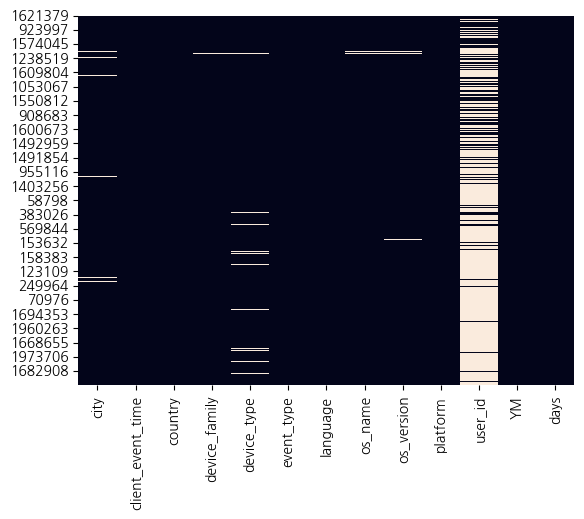

In [ ]:
# 결측치
look_null(enter_main)

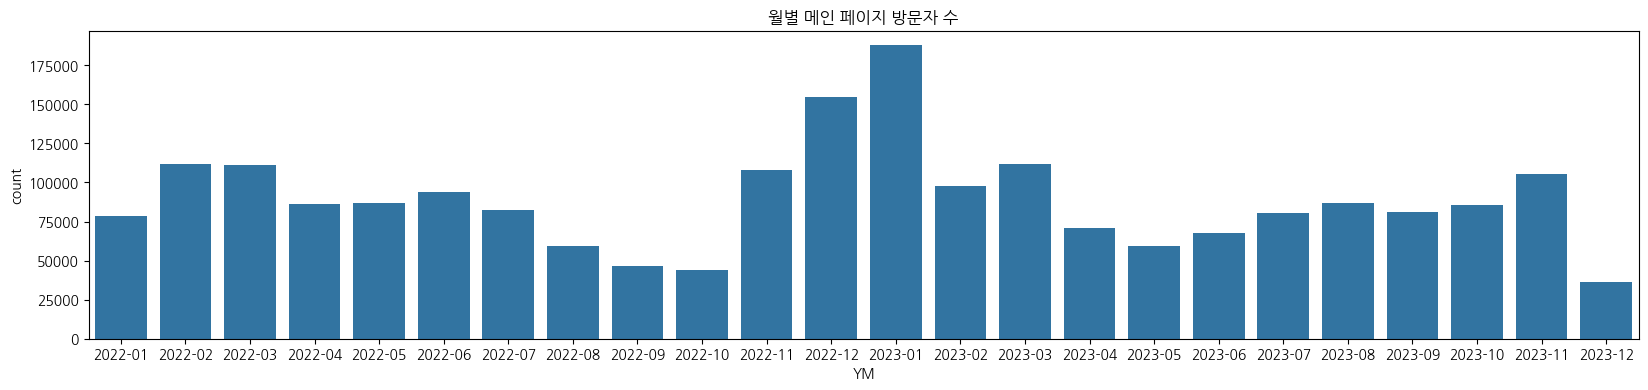

In [ ]:
fig, ax = plt.subplots(figsize = (20,4))
sns.countplot(data = enter_main, x = 'YM')
plt.title('월별 메인 페이지 방문자 수')
plt.show()

In [ ]:
enter_main_Dec = enter_main[enter_main['YM'] > '2023-11']
enter_main_Dec.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,YM,days
2132294,Paju,2023-12-01 00:00:18.671,South Korea,Windows,Windows,enter.main_page,Korean,Chrome,119.0.0.0,Web,NaN,2023-12,1
2132304,Asan,2023-12-01 00:00:21.145,South Korea,Samsung Phone,Samsung Galaxy S20+ 5G,enter.main_page,Korean,Instagram,305.0.0.34.110,Web,NaN,2023-12,1
2132401,Yangsan,2023-12-01 00:00:29.297,South Korea,Windows,Windows,enter.main_page,Korean,Chrome,119.0.0.0,Web,NaN,2023-12,1
2132402,Seoul,2023-12-01 00:00:32.873,South Korea,Apple iPad,Apple iPad,enter.main_page,Korean,Mobile Safari,17.1.1,Web,NaN,2023-12,1
2132400,Gangdong-gu,2023-12-01 00:00:46.717,South Korea,Apple iPhone,Apple iPhone 14 Plus,enter.main_page,Korean,Instagram,309.1.1.28.108,Web,NaN,2023-12,1


<Axes: xlabel='days', ylabel='count'>

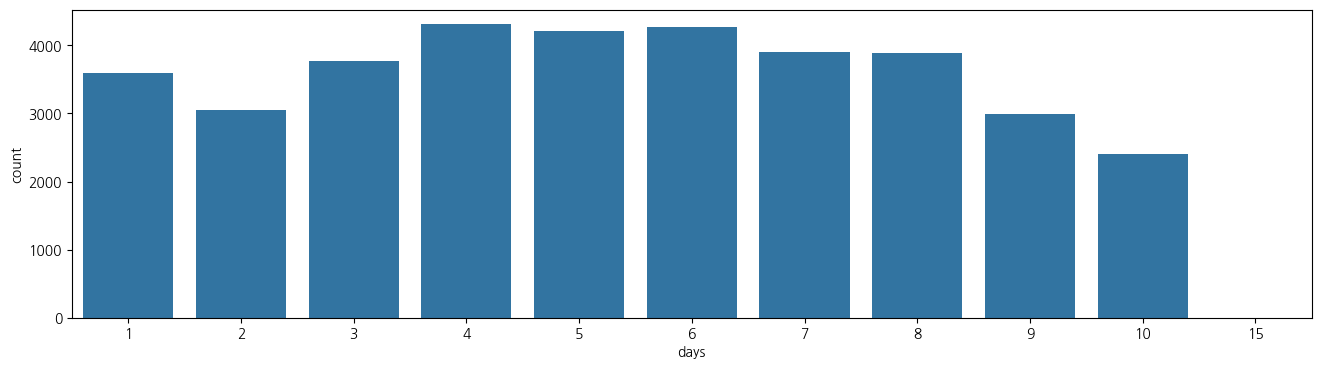

In [ ]:
fig, ax = plt.subplots(figsize = (16, 4))
sns.countplot(data = enter_main_Dec, x = 'days')

메인 페이지 23년 12월 데이터는 15일 이후 데이터가 없음.

## 회원가입

In [ ]:
# 회원가입 페이지 진입
enter_signup = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\enter.signup_page.csv', parse_dates = ['client_event_time'])
enter_signup.drop('device_carrier', axis = 1, inplace = True)
enter_signup['YM'] = enter_signup['client_event_time'].dt.to_period('M')
enter_signup = enter_signup[enter_signup['YM']>'2021-12']
enter_signup['days'] = enter_signup['client_event_time'].dt.day
enter_signup.sort_values(by = 'client_event_time', ascending = True, inplace = True)
enter_signup.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,YM,days
378421,Dobong-gu,2022-01-01 00:01:16.636,South Korea,Android,Android,enter.signup_page,Korean,Chrome Mobile,96,Web,NaN,2022-01,1
378422,Pyeongtaek-si,2022-01-01 00:01:47.862,South Korea,Android,Android,enter.signup_page,Korean,Chrome WebView,90,Web,NaN,2022-01,1
378423,Jeongeup,2022-01-01 00:02:53.923,South Korea,Windows,Windows,enter.signup_page,Korean,Edge,96,Web,NaN,2022-01,1
378461,Geumjeong-gu,2022-01-01 00:06:02.308,South Korea,Android,Android,enter.signup_page,Korean,Chrome WebView,87,Web,NaN,2022-01,1
378462,Geumjeong-gu,2022-01-01 00:06:08.359,South Korea,Android,Android,enter.signup_page,Korean,Chrome WebView,87,Web,NaN,2022-01,1


In [ ]:
enter_signup.info()

<class 'pandas.core.frame.DataFrame'>
Index: 596807 entries, 378421 to 466451
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   city               581002 non-null  object        
 1   client_event_time  596807 non-null  datetime64[ns]
 2   country            596293 non-null  object        
 3   device_family      596725 non-null  object        
 4   device_type        567365 non-null  object        
 5   event_type         596807 non-null  object        
 6   language           596807 non-null  object        
 7   os_name            596732 non-null  object        
 8   os_version         594628 non-null  object        
 9   platform           596807 non-null  object        
 10  user_id            0 non-null       float64       
 11  YM                 596807 non-null  period[M]     
 12  days               596807 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), 

city                  15805
client_event_time         0
country                 514
device_family            82
device_type           29442
event_type                0
language                  0
os_name                  75
os_version             2179
platform                  0
user_id              596807
YM                        0
days                      0
dtype: int64


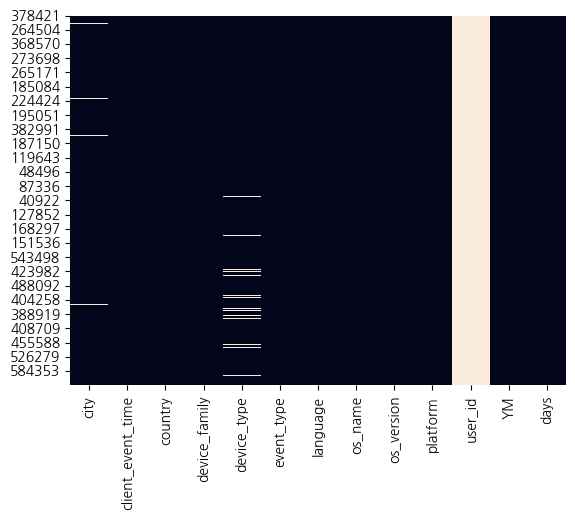

In [ ]:
# 결측치
look_null(enter_signup)

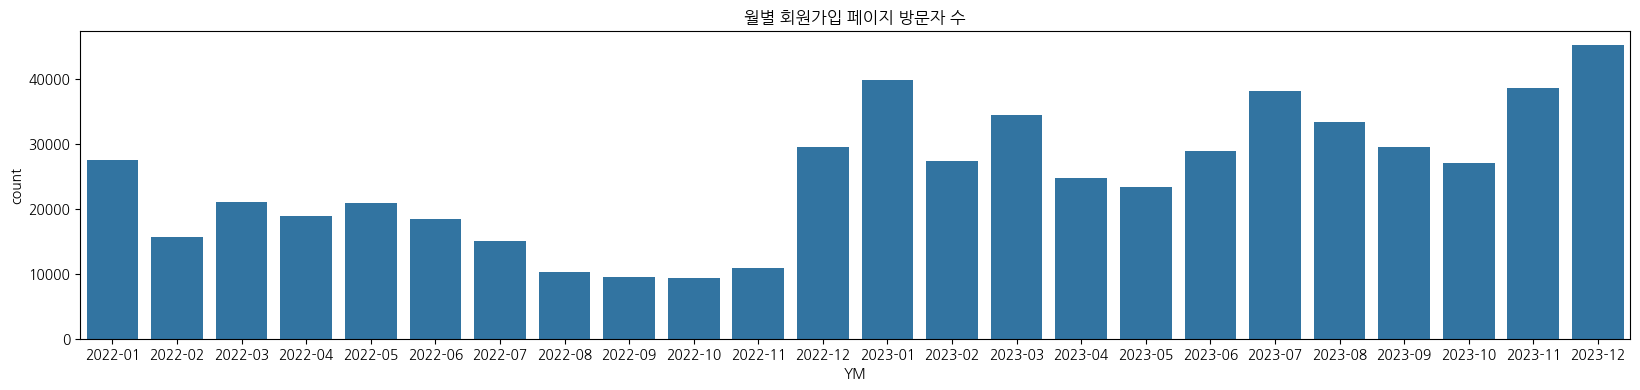

In [ ]:
fig, ax = plt.subplots(figsize = (20,4))
sns.countplot(data = enter_signup, x = 'YM')
plt.title('월별 회원가입 페이지 방문자 수')
plt.show()

In [ ]:
# 회원가입 완료
complete_signup = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\complete.signup.csv', parse_dates = ['client_event_time'])
complete_signup.drop('device_carrier', axis = 1, inplace =True)
complete_signup['YM'] = complete_signup['client_event_time'].dt.to_period('M')
complete_signup = complete_signup[complete_signup['YM']>'2021-12']
complete_signup['days'] = complete_signup['client_event_time'].dt.day
complete_signup.sort_values(by = 'client_event_time', ascending = True, inplace = True)
complete_signup.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,type,YM,days
98676,Geumjeong-gu,2022-01-01 00:06:31.232,South Korea,Android,Android,complete.signup,Korean,Chrome WebView,87,Web,6b4b4d8e08ce009f8992c546372ce664,email,2022-01,1
98667,Seoul,2022-01-01 00:10:21.400,South Korea,Android,Android,complete.signup,Korean,Chrome Mobile,96,Web,a5b72d5c6dd4e213315225d9fb9bbbca,kakao,2022-01,1
98679,Nowon-gu,2022-01-01 00:10:49.730,South Korea,Android,Android,complete.signup,Korean,Chrome WebView,96,Web,81c52556d0605b8221aa897cd2ed740d,kakao,2022-01,1
98668,NaN,2022-01-01 00:12:18.251,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,4a8e9325b1a855be259d7dad2d378276,kakao,2022-01,1
98677,NaN,2022-01-01 00:26:03.194,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,796a820f0e89e37319a7a4b0cdc25aa5,kakao,2022-01,1


In [ ]:
complete_signup.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145133 entries, 98676 to 117609
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   city               44774 non-null   object        
 1   client_event_time  145133 non-null  datetime64[ns]
 2   country            45756 non-null   object        
 3   device_family      45767 non-null   object        
 4   device_type        44659 non-null   object        
 5   event_type         145133 non-null  object        
 6   language           45767 non-null   object        
 7   os_name            45745 non-null   object        
 8   os_version         45651 non-null   object        
 9   platform           45767 non-null   object        
 10  user_id            145133 non-null  object        
 11  type               144958 non-null  object        
 12  YM                 145133 non-null  period[M]     
 13  days               145133 non-null  int32    

In [ ]:
complete_signup['language'].unique()

array(['Korean', nan, 'English', 'Chinese', 'Japanese', 'Russian',
       'German', 'French', 'Vietnamese', 'Uzbek', 'Spanish', 'Turkish',
       'Ukrainian', 'Galician', 'Portuguese', 'Indonesian', 'Arabic'],
      dtype=object)

city                 100359
client_event_time         0
country               99377
device_family         99366
device_type          100474
event_type                0
language              99366
os_name               99388
os_version            99482
platform              99366
user_id                   0
type                    175
YM                        0
days                      0
dtype: int64


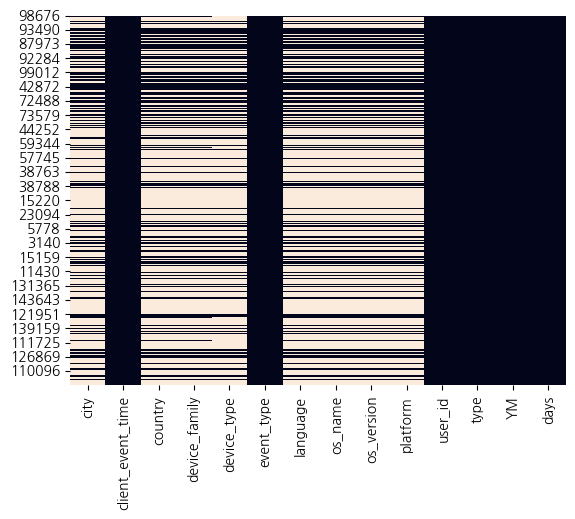

In [ ]:
# 결측치
look_null(complete_signup)

In [ ]:
test_signup = complete_signup[complete_signup['type'] == 'test']
test_signup


,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,type,YM,days
24616,NaN,2023-02-17 07:49:50.039,NaN,NaN,NaN,complete.signup,NaN,NaN,NaN,NaN,717fd2ff22addd9f8745923ab19ee231,test,2023-02,17


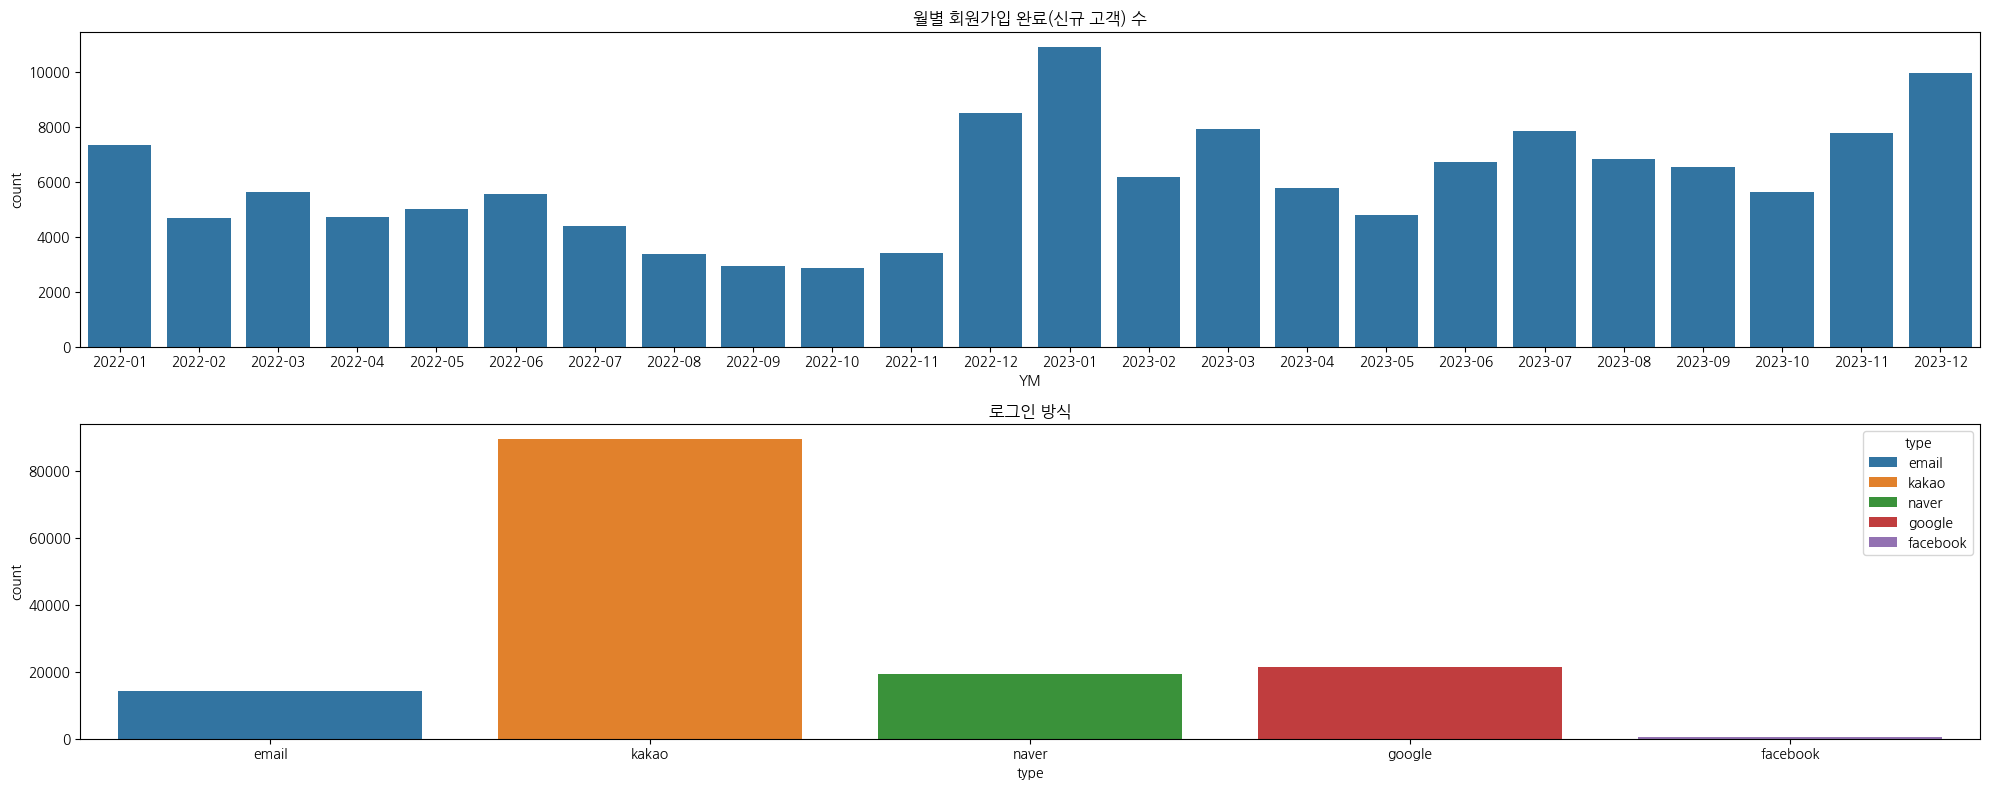

In [ ]:
# 테스트용 계정이 있어서 제외
complete_signup = complete_signup[complete_signup['type'] != 'test']

fig, ax = plt.subplots(2, 1, figsize = (20,8))
sns.countplot(data = complete_signup, x = 'YM', ax = ax[0])
sns.countplot(data = complete_signup, x = 'type', ax = ax[1], hue = 'type')

ax[0].set_title('월별 회원가입 완료(신규 고객) 수')
ax[1].set_title('로그인 방식')
plt.tight_layout()
plt.show()

## 무료체험

In [ ]:
#무료체험
start_free = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\start.free_trial.csv', parse_dates = ['client_event_time'])
start_free.drop('device_carrier', axis = 1, inplace = True)
start_free['YM'] = start_free['client_event_time'].dt.to_period('M')
start_free = start_free[start_free['YM']>'2021-12']
start_free['days'] = start_free['client_event_time'].dt.day
start_free.sort_values(by = 'client_event_time', ascending = True, inplace = True)
start_free.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,plan.type,trial.type,YM,days
29680,Gumi,2022-01-01 00:17:55.165,South Korea,Windows,Windows,start.free_trial,Korean,Chrome,96.0,Web,e98481d6081c560ad6c9c01c4596129e,NaN,NaN,A,2022-01,1
29681,Gumi,2022-01-01 00:18:57.317,South Korea,Windows,Windows,start.free_trial,Korean,Chrome,96.0,Web,e98481d6081c560ad6c9c01c4596129e,NaN,NaN,A,2022-01,1
29682,Gumi,2022-01-01 00:25:27.237,South Korea,Windows,Windows,start.free_trial,Korean,Chrome,96.0,Web,e98481d6081c560ad6c9c01c4596129e,NaN,NaN,A,2022-01,1
29679,Busan,2022-01-01 00:30:35.744,South Korea,Mac,Mac,start.free_trial,Korean,Chrome,96.0,Web,28562e887d0942c8f422f1ffa1c12bc0,NaN,NaN,A,2022-01,1
22136,Busan,2022-01-01 01:37:28.634,South Korea,Android,Android,start.free_trial,Korean,Chrome WebView,90.0,Web,0ac05541526958e4ffa257afe205fc57,NaN,NaN,A,2022-01,1


In [ ]:
start_free.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30616 entries, 29680 to 2127
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   city               30128 non-null  object        
 1   client_event_time  30616 non-null  datetime64[ns]
 2   country            30486 non-null  object        
 3   device_family      30494 non-null  object        
 4   device_type        30473 non-null  object        
 5   event_type         30616 non-null  object        
 6   language           30494 non-null  object        
 7   os_name            30494 non-null  object        
 8   os_version         30492 non-null  object        
 9   platform           30494 non-null  object        
 10  user_id            30602 non-null  object        
 11  plan.price         2439 non-null   float64       
 12  plan.type          2439 non-null   object        
 13  trial.type         30616 non-null  object        
 14  YM      

city                   488
client_event_time        0
country                130
device_family          122
device_type            143
event_type               0
language               122
os_name                122
os_version             124
platform               122
user_id                 14
plan.price           28177
plan.type            28177
trial.type               0
YM                       0
days                     0
dtype: int64


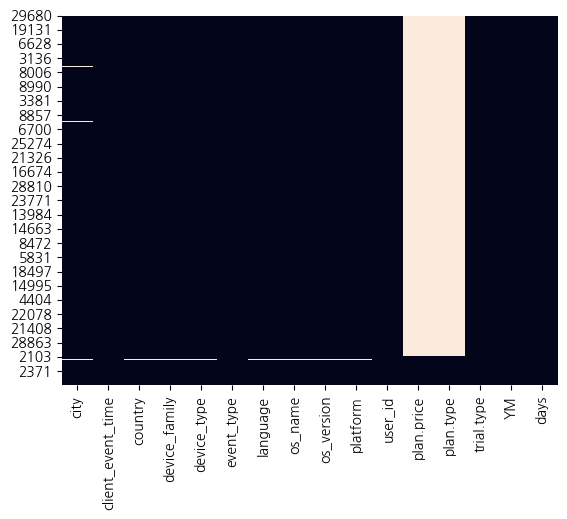

In [ ]:
look_null(start_free)

In [ ]:
start_free.duplicated('user_id').sum()

14308

<Axes: xlabel='YM', ylabel='count'>

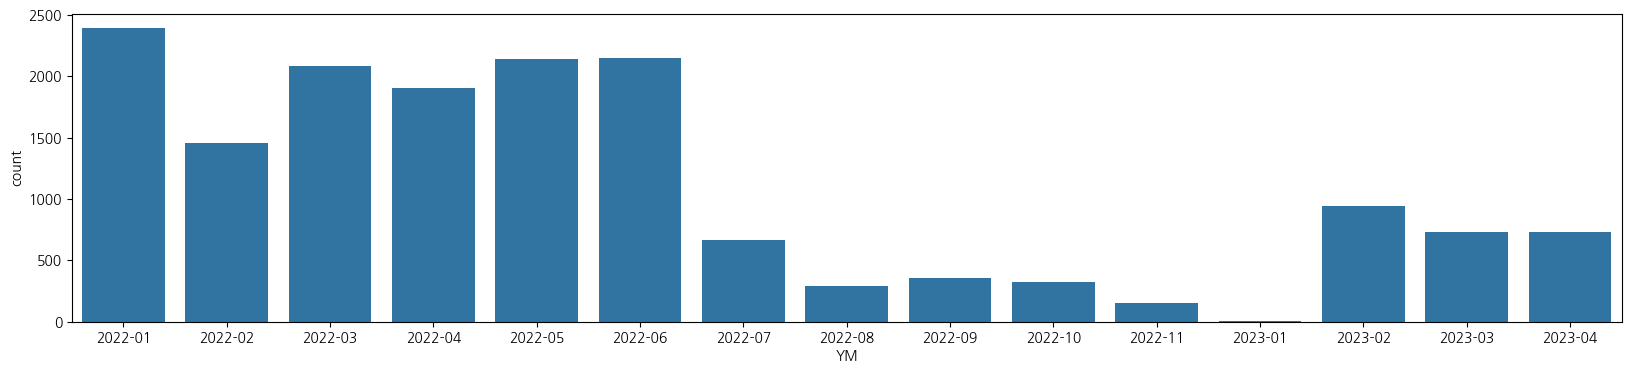

In [ ]:
start_free_iso = start_free.drop_duplicates('user_id')
fig, ax = plt.subplots(figsize = (20,4))
sns.countplot(data = start_free_iso, x = 'YM')

22년 7월부터 급감하고 4월 이후로는 데이터가 없음. 4월부터는 무료체험 서비스를 중지한 것으로 보임.

In [ ]:
# B 유형에만 plan.type이 기록되어 있음
start_free['plan.type'].value_counts()


plan.type
1개월 플랜     1278
12개월 플랜    1161
Name: count, dtype: int64

In [ ]:
trials = start_free.groupby('user_id')['trial.type'].count().reset_index()
trials.head()

,user_id,trial.type
0,0000572f2ba8079bcefd2760b632e820,1
1,000087537cbfd934375364218ff10f91,1
2,0008a61888a167f7c68df68e9e76dcf7,1
3,000be07bc09ceff42c11978f4a9f1c1a,1
4,000ec3029411f0e0f5198abb679eebb8,2


In [ ]:
start_free[start_free['user_id'] == 'fffba676b17f9f0f228360930f238f07']

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,plan.type,trial.type,YM,days
15716,Buk-gu,2022-01-02 13:38:50.558,South Korea,Windows,Windows,start.free_trial,Korean,Chrome,96.0,Web,fffba676b17f9f0f228360930f238f07,NaN,NaN,A,2022-01,2
15717,Buk-gu,2022-01-02 13:39:33.974,South Korea,Windows,Windows,start.free_trial,Korean,Chrome,96.0,Web,fffba676b17f9f0f228360930f238f07,NaN,NaN,A,2022-01,2
15718,Buk-gu,2022-01-02 13:40:41.708,South Korea,Windows,Windows,start.free_trial,Korean,Chrome,96.0,Web,fffba676b17f9f0f228360930f238f07,NaN,NaN,A,2022-01,2
18562,Seoul,2022-02-01 06:53:16.953,South Korea,Android,Android,start.free_trial,Korean,Chrome,97.0,Web,fffba676b17f9f0f228360930f238f07,NaN,NaN,A,2022-02,1


## 첫 결제

In [ ]:
# 결제 페이지 진입
enter_payment = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\enter.payment_page.csv', parse_dates = ['client_event_time'])
enter_payment.drop('device_carrier', axis = 1, inplace= True)
enter_payment['YM'] = enter_payment['client_event_time'].dt.to_period('M')
enter_payment = enter_payment[enter_payment['YM']>'2021-12']
enter_payment['days'] = enter_payment['client_event_time'].dt.day
enter_payment.sort_values(by = 'client_event_time', ascending = True, inplace = True)
enter_payment.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,YM,days
85120,Seoul,2022-11-03 02:39:46.400,South Korea,Android,Android,enter.payment_page,Korean,Chrome WebView,106,Web,e7aa397dfa39c9ee8351e8be9cf9f8e3,2022-11,3
85121,Gwanak-gu,2022-11-03 02:45:46.929,South Korea,Windows,Windows,enter.payment_page,Korean,Chrome,107,Web,b4410b73bdbe9835ad087d5cd7579ea8,2022-11,3
85119,Seoul,2022-11-03 02:51:18.631,South Korea,Android,Android,enter.payment_page,Korean,Chrome WebView,106,Web,06d81e750b7981e1cd75d208a7f794d7,2022-11,3
85118,Gangseo-gu,2022-11-03 02:52:01.904,South Korea,Mac,Mac,enter.payment_page,Korean,Chrome,107,Web,6b889dac8d1646374b43ccd0130182ff,2022-11,3
79888,Busanjin-gu,2022-11-03 03:10:48.191,South Korea,Android,Android,enter.payment_page,Korean,Chrome WebView,106,Web,f76e33e691aa74c0f4eff23044b5eded,2022-11,3


In [ ]:
enter_payment.info()

<class 'pandas.core.frame.DataFrame'>
Index: 165061 entries, 85120 to 94463
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   city               162362 non-null  object        
 1   client_event_time  165061 non-null  datetime64[ns]
 2   country            164899 non-null  object        
 3   device_family      165060 non-null  object        
 4   device_type        159066 non-null  object        
 5   event_type         165061 non-null  object        
 6   language           165061 non-null  object        
 7   os_name            165061 non-null  object        
 8   os_version         164560 non-null  object        
 9   platform           165061 non-null  object        
 10  user_id            158834 non-null  object        
 11  YM                 165061 non-null  period[M]     
 12  days               165061 non-null  int32         
dtypes: datetime64[ns](1), int32(1), object(10), pe

city                 2699
client_event_time       0
country               162
device_family           1
device_type          5995
event_type              0
language                0
os_name                 0
os_version            501
platform                0
user_id              6227
YM                      0
days                    0
dtype: int64


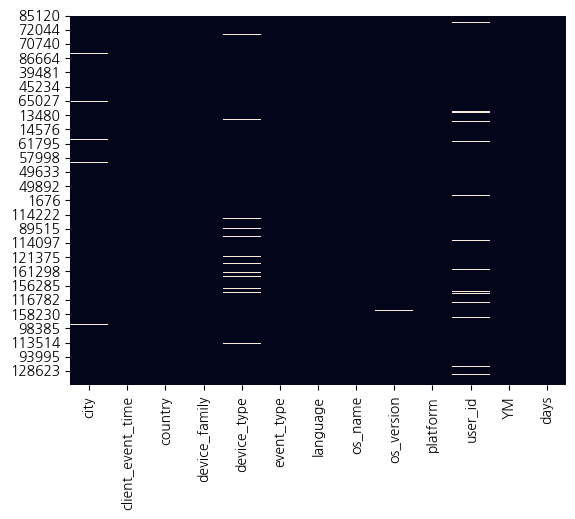

In [ ]:
look_null(enter_payment)

<Axes: xlabel='YM', ylabel='count'>

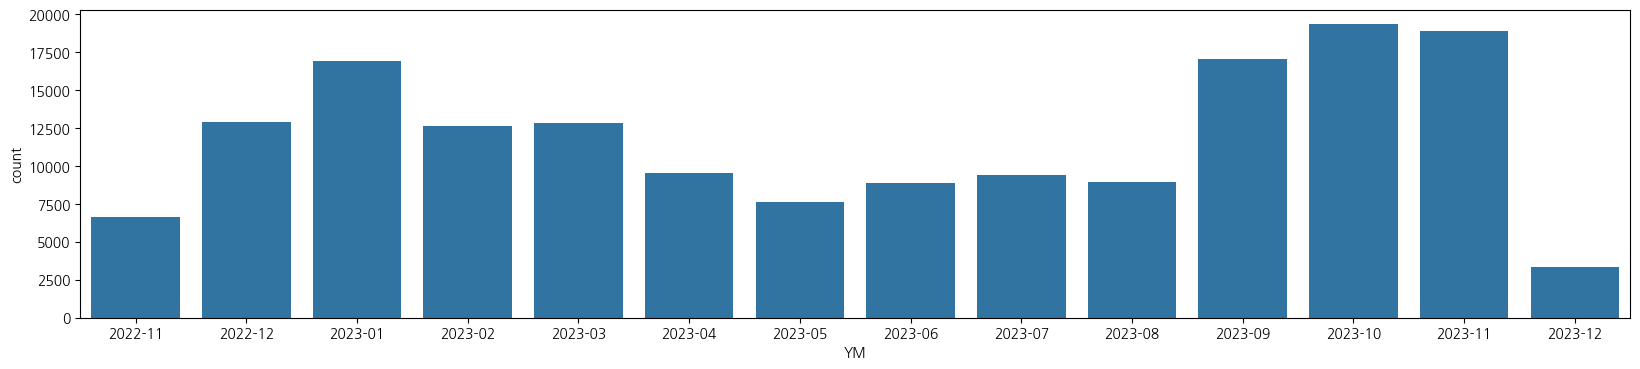

In [ ]:
# 월별 결제페이지 진입 빈도도
fig, ax = plt.subplots(figsize=(20,4))
sns.countplot(data = enter_payment, x = 'YM')

<Axes: xlabel='days', ylabel='count'>

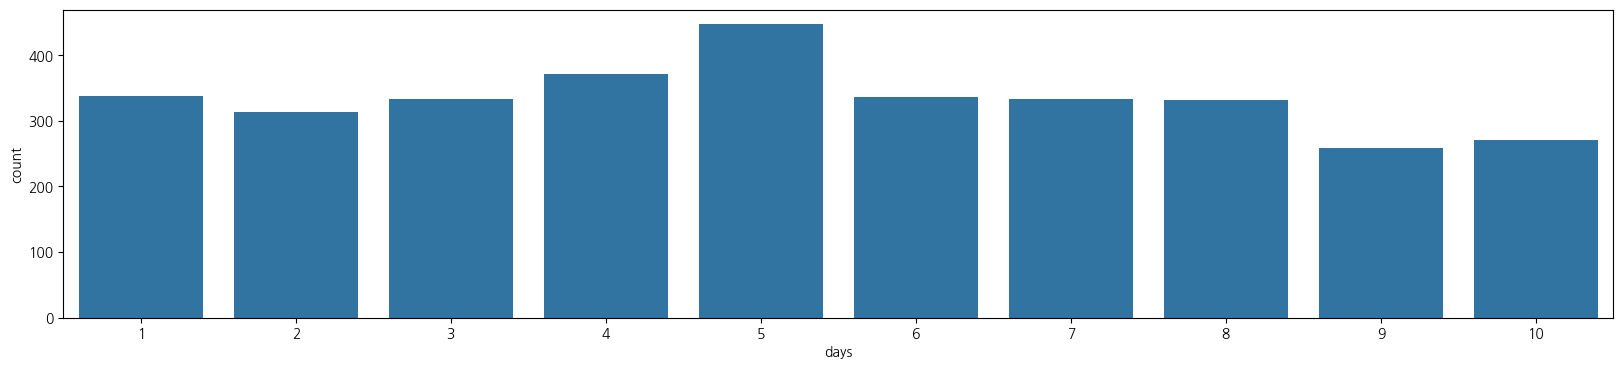

In [ ]:
# 12월에 빈도수가 작은 이유 찾기기
enter_payment_Dec = enter_payment[enter_payment['YM'] > '2023-11']
fig, ax = plt.subplots(figsize=(20,4))
sns.countplot(data = enter_payment_Dec, x = 'days')

메인 페이지 데이터와 유사하게 23년 12월 10일 이후 데이터가 없음.

In [ ]:
# 첫 결제 완료
complete_sub = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\complete.subscription.csv', parse_dates = ['client_event_time'])
complete_sub.drop('device_carrier', axis = 1, inplace= True)
complete_sub['YM'] = complete_sub['client_event_time'].dt.to_period('M')
complete_sub = complete_sub[complete_sub['YM']>'2021-12']
complete_sub['days'] = complete_sub['client_event_time'].dt.day
complete_sub.sort_values(by = 'client_event_time', ascending = True, inplace = True)
complete_sub.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,plan.type,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,YM,days
9399,Seoul,2022-01-01 06:17:24.513,South Korea,Apple iPhone,Apple iPhone,complete.subscription,Korean,Mobile Safari,15,Web,c2fd9e1a9d094f563d6ca7a6caa538be,42960,42960,3개월 플랜,NaN,NaN,0,NaN,2022-01,1
6914,Bucheon-si,2022-01-02 08:34:14.270,South Korea,Windows,Windows,complete.subscription,Korean,Edge,96,Web,8eabe35d59b6596f27552a4c71a279c1,15920,15920,1개월 플랜,NaN,NaN,0,NaN,2022-01,2
5757,Dongjak-gu,2022-01-02 15:23:04.269,South Korea,Windows,Windows,complete.subscription,Korean,Chrome,96,Web,97c0a306a466b44643469ebf1d4b57e3,42960,42960,3개월 플랜,NaN,NaN,0,NaN,2022-01,2
7520,Seoul,2022-01-03 04:25:14.519,South Korea,Windows,Windows,complete.subscription,Korean,Chrome,95,Web,29488c6f47c0f19ed631be20c40d64c0,15920,15920,1개월 플랜,NaN,NaN,0,NaN,2022-01,3
5747,Osan,2022-01-04 13:35:09.247,South Korea,Windows,Windows,complete.subscription,Korean,Chrome,96,Web,37ebaca2779d2f5b40d5694afa387f43,42960,42960,3개월 플랜,NaN,NaN,0,NaN,2022-01,4


In [ ]:
complete_sub.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14289 entries, 9399 to 12036
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    13757 non-null  object        
 1   client_event_time       14289 non-null  datetime64[ns]
 2   country                 13906 non-null  object        
 3   device_family           13914 non-null  object        
 4   device_type             13764 non-null  object        
 5   event_type              14289 non-null  object        
 6   language                13914 non-null  object        
 7   os_name                 13908 non-null  object        
 8   os_version              13899 non-null  object        
 9   platform                13914 non-null  object        
 10  user_id                 14289 non-null  object        
 11  plan.price              14289 non-null  int64         
 12  paid_amount             14289 non-null  int64   

city                        532
client_event_time             0
country                     383
device_family               375
device_type                 525
event_type                    0
language                    375
os_name                     381
os_version                  390
platform                    375
user_id                       0
plan.price                    0
paid_amount                   0
plan.type                     0
coupon.type               12154
coupon.benefit_type       12154
coupon.discount_amount        0
pg.type                   12647
YM                            0
days                          0
dtype: int64


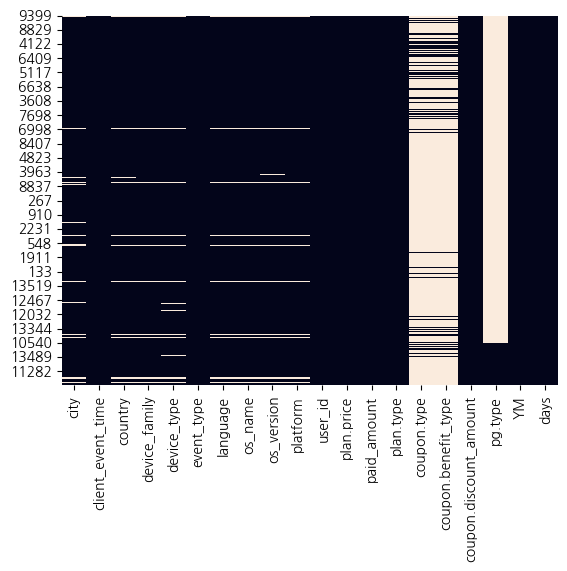

In [ ]:
look_null(complete_sub)

In [ ]:
complete_sub['user_id'].duplicated().sum()

408

In [ ]:
complete_sub_final = complete_sub.drop_duplicates(subset = 'user_id', keep='last')
complete_sub_final.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,plan.type,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,YM,days
9399,Seoul,2022-01-01 06:17:24.513,South Korea,Apple iPhone,Apple iPhone,complete.subscription,Korean,Mobile Safari,15,Web,c2fd9e1a9d094f563d6ca7a6caa538be,42960,42960,3개월 플랜,NaN,NaN,0,NaN,2022-01,1
6914,Bucheon-si,2022-01-02 08:34:14.270,South Korea,Windows,Windows,complete.subscription,Korean,Edge,96,Web,8eabe35d59b6596f27552a4c71a279c1,15920,15920,1개월 플랜,NaN,NaN,0,NaN,2022-01,2
5757,Dongjak-gu,2022-01-02 15:23:04.269,South Korea,Windows,Windows,complete.subscription,Korean,Chrome,96,Web,97c0a306a466b44643469ebf1d4b57e3,42960,42960,3개월 플랜,NaN,NaN,0,NaN,2022-01,2
7520,Seoul,2022-01-03 04:25:14.519,South Korea,Windows,Windows,complete.subscription,Korean,Chrome,95,Web,29488c6f47c0f19ed631be20c40d64c0,15920,15920,1개월 플랜,NaN,NaN,0,NaN,2022-01,3
5747,Osan,2022-01-04 13:35:09.247,South Korea,Windows,Windows,complete.subscription,Korean,Chrome,96,Web,37ebaca2779d2f5b40d5694afa387f43,42960,42960,3개월 플랜,NaN,NaN,0,NaN,2022-01,4


<Axes: xlabel='plan.type', ylabel='count'>

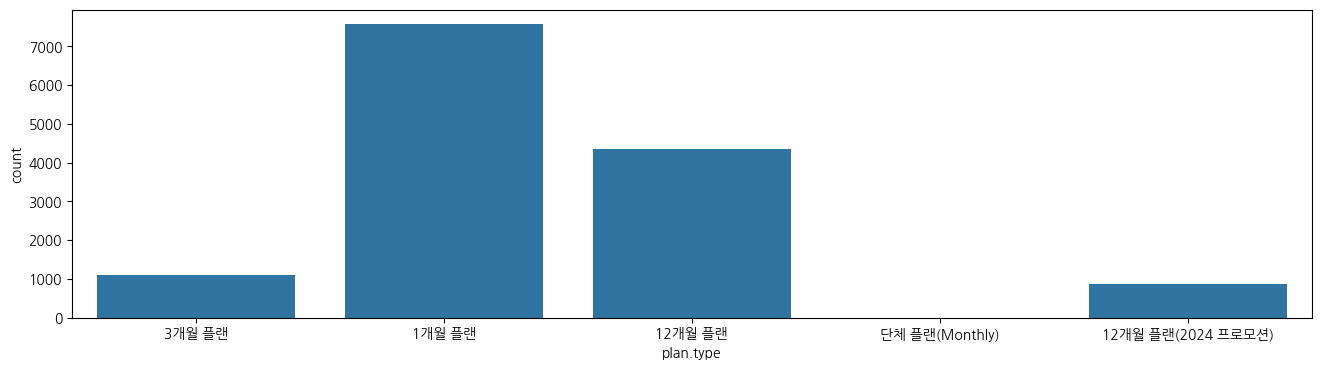

In [ ]:
fig, ax = plt.subplots(figsize=(16,4))
sns.countplot(data = complete_sub_final, x = 'plan.type')

Text(0.5, 1.0, '월별 첫 결제 수')

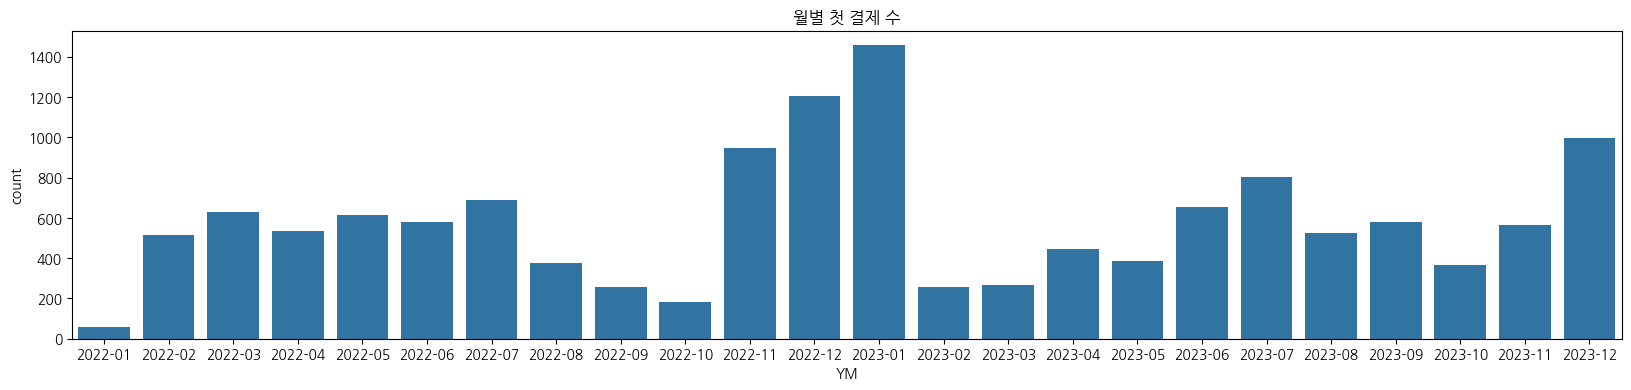

In [ ]:
fig, ax = plt.subplots(figsize=(20,4))
sns.countplot(data = complete_sub_final, x = 'YM')
plt.title('월별 첫 결제 수')

<Axes: xlabel='coupon.type', ylabel='count'>

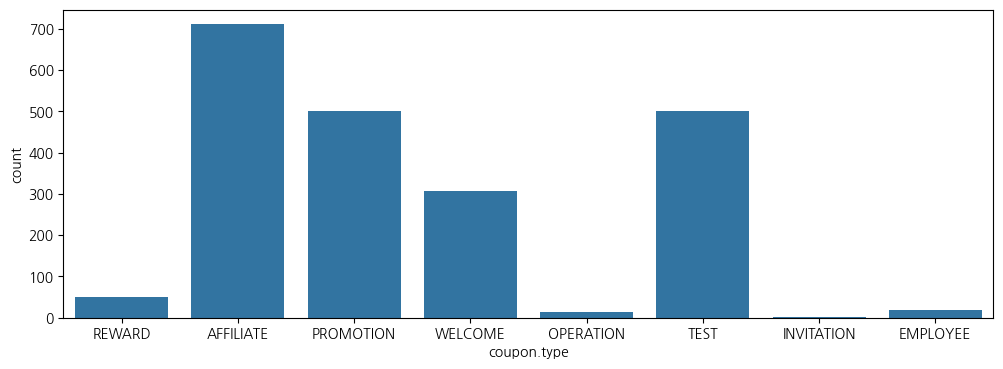

In [ ]:
fig, ax = plt.subplots(figsize = (12,4))
sns.countplot(data = complete_sub_final, x = 'coupon.type')

<Axes: xlabel='day_type', ylabel='count'>

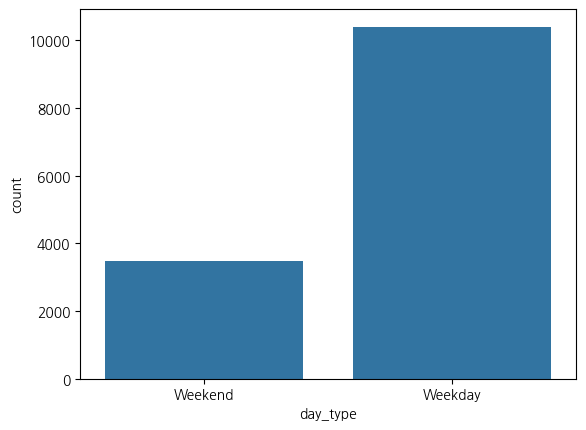

In [ ]:
# 결제 시간을 볼까?
test = complete_sub_final.copy()
test['hour'] = test['client_event_time'].dt.hour
test['day_type'] = test['client_event_time'].dt.dayofweek.apply(lambda x: 'Weekday' if x < 5 else 'Weekend')
test.head()
sns.countplot(data = test, x = 'day_type')
# sns.countplot(data = test, x = 'hour')



## 콘텐츠

In [ ]:
# 콘텐츠 페이지 진입
enter_content = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\enter.content_page.csv', parse_dates = ['client_event_time'])
enter_content.drop('device_carrier', axis = 1, inplace = True)
enter_content['YM'] = enter_content['client_event_time'].dt.to_period('M')
enter_content = enter_content[enter_content['YM']>'2021-12']
enter_content['days'] = enter_content['client_event_time'].dt.day
enter_content.sort_values(by = 'client_event_time', ascending = True, inplace = True)
enter_content.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,YM,days
1423083,Dobong-gu,2022-01-01 00:00:10.862,South Korea,Android,Android,enter.content_page,Korean,Chrome Mobile,96,Web,NaN,512a6f0abaef16c51950d52ce2d66fda,2022-01,1
1423046,Jeonju,2022-01-01 00:04:26.749,South Korea,Android,Android,enter.content_page,Korean,Chrome,96,Web,86cd970e25ecd9969bd1c7fcca907c72,c269eb6df3a374b464f7c18f12fa398f,2022-01,1
1423067,Gwanak-gu,2022-01-01 00:09:01.663,South Korea,Android,Android,enter.content_page,Korean,Chrome WebView,90,Web,NaN,f4be1a0fe0e301b03115591777fddf29,2022-01,1
1423050,Nam-gu,2022-01-01 00:11:10.050,South Korea,Windows,Windows,enter.content_page,Korean,Edge,96,Web,c6991cc646bce25351e3a64ea00ccb1f,512a6f0abaef16c51950d52ce2d66fda,2022-01,1
1423051,Nam-gu,2022-01-01 00:12:18.696,South Korea,Windows,Windows,enter.content_page,Korean,Edge,96,Web,c6991cc646bce25351e3a64ea00ccb1f,f351e92bba7aadae94d04c85c3fb1834,2022-01,1


In [ ]:
enter_content.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1914107 entries, 1423083 to 1631895
Data columns (total 14 columns):
 #   Column             Dtype         
---  ------             -----         
 0   city               object        
 1   client_event_time  datetime64[ns]
 2   country            object        
 3   device_family      object        
 4   device_type        object        
 5   event_type         object        
 6   language           object        
 7   os_name            object        
 8   os_version         object        
 9   platform           object        
 10  user_id            object        
 11  content.id         object        
 12  YM                 period[M]     
 13  days               int32         
dtypes: datetime64[ns](1), int32(1), object(11), period[M](1)
memory usage: 211.8+ MB


city                  30757
client_event_time         0
country                7570
device_family           639
device_type           23651
event_type                0
language                  0
os_name                 149
os_version             2549
platform                  0
user_id              465114
content.id                0
YM                        0
days                      0
dtype: int64


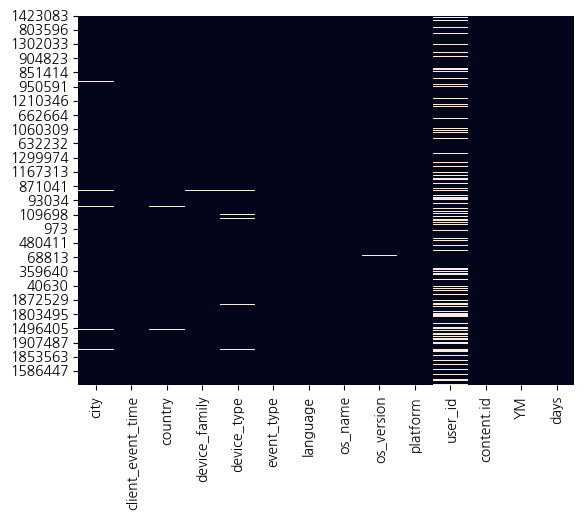

In [ ]:
look_null(enter_content)

<Axes: xlabel='YM', ylabel='count'>

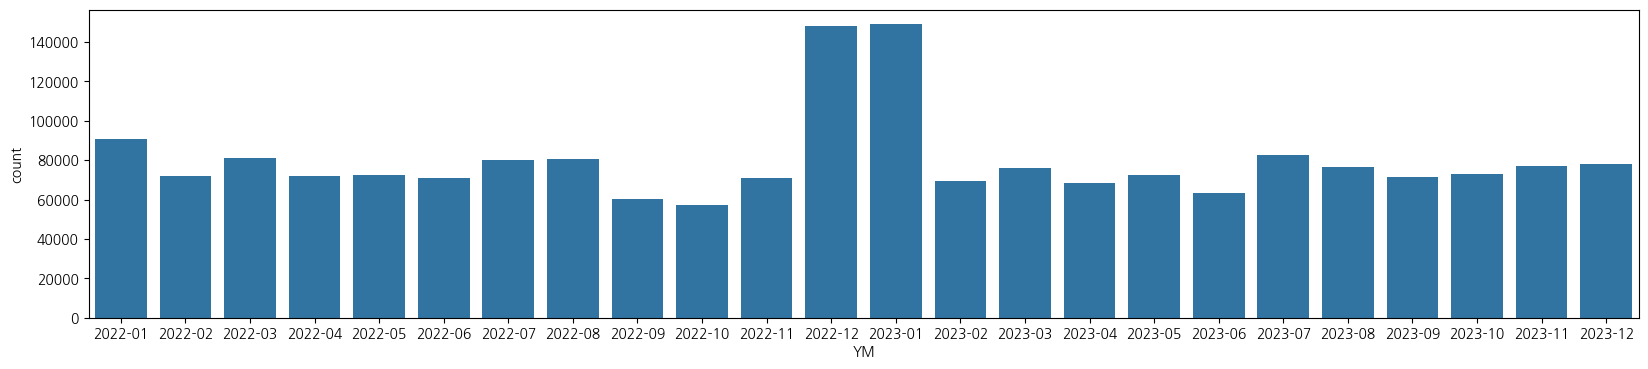

In [ ]:
fig, ax = plt.subplots(figsize = (20,4))
sns.countplot(data = enter_content, x = 'YM')

Text(0.5, 1.0, '월별 콘텐츠 수')

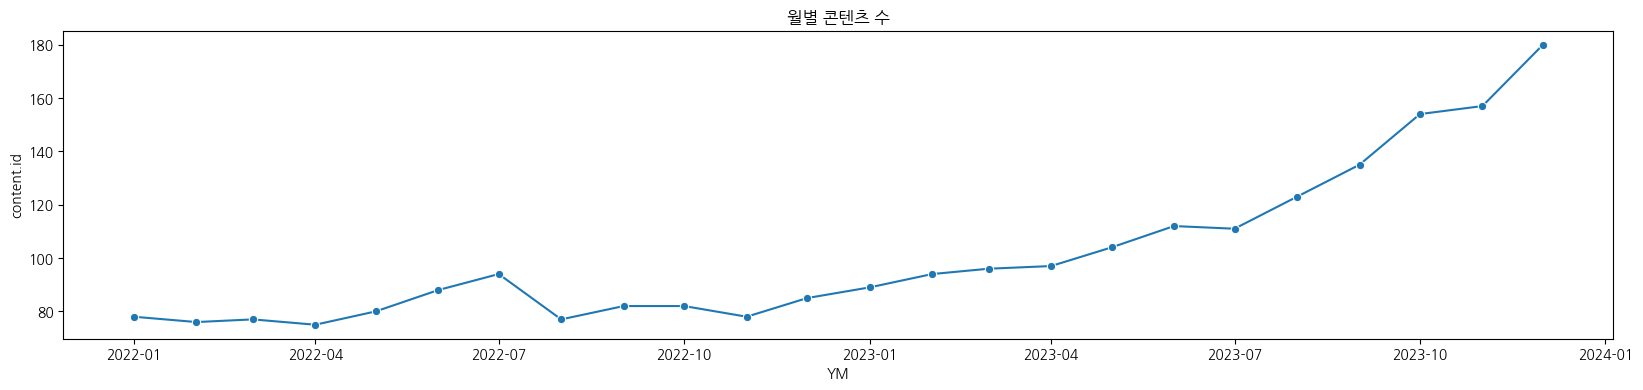

In [ ]:
content_ammount = enter_content.groupby('YM')['content.id'].nunique().reset_index()
content_ammount['YM'] = content_ammount['YM'].dt.to_timestamp()
fig, ax = plt.subplots(figsize = (20,4))
sns.lineplot(data = content_ammount, x = 'YM', y = 'content.id', marker= 'o')
plt.title('월별 콘텐츠 수')

22년 8월에 콘텐츠 수가 급감하였음.

2022년 11월부터 콘텐츠 수가 꾸준히 증가

22년 7월에 대대적인 개편이 있었음.

In [ ]:
# 콘텐츠 후기 더보기 버튼 클릭
click_content_more = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\click.content_page_more_review_button.csv', parse_dates = ['client_event_time'])
click_content_more.drop('device_carrier', axis = 1, inplace = True)
click_content_more['YM'] = click_content_more['client_event_time'].dt.to_period('M')
click_content_more = click_content_more[click_content_more['YM']>'2021-12']
click_content_more['days'] = click_content_more['client_event_time'].dt.day
click_content_more.sort_values(by = 'client_event_time', ascending = True, inplace = True)
click_content_more.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,YM,days
51614,NaN,2022-01-01 01:34:02.834,South Korea,Apple iPhone,Apple iPhone,click.content_page_more_review_button,Korean,Mobile Safari,15,Web,NaN,ab7068685b7aeac4d6b1a6c0e1c85819,2022-01,1
51615,Seoul,2022-01-01 01:54:41.205,South Korea,Apple iPhone,Apple iPhone,click.content_page_more_review_button,Korean,Mobile Safari,15,Web,NaN,c269eb6df3a374b464f7c18f12fa398f,2022-01,1
51616,Seoul,2022-01-01 01:54:46.537,South Korea,Apple iPhone,Apple iPhone,click.content_page_more_review_button,Korean,Mobile Safari,15,Web,NaN,c269eb6df3a374b464f7c18f12fa398f,2022-01,1
23782,NaN,2022-01-01 02:08:08.884,South Korea,Apple iPhone,Apple iPhone,click.content_page_more_review_button,Korean,Mobile Safari,15,Web,NaN,638a60d5aedf29cbf779e6dfbcad216e,2022-01,1
23783,NaN,2022-01-01 02:08:11.947,South Korea,Apple iPhone,Apple iPhone,click.content_page_more_review_button,Korean,Mobile Safari,15,Web,NaN,638a60d5aedf29cbf779e6dfbcad216e,2022-01,1


In [ ]:
click_content_more.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93960 entries, 51614 to 93639
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   city               93790 non-null  object        
 1   client_event_time  93960 non-null  datetime64[ns]
 2   country            93942 non-null  object        
 3   device_family      93960 non-null  object        
 4   device_type        93907 non-null  object        
 5   event_type         93960 non-null  object        
 6   language           93960 non-null  object        
 7   os_name            93960 non-null  object        
 8   os_version         93957 non-null  object        
 9   platform           93960 non-null  object        
 10  user_id            10700 non-null  object        
 11  content.id         93936 non-null  object        
 12  YM                 93960 non-null  period[M]     
 13  days               93960 non-null  int32         
dtypes: date

city                   170
client_event_time        0
country                 18
device_family            0
device_type             53
event_type               0
language                 0
os_name                  0
os_version               3
platform                 0
user_id              83260
content.id              24
YM                       0
days                     0
dtype: int64


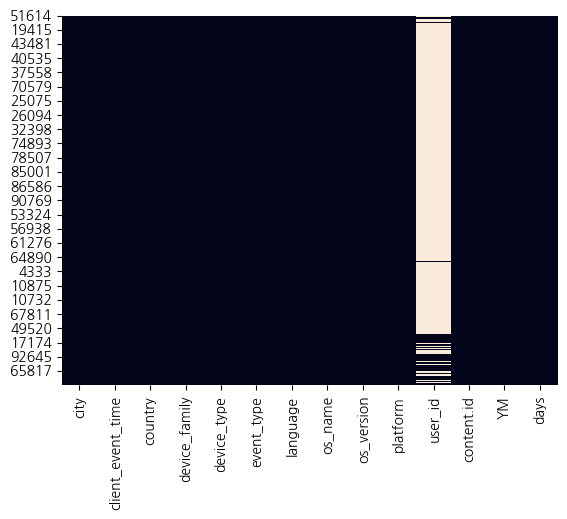

In [ ]:
look_null(click_content_more)

Text(0.5, 1.0, '월별 후기 더보기 버튼 클릭 횟수')

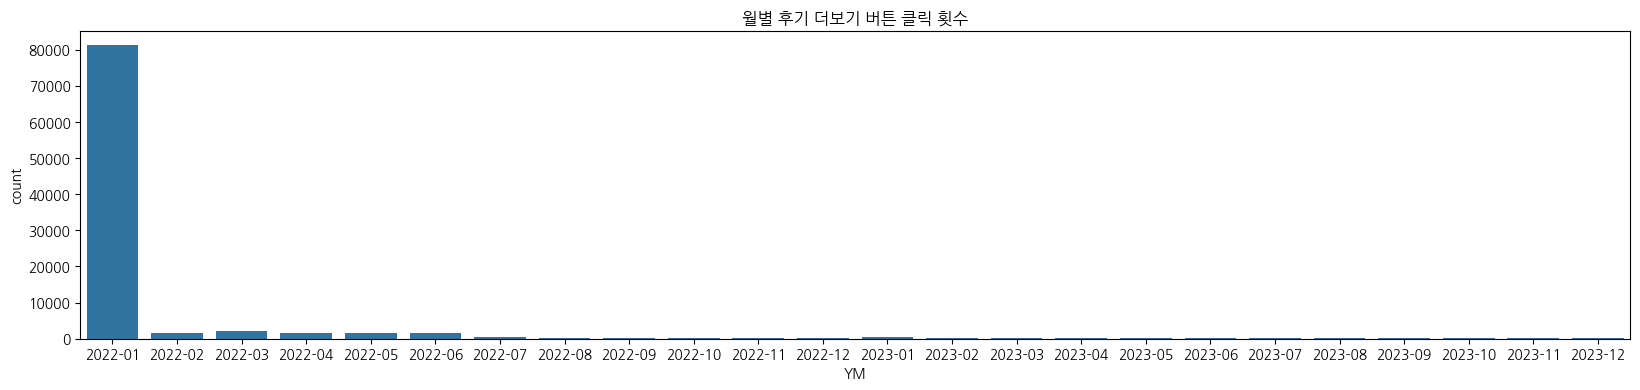

In [ ]:
fig, ax = plt.subplots(figsize = (20,4))
sns.countplot(data = click_content_more, x = 'YM')
plt.title('월별 후기 더보기 버튼 클릭 횟수')

22년 1월에 유난히 후기 더보기가 버튼 클릭 횟수가 많아 확인한 결과 특정 인물이 매크로를 사용해 후기 더보기 버튼을 클릭한 것으로 추정(1초 간격으로 2만회 이상 버튼 클릭) 따라서 22년 1월 데이터 삭제 후 시각화 실시

Text(0.5, 1.0, '월별 후기 더보기 버튼 클릭 횟수')

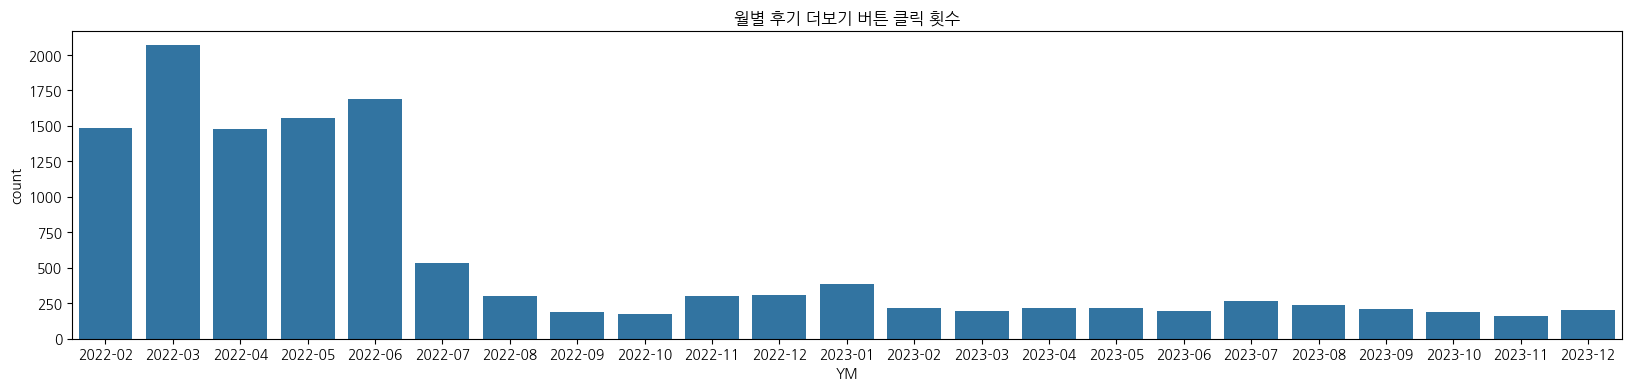

In [ ]:
click_content_more = click_content_more[click_content_more['YM']> '2022-01']
fig, ax = plt.subplots(figsize = (20,4))
sns.countplot(data = click_content_more, x = 'YM')
plt.title('월별 후기 더보기 버튼 클릭 횟수')

In [ ]:
# 콘텐츠 시청하기 버튼 클릭
click_content_start = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\click.content_page_start_content_button.csv', low_memory=False, parse_dates = ['client_event_time'])
click_content_start.drop('device_carrier', axis = 1, inplace = True)
click_content_start['YM'] = click_content_start['client_event_time'].dt.to_period('M')
click_content_start = click_content_start[click_content_start['YM']>'2021-12']
click_content_start['days'] = click_content_start['client_event_time'].dt.day
click_content_start.sort_values(by = 'client_event_time', ascending = True, inplace = True)
click_content_start.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,button.name,genre.id,genre.name,button_name,YM,days
139803,Seo-gu,2022-01-01 00:22:59.336,South Korea,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,96,Web,3baed2e6cdc3b4ac788b82c703119b2d,b8d4ec0133e5ce485055bfd69cd28abd,NaN,69c39b8e2f674dfb4d0baa703903fcdc,드라마 - 역사,이어보기,2022-01,1
139804,Gumi,2022-01-01 00:25:27.197,South Korea,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,96,Web,e98481d6081c560ad6c9c01c4596129e,f4be1a0fe0e301b03115591777fddf29,NaN,2654f7542b591c7791251b65fca1a5d2,리얼리티 쇼 - 오디션,무료로 시청하기,2022-01,1
139805,Gangnam-gu,2022-01-01 00:56:31.328,South Korea,Apple iPhone,Apple iPhone,click.content_page_start_content_button,Korean,Mobile Safari,14,Web,NaN,710ffb5be9f89772b7baa9f62c9c8805,NaN,2654f7542b591c7791251b65fca1a5d2,리얼리티 쇼 - 오디션,구독하기,2022-01,1
117172,Gangseo-gu,2022-01-01 01:16:08.662,South Korea,Android,Android,click.content_page_start_content_button,Korean,Chrome WebView,96,Web,NaN,7cebec6e79cc981dbf421c5ec2aedd9d,NaN,2654f7542b591c7791251b65fca1a5d2,리얼리티 쇼 - 오디션,무료로 시청하기,2022-01,1
117171,Ulsan,2022-01-01 01:29:53.945,South Korea,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,96,Web,b18081d883fd3d9783c9667a570cee4d,710ffb5be9f89772b7baa9f62c9c8805,NaN,2654f7542b591c7791251b65fca1a5d2,리얼리티 쇼 - 오디션,이어보기,2022-01,1


In [ ]:
click_content_start.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172900 entries, 139803 to 154247
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   city               169426 non-null  object        
 1   client_event_time  172900 non-null  datetime64[ns]
 2   country            171484 non-null  object        
 3   device_family      172900 non-null  object        
 4   device_type        171570 non-null  object        
 5   event_type         172900 non-null  object        
 6   language           172900 non-null  object        
 7   os_name            172900 non-null  object        
 8   os_version         172582 non-null  object        
 9   platform           172900 non-null  object        
 10  user_id            128351 non-null  object        
 11  content.id         172688 non-null  object        
 12  button.name        86242 non-null   object        
 13  genre.id           38940 non-null   object  

city                   3474
client_event_time         0
country                1416
device_family             0
device_type            1330
event_type                0
language                  0
os_name                   0
os_version              318
platform                  0
user_id               44549
content.id              212
button.name           86658
genre.id             133960
genre.name           133960
button_name          133960
YM                        0
days                      0
dtype: int64


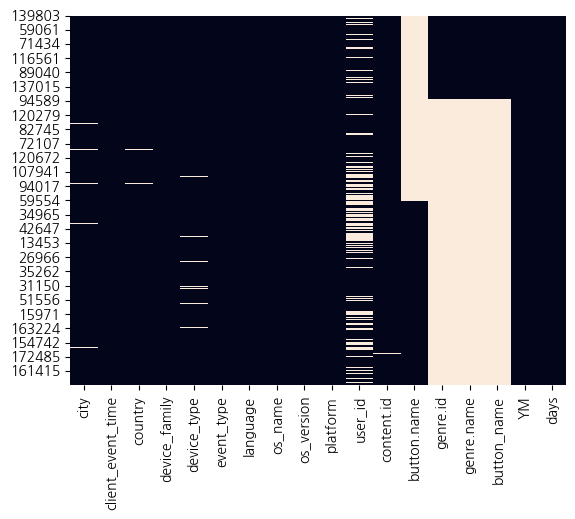

In [ ]:
look_null(click_content_start)

In [ ]:
before = click_content_start[click_content_start['button_name'].isnull() == 0]
after = click_content_start[click_content_start['button.name'].isnull() == 0]
genre = click_content_start[click_content_start['genre.name'].isnull() == 0]

print(f"버튼 개편 전 시작일: {before['client_event_time'].min()}")
print(f"버튼 개편 전 마지막일: {before['client_event_time'].max()}")
print(f"버튼 개편 시작일: {after['client_event_time'].min()}")
print(f"버튼 개편 후 마지막 기록: {after['client_event_time'].max()}")
print(f"장르 입력 마지막일: {genre['client_event_time'].max()}")


버튼 개편 전 시작일: 2022-01-01 00:22:59.336000
버튼 개편 전 마지막일: 2022-07-15 08:52:58.633000
버튼 개편 시작일: 2022-11-17 17:20:53.258000
버튼 개편 후 마지막 기록: 2023-12-31 23:51:15.363000
장르 입력 마지막일: 2022-07-15 08:52:58.633000


7월 15일부터 11월 16일까지 콘텐츠 페이지 개편이 있었음.
장르는 22년 7월 15일까지만 정보가 입력되어 있음.

In [ ]:
print(f"개편 전: {click_content_start['button_name'].unique()}")
print(f"개편 후: {click_content_start['button.name'].unique()}")

개편 전: ['이어보기' '무료로 시청하기' '구독하기' '바로보기' nan]
개편 후: [nan '할인받고 구독 시작' '무료로 시청하기' '콘텐츠 구독하기' '최저가 혜택 받기 (59% 할인)' '콘텐츠 이어보기'
 '무료로 시작하기' '최저가 혜택 받기 (56% 할인)' '최저가 혜택 받기 (31% 할인)' '최저가 혜택 받기 (54% 할인)'
 '최저가로 시작하기' '최저가 혜택 받기 (52% 할인)' '최저가 혜택 받기 (50% 할인)' '구독 시작하기']


개편 후 할인을 강조하는 버튼이 생겼음.
최저가 혜택 받기 버튼의 경우 기간 한정 이벤트임.
최저가 혜택 수준에 따른 유입

In [ ]:
click_content_start_2301 = click_content_start[click_content_start['YM'] == '2023-01']
click_content_start_2301.groupby('button.name').size()

button.name
무료로 시작하기                 58
무료로 시청하기              12069
최저가 혜택 받기 (31% 할인)        1
최저가 혜택 받기 (50% 할인)      169
최저가 혜택 받기 (52% 할인)      114
최저가 혜택 받기 (54% 할인)      202
최저가 혜택 받기 (56% 할인)      224
최저가 혜택 받기 (59% 할인)      197
최저가로 시작하기               293
콘텐츠 구독하기               2845
콘텐츠 이어보기               3327
dtype: int64

In [ ]:
# 콘텐츠 시청 시작
start_content = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\start.content.csv', parse_dates = ['client_event_time'])
start_content.drop('device_carrier', axis = 1, inplace = True)
start_content['YM'] = start_content['client_event_time'].dt.to_period('M')
start_content = start_content[start_content['YM']>'2021-12']
start_content['days'] = start_content['client_event_time'].dt.day
start_content.sort_values(by = 'client_event_time', ascending = True, inplace = True)
start_content.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,YM,days
61893,Gwanak-gu,2022-08-17 07:11:12.230,South Korea,Windows,Windows,start.content,Korean,Edge,104,Web,9e50b5087acdbf4976aea376a0bca24c,61b6463287573f00de13a930805a52d6,2022-08,17
61894,NaN,2022-08-17 07:12:14.374,NaN,NaN,NaN,start.content,NaN,NaN,NaN,NaN,c6138487987cd76c010ca0c9d172a84f,711579bdebbf6540613290ebc8fbd3fc,2022-08,17
61883,Seoul,2022-08-17 07:14:49.759,South Korea,Mac,Mac,start.content,Korean,Safari,15,Web,0f62ee1034d8505f9e05fc3a1d7f04d2,ff7998135d650dbefb3f479c900cbcc7,2022-08,17
61892,Uijeongbu-si,2022-08-17 07:24:16.603,South Korea,Windows,Windows,start.content,Korean,Chrome,104,Web,1d030506e9e468ef42661740ee3e6431,afe201c04b426366e0f8e9e2207c78c2,2022-08,17
61885,Seongdong-gu,2022-08-17 07:24:19.152,South Korea,Windows,Windows,start.content,Korean,Chrome,104,Web,70fd20664d242cf68011752bd4d6e323,878bb38f14991c6ab57f3d7f5e456d75,2022-08,17


In [ ]:
start_content.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124917 entries, 61893 to 88716
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   city               121017 non-null  object        
 1   client_event_time  124917 non-null  datetime64[ns]
 2   country            122032 non-null  object        
 3   device_family      122690 non-null  object        
 4   device_type        120068 non-null  object        
 5   event_type         124917 non-null  object        
 6   language           122692 non-null  object        
 7   os_name            122671 non-null  object        
 8   os_version         122585 non-null  object        
 9   platform           122692 non-null  object        
 10  user_id            124917 non-null  object        
 11  content.id         124917 non-null  object        
 12  YM                 124917 non-null  period[M]     
 13  days               124917 non-null  int32     

city                 3900
client_event_time       0
country              2885
device_family        2227
device_type          4849
event_type              0
language             2225
os_name              2246
os_version           2332
platform             2225
user_id                 0
content.id              0
YM                      0
days                    0
dtype: int64


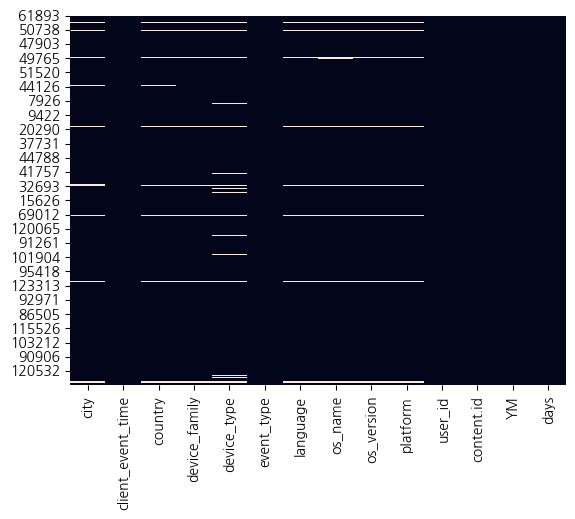

In [ ]:
look_null(start_content)

Text(0.5, 1.0, '월별 콘텐츠 시청 시작 횟수')

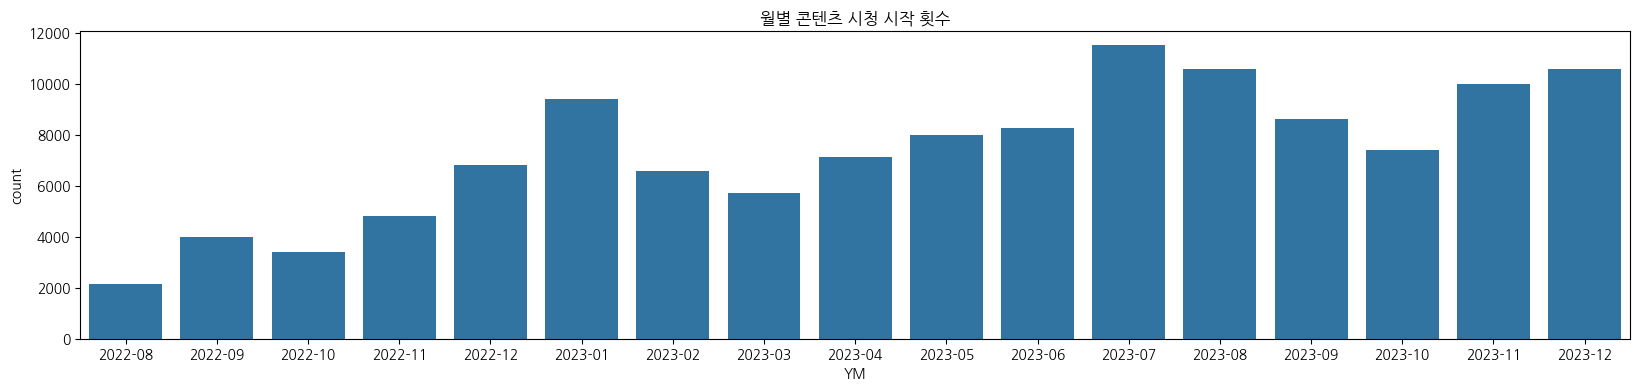

In [ ]:
fig, ax = plt.subplots(figsize = (20,4))
sns.countplot(data = start_content, x = 'YM')
plt.title('월별 콘텐츠 시청 시작 횟수')

In [ ]:
# 콘텐츠 시청 완료
end_content = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\end.content.csv', parse_dates = ['client_event_time'])
end_content.drop('device_carrier', axis = 1, inplace = True)
end_content['YM'] = end_content['client_event_time'].dt.to_period('M')
end_content = end_content[end_content['YM']>'2021-12']
end_content['days'] = end_content['client_event_time'].dt.day
end_content.sort_values(by = 'client_event_time', ascending = True, inplace = True)
end_content.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,YM,days
66683,Ulsan,2022-01-01 01:29:42.752,South Korea,Windows,Windows,end.content,Korean,Chrome,96,Web,b18081d883fd3d9783c9667a570cee4d,7cebec6e79cc981dbf421c5ec2aedd9d,2022-01,1
66684,Seoul,2022-01-01 01:51:08.894,South Korea,Apple iPad,Apple iPad,end.content,Korean,Mobile Safari,13,Web,7c5beabc46ee90cbc84e430d552eda10,ff7998135d650dbefb3f479c900cbcc7,2022-01,1
66685,Guro-gu,2022-01-01 01:58:23.585,South Korea,Windows,Windows,end.content,Korean,Chrome,96,Web,7116215d9924c1abb1e330a0ad20e187,f4be1a0fe0e301b03115591777fddf29,2022-01,1
55549,Anyang-si,2022-01-01 02:27:13.230,South Korea,Windows,Windows,end.content,Korean,Chrome,96,Web,98afda6b716829612357435a6b1c2bd6,f4be1a0fe0e301b03115591777fddf29,2022-01,1
55548,Ulsan,2022-01-01 02:48:53.956,South Korea,Windows,Windows,end.content,Korean,Chrome,96,Web,b18081d883fd3d9783c9667a570cee4d,710ffb5be9f89772b7baa9f62c9c8805,2022-01,1


In [ ]:
end_content.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120582 entries, 66683 to 97301
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   city               116280 non-null  object        
 1   client_event_time  120582 non-null  datetime64[ns]
 2   country            117182 non-null  object        
 3   device_family      119391 non-null  object        
 4   device_type        118866 non-null  object        
 5   event_type         120582 non-null  object        
 6   language           119392 non-null  object        
 7   os_name            119387 non-null  object        
 8   os_version         119362 non-null  object        
 9   platform           119392 non-null  object        
 10  user_id            120582 non-null  object        
 11  content.id         120582 non-null  object        
 12  YM                 120582 non-null  period[M]     
 13  days               120582 non-null  int32     

city                 4302
client_event_time       0
country              3400
device_family        1191
device_type          1716
event_type              0
language             1190
os_name              1195
os_version           1220
platform             1190
user_id                 0
content.id              0
YM                      0
days                    0
dtype: int64


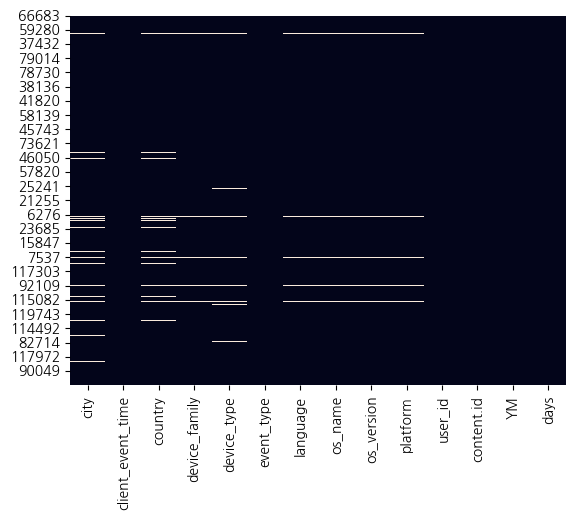

In [ ]:
look_null(end_content)

Text(0.5, 1.0, '월별 콘텐츠 시청 완료 횟수')

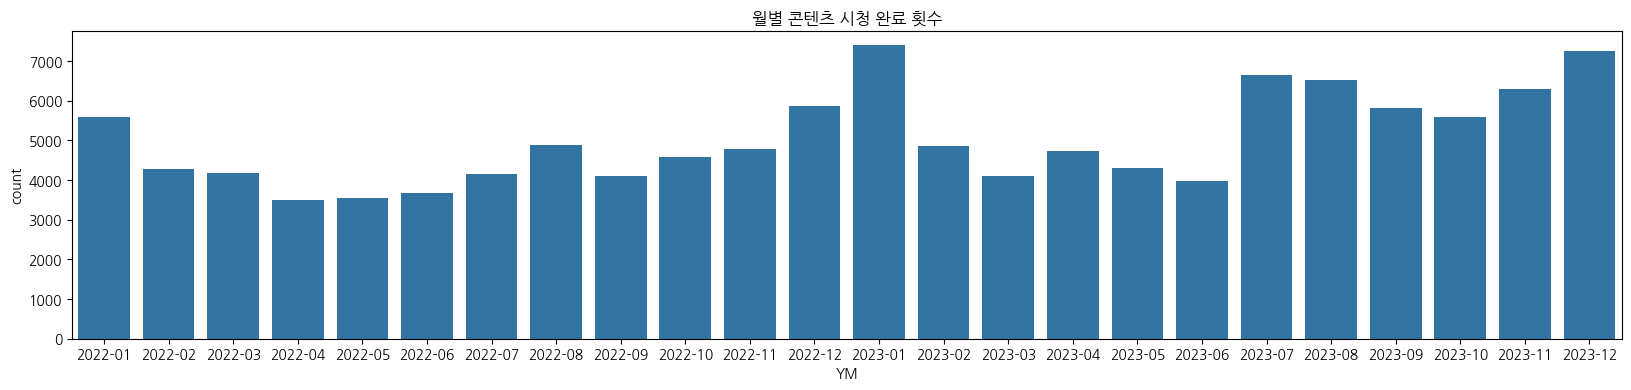

In [ ]:
fig, ax = plt.subplots(figsize = (20,4))
sns.countplot(data = end_content, x = 'YM')
plt.title('월별 콘텐츠 시청 완료 횟수')

In [ ]:
end_content2 = end_content[end_content['YM']>'2022-07']  # 콘텐츠 시청 시작과 날짜 맞추기
content_s = start_content.groupby('YM').size()
content_e = end_content2.groupby('YM').size()
content_fin = pd.concat([content_s, content_e], axis=1)
content_fin.reset_index()
content_fin.rename(columns= {0:'콘텐츠 시청 시작', 1:'콘텐츠 시청 완료'}, inplace=True)
content_fin['index'] = content_fin.index
content_fin['ratio'] = round((content_fin['콘텐츠 시청 완료'] / content_fin['콘텐츠 시청 시작']), 1)
content_fin.head()

,콘텐츠 시청 시작,콘텐츠 시청 완료,index,ratio
YM,,,,
2022-08,2127,4890,2022-08,2.3
2022-09,3981,4110,2022-09,1.0
2022-10,3400,4587,2022-10,1.3
2022-11,4827,4787,2022-11,1.0
2022-12,6821,5865,2022-12,0.9


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


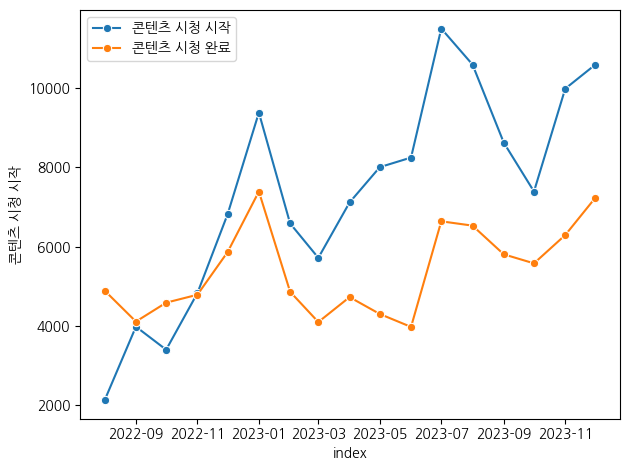

In [ ]:
content_fin['index'] = content_fin['index'].dt.to_timestamp()

sns.lineplot(data = content_fin, x = 'index', y = '콘텐츠 시청 시작', label = '콘텐츠 시청 시작', marker = 'o')
sns.lineplot(data = content_fin, x = 'index', y = '콘텐츠 시청 완료', label = '콘텐츠 시청 완료', marker = 'o')
fig.suptitle('월별 콘텐츠 이용 횟수', fontsize=16)
ax.legend(bbox_to_anchor=(1.06, 1), loc='upper right', borderaxespad=0.)
plt.tight_layout()
plt.show()

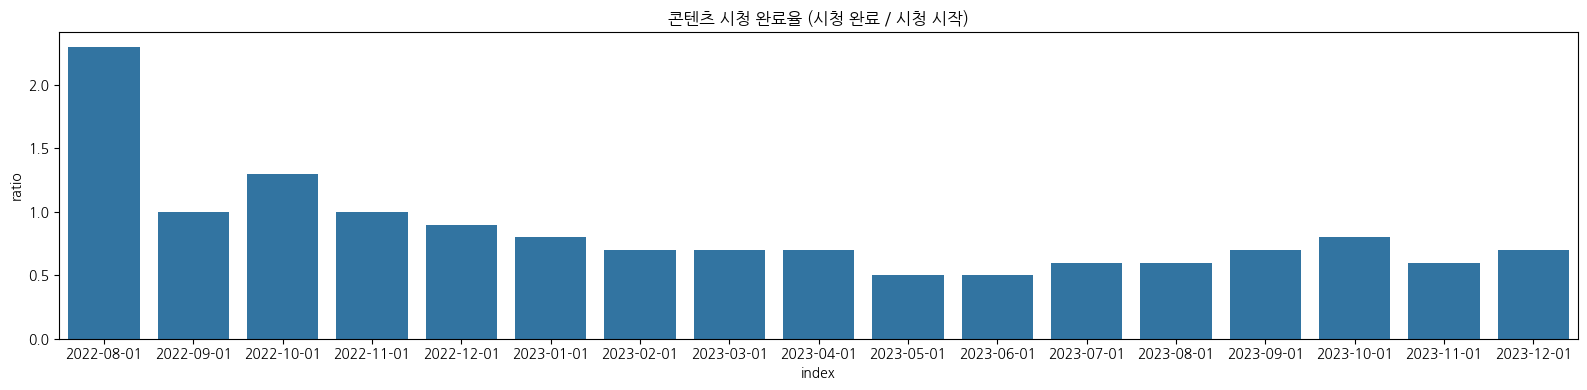

In [ ]:
fig, ax = plt.subplots(figsize = (16,4))
sns.barplot(data = content_fin, x = 'index', y = 'ratio')
plt.title('콘텐츠 시청 완료율 (시청 완료 / 시청 시작)')
plt.tight_layout()
plt.show()

## 에피소드

In [ ]:
# 에피소드 시청 시작
enter_episode = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\enter.episode_page-003.csv', dtype = {'os_version': str, 'is_trial': str, 'is_free_trial': str}, parse_dates = ['client_event_time'])
enter_episode.drop('device_carrier', axis = 1, inplace = True)
enter_episode['YM'] = enter_episode['client_event_time'].dt.to_period('M')
enter_episode = enter_episode[enter_episode['YM']>'2021-12']
enter_episode['days'] = enter_episode['client_event_time'].dt.day
enter_episode.sort_values(by = 'client_event_time', ascending = True, inplace = True)
enter_episode.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,is_trial,episode.id,is_free_trial,YM,days
13933894,Suwon,2022-01-01 00:01:34.047,South Korea,Windows,Windows,enter.episode_page,Korean,Chrome,96,Web,14b81fccc37fe562501cfbf98a5928ce,621c7ad99b17d2d16832b618d47aea7e,NaN,accbf5e61f093c35c2e793feba3fd6aa,NaN,2022-01,1
13933979,Seocho-gu,2022-01-01 00:02:40.687,South Korea,Windows,Windows,enter.episode_page,Korean,Chrome,96,Web,f0a143b4b2771c6d736c2c4581d3b289,101e1d0dcc38d9c86156f008a145083e,NaN,db8d6c7fe8ec23f18a9a2843cd1b8fcb,NaN,2022-01,1
13933895,Nam-gu,2022-01-01 00:02:53.551,South Korea,Windows,Windows,enter.episode_page,Korean,Edge,96,Web,c6991cc646bce25351e3a64ea00ccb1f,7fef928cdccef0185dfb931ef59b37d7,NaN,470e0917d48446715893f68f94a453b7,NaN,2022-01,1
13933945,Hwaseong-si,2022-01-01 00:03:09.056,South Korea,Android,Android,enter.episode_page,Korean,Chrome WebView,90,Web,NaN,c269eb6df3a374b464f7c18f12fa398f,NaN,c2b88e494ee633b334aa081cac7b1f02,NaN,2022-01,1
13933883,Jeonju,2022-01-01 00:03:25.375,South Korea,Android,Android,enter.episode_page,Korean,Chrome,96,Web,86cd970e25ecd9969bd1c7fcca907c72,c269eb6df3a374b464f7c18f12fa398f,NaN,6bfe7d09d6e3b83dfebe6b3a7c233127,NaN,2022-01,1


In [ ]:
enter_episode.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21029133 entries, 13933894 to 16823871
Data columns (total 17 columns):
 #   Column             Dtype         
---  ------             -----         
 0   city               object        
 1   client_event_time  datetime64[ns]
 2   country            object        
 3   device_family      object        
 4   device_type        object        
 5   event_type         object        
 6   language           object        
 7   os_name            object        
 8   os_version         object        
 9   platform           object        
 10  user_id            object        
 11  content.id         object        
 12  is_trial           object        
 13  episode.id         object        
 14  is_free_trial      object        
 15  YM                 period[M]     
 16  days               int32         
dtypes: datetime64[ns](1), int32(1), object(14), period[M](1)
memory usage: 2.7+ GB


In [ ]:
enter_episode.isnull().sum()

city                   540129
client_event_time           0
country                358428
device_family            6482
device_type            141817
event_type                  0
language                    0
os_name                   417
os_version               6367
platform                    0
user_id               1538526
content.id                352
is_trial              7373446
episode.id                  0
is_free_trial        18805375
YM                          0
days                        0
dtype: int64

<Axes: xlabel='YM', ylabel='episode.id'>

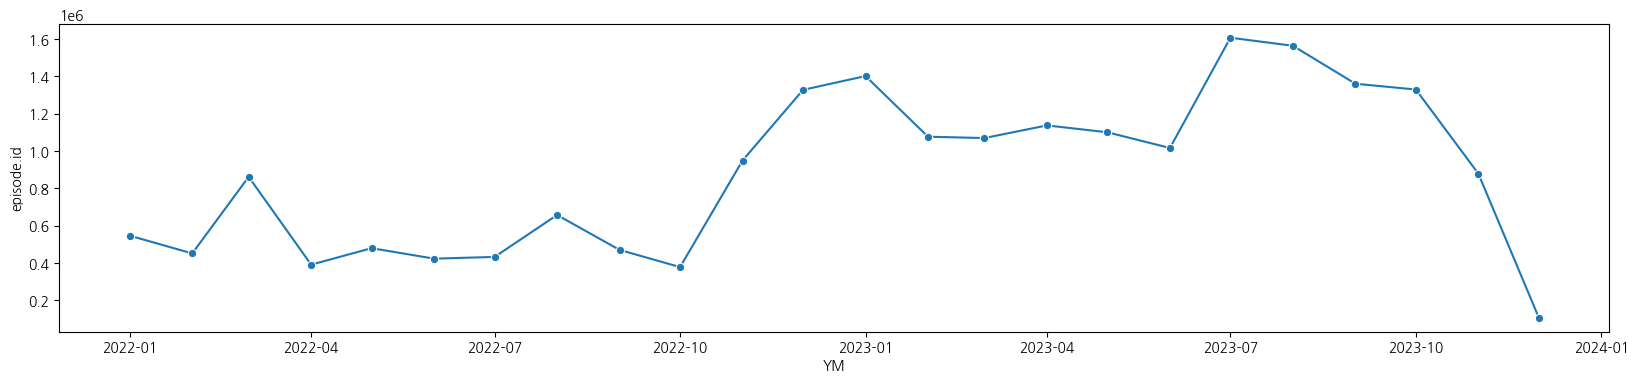

In [ ]:
date_epi = enter_episode.groupby('YM')['episode.id'].size().reset_index()
date_epi['YM'] = date_epi['YM'].dt.to_timestamp()

fig, ax = plt. subplots(figsize = (20,4))
sns.lineplot(data = date_epi, x = 'YM', y = 'episode.id', marker = 'o')

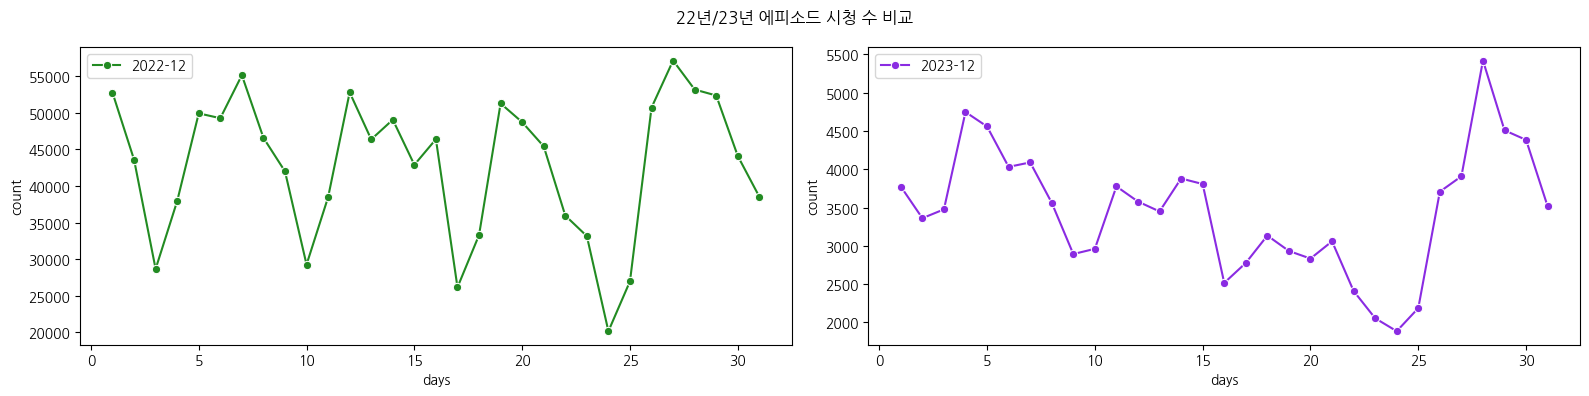

In [ ]:
enter_epi_dec = enter_episode[enter_episode['YM'] == '2023-12']
enter_epi_dec_days = enter_epi_dec.groupby('days').size().reset_index(name = 'count')

enter_epi_dec2 = enter_episode[enter_episode['YM'] == '2022-12']
enter_epi_dec_days2 = enter_epi_dec2.groupby('days').size().reset_index(name = 'count')

fig, ax = plt.subplots(1,2, figsize = (16,4))
sns.lineplot(data = enter_epi_dec_days2, x = 'days', y = 'count', marker = 'o', ax = ax[0], label = '2022-12', c='forestgreen')
sns.lineplot(data = enter_epi_dec_days, x = 'days', y = 'count', marker = 'o', ax = ax[1], label = '2023-12', c = 'blueviolet')
fig.suptitle('22년/23년 에피소드 시청 수 비교')
plt.tight_layout()
plt.show()

In [ ]:
enter_episode_old = pd.read_csv('enter.episode_page.csv',parse_dates = ['client_event_time'], dtype = {'os_version': str, 'is_trial': str, 'is_free_trial': str})
enter_episode_old = enter_episode_old[['client_event_time','user_id','content.id','episode.id']]
enter_episode_old['client_event_time'] = pd.to_datetime(enter_episode_old['client_event_time']) + pd.Timedelta(hours=9)
enter_episode_old

,client_event_time,user_id,content.id,episode.id
0,2023-04-06 06:46:04.333,91053eda0bffb4db6c9317acf15bc44a,94bdcbd9f329aafa84ab464b6721187d,d360d68b65fd3e0eafb7982386d75fd9
1,2023-04-06 06:55:50.787,91053eda0bffb4db6c9317acf15bc44a,94bdcbd9f329aafa84ab464b6721187d,d360d68b65fd3e0eafb7982386d75fd9
2,2023-04-06 06:55:55.684,91053eda0bffb4db6c9317acf15bc44a,94bdcbd9f329aafa84ab464b6721187d,770740696ab1809d6b50d4013b64a75c
3,2023-04-06 06:04:55.828,b2b31f00b82edc6419b25324a7ae41a4,5fc64d786416b980cfda86afd69e4516,68cc362ca81b5899b3c9b4dea0aaddff
4,2023-04-06 06:05:34.139,b2b31f00b82edc6419b25324a7ae41a4,db43a841c994231e2795d4df8931af50,144682f4648f81de8e6aabd11b92105e
...,...,...,...,...
21029702,2023-10-10 14:18:14.053,NaN,c269eb6df3a374b464f7c18f12fa398f,582f0dd769db16a3d920fd7916090efb
21029703,2023-10-10 14:18:58.648,NaN,c269eb6df3a374b464f7c18f12fa398f,83c74d5802b04a1a50aa28b7bf8a5354
21029704,2023-10-10 14:17:45.578,bc1a28ff902daba9399e7f602cc86285,f4be1a0fe0e301b03115591777fddf29,633d1b30ed699e261ea338ad28952338
21029705,2023-10-10 14:18:05.629,bc1a28ff902daba9399e7f602cc86285,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2


In [ ]:
# 중복(동일한 유저가 같은 에피소드를 짧은 시간에 여러 번 누르는 행위)을 없애고 다시 진행
enter_episode_old['date'] = pd.to_datetime(enter_episode_old['client_event_time']).dt.date
enter_episode_old = enter_episode_old.drop_duplicates(subset=['user_id', 'content.id', 'episode.id', 'date'], keep='first')
enter_episode_old['연-월'] = enter_episode_old['client_event_time'].dt.to_period('M')
enter_episode_old

C:\Users\csh94\AppData\Local\Temp\ipykernel_17608\1361672498.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enter_episode_old['연-월'] = enter_episode_old['client_event_time'].dt.to_period('M')


,client_event_time,user_id,content.id,episode.id,date,연-월
0,2023-04-06 06:46:04.333,91053eda0bffb4db6c9317acf15bc44a,94bdcbd9f329aafa84ab464b6721187d,d360d68b65fd3e0eafb7982386d75fd9,2023-04-06,2023-04
2,2023-04-06 06:55:55.684,91053eda0bffb4db6c9317acf15bc44a,94bdcbd9f329aafa84ab464b6721187d,770740696ab1809d6b50d4013b64a75c,2023-04-06,2023-04
3,2023-04-06 06:04:55.828,b2b31f00b82edc6419b25324a7ae41a4,5fc64d786416b980cfda86afd69e4516,68cc362ca81b5899b3c9b4dea0aaddff,2023-04-06,2023-04
4,2023-04-06 06:05:34.139,b2b31f00b82edc6419b25324a7ae41a4,db43a841c994231e2795d4df8931af50,144682f4648f81de8e6aabd11b92105e,2023-04-06,2023-04
5,2023-04-06 06:05:58.498,b2b31f00b82edc6419b25324a7ae41a4,db43a841c994231e2795d4df8931af50,778ff1c69f892a1307fb5ddc64b58546,2023-04-06,2023-04
...,...,...,...,...,...,...
21029701,2023-10-10 14:10:26.984,0117038cc69fe8a40388ec19bb0a495e,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,2023-10-10,2023-10
21029702,2023-10-10 14:18:14.053,NaN,c269eb6df3a374b464f7c18f12fa398f,582f0dd769db16a3d920fd7916090efb,2023-10-10,2023-10
21029704,2023-10-10 14:17:45.578,bc1a28ff902daba9399e7f602cc86285,f4be1a0fe0e301b03115591777fddf29,633d1b30ed699e261ea338ad28952338,2023-10-10,2023-10
21029705,2023-10-10 14:18:05.629,bc1a28ff902daba9399e7f602cc86285,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,2023-10-10,2023-10


In [ ]:
enter_episode_old = enter_episode_old[enter_episode_old['연-월'] >= '2022-01']
enter_episode_old.sort_values(by='client_event_time', inplace=True)

C:\Users\csh94\AppData\Local\Temp\ipykernel_17608\3363504065.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enter_episode_old.sort_values(by='client_event_time', inplace=True)


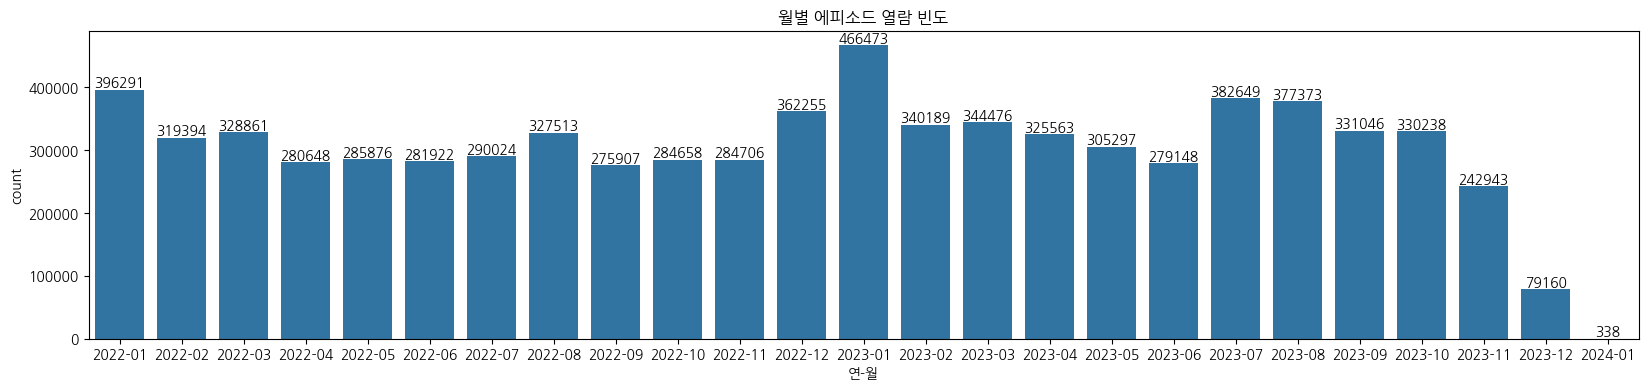

In [ ]:
fig, ax = plt.subplots(figsize=(20,4))
ax = sns.countplot(data = enter_episode_old, x = '연-월')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom')
plt.title("월별 에피소드 열람 빈도")
plt.show()

C:\Users\csh94\AppData\Local\Temp\ipykernel_17608\2667584480.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enter_epi_dec['days'] = enter_epi_dec['client_event_time'].dt.day
C:\Users\csh94\AppData\Local\Temp\ipykernel_17608\2667584480.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enter_epi_dec2['days'] = enter_epi_dec2['client_event_time'].dt.day


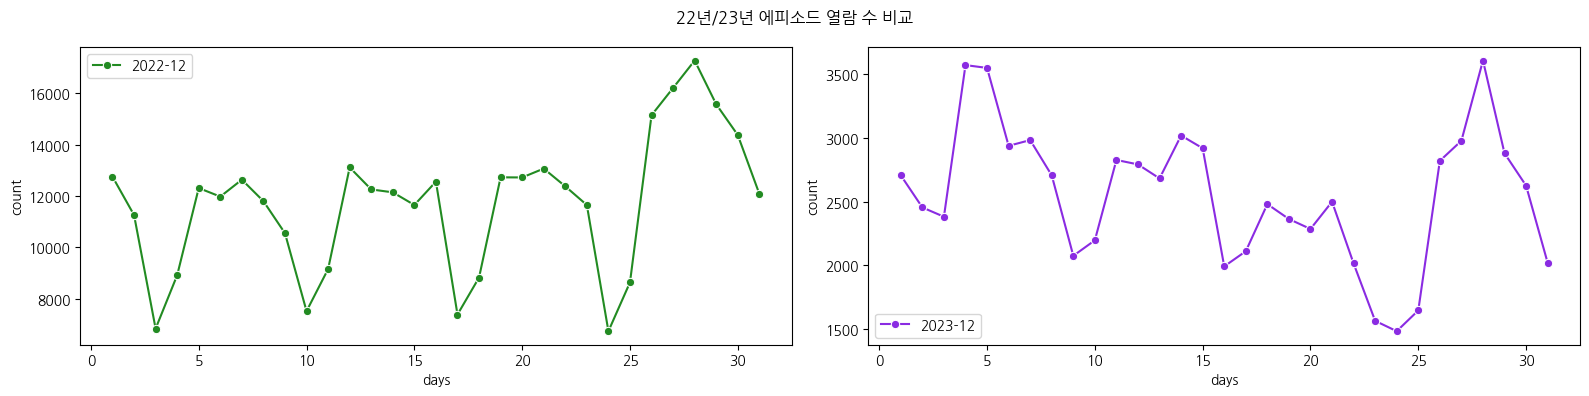

In [ ]:
enter_epi_dec = enter_episode_old[enter_episode_old['연-월'] == '2023-12']
enter_epi_dec['days'] = enter_epi_dec['client_event_time'].dt.day
enter_epi_dec_days = enter_epi_dec.groupby('days').size().reset_index(name = 'count')

enter_epi_dec2 = enter_episode_old[enter_episode_old['연-월'] == '2022-12']
enter_epi_dec2['days'] = enter_epi_dec2['client_event_time'].dt.day
enter_epi_dec_days2 = enter_epi_dec2.groupby('days').size().reset_index(name = 'count')

fig, ax = plt.subplots(1,2, figsize = (16,4))
ax[0] = sns.lineplot(data = enter_epi_dec_days2, x = 'days', y = 'count', marker = 'o', ax = ax[0], label = '2022-12', c='forestgreen')
ax[1] = sns.lineplot(data = enter_epi_dec_days, x = 'days', y = 'count', marker = 'o', ax = ax[1], label = '2023-12', c = 'blueviolet')
fig.suptitle('22년/23년 에피소드 열람 수 비교')

# for x, y in zip(enter_epi_dec_days2['days'], enter_epi_dec_days2['count']):
#     ax[0].text(x, y, f'{y:.0f}', ha='center', va='bottom')

# for x, y in zip(enter_epi_dec_days['days'], enter_epi_dec_days['count']):
#     ax[1].text(x, y, f'{y:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

22년 12월과 23년 12월 패턴은 유사하며 31일까지 데이터도 다 있다. 근데 왜 데이터 수는 5~10배 정도 차이가 난다.
확인 가능한 패턴: 토요일에는 에피소드 시청을 적게 한다. 크리스마스 이브에 가장 에피소드 시청을 적게 한다.

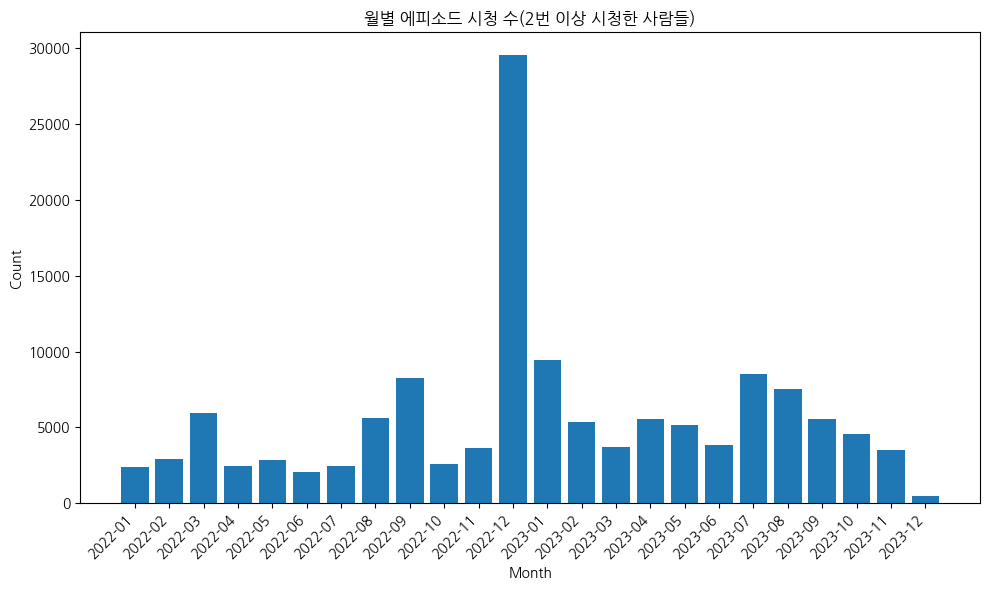

In [ ]:
# 유저 중 월별 한번만 본 횟수는 제외하고 월별 에피소드 시청 횟수

# month와 user_id별로 그룹화하여 개수 세기
grouped = enter_episode.groupby(['YM', 'user_id']).size().reset_index(name='count')

# 2개 이상인 데이터만 필터링
filtered_data = grouped[grouped['count'] >= 2]

# 막대그래프 그리기
plt.figure(figsize=(10, 6))
plt.bar(filtered_data['YM'].astype(str), filtered_data['count'])
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('월별 에피소드 시청 수(2번 이상 시청한 사람들)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
last_watch = enter_episode.drop_duplicates(subset = 'user_id', keep='last')
last_watch.tail()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,is_trial,episode.id,is_free_trial,YM,days
16823866,Gwanak-gu,2023-12-31 23:50:23.321,South Korea,Samsung Phone,Samsung Galaxy S21+ 5G,enter.episode_page,Korean,Samsung Browser,23.0,Web,2ca32996600cb18f9016fb007f068178,4641438a6c81ef572d997dbdc9100f8b,False,5c6494703483d3375174bf8ef9ac1f45,NaN,2023-12,31
16823863,Goyang-si,2023-12-31 23:55:55.453,South Korea,Mac,Mac,enter.episode_page,Korean,Chrome,120.0.0.0,Web,c6def24e210515ce2f59fae968a39d2e,c8e53577758bf66711094352a5abd8c3,False,081bb0b94ee0d817fd28d67b43c6487f,NaN,2023-12,31
16823904,Gimpo-si,2023-12-31 23:57:15.239,South Korea,Samsung Phone,Samsung Galaxy Note20 5G,enter.episode_page,Korean,Instagram,312.1.0.34.111,Web,NaN,f4be1a0fe0e301b03115591777fddf29,False,17e921513ea63e9dafa11cd84eed32b9,NaN,2023-12,31
16823878,Yongheung,2023-12-31 23:57:46.757,South Korea,Windows,Windows,enter.episode_page,Korean,Edge,120.0.0.0,Web,4e75fa4d89e22efaaeb19d7796a1af2b,595cb4bbfc83e683b0314ca1312cfbde,False,8806cdf918568960061f8de337dbbeb5,NaN,2023-12,31
16823871,Seocho-gu,2023-12-31 23:58:48.291,South Korea,Windows,Windows,enter.episode_page,Korean,Chrome,120.0.0.0,Web,7b0e13e15554512df3c5cec123dcea6d,c269eb6df3a374b464f7c18f12fa398f,False,3a83c61c1185e3af22c7cdda5f53a29c,NaN,2023-12,31


In [ ]:
# 첫 결제 기준으로 보기
for user in last_watch['user_id'].unique():
    if user in complete_sub_final['user_id']:
        print(f"{user} 첫 결제일: {complete_sub_final[complete_sub_final['user_id'] == user][complete_sub_final['client_event_time']]}")
        print(f"{user} 마지막 시청일: {last_watch[last_watch['user_id']== user][last_watch['client_event_time']]}\n")

In [ ]:
# 에피소드 시청 완료
complete_episode = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\complete.episode.csv', parse_dates = ['client_event_time'])
complete_episode.drop('device_carrier', axis = 1, inplace = True)
complete_episode['YM'] = complete_episode['client_event_time'].dt.to_period('M')
complete_episode = complete_episode[complete_episode['YM']>'2021-12']
complete_episode['days'] = complete_episode['client_event_time'].dt.day
complete_episode.sort_values(by = 'client_event_time', ascending = True, inplace = True)
complete_episode.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,episode.id,YM,days
3675035,Jung-gu,2022-01-01 00:00:01.181,South Korea,Mac,Mac,complete.episode,Korean,Chrome,96,Web,47c0c5284ff7f86a5ac16a3e6e07593b,afe201c04b426366e0f8e9e2207c78c2,3c8bd57fe0f9ad2ffc626459d1c49a12,2022-01,1
3675036,Nam-gu,2022-01-01 00:02:52.772,South Korea,Windows,Windows,complete.episode,Korean,Edge,96,Web,c6991cc646bce25351e3a64ea00ccb1f,7fef928cdccef0185dfb931ef59b37d7,97aa0241c80ef3345ef794fc747fe72b,2022-01,1
3675037,Nam-gu,2022-01-01 00:06:56.209,South Korea,Windows,Windows,complete.episode,Korean,Edge,96,Web,c6991cc646bce25351e3a64ea00ccb1f,7fef928cdccef0185dfb931ef59b37d7,470e0917d48446715893f68f94a453b7,2022-01,1
3675054,Namyangju,2022-01-01 00:08:04.998,South Korea,Windows,Windows,complete.episode,Korean,Chrome,96,Web,8b4603c99dbd3ec51f40fa2d8e9d9c28,b8d4ec0133e5ce485055bfd69cd28abd,b9fa27ecb3980b9af4219064175c7940,2022-01,1
3675038,Nam-gu,2022-01-01 00:09:32.949,South Korea,Windows,Windows,complete.episode,Korean,Edge,96,Web,c6991cc646bce25351e3a64ea00ccb1f,7fef928cdccef0185dfb931ef59b37d7,0fb878cb98e403f5da3ddbfd325cbc2f,2022-01,1


In [ ]:
complete_episode.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5405069 entries, 3675035 to 4395807
Data columns (total 15 columns):
 #   Column             Dtype         
---  ------             -----         
 0   city               object        
 1   client_event_time  datetime64[ns]
 2   country            object        
 3   device_family      object        
 4   device_type        object        
 5   event_type         object        
 6   language           object        
 7   os_name            object        
 8   os_version         object        
 9   platform           object        
 10  user_id            object        
 11  content.id         object        
 12  episode.id         object        
 13  YM                 period[M]     
 14  days               int32         
dtypes: datetime64[ns](1), int32(1), object(12), period[M](1)
memory usage: 639.2+ MB


city                 189679
client_event_time         0
country              148360
device_family         53035
device_type           80829
event_type                0
language              53014
os_name               53291
os_version            54076
platform              53014
user_id                   0
content.id                0
episode.id                0
YM                        0
days                      0
dtype: int64


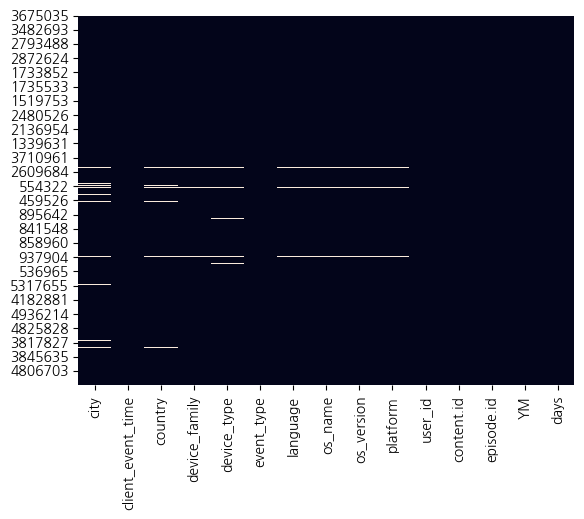

In [ ]:
look_null(complete_episode)

<Axes: xlabel='YM', ylabel='episode.id'>

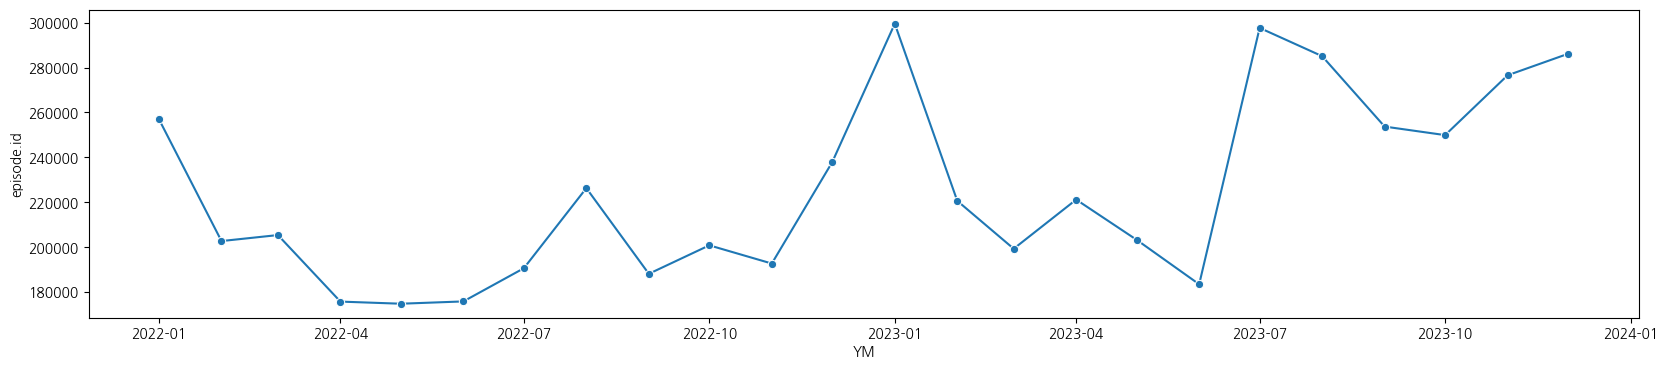

In [ ]:
date_epi_fin = complete_episode.groupby('YM')['episode.id'].size().reset_index()
date_epi_fin['YM'] = date_epi_fin['YM'].dt.to_timestamp()

fig, ax = plt. subplots(figsize = (20,4))
sns.lineplot(data = date_epi_fin, x = 'YM', y = 'episode.id', marker = 'o')

In [ ]:
epi_start = enter_episode.groupby('YM').size()
epi_end = complete_episode.groupby('YM').size()

epi_total = pd.concat([epi_start, epi_end], axis=1)
epi_total.rename(columns= {0:'epi_start', 1:'epi_end'}, inplace=True)
epi_total['time'] = epi_total.index
epi_total['ratio'] = round((epi_total['epi_end'] / epi_total['epi_start']), 1)
epi_total['time'] = epi_total['time'].dt.to_timestamp()
epi_total.head()

,epi_start,epi_end,time,ratio
YM,,,,
2022-01,546893,256977,2022-01-01,0.5
2022-02,451687,202761,2022-02-01,0.4
2022-03,862086,205430,2022-03-01,0.2
2022-04,391550,175809,2022-04-01,0.4
2022-05,479892,174862,2022-05-01,0.4


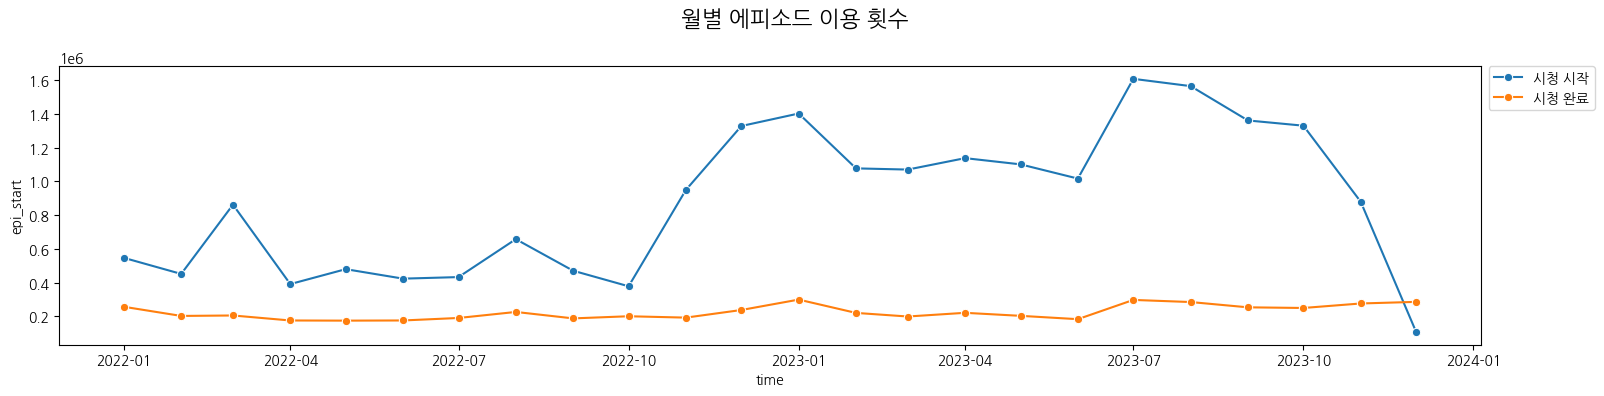

In [ ]:
fig, ax = plt.subplots(figsize=(16,4))
sns.lineplot(data = epi_total, x = 'time', y = 'epi_start', label = '시청 시작', marker = 'o')
sns.lineplot(data = epi_total, x = 'time', y = 'epi_end', label = '시청 완료', marker = 'o')
fig.suptitle('월별 에피소드 이용 횟수', fontsize=16)
ax.legend(bbox_to_anchor=(1.08, 1), loc='upper right', borderaxespad=0.)
plt.tight_layout()
plt.show()

<Axes: xlabel='time', ylabel='ratio'>

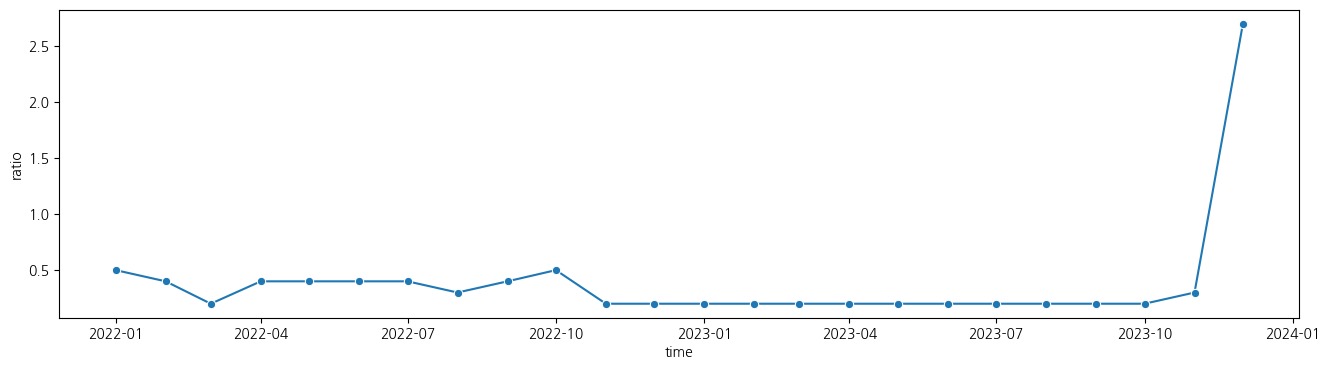

In [ ]:
fig, ax = plt.subplots(figsize=(16,4))
sns.lineplot(data = epi_total, x = 'time', y = 'ratio', marker = 'o')

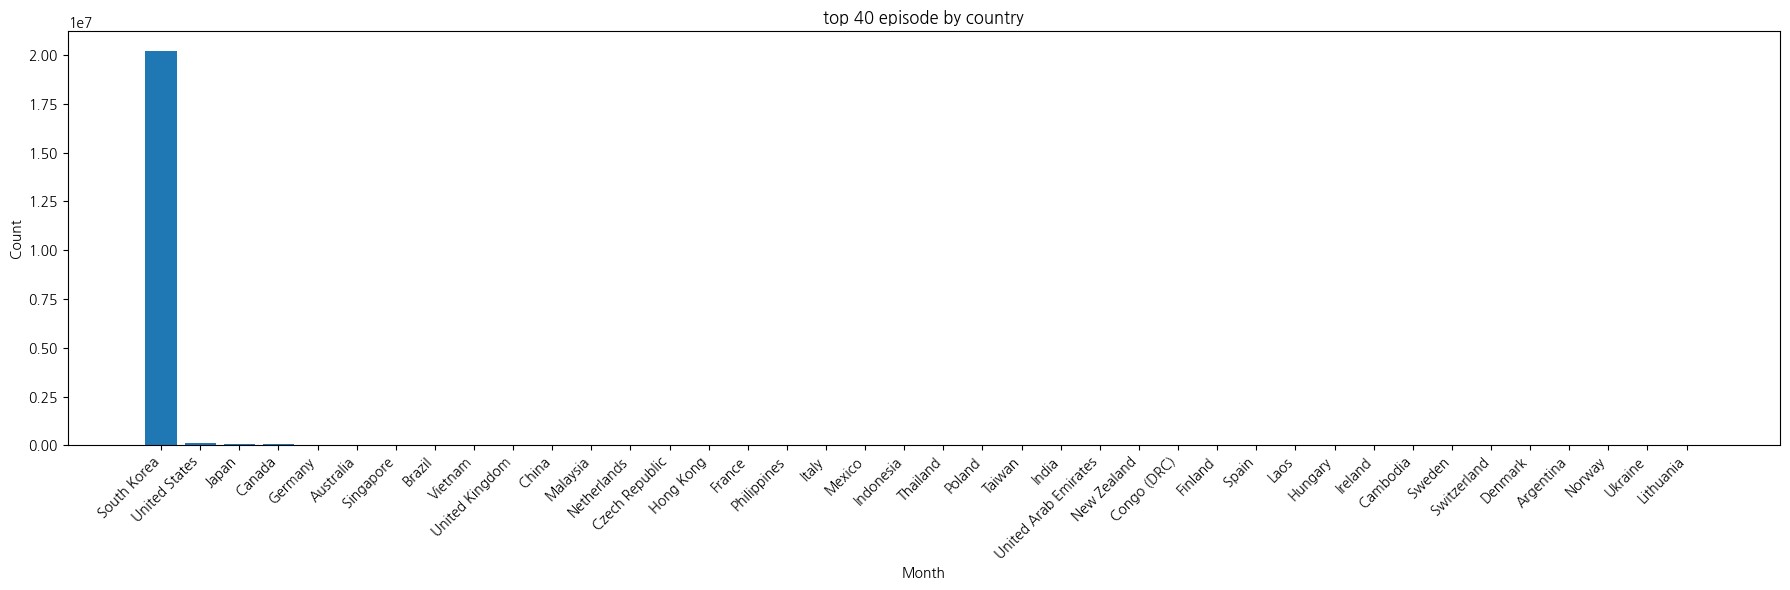

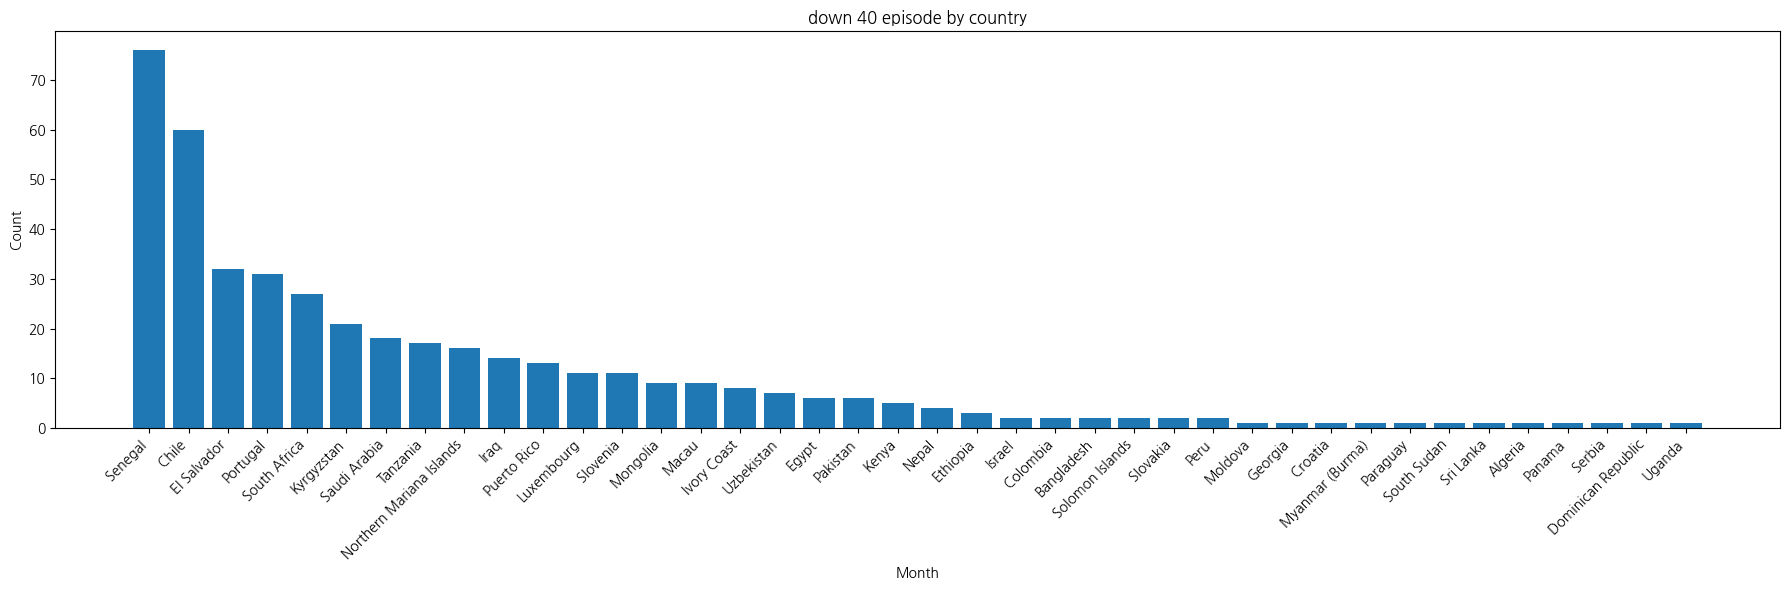

In [ ]:
# 나라별 에피소드 시청 횟수

country_counts = enter_episode['country'].value_counts().reset_index()
top40_country_counts = country_counts.head(40)

# 상위 40 나라별 에피소드 시청 횟수
plt.figure(figsize=(18, 6))
plt.bar(top40_country_counts['country'], top40_country_counts['count'])
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('top 40 episode by country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

down40_country_counts = country_counts.tail(40)

# 하위 40 나라별 에피소드 시청 횟수
plt.figure(figsize=(18, 6))
plt.bar(down40_country_counts['country'], down40_country_counts['count'])
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('down 40 episode by country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

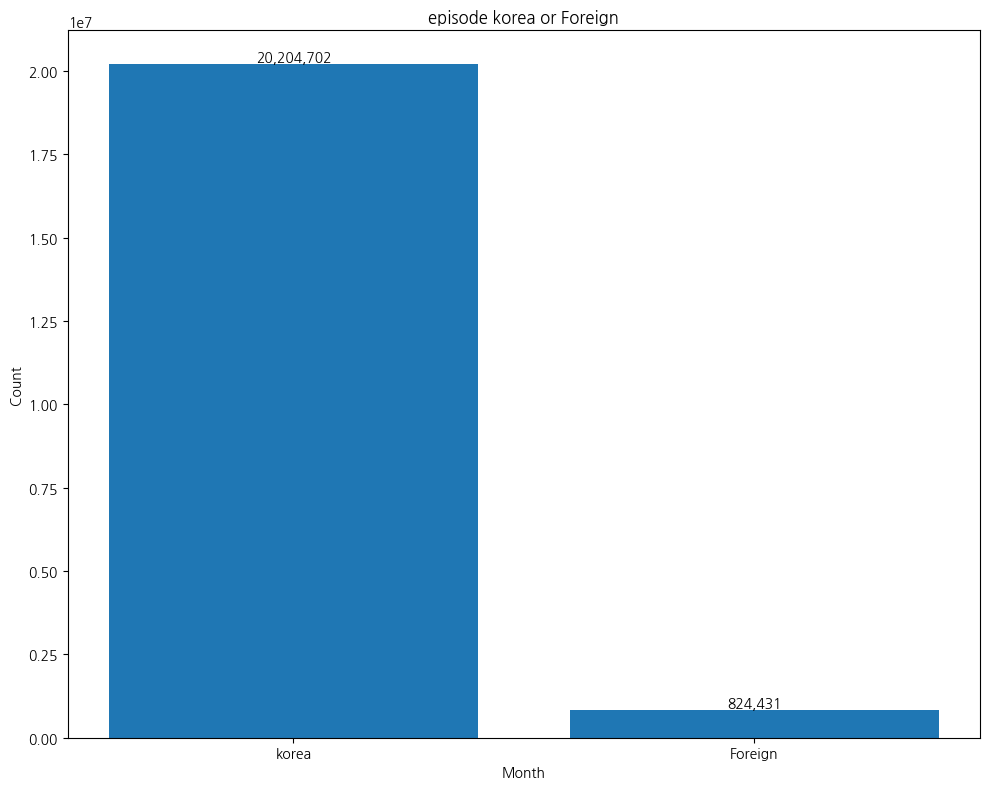

In [ ]:
# 새로운 열 'location' 추가: country가 'South Korea'이면 'Domestic', 아니면 'Foreign'
enter_episode['korea'] = np.where(enter_episode['country'] == 'South Korea', 'korea', 'Foreign')

korea_counts = enter_episode['korea'].value_counts().reset_index()

# 한국과 외국에서 에피소드 시청 횟수
plt.figure(figsize=(10, 8))
bars = plt.bar(korea_counts['korea'], korea_counts['count'])

# 데이터 레이블 추가
for bar in bars:
    yval = bar.get_height()  # 막대의 높이(값) 가져오기
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:,}', 
             ha='center', va='bottom')  # 레이블 추가
    
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('episode korea or Foreign')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

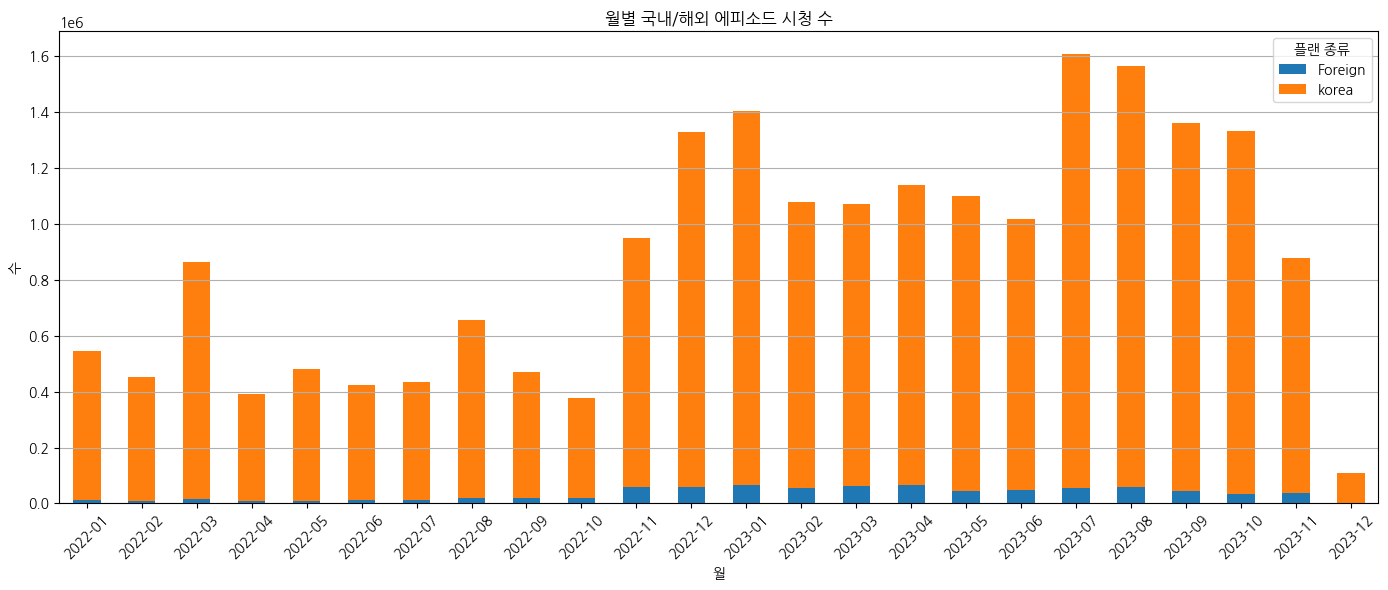

In [ ]:
monthly_counts = enter_episode.groupby([enter_episode['YM'], 'korea']).size().unstack(fill_value=0)

# 그래프 시각화 (figsize를 plot() 내에서 직접 지정)
ax = monthly_counts.plot(kind='bar', stacked=True, figsize=(14, 6))
ax.set_title('월별 국내/해외 에피소드 시청 수')
ax.set_xlabel('월')
ax.set_ylabel('수')
plt.xticks(rotation=45)
plt.legend(title='플랜 종류')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

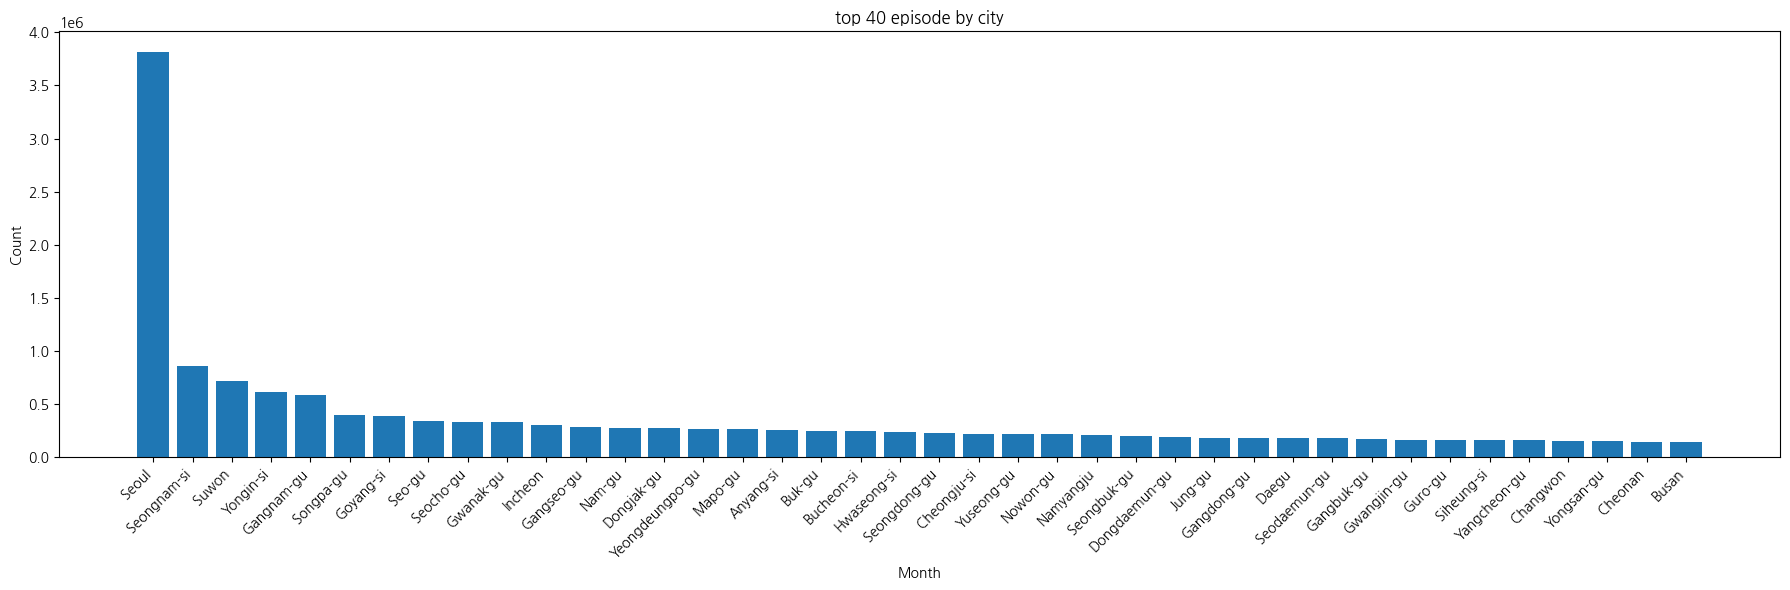

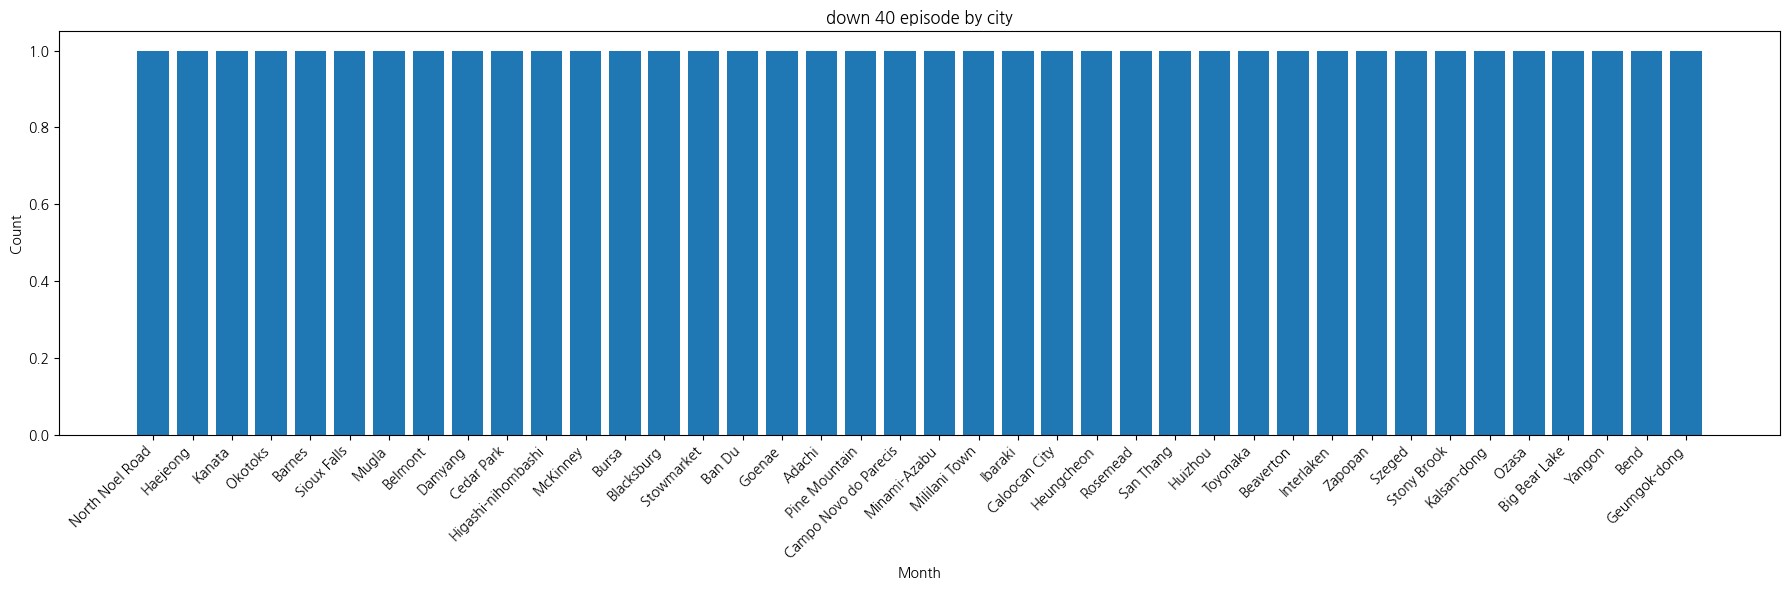

In [ ]:
# 도시별 에피소드 시청 횟수

city_counts = enter_episode['city'].value_counts().reset_index()
top40_city_counts = city_counts.head(40)

# 상위 40 도시별 에피소드 시청 횟수
plt.figure(figsize=(18, 6))
plt.bar(top40_city_counts['city'], top40_city_counts['count'])
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('top 40 episode by city')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

down40_city_counts = city_counts.tail(40)

# 하위 40 도시별 에피소드 시청 횟수
plt.figure(figsize=(18, 6))
plt.bar(down40_city_counts['city'], down40_city_counts['count'])
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('down 40 episode by city')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# 에피소드 댓글 보기
click_episode_comment = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\click.episode_page_related_comment_box.csv', parse_dates = ['client_event_time'])
click_episode_comment.drop('device_carrier', axis = 1, inplace = True)
click_episode_comment['YM'] = click_episode_comment['client_event_time'].dt.to_period('M')
click_episode_comment = click_episode_comment[click_episode_comment['YM']>'2021-12']
click_episode_comment['days'] = click_episode_comment['client_event_time'].dt.day
click_episode_comment.sort_values(by = 'client_event_time', ascending = True, inplace = True)
click_episode_comment.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,comment.id,content.id,episode.id,YM,days
1127953,Los Angeles,2022-01-01 00:08:23.144,United States,Windows,Windows,click.episode_page_related_comment_box,Korean,Chrome,96,Web,0464280c37522b57bc889e05ac52ae56,NaN,NaN,NaN,2022-01,1
1127954,Los Angeles,2022-01-01 00:08:24.306,United States,Windows,Windows,click.episode_page_related_comment_box,Korean,Chrome,96,Web,0464280c37522b57bc889e05ac52ae56,NaN,NaN,NaN,2022-01,1
1127955,Los Angeles,2022-01-01 00:08:26.411,United States,Windows,Windows,click.episode_page_related_comment_box,Korean,Chrome,96,Web,0464280c37522b57bc889e05ac52ae56,NaN,NaN,NaN,2022-01,1
1127956,Los Angeles,2022-01-01 00:08:37.110,United States,Windows,Windows,click.episode_page_related_comment_box,Korean,Chrome,96,Web,0464280c37522b57bc889e05ac52ae56,NaN,NaN,NaN,2022-01,1
1127957,Los Angeles,2022-01-01 00:08:57.158,United States,Windows,Windows,click.episode_page_related_comment_box,Korean,Chrome,96,Web,0464280c37522b57bc889e05ac52ae56,NaN,NaN,NaN,2022-01,1


In [ ]:
click_episode_comment.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1378988 entries, 1127953 to 1244830
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   city               1355527 non-null  object        
 1   client_event_time  1378988 non-null  datetime64[ns]
 2   country            1364097 non-null  object        
 3   device_family      1378987 non-null  object        
 4   device_type        1372654 non-null  object        
 5   event_type         1378988 non-null  object        
 6   language           1378988 non-null  object        
 7   os_name            1378987 non-null  object        
 8   os_version         1378775 non-null  object        
 9   platform           1378988 non-null  object        
 10  user_id            1326085 non-null  object        
 11  comment.id         824789 non-null   object        
 12  content.id         824788 non-null   object        
 13  episode.id         824789 

city                  23461
client_event_time         0
country               14891
device_family             1
device_type            6334
event_type                0
language                  0
os_name                   1
os_version              213
platform                  0
user_id               52903
comment.id           554199
content.id           554200
episode.id           554199
YM                        0
days                      0
dtype: int64


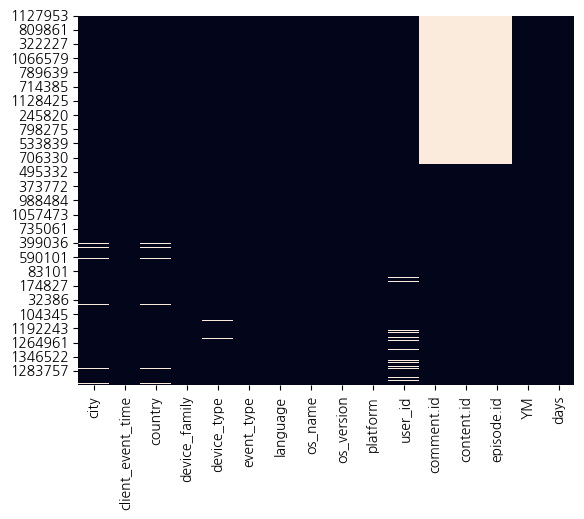

In [ ]:
look_null(click_episode_comment)

## 구독 갱신 및 재구독

In [ ]:
# 구독 갱신
renew_sub = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\renew.subscription.csv', parse_dates = ['client_event_time'])
renew_sub.drop('device_carrier', axis = 1, inplace = True)
renew_sub['YM'] = renew_sub['client_event_time'].dt.to_period('M')
renew_sub = renew_sub[renew_sub['YM']>'2021-12']
renew_sub['days'] = renew_sub['client_event_time'].dt.day
renew_sub.sort_values(by = 'client_event_time', ascending = True, inplace = True)
renew_sub.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,membership.price,plan.type,paid_amount,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,YM,days
0,Nam-gu,2022-09-08 03:05:02.068,South Korea,Windows,Windows,renew.subscription,Korean,Edge,104,Web,6ddea3af2eaae869861c1190dcc9d4a3,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2022-09,8
1,Nam-gu,2022-09-08 03:40:02.050,South Korea,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,c2d47034960fdff5df495822ff66fbc1,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2022-09,8
2,Dongjak-gu,2022-09-08 03:49:00.829,South Korea,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,de91f1226dd938990fefc79545daf468,42960,3개월 플랜,40812,REWARD,DISCOUNT,2148,NaN,2022-09,8
3,Yongin-si,2022-09-08 04:10:06.406,South Korea,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,bf14840a8cb4643e6d557da96e35a3af,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2022-09,8
4,Dongjak-gu,2022-09-08 04:40:01.895,South Korea,Android,Android,renew.subscription,Korean,Chrome Mobile,103,Web,7ddc1c2990d0645d82885394e3c518b5,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2022-09,8


In [ ]:
renew_sub[renew_sub['user_id'] == 'c2d47034960fdff5df495822ff66fbc1']

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,membership.price,plan.type,paid_amount,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,YM,days
1,Nam-gu,2022-09-08 03:40:02.050,South Korea,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,c2d47034960fdff5df495822ff66fbc1,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2022-09,8
1135,Gijang-gun,2022-10-08 03:45:01.734,South Korea,Windows,Windows,renew.subscription,Korean,Chrome,105,Web,c2d47034960fdff5df495822ff66fbc1,15920,1개월 플랜,7960,OPERATION,DISCOUNT,7960,NaN,2022-10,8
10455,Seoul,2023-08-17 08:30:01.293,South Korea,Mac,Mac,renew.subscription,Korean,Safari,16.5.2,Web,c2d47034960fdff5df495822ff66fbc1,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2023-08,17
11673,Geumjeong-gu,2023-09-17 08:35:02.707,South Korea,Windows,Windows,renew.subscription,Korean,Whale,3.21.192.18,Web,c2d47034960fdff5df495822ff66fbc1,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2023-09,17


In [ ]:
renew_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15945 entries, 0 to 15944
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    15575 non-null  object        
 1   client_event_time       15945 non-null  datetime64[ns]
 2   country                 15656 non-null  object        
 3   device_family           15657 non-null  object        
 4   device_type             15484 non-null  object        
 5   event_type              15945 non-null  object        
 6   language                15657 non-null  object        
 7   os_name                 15654 non-null  object        
 8   os_version              15644 non-null  object        
 9   platform                15657 non-null  object        
 10  user_id                 15945 non-null  object        
 11  membership.price        15945 non-null  int64         
 12  plan.type               15945 non-null  object

city                        370
client_event_time             0
country                     289
device_family               288
device_type                 461
event_type                    0
language                    288
os_name                     291
os_version                  301
platform                    288
user_id                       0
membership.price              0
plan.type                     0
paid_amount                   0
coupon.type               14624
coupon.benefit_type       14624
coupon.discount_amount        0
pg.type                   13213
YM                            0
days                          0
dtype: int64


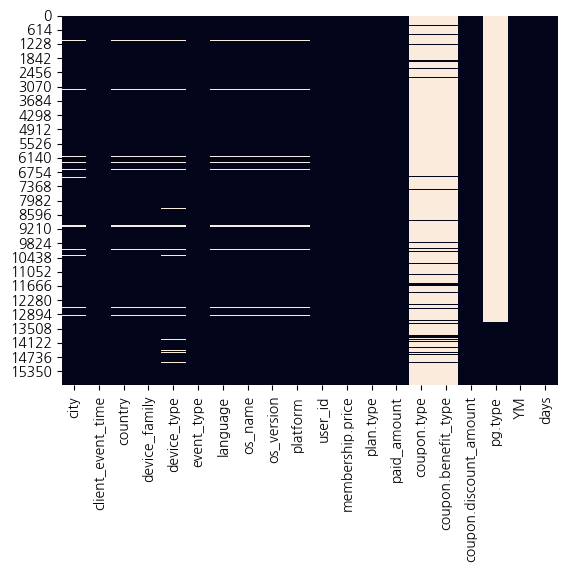

In [ ]:
look_null(renew_sub)

Text(0.5, 1.0, '월별 구독갱신 횟수')

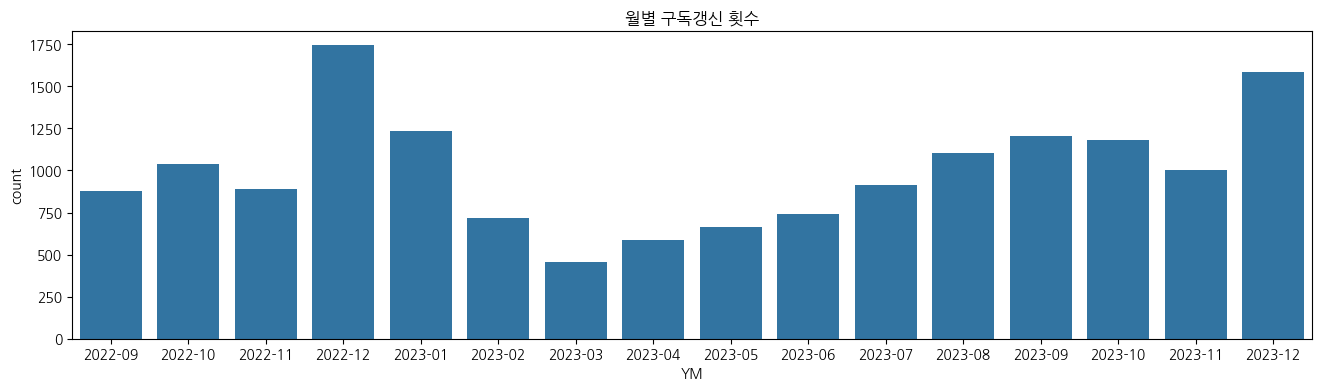

In [ ]:
fig, ax = plt.subplots(figsize = (16,4))
sns.countplot(data = renew_sub, x = 'YM')
plt.title('월별 구독갱신 횟수')

데이터가 22년 9월부터 존재

In [ ]:
customers_cohort = renew_sub.copy()
customers_cohort['OrderPeriod'] = customers_cohort['client_event_time'].dt.strftime('%Y-%m')

customers_cohort.set_index('user_id', inplace = True)

customers_cohort['CohortGroup'] = customers_cohort.groupby(level = 0)['OrderPeriod'].min()
customers_cohort.reset_index(inplace = True)

# CohortGroup & OrderPeriod
grouped = customers_cohort.groupby(['CohortGroup', 'OrderPeriod'])

cohorts = grouped.agg(DistinctUser = ('user_id', 'nunique'), # pd.Series.nunique, # DISTINCT COUNT
                      TotalUsers = ('user_id', 'count'))
                    #    'user_id': count})
                    #    'TotalCharges': np.sum}) # SUM
cohorts

DistinctUser  TotalUsers
CohortGroup OrderPeriod                          
2022-09     2022-09               877         879
            2022-10               445         445
            2022-11               313         313
            2022-12               329         337
            2023-01               191         192
...                               ...         ...
2023-10     2023-11               205         206
            2023-12               133         133
2023-11     2023-11               250         254
            2023-12               136         136
2023-12     2023-12               700         706

[136 rows x 2 columns]

In [ ]:
def cohort_period(df):
    df['CohortPeriod'] = np.arange(len(df)) + 1
    return df

cohorts = cohort_period(cohorts)

In [ ]:
# 첫 구매월에 따른 유저 수 계산
cohort_group_size = cohorts['DistinctUser'].groupby(level=0).first()

# 리텐션 비율 계산
user_retention = cohorts['DistinctUser'].unstack(0).divide(cohort_group_size, axis=1)
user_retention

CohortGroup,2022-09,2022-10,2022-11,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
OrderPeriod,,,,,,,,,,,,,,,,
2022-09,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-10,0.507412,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-11,0.356899,0.350254,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-12,0.375143,0.257191,0.283379,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01,0.217788,0.309645,0.144414,0.136775,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02,0.152794,0.108291,0.237057,0.081522,0.028302,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03,0.147092,0.069374,0.040872,0.073370,0.025157,0.129747,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-04,0.107184,0.128596,0.040872,0.045290,0.022013,0.088608,0.307087,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-05,0.100342,0.057530,0.122616,0.035326,0.007862,0.056962,0.165354,0.566667,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


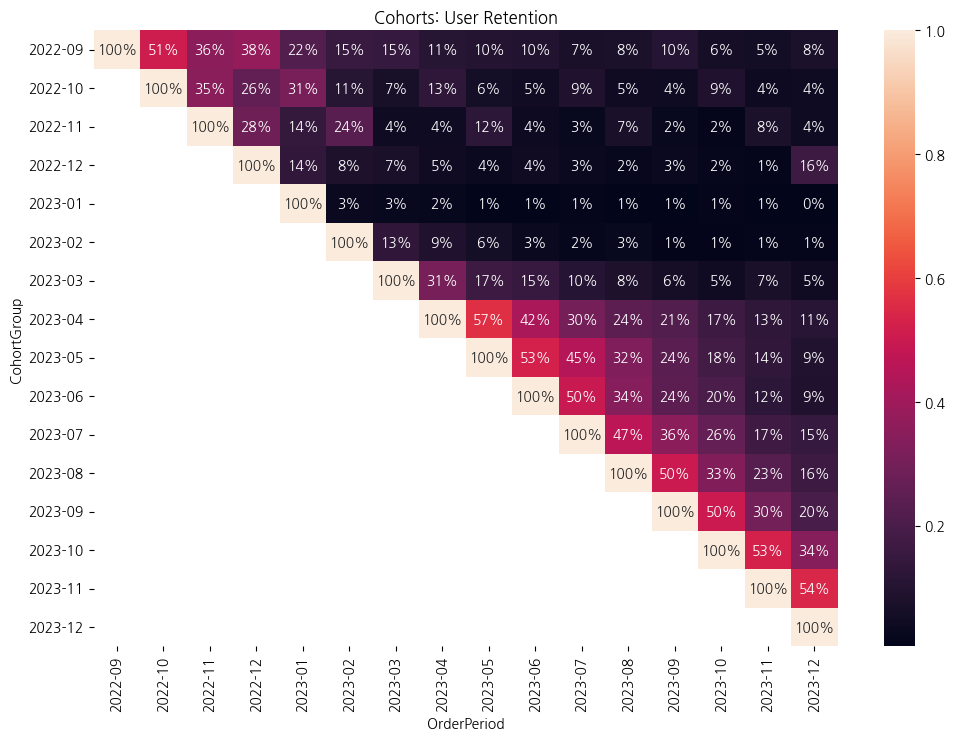

In [ ]:
plt.figure(figsize=(12, 8))
plt.title('Cohorts: User Retention')
sns.heatmap(user_retention.T, mask=user_retention.T.isnull(), annot=True, fmt='.0%')
plt.show()

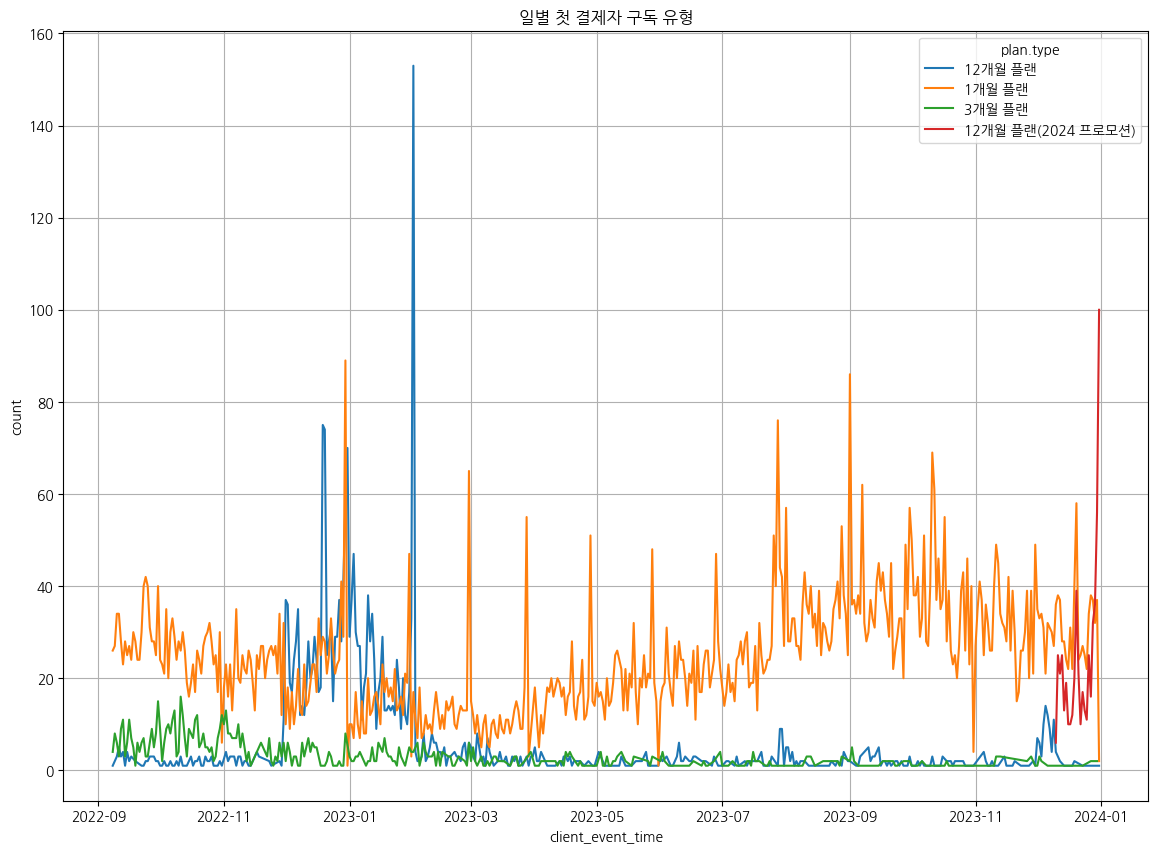

In [ ]:
import matplotlib.dates as mdates

plan_renew = renew_sub.groupby([renew_sub['client_event_time'].dt.date, 'plan.type']).size().reset_index(name = 'count')

plt.figure(figsize = (14, 10))
sns.lineplot(data = plan_renew, x = 'client_event_time', y = 'count', hue = 'plan.type')

plt.title("일별 첫 결제자 구독 유형")
plt.grid(True)

plt.show()

In [ ]:
# 만료 후 재구독
resubscribe = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\resubscribe.subscription.csv', parse_dates = ['client_event_time'])
resubscribe.drop('device_carrier', axis = 1, inplace = True)
resubscribe['YM'] = resubscribe['client_event_time'].dt.to_period('M')
resubscribe = resubscribe[resubscribe['YM']>'2021-12']
resubscribe['days'] = resubscribe['client_event_time'].dt.day
resubscribe.sort_values(by = 'client_event_time', ascending = True, inplace = True)
resubscribe.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,plan.type,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,YM,days
209,Jung-gu,2022-09-08 05:42:29.912,South Korea,Windows,Windows,resubscribe.subscription,Korean,Chrome,105,Web,af3b13bc0841b358adcdedf3e8822795,42960,42960,3개월 플랜,NaN,NaN,0,NaN,2022-09,8
265,Seongnam-si,2022-09-08 12:59:39.784,South Korea,Windows,Windows,resubscribe.subscription,Korean,Chrome,105,Web,692b648a6fe4672c5110d4bf4bee6124,131600,131600,12개월 플랜,NaN,NaN,0,NaN,2022-09,8
308,Nam-gu,2022-09-11 10:09:55.410,South Korea,Windows,Windows,resubscribe.subscription,Korean,Chrome,105,Web,b8f7d2dd6ce017a81efe233fcbbc9c94,15920,15920,1개월 플랜,NaN,NaN,0,NaN,2022-09,11
217,Seoul,2022-09-11 21:00:55.389,South Korea,Mac,Mac,resubscribe.subscription,English,Chrome,104,Web,86936253fcc9539e77725369e21f99db,15920,15124,1개월 플랜,REWARD,DISCOUNT,796,NaN,2022-09,11
228,Hwaseong-si,2022-09-12 02:09:15.193,South Korea,Windows,Windows,resubscribe.subscription,Korean,Chrome,105,Web,308ee0950741e4321045d0ba604778de,131600,78960,12개월 플랜,EMPLOYEE,DISCOUNT,52640,NaN,2022-09,12


In [ ]:
resubscribe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 791 entries, 209 to 431
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    775 non-null    object        
 1   client_event_time       791 non-null    datetime64[ns]
 2   country                 784 non-null    object        
 3   device_family           784 non-null    object        
 4   device_type             773 non-null    object        
 5   event_type              791 non-null    object        
 6   language                784 non-null    object        
 7   os_name                 784 non-null    object        
 8   os_version              784 non-null    object        
 9   platform                784 non-null    object        
 10  user_id                 791 non-null    object        
 11  plan.price              791 non-null    int64         
 12  paid_amount             791 non-null    int64        

city                       16
client_event_time           0
country                     7
device_family               7
device_type                18
event_type                  0
language                    7
os_name                     7
os_version                  7
platform                    7
user_id                     0
plan.price                  0
paid_amount                 0
plan.type                   0
coupon.type               700
coupon.benefit_type       700
coupon.discount_amount      0
pg.type                   618
YM                          0
days                        0
dtype: int64


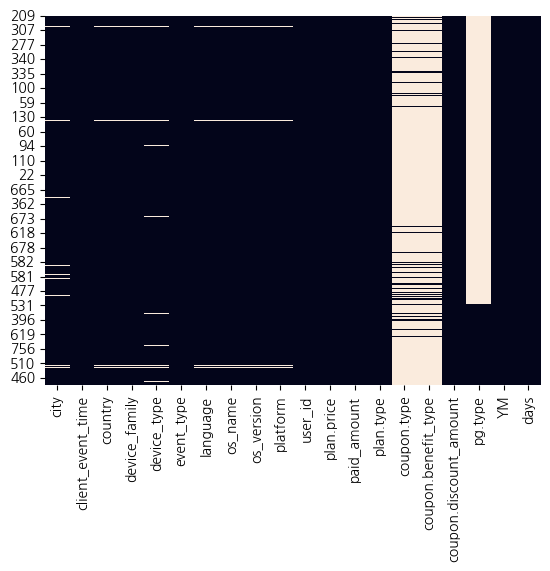

In [ ]:
look_null(resubscribe)

Text(0.5, 1.0, '월별 재구독 횟수')

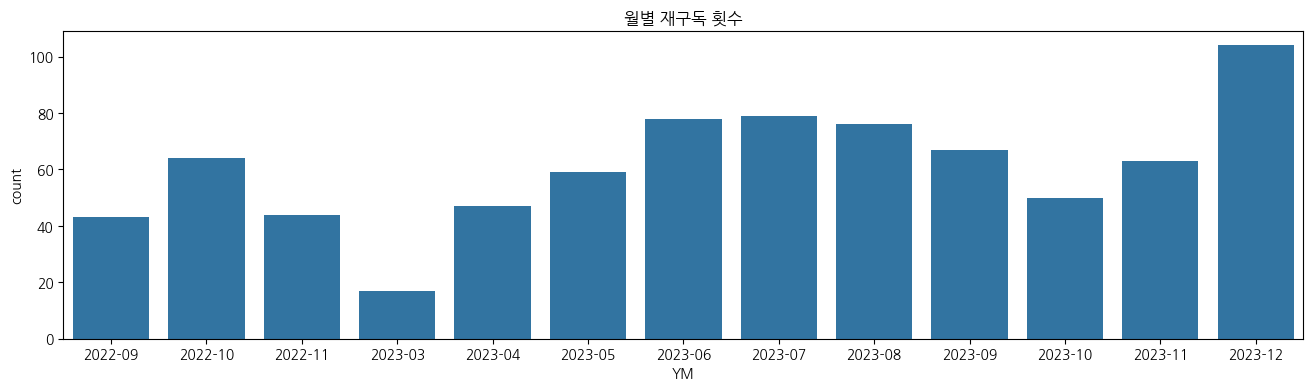

In [ ]:
fig, ax = plt.subplots(figsize = (16,4))
sns.countplot(data = resubscribe, x = 'YM')
plt.title('월별 재구독 횟수')

22년 9월 데이터부터 존재, 22년 12월~23년 2월 데이터가 없음.

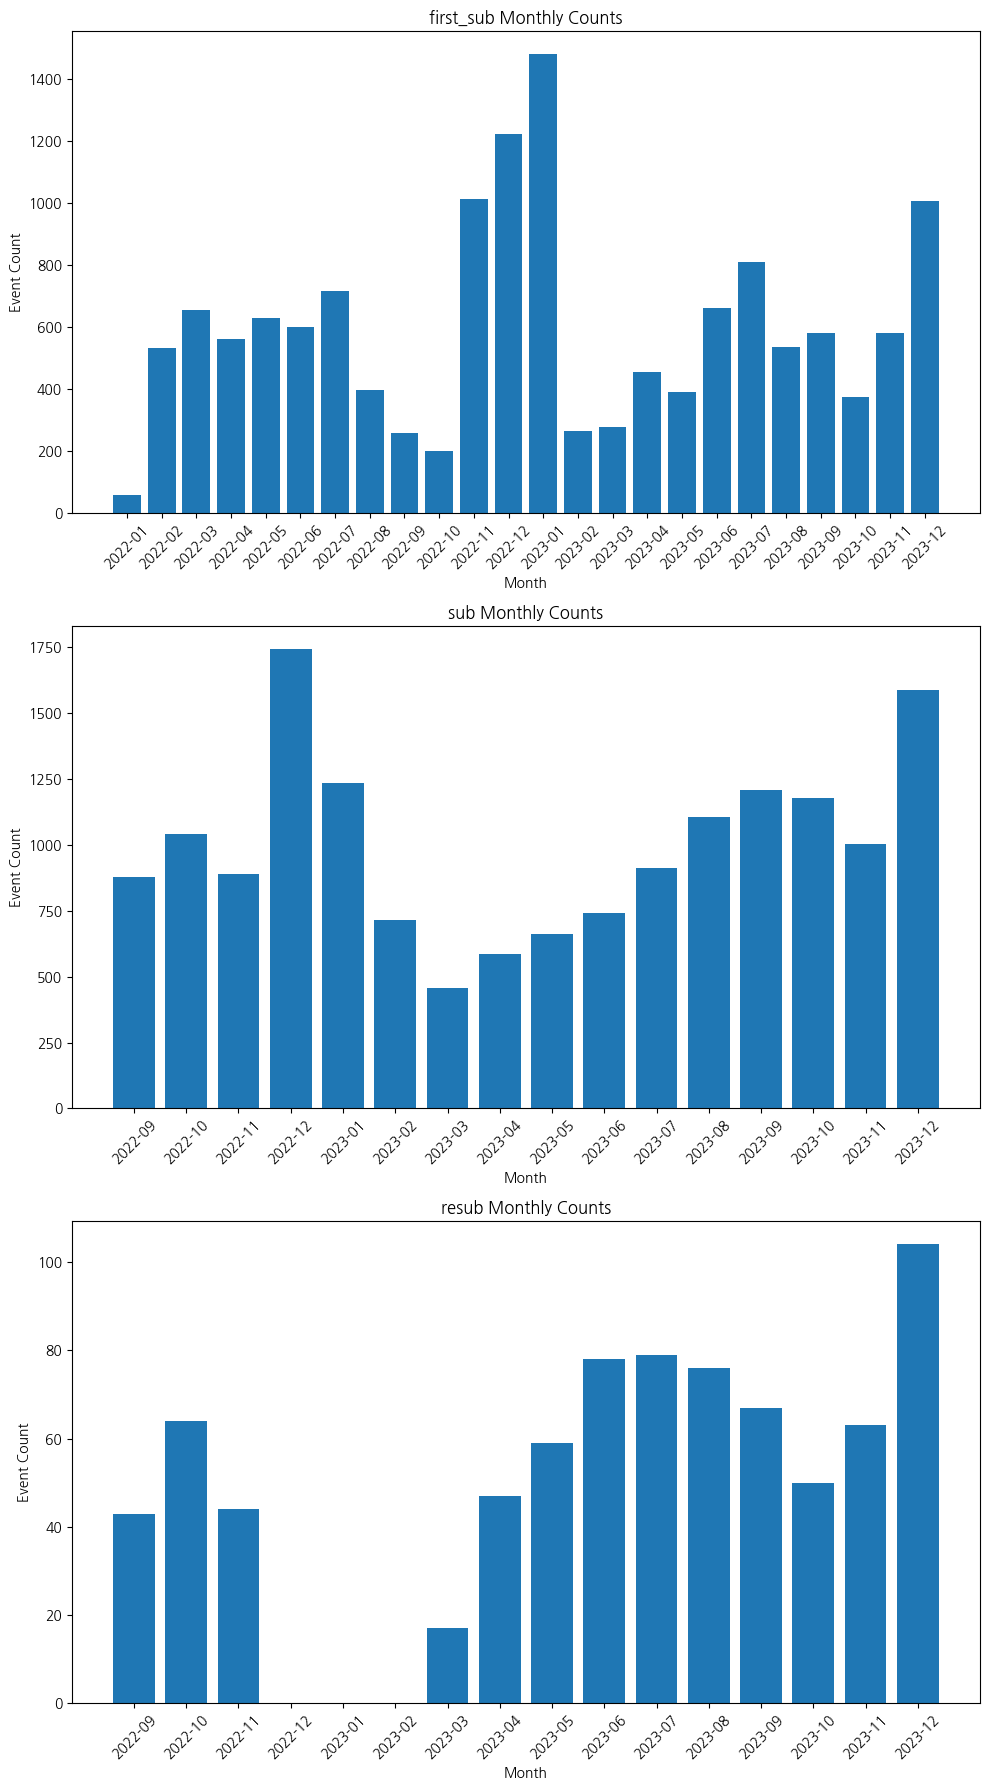

In [ ]:
# 데이터 처리 및 그래프 그리는 함수
def plot_monthly_counts(data, ax, title):
    # client_event_time을 datetime 형식으로 변환
    data['client_event_time'] = pd.to_datetime(data['client_event_time'])
    
    # 월별 데이터 수 집계
    data['YM'] = data['client_event_time'].dt.to_period('M')
    monthly_counts = data['YM'].value_counts().sort_index()

    # 모든 월을 포함하는 인덱스 생성 (최소값과 최대값 사이의 모든 월)
    all_months = pd.period_range(start=data['YM'].min(), end=data['YM'].max(), freq='M')
    
    # reindex를 사용하여 데이터가 없는 월을 0으로 채움
    monthly_counts = monthly_counts.reindex(all_months, fill_value=0)

    # 막대 그래프 그리기
    ax.bar(monthly_counts.index.astype(str), monthly_counts.values)
    ax.set_xlabel('Month')
    ax.set_ylabel('Event Count')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)

# 서브플롯 설정
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# 각 데이터셋에 대해 그래프 그리기
plot_monthly_counts(complete_sub, axes[0], 'first_sub Monthly Counts')
plot_monthly_counts(renew_sub, axes[1], 'sub Monthly Counts')
plot_monthly_counts(resubscribe, axes[2], 'resub Monthly Counts')

# 레이아웃 조정
plt.tight_layout()
plt.show()

## 구독 취소

In [ ]:
# 구독 취소
click_cancel = pd.read_csv('C:\\Users\\csh94\\Desktop\\코드잇\\프로젝트\\중급 프로젝트\\주제 2. 구독서비스 프로덕트 데이터 분석\\click.cancel_plan_button.csv', parse_dates = ['client_event_time'])
click_cancel.drop('device_carrier', axis = 1, inplace = True)
click_cancel['YM'] = click_cancel['client_event_time'].dt.to_period('M')
click_cancel = click_cancel[click_cancel['YM']>'2021-12']
click_cancel['days'] = click_cancel['client_event_time'].dt.day
click_cancel.sort_values(by = 'client_event_time', ascending = True, inplace = True)
click_cancel.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,YM,days
8952,Seoul,2022-01-01 02:24:46.052,South Korea,Apple iPhone,Apple iPhone,click.cancel_plan_button,Korean,Mobile Safari,15,Web,68e930a914ca4ae8d6420d1bd574c86b,2022-01,1
6662,Gimhae,2022-01-01 03:24:30.803,South Korea,Mac,Mac,click.cancel_plan_button,Korean,Chrome,96,Web,6e8a6f3ae9c0466bed9601a0498a70cd,2022-01,1
6663,Seoul,2022-01-01 03:48:36.585,South Korea,Apple iPhone,Apple iPhone,click.cancel_plan_button,Korean,Mobile Safari,15,Web,4416575830d35be30dff53b5aace4d2e,2022-01,1
7535,Yongin-si,2022-01-01 04:19:07.626,South Korea,Windows,Windows,click.cancel_plan_button,Korean,Edge,96,Web,0805ef7130202a6ad61e31141cfea7dc,2022-01,1
5206,Yeonggwang-gun,2022-01-01 05:18:15.569,South Korea,Apple iPhone,Apple iPhone,click.cancel_plan_button,English,Chrome Mobile,96,Web,6d1d8da611dd360f03815576e82ae0b2,2022-01,1


In [ ]:
click_cancel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17894 entries, 8952 to 13629
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   city               17741 non-null  object        
 1   client_event_time  17894 non-null  datetime64[ns]
 2   country            17892 non-null  object        
 3   device_family      17894 non-null  object        
 4   device_type        17566 non-null  object        
 5   event_type         17894 non-null  object        
 6   language           17894 non-null  object        
 7   os_name            17894 non-null  object        
 8   os_version         17891 non-null  object        
 9   platform           17894 non-null  object        
 10  user_id            16852 non-null  object        
 11  YM                 17894 non-null  period[M]     
 12  days               17894 non-null  int32         
dtypes: datetime64[ns](1), int32(1), object(10), period[M](1)
memory

city                  153
client_event_time       0
country                 2
device_family           0
device_type           328
event_type              0
language                0
os_name                 0
os_version              3
platform                0
user_id              1042
YM                      0
days                    0
dtype: int64


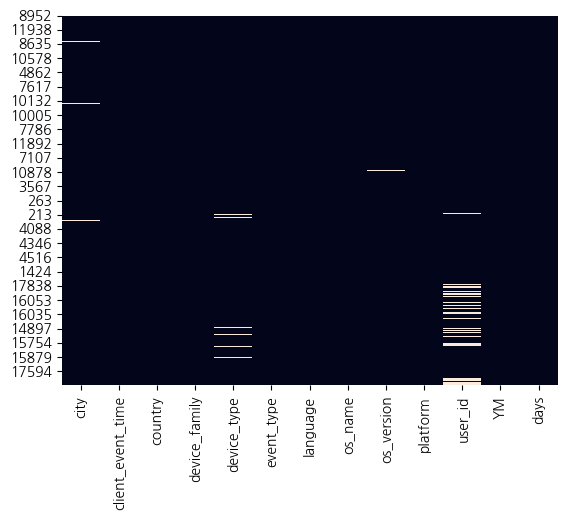

In [ ]:
look_null(click_cancel)

Text(0.5, 1.0, '월별 구독 취소 현황')

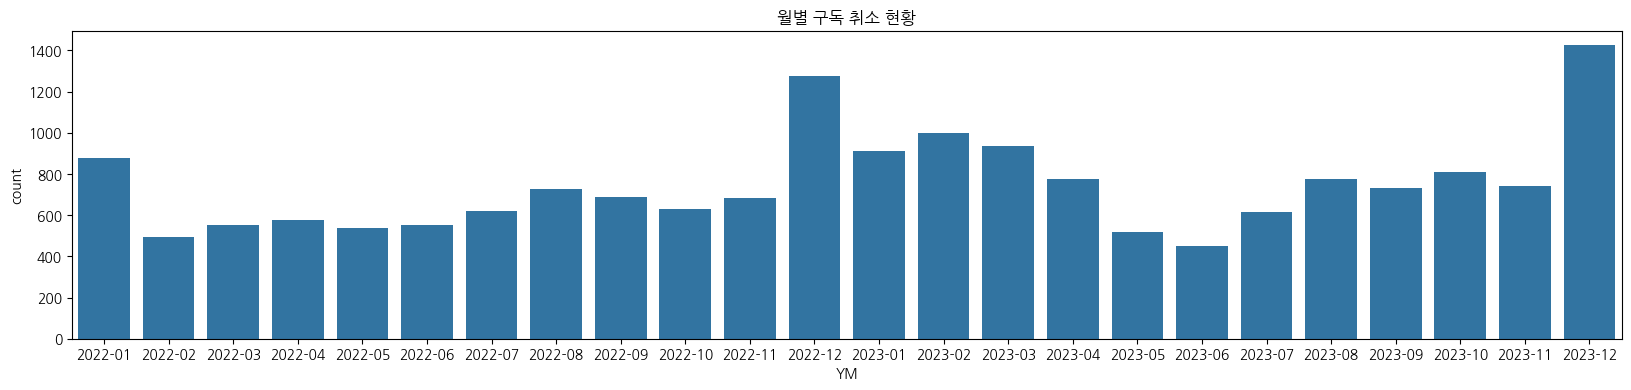

In [ ]:
fig, ax = plt. subplots(figsize = (20,4))
sns.countplot(data = click_cancel, x = 'YM')
plt.title('월별 구독 취소 현황')

구독 취소를 3회 한 유저의 여정

In [ ]:
click_cancel[click_cancel['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,YM,days
4920,Daegu,2022-04-12 03:40:55.113,South Korea,Windows,Windows,click.cancel_plan_button,Korean,Chrome,100,Web,001ddbe4885db89888b34bf0eb14f6e1,2022-04,12
9364,Mapo-gu,2022-05-10 09:16:36.166,South Korea,Android,Android,click.cancel_plan_button,Korean,Chrome WebView,90,Web,001ddbe4885db89888b34bf0eb14f6e1,2022-05,10
14888,Daegu,2023-08-30 08:10:02.230,South Korea,Mac,Mac,click.cancel_plan_button,Korean,Chrome,116.0.0.0,Web,001ddbe4885db89888b34bf0eb14f6e1,2023-08,30


In [ ]:
# 회원가입
new_customer = complete_signup[complete_signup['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

# 개별 콘텐츠 진입
cust_enter_content = enter_content[enter_content['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

# 콘텐츠  시청하기 버튼 클릭
cust_click_content = click_content_start[click_content_start['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

# 콘텐츠 후기 더보기
cust_click_more = click_content_more[click_content_more['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

# 무료체험
cus_strat_free = start_free[start_free['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

# 첫 결제
cus_first_sub = complete_sub[complete_sub['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

# 정기결제
cus_renew = renew_sub[renew_sub['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

# 만료후재구독
cus_resub = resubscribe[resubscribe['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

# 에피소드 시청시작
cus_epi = enter_episode[enter_episode['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']
cus_epi = cus_epi.groupby('client_event_time').size().reset_index()

# 에피소드 시청완료
cus_epi_fin = complete_episode[complete_episode['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']
cus_epi_fin = cus_epi_fin.groupby('client_event_time').size().reset_index()

# 콘텐츠 시청 완료
cus_end_cont = end_content[end_content['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

# 구독 취소
cus_cancel = click_cancel[click_cancel['user_id'] == '001ddbe4885db89888b34bf0eb14f6e1']

In [ ]:
cus_cancel.iloc[:,]['client_event_time']

4920    2022-04-12 03:40:55.113
9364    2022-05-10 09:16:36.166
14888   2023-08-30 08:10:02.230
Name: client_event_time, dtype: datetime64[ns]

In [ ]:
funnel = [new_customer, cust_enter_content, cust_click_content, cust_click_more, cus_strat_free, cus_first_sub, cus_renew, cus_resub]
for i in funnel:
    print(f"{i.iloc[:]['client_event_time']}")

75912   2022-03-18 06:23:15.202
Name: client_event_time, dtype: datetime64[ns]
1352673   2022-04-10 05:39:16.682
651621    2022-04-10 06:07:32.891
1189511   2022-04-11 00:39:11.117
1189512   2022-04-11 00:39:54.321
580121    2022-05-26 23:37:01.375
580122    2022-05-26 23:37:50.671
514911    2022-06-02 12:17:30.759
757737    2022-06-12 23:35:18.652
757738    2022-06-12 23:35:26.254
34480     2023-04-11 02:24:16.869
34481     2023-04-11 02:45:18.818
Name: client_event_time, dtype: datetime64[ns]
133467   2022-04-10 05:39:32.845
69851    2022-04-10 06:07:34.596
63387    2022-05-26 23:37:57.005
57321    2022-06-02 12:17:34.432
Name: client_event_time, dtype: datetime64[ns]
Series([], Name: client_event_time, dtype: datetime64[ns])
18698   2022-03-18 06:24:20.014
18699   2022-03-18 06:37:46.294
18700   2022-03-18 06:48:47.524
13763   2022-03-20 23:05:23.986
29333   2022-04-09 15:33:16.519
29334   2022-04-09 15:35:38.540
19953   2022-04-10 04:52:40.265
27721   2022-04-10 05:16:11.760
27722 

user_id가 '001ddbe4885db89888b34bf0eb14f6e1'인 고객의 여정 생각해보기 메인 서비스 홈페이지 접속 -> 비회원일 때 둘러보다가
22년 3월 18일에 가입 완료 -> 이후 무료체험을 시작함 (A버전 체험)
22년 4월 10일(1개월플랜)에 첫 결제 -> 22년 4월 12일 구독 취소
22년 5월 10일에 한번 더 구독취소를 하고 (어떤 경우로 어떻게 했는지 모르겠음..)
개별 컨텐츠 페이지 접속은 22년 4월10일 시작으로 22년 5월26일, 6월, 24년 4월에 페이지 접속함
에피소드 시청시작은 22년 3월 ~ 22년 6월, 에피소드 시천완료는 22년 5월 26,27일에 완료한 기록이 있음.(결제한 구독취소를 4월에 했고 또 어떤걸로 5월에 구독을 취소했는데 어떻게 5월과 6월에 시청했는지 궁금) 컨텐츠 시청완료한 경우는 없고,
23년 1월에 12개월 플랜으로 정기결제를 함.
23년 1월 ~ 8월까지 잘 보다가 (에피소드시청시작-완료 기록 있음) 23년 8월 30일에 구독취소

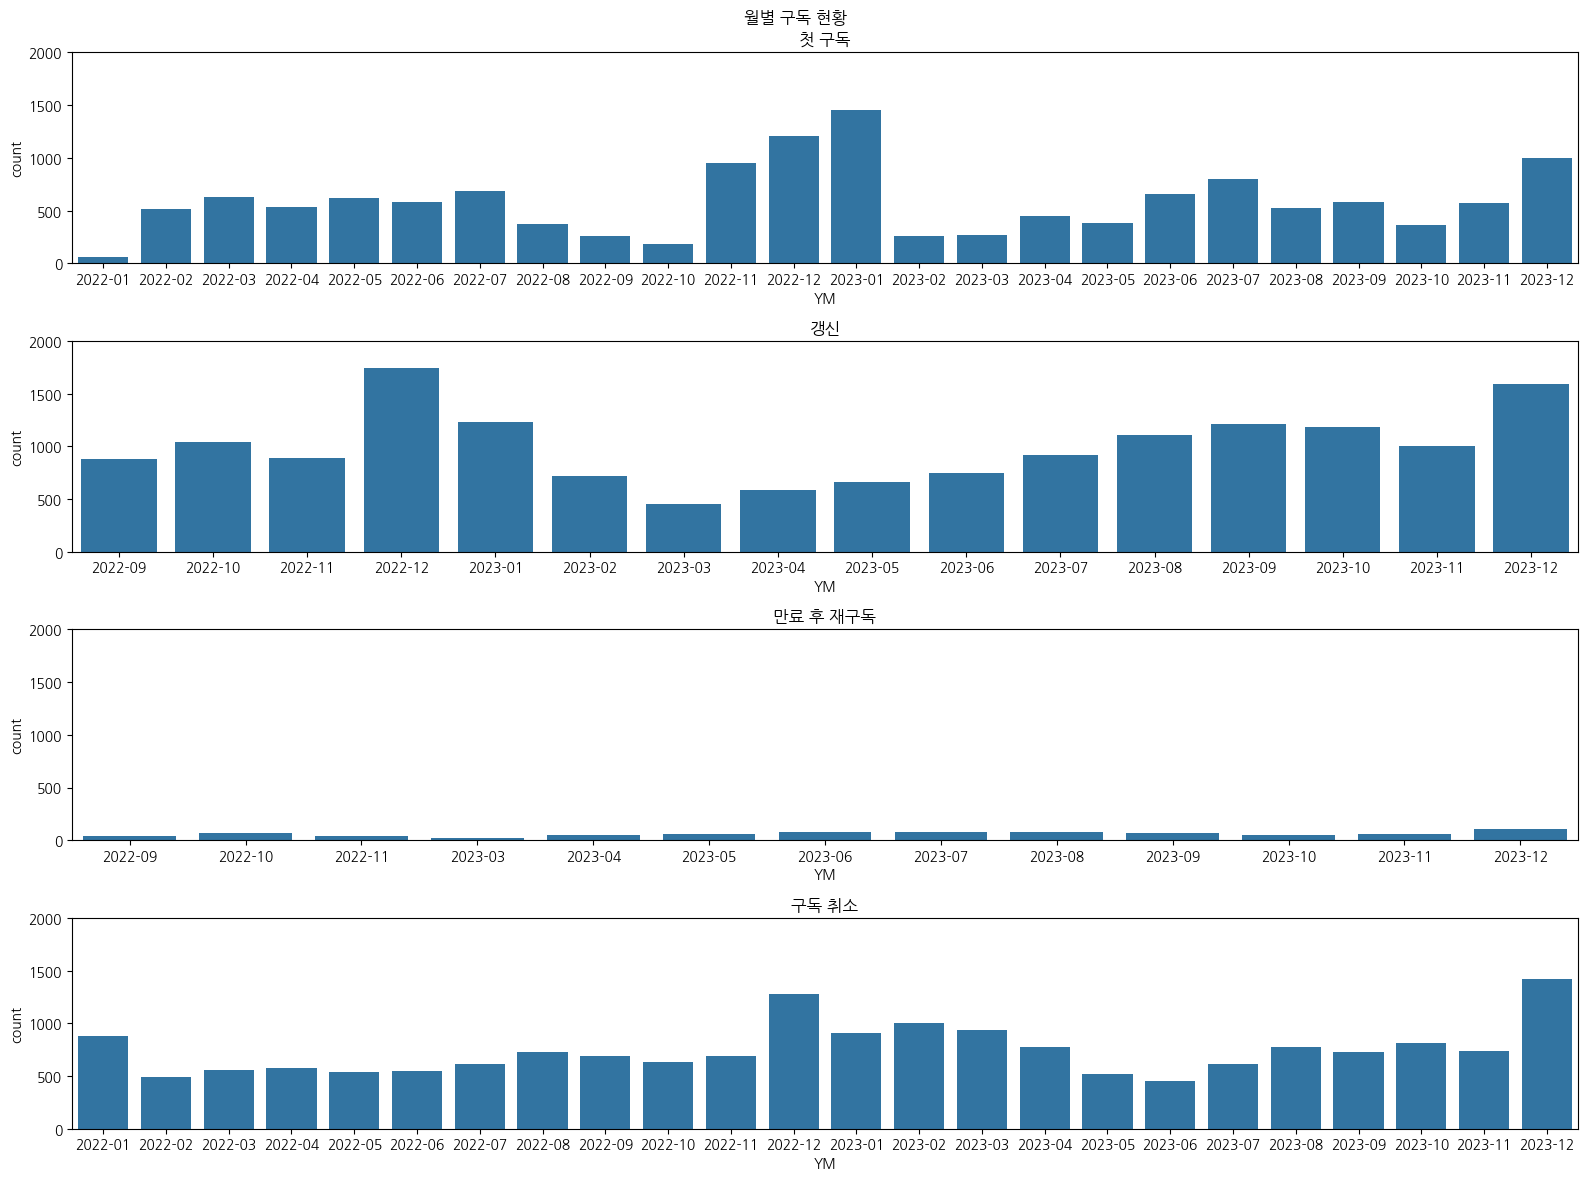

In [ ]:
fig, ax = plt.subplots(4,1, figsize = (16,12))
sns.countplot(data = complete_sub_final, x = 'YM', ax = ax[0])
sns.countplot(data = renew_sub, x = 'YM', ax = ax[1])
sns.countplot(data = resubscribe, x = 'YM', ax = ax[2])
sns.countplot(data = click_cancel, x = 'YM', ax = ax[3])
ax[0].set_title('첫 구독')
ax[1].set_title('갱신')
ax[2].set_title('만료 후 재구독')
ax[3].set_title('구독 취소')
fig.suptitle('월별 구독 현황')
for i in range(4):
    ax[i].set_ylim(0, 2000)
plt.tight_layout()
plt.show()

## 수익

In [ ]:
# set 자료형을 사용한 겹치는 user_id 확인
set1 = set(renew_sub['user_id'].unique())
set2 = set(complete_sub['user_id'].unique())

# 교집합을 구해 겹치는 user_id 찾기
common_user_ids = set1.intersection(set2)

print(renew_sub[renew_sub['user_id'] == '51a4bb7de21daa916b3ad65ea01ade0b']['client_event_time'])
print(complete_sub[complete_sub['user_id'] == '51a4bb7de21daa916b3ad65ea01ade0b']['client_event_time'])

11592   2023-09-15 10:50:01.865
12811   2023-10-15 10:55:01.797
13879   2023-11-15 11:00:02.556
Name: client_event_time, dtype: datetime64[ns]
14151   2023-07-24 10:47:12.156
Name: client_event_time, dtype: datetime64[ns]


In [ ]:
fisrt_sub = complete_sub[complete_sub['client_event_time'] >= '2022-09-01'][['user_id', 'client_event_time', 'paid_amount','plan.type', 'coupon.type', 'coupon.benefit_type']]
sub = renew_sub[['user_id', 'client_event_time', 'paid_amount','plan.type', 'coupon.type', 'coupon.benefit_type']]
resub = resubscribe[['user_id', 'client_event_time', 'paid_amount','plan.type', 'coupon.type', 'coupon.benefit_type']]

# 세로로 병합하고 계층적 인덱스 추가
combined_df = pd.concat([fisrt_sub, sub, resub], keys=['fisrt_sub', 'sub', 'resub'])

# 결과 출력
print(combined_df)

                                          user_id       client_event_time  \
fisrt_sub 10190  54eb27aa167798bb926d9e5c8b889700 2022-09-01 00:39:14.013   
          5001   6d2b7488a14afa40b783d03262cbc0fb 2022-09-01 03:55:00.973   
          3958   e94772dccd3b3d307bb2d534a4844e80 2022-09-01 08:05:02.620   
          6093   ba4b0121ac41d4af0e5ef879ed8592fc 2022-09-01 10:40:01.906   
          6092   7c8a344254ad55957e517c91398a19e0 2022-09-01 10:46:11.959   
...                                           ...                     ...   
resub     739    a3d58f1db750f07b5d9c75911ef61672 2023-12-31 14:49:41.466   
          736    709e41c97d8b384e115bef2578cbd2ce 2023-12-31 14:53:51.932   
          738    9d6d1d52d1b27cf0f10b4563d52689e2 2023-12-31 14:57:02.034   
          636    3183125eda6d61794fea5535122866de 2023-12-31 15:15:43.321   
          431    76ff3413bc3167debb2020f5f7197dac 2023-12-31 17:21:26.599   

                 paid_amount           plan.type coupon.type  \
fisrt_sub 1

In [ ]:
# 월로 변환하여 새로운 열 추가
combined_df['YM'] = combined_df['client_event_time'].dt.to_period('M')

# 중복된 user_id와 month를 가진 행 찾기
duplicate_rows = combined_df[combined_df.duplicated(subset=['user_id', 'YM'], keep=False)]

# 결과 출력
print(duplicate_rows)

                                         user_id       client_event_time  \
fisrt_sub 3914  af3b13bc0841b358adcdedf3e8822795 2022-09-08 05:42:30.429   
          7195  19e512a7f43998e40ef164887b5a55bc 2022-09-08 07:15:01.500   
          7194  cce98fec2181a37e99f0773625282c5e 2022-09-08 07:15:01.837   
          7193  f86ca0f3da4b3f1ee56cf3e07fac88c7 2022-09-08 07:15:02.018   
          4346  691af17c8d639f8d3b71f7b7f15d677c 2022-09-08 08:22:08.205   
...                                          ...                     ...   
resub     673   976eca9c9a7f5f5fac21fe3c41e32d1a 2023-08-01 17:35:48.233   
          475   de385d9bda1e0be3d7f296ec5af7bef0 2023-08-21 11:31:50.692   
          719   d00671fa4c958345567f5d93c5ce5096 2023-11-15 03:52:25.818   
          748   d36ba6eea66b8048cec16b61e1fa4e5c 2023-11-18 17:29:36.740   
          490   c9644d64187b12adc3ba6ad44d5e0314 2023-12-15 00:56:18.598   

                paid_amount           plan.type coupon.type  \
fisrt_sub 3914        42

In [ ]:
# user_id와 month로 그룹화하고 가장 최근 시간의 인덱스 찾기
latest_rows = combined_df.loc[combined_df.groupby(['user_id', 'YM'])['client_event_time'].idxmax()]

latest_rows

user_id       client_event_time  \
fisrt_sub 3179   0000572f2ba8079bcefd2760b632e820 2023-03-25 14:40:01.647   
sub       7428   0000572f2ba8079bcefd2760b632e820 2023-04-25 14:45:01.747   
          8070   0000572f2ba8079bcefd2760b632e820 2023-05-25 14:50:01.753   
fisrt_sub 2041   000087537cbfd934375364218ff10f91 2023-04-08 11:45:01.586   
          13205  0001f15911b404f3bf5b8571afafa4e4 2023-11-29 01:13:51.820   
...                                           ...                     ...   
sub       7688   fffe529de03d6187ef7ed765650c8d2b 2023-05-08 12:50:01.902   
          8386   fffe529de03d6187ef7ed765650c8d2b 2023-06-08 12:55:02.138   
          10094  fffe529de03d6187ef7ed765650c8d2b 2023-08-07 04:08:47.246   
          12006  fffe529de03d6187ef7ed765650c8d2b 2023-09-27 04:07:34.773   
resub     560    fffe529de03d6187ef7ed765650c8d2b 2023-12-30 08:44:49.356   

                 paid_amount           plan.type coupon.type  \
fisrt_sub 3179         15920              1개월 플랜         NaN   
sub       7428         15920              1개월 플랜         NaN   
          8070         15920              1개월 플랜         NaN   
fisrt_sub 2041        131600             12개월 플랜         NaN   
          13205        15920              1개월 플랜         NaN   
...                      ...                 ...         ...   
sub       7688         15920              1개월 플랜         NaN   
          8386         15920              1개월 플랜         NaN   
          10094        15920              1개월 플랜         NaN   
          12006        15920              1개월 플랜         NaN   
resub     560          95520  12개월 플랜(2024 프로모션)         NaN   

                coupon.benefit_type       YM  
fisrt_sub 3179                  NaN  2023-03  
sub       7428                  NaN  2023-04  
          8070                  NaN  2023-05  
fisrt_sub 2041                  NaN  2023-04  
          13205                 NaN  2023-11  
...                             ...      ...  
sub       7688                  NaN  2023-05  
          8386                  NaN  2023-06  
          10094                 NaN  2023-08  
          12006                 NaN  2023-09  
resub     560                   NaN  2023-12  

[25957 rows x 7 columns]

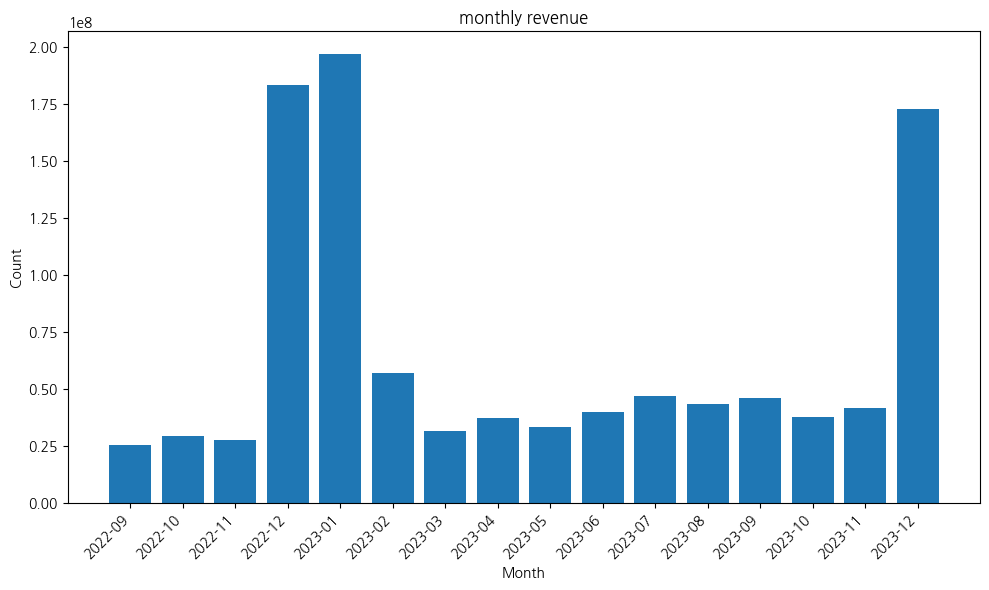

In [ ]:
# client_event_time을 datetime 형식으로 변환
latest_rows['client_event_time'] = pd.to_datetime(latest_rows['client_event_time'])

# 월별 데이터 수 집계
latest_rows['month'] = latest_rows['client_event_time'].dt.to_period('M')
monthly_sum = latest_rows.groupby('month')['paid_amount'].sum().sort_index().reset_index()

# 막대그래프 그리기
plt.figure(figsize=(10, 6))
plt.bar(monthly_sum['month'].astype(str), monthly_sum['paid_amount'])
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('monthly revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

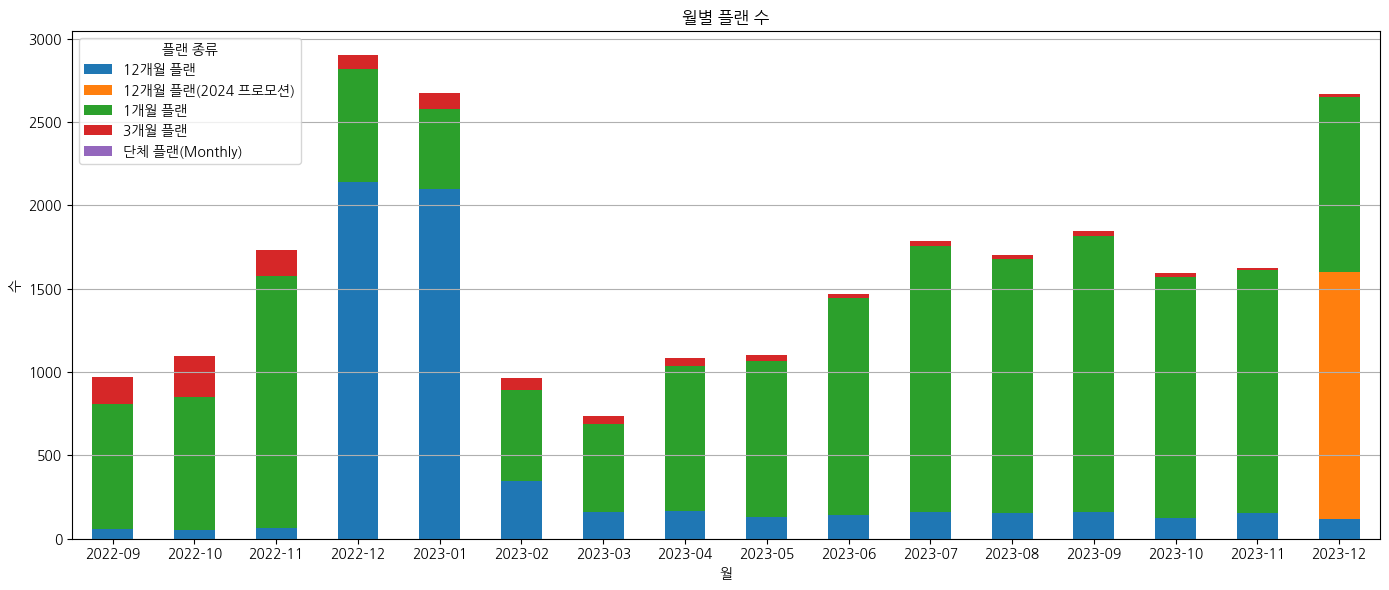

In [ ]:
monthly_counts = latest_rows.groupby([latest_rows['YM'], 'plan.type']).size().unstack(fill_value=0)

# 그래프 시각화 (figsize를 plot() 내에서 직접 지정)
ax = monthly_counts.plot(kind='bar', stacked=True, figsize=(14, 6))
ax.set_title('월별 플랜 수')
ax.set_xlabel('월')
ax.set_ylabel('수')
plt.xticks(rotation=0)
plt.legend(title='플랜 종류')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

쿠폰 적용 비율 확인

In [ ]:
latest_rows['coupon.type'].fillna(value='n', inplace=True)
latest_rows['coupon.benefit_type'].fillna(value='n', inplace=True)

C:\Users\csh94\AppData\Local\Temp\ipykernel_31912\2570627633.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  latest_rows['coupon.type'].fillna(value='n', inplace=True)
C:\Users\csh94\AppData\Local\Temp\ipykernel_31912\2570627633.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

C:\Users\csh94\AppData\Local\Temp\ipykernel_31912\2887323515.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = latest_rows.groupby('YM').apply(lambda x: (x['coupon.type'] != 'n').mean())


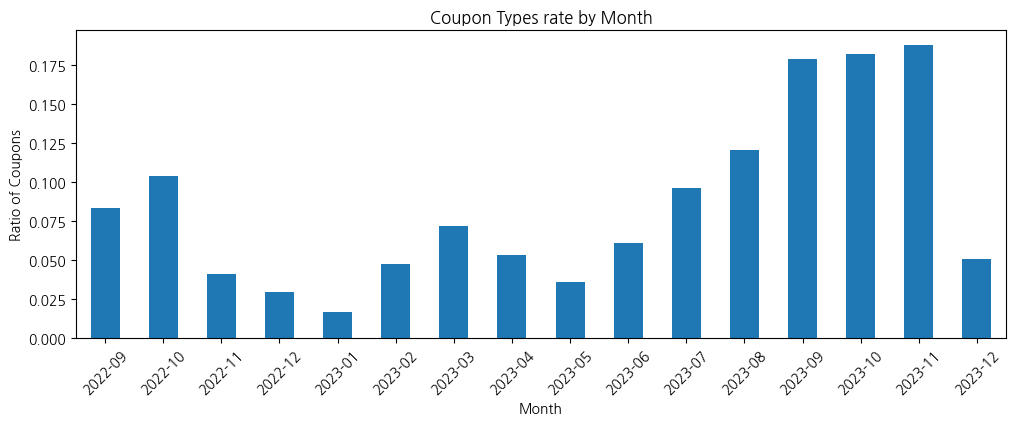

In [ ]:
# 월별로 그룹화하고 coupon.type이 'n'이 아닌 항목들의 비율 계산
result = latest_rows.groupby('YM').apply(lambda x: (x['coupon.type'] != 'n').mean())

# 결과를 막대그래프로 시각화
plt.figure(figsize=(12, 4))
result.plot(kind='bar')

# 그래프 제목과 레이블 추가
plt.title('Coupon Types rate by Month')
plt.xlabel('Month')
plt.ylabel('Ratio of Coupons')
plt.xticks(rotation=45)

plt.show()

## 그 외

In [ ]:
# 결제 합치기

revenue = pd.concat([complete_sub_final,renew_sub,resubscribe], axis = 0)
revenue.head()

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,...,plan.price,paid_amount,plan.type,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,YM,days,membership.price
9399,Seoul,2022-01-01 06:17:24.513,South Korea,Apple iPhone,Apple iPhone,complete.subscription,Korean,Mobile Safari,15,Web,...,42960.0,42960,3개월 플랜,NaN,NaN,0,NaN,2022-01,1,NaN
6914,Bucheon-si,2022-01-02 08:34:14.270,South Korea,Windows,Windows,complete.subscription,Korean,Edge,96,Web,...,15920.0,15920,1개월 플랜,NaN,NaN,0,NaN,2022-01,2,NaN
5757,Dongjak-gu,2022-01-02 15:23:04.269,South Korea,Windows,Windows,complete.subscription,Korean,Chrome,96,Web,...,42960.0,42960,3개월 플랜,NaN,NaN,0,NaN,2022-01,2,NaN
7520,Seoul,2022-01-03 04:25:14.519,South Korea,Windows,Windows,complete.subscription,Korean,Chrome,95,Web,...,15920.0,15920,1개월 플랜,NaN,NaN,0,NaN,2022-01,3,NaN
5747,Osan,2022-01-04 13:35:09.247,South Korea,Windows,Windows,complete.subscription,Korean,Chrome,96,Web,...,42960.0,42960,3개월 플랜,NaN,NaN,0,NaN,2022-01,4,NaN


In [ ]:
enter_content[enter_content['user_id'].isnull() == 1]

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,YM,days
1423083,Dobong-gu,2022-01-01 00:00:10.862,South Korea,Android,Android,enter.content_page,Korean,Chrome Mobile,96,Web,NaN,512a6f0abaef16c51950d52ce2d66fda,2022-01,1
1423067,Gwanak-gu,2022-01-01 00:09:01.663,South Korea,Android,Android,enter.content_page,Korean,Chrome WebView,90,Web,NaN,f4be1a0fe0e301b03115591777fddf29,2022-01,1
1423074,Gimpo-si,2022-01-01 00:15:25.240,South Korea,Android,Android,enter.content_page,Korean,Samsung Browser,16,Web,NaN,7cebec6e79cc981dbf421c5ec2aedd9d,2022-01,1
1423075,Gimpo-si,2022-01-01 00:20:12.511,South Korea,Android,Android,enter.content_page,Korean,Samsung Browser,16,Web,NaN,7cebec6e79cc981dbf421c5ec2aedd9d,2022-01,1
1423088,Songpa-dong,2022-01-01 00:24:20.251,South Korea,Windows,Windows,enter.content_page,Korean,Chrome,96,Web,NaN,b314d5aba64a0aab40602cb72a4a1504,2022-01,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1631936,Seoul,2023-12-31 23:56:59.217,South Korea,Apple iPhone,Apple iPhone,enter.content_page,Korean,Mobile Safari,17.1.2,Web,NaN,66fbc8fa22ac46a73eb3dfe499d270a7,2023-12,31
1631937,Seoul,2023-12-31 23:57:15.319,South Korea,Apple iPhone,Apple iPhone,enter.content_page,Korean,Mobile Safari,17.1.2,Web,NaN,445fac33232adcb3d1cdab7d8a579430,2023-12,31
1631938,Seoul,2023-12-31 23:57:38.241,South Korea,Apple iPhone,Apple iPhone,enter.content_page,Korean,Mobile Safari,17.1.2,Web,NaN,e88906bb19b773dcbf2adb5d34c49d9c,2023-12,31
1631939,Seoul,2023-12-31 23:58:08.287,South Korea,Apple iPhone,Apple iPhone,enter.content_page,Korean,Mobile Safari,17.1.2,Web,NaN,f4e7513becbdb8baf6a77fdc903cb713,2023-12,31


In [ ]:
enter_main[enter_main['user_id'].isnull() == 1]

,city,client_event_time,country,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,YM,days
1621379,Seoul,2022-01-01 00:02:20.959,South Korea,Apple iPhone,Apple iPhone,enter.main_page,Korean,Mobile Safari,15,Web,NaN,2022-01,1
1621404,Pohang,2022-01-01 00:04:28.929,South Korea,Apple iPhone,Apple iPhone,enter.main_page,Korean,Mobile Safari,14,Web,NaN,2022-01,1
1621387,Ansan-si,2022-01-01 00:08:00.285,South Korea,Windows,Windows,enter.main_page,Korean,Edge,96,Web,NaN,2022-01,1
1621409,Seocho-gu,2022-01-01 00:10:27.837,South Korea,Android,Android,enter.main_page,Korean,Samsung Browser,15,Web,NaN,2022-01,1
1621410,Seocho-gu,2022-01-01 00:10:40.531,South Korea,Android,Android,enter.main_page,Korean,Samsung Browser,15,Web,NaN,2022-01,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696090,Gangnam-gu,2023-12-10 14:58:25.324,South Korea,Windows,Windows,enter.main_page,Korean,Chrome,120.0.0.0,Web,NaN,2023-12,10
1696078,Gwangjin-gu,2023-12-10 14:59:12.499,South Korea,Windows,Windows,enter.main_page,Korean,Chrome,119.0.0.0,Web,NaN,2023-12,10
1696039,Seocho-gu,2023-12-10 14:59:31.231,South Korea,Windows,Windows,enter.main_page,Korean,Chrome,120.0.0.0,Web,NaN,2023-12,10
1807789,Seongnam-si,2023-12-10 15:00:11.026,South Korea,Samsung Phone,Samsung Galaxy S21 5G,enter.main_page,Korean,Whale,1.0.0.0,Web,NaN,2023-12,10


## 간단하게 집단 나누고 리텐션 살펴보기

In [ ]:
# 무료체험 에피소드 시청 데이터 추출
start_epi = enter_episode[['client_event_time','event_type', 'user_id', 'content.id', 'episode.id','is_trial','is_free_trial','YM','days']]
free_watch = start_epi[(start_epi['is_trial'] == 'True') | (start_epi['is_free_trial'] == 'True')]
free_watch

,client_event_time,event_type,user_id,content.id,episode.id,is_trial,is_free_trial,YM,days
8545322,2022-05-04 04:45:23.668,enter.episode_page,1ae0f5f4e8040634cce27591f0d73a4b,621c7ad99b17d2d16832b618d47aea7e,fc0b6cf318cd04701211ca246e3b56cf,NaN,True,2022-05,4
8545505,2022-05-04 04:47:02.510,enter.episode_page,ab59cfd1603a799b38c6e375893acf81,a914987711c7e2db9fd4bff7555ec87c,e740ddb77dc3d2a18ce187f374468b5f,NaN,True,2022-05,4
8545506,2022-05-04 04:47:19.525,enter.episode_page,ab59cfd1603a799b38c6e375893acf81,a914987711c7e2db9fd4bff7555ec87c,b77384e8b8f406f4f07d1a23e5769528,NaN,True,2022-05,4
8545507,2022-05-04 04:47:19.604,enter.episode_page,ab59cfd1603a799b38c6e375893acf81,a914987711c7e2db9fd4bff7555ec87c,b77384e8b8f406f4f07d1a23e5769528,NaN,True,2022-05,4
8545471,2022-05-04 04:51:17.014,enter.episode_page,ba78b30dbbf43e908de11809ffd16c16,d6227ba76134f6cf821bb98b5f235bd0,5ddc0c17dedfccd608401cf4164ac23f,NaN,True,2022-05,4
...,...,...,...,...,...,...,...,...,...
20288533,2023-12-31 14:31:37.699,enter.episode_page,NaN,445fac33232adcb3d1cdab7d8a579430,ce0bfeb7fb1259c588f437d48ab2690c,True,NaN,2023-12,31
18673378,2023-12-31 15:46:55.006,enter.episode_page,edfb46019c881639ca4952be9669cff4,c269eb6df3a374b464f7c18f12fa398f,c2b88e494ee633b334aa081cac7b1f02,True,NaN,2023-12,31
17083314,2023-12-31 16:03:17.497,enter.episode_page,6fa459e3fdc947bfb13bedff78926d0c,c269eb6df3a374b464f7c18f12fa398f,c2b88e494ee633b334aa081cac7b1f02,True,NaN,2023-12,31
15398825,2023-12-31 17:01:19.041,enter.episode_page,NaN,c269eb6df3a374b464f7c18f12fa398f,c2b88e494ee633b334aa081cac7b1f02,True,NaN,2023-12,31


In [ ]:
revenue1 = pd.concat([revenue, click_cancel,start_free], axis = 0, join = 'outer')
revenue1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79127 entries, 9399 to 2127
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    77580 non-null  object        
 1   client_event_time       79127 non-null  datetime64[ns]
 2   country                 78324 non-null  object        
 3   device_family           78343 non-null  object        
 4   device_type             77664 non-null  object        
 5   event_type              79127 non-null  object        
 6   language                78343 non-null  object        
 7   os_name                 78334 non-null  object        
 8   os_version              78310 non-null  object        
 9   platform                78343 non-null  object        
 10  user_id                 78071 non-null  object        
 11  plan.price              17111 non-null  float64       
 12  paid_amount             30617 non-null  float64  

In [ ]:
revenue_total = revenue1.groupby(['event_type','YM']).size().reset_index(name = 'count')
revenue_total['YM'] = revenue_total['YM'].dt.to_timestamp()

In [ ]:
revenue_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   event_type  92 non-null     object        
 1   YM          92 non-null     datetime64[ns]
 2   count       92 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.3+ KB


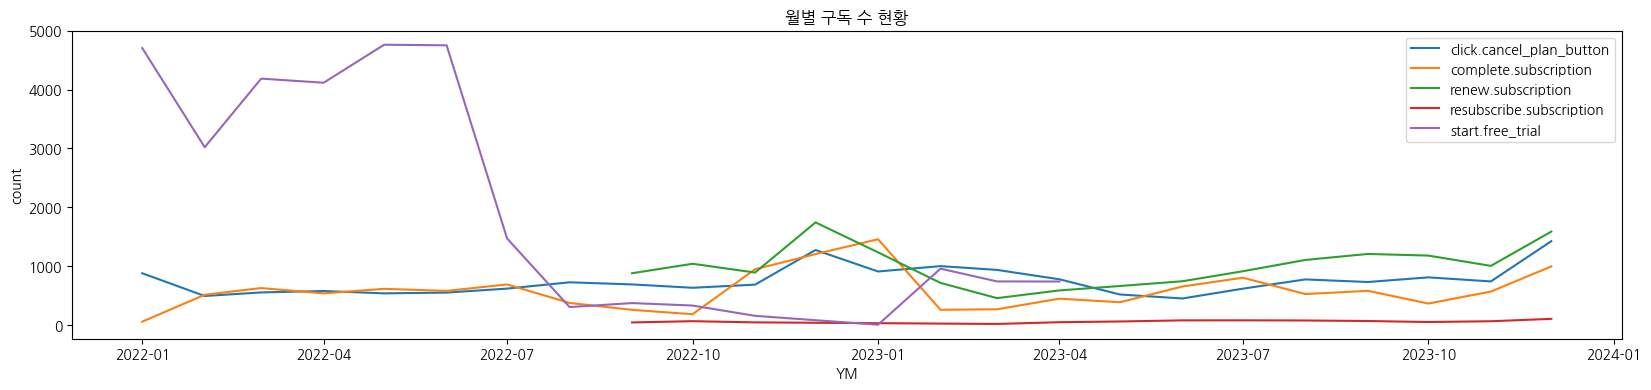

In [ ]:
fig, ax = plt.subplots(figsize = (20,4))
sns.lineplot(data = revenue_total, x = 'YM', y = 'count', hue = 'event_type')
plt.title('월별 구독 수 현황')
plt.legend(loc = 'upper right')

In [ ]:
revenue2 = pd.concat([revenue, click_cancel], axis = 0, join = 'outer')
revenue2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48511 entries, 9399 to 13629
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    47452 non-null  object        
 1   client_event_time       48511 non-null  datetime64[ns]
 2   country                 47838 non-null  object        
 3   device_family           47849 non-null  object        
 4   device_type             47191 non-null  object        
 5   event_type              48511 non-null  object        
 6   language                47849 non-null  object        
 7   os_name                 47840 non-null  object        
 8   os_version              47818 non-null  object        
 9   platform                47849 non-null  object        
 10  user_id                 47469 non-null  object        
 11  plan.price              14672 non-null  float64       
 12  paid_amount             30617 non-null  float64 

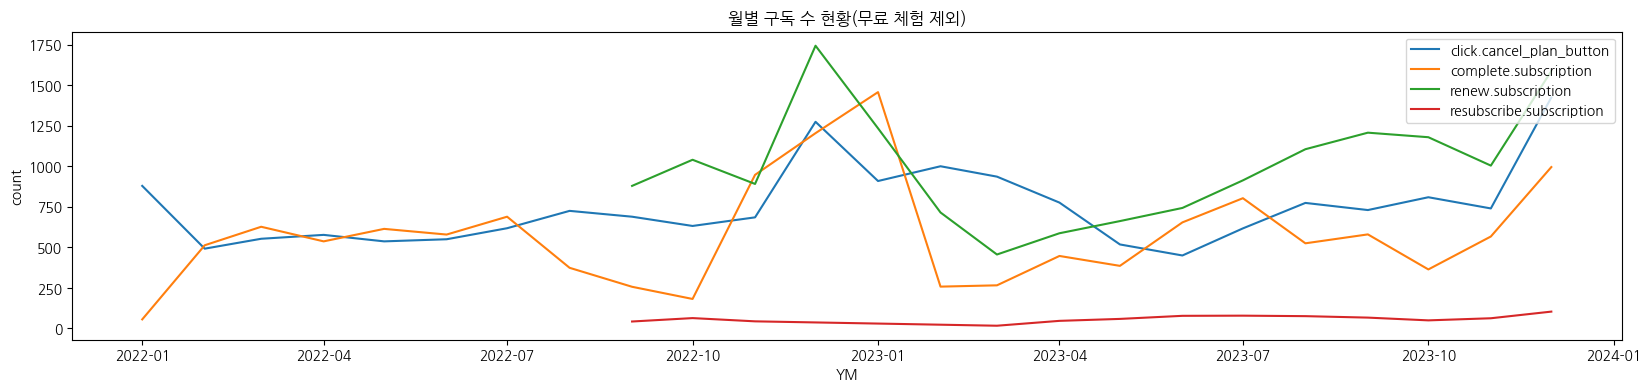

In [ ]:
revenue_total2 = revenue2.groupby(['event_type','YM']).size().reset_index(name = 'count')
revenue_total2['YM'] = revenue_total2['YM'].dt.to_timestamp()

fig, ax = plt.subplots(figsize = (20,4))
sns.lineplot(data = revenue_total2, x = 'YM', y = 'count', hue = 'event_type')
plt.title('월별 구독 수 현황(무료 체험 제외)')
plt.legend(loc = 'upper right')

In [ ]:
revenue_ratio = revenue_total.groupby(['YM', 'event_type'])['count'].sum().unstack(fill_value=0)
revenue_ratio['ratio'] = revenue_ratio['click.cancel_plan_button'] / (revenue_ratio['complete.subscription'] + revenue_ratio['renew.subscription'] + revenue_ratio['resubscribe.subscription'] + revenue_ratio['start.free_trial'])
revenue_ratio.reset_index()
revenue_ratio.head()


event_type,click.cancel_plan_button,complete.subscription,renew.subscription,resubscribe.subscription,start.free_trial,ratio
YM,,,,,,
2022-01-01,879,56,0,0,4706,0.184586
2022-02-01,492,513,0,0,3021,0.139219
2022-03-01,553,627,0,0,4187,0.114873
2022-04-01,577,537,0,0,4117,0.123979
2022-05-01,537,614,0,0,4763,0.099870


In [ ]:
revenue_ratio.index

DatetimeIndex(['2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
               '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01',
               '2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01'],
              dtype='datetime64[ns]', name='YM', freq=None)

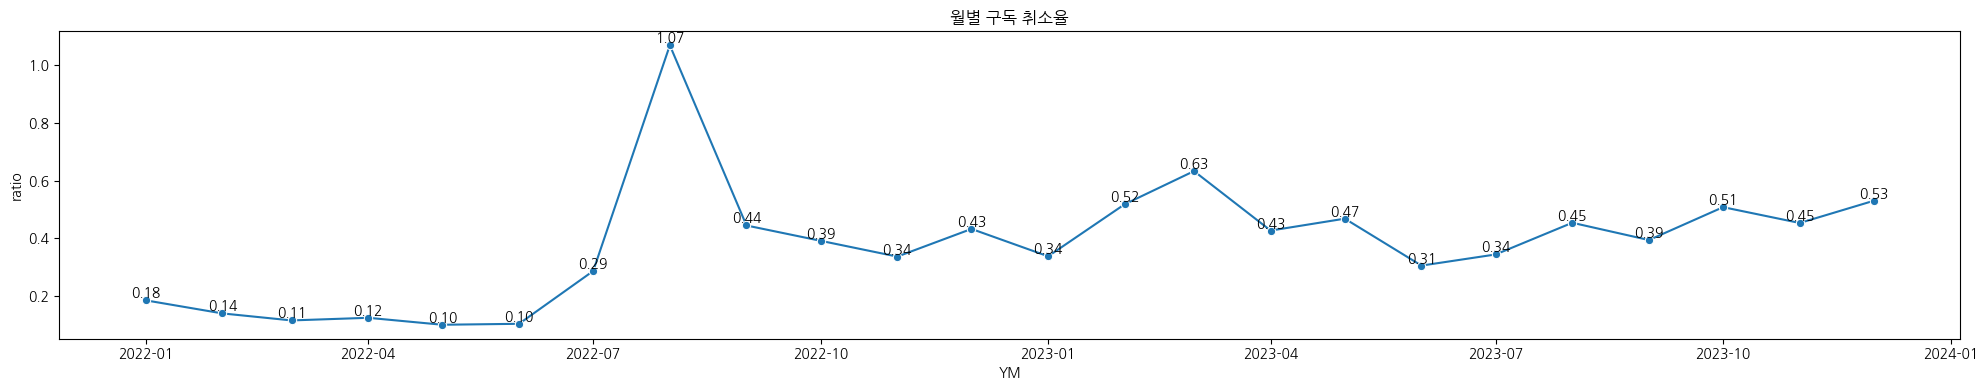

In [ ]:
fig, ax = plt.subplots(figsize = (20,4))
sns.lineplot(data = revenue_ratio, x = 'YM', y = 'ratio', marker = 'o')
# 각 포인트에 ratio 값 표시
for i, row in revenue_ratio.iterrows():
    plt.text(i, row['ratio'], f"{row['ratio']:.2f}", 
             color='black', ha='center', va='bottom', fontsize=10)

plt.title('월별 구독 취소율')
plt.tight_layout()
plt.show()

# 환경 구축

In [1]:
# 한글화를 위한 koreanize-matplotlib 설치
!pip install koreanize-matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import plotly.express as px
import os

## 작업디렉토리 변경
**데이터셋들이 저장된 폴더 경로를 지명해주세요.**

**데이터 명세서는 다른 폴더로 옮겨주세요.**

In [3]:
# 데이터셋들이 저장된 폴더 경로를 지명해주세요.
os.chdir('D:\\Project_OTT\\Data_newsletter')

## 파일 불러오기 함수 설정

In [4]:
# 파일을 불러오고 공통으로 적용되는 사항들을 반영하는 함수 제작
"""
변경사항
1. for문 사용 배제
2.  UTC+9 변경 방식을 단순하게 기록된 시간+9시간으로 변경
3. YYYY-MM, 월, 일, 시간 컬럼 제거
4. enter_episode 파일 불러올 때 메모리 사용량 감소
"""

def open_files(path,var):
    if var == 'enter_episode':
        df = pd.read_csv(path, parse_dates = ['client_event_time'], dtype = {'os_version': str, 'is_trial': str, 'is_free_trial': str})
    else:
        df = pd.read_csv(path, parse_dates = ['client_event_time'])
    df.drop(['city','country','device_carrier','device_type','language','os_name','os_version','platform'], axis = 1, inplace = True)
    df.sort_values(by = 'client_event_time', ascending = True, inplace = True)
    df['client_event_time'] = pd.to_datetime(df['client_event_time']) + pd.Timedelta(hours=9)
    df = df[df['client_event_time'] >= '2022-01-01 00:00:00']
    if 'genre.name' in df.columns:
        df.drop('genre.name', axis = 1, inplace = True)
    if 'genre.id' in df.columns:
        df.drop('genre.id', axis = 1, inplace = True)
    
    return df
    


## 데이터셋 불러오기

In [5]:
# 파일 불러오기

## 그동안 사용하지 않았던 후기 더보기 클릭, 코멘트 클릭 데이터셋은 넣지 않았음
## 필요하신분은 함수 추가해서 넣으면 됩니다.
## 변수명 = open_files('파일 이름','변수 이름')
click_cancel = open_files('click.cancel_plan_button.csv', 'click_cancel')
click_content_start = open_files('click.content_page_start_content_button.csv','click_content_start')
complete_episode = open_files('complete.episode.csv', 'complete_episode')
complete_signup = open_files('complete.signup.csv','complete_signup')
complete_sub = open_files('complete.subscription.csv','complete_sub')
end_content = open_files('end.content.csv', 'end_content')
enter_content = open_files('enter.content_page.csv','enter_content')
enter_episode = open_files('enter.episode_page-003.csv', 'enter_episode')  # csv 파일 이름 잘 확인해주세요.
enter_payment = open_files('enter.payment_page.csv','enter_payment')
enter_main = open_files('enter.main_page.csv', 'enter_main')
enter_signup = open_files('enter.signup_page.csv','enter_signup')
renew_sub = open_files('renew.subscription.csv','renew_sub')
resubscribe = open_files('resubscribe.subscription.csv','resubscribe')
start_contetn = open_files('start.content.csv','start_content')
start_free = open_files('start.free_trial.csv','start_free')




C:\Users\csh94\AppData\Local\Temp\ipykernel_34164\3378610268.py:14: DtypeWarning: Columns (13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, parse_dates = ['client_event_time'])


In [6]:
# 잘 열렸는지 테스트
enter_episode.head()

,client_event_time,device_family,event_type,user_id,content.id,is_trial,episode.id,is_free_trial
10036371,2022-01-01 00:50:53.603,Mac,enter.episode_page,976990eade46f23d9b1996aa7c3f5216,621c7ad99b17d2d16832b618d47aea7e,NaN,b9f975cbc88ddc186b5250ec97ad2849,NaN
10036372,2022-01-01 00:56:27.589,Mac,enter.episode_page,976990eade46f23d9b1996aa7c3f5216,621c7ad99b17d2d16832b618d47aea7e,NaN,257697131a509dc0b1fcbd3f140ea08a,NaN
10036373,2022-01-01 00:57:09.288,Mac,enter.episode_page,976990eade46f23d9b1996aa7c3f5216,621c7ad99b17d2d16832b618d47aea7e,NaN,2540764afd85b1efded64b0e3ef545f5,NaN
10036374,2022-01-01 00:58:59.092,Mac,enter.episode_page,976990eade46f23d9b1996aa7c3f5216,621c7ad99b17d2d16832b618d47aea7e,NaN,7a734e565286a495a084beaecb1dd0ea,NaN
10036375,2022-01-01 00:59:02.928,Mac,enter.episode_page,976990eade46f23d9b1996aa7c3f5216,621c7ad99b17d2d16832b618d47aea7e,NaN,ba5244e35acc86cb2586752d3c451864,NaN


## 데이터셋 명세서
| 이벤트 유형          | 설명                                   | 비고                                                                         |
|---------------------|----------------------------------------|------------------------------------------------------------------------------|
| enter_main              | 서비스 메인페이지 진입                 |                                        |
| enter_signup            | 회원가입 페이지 진입                   |                                                     |
| complete_signup         | 회원가입 완료                         |                                                          |
| enter_content           | 콘텐츠 개별 페이지 진입                |                                                     |
| click_content_start     | 콘텐츠 시청하기 버튼 클릭              |                                                |
| click_content_more      | 콘텐츠 후기 더보기 버튼 클릭           |                                                 |
| enter_payment           | 결제 페이지 진입                      |                                                         |
| complete_sub            | 첫 결제 완료                           | 첫 결제가 중복인 경우 첫 결제 환불 후 다시 결제한 것으로 간주
| renew_sub               | 정기 결제 완료                         |                                                                 |
| resubscribe             | 만료 후 재구독 완료                    |                                                     |
| start_free              | 서비스 무료체험 시작                   |                                                     |
| start_content           | 콘텐츠 시청 시작                      | 2022년 8월 이후로 수집된 테이블에서만 사용됨                         |
| enter_episode           | 에피소드 시청 시작                    |                                                              |
| complete_episode        | 에피소드 시청 완료                    |                                                      |
| click_episode_comment   | 에피소드 페이지 내 댓글보기 버튼 클릭  |                                 |
| end_content             | 콘텐츠 시청 완료                      | 콘텐츠 내 모든 에피소드를 시청하면 해당 테이블에 로그가 쌓임                    |
| click_cancel            | 구독 취소 버튼 클릭                   | 구독 취소 버튼을 클릭 시 구독이 취소된 것으로 간주                         |

### 공통 컬럼
| 컬럼 이름              | 설명                    |
|-----------------------|-------------------------|
| client_event_time     | 한국시각 기준            |
| event_type            | 액션 유형                |
| user_id               | 사용자 고유 식별자       |
| device_family         | 사용 기기 유형         |


## 메인 페이지

# 데이터 병합

유저들의 구독 정보를 병합

In [ ]:
# 결제 - (취소) - 결제 여정
# 공통컬럼 
columns = ['client_event_time', 'event_type', 'user_id', 'plan.type']

# 첫결제 중복인 경우 환불후 다시 결제한 케이스여서 마지막 날짜만 남기기
# user_id, 시간 중복 제외 후 user_id가 여러번 나온 케이스는 가장 마지막 날짜만
complete_sub_sort = complete_sub.sort_values(by = ['user_id','client_event_time'], ascending = True)
complete_sub_u = complete_sub_sort.drop_duplicates(subset = ['user_id'], keep = 'last')
df1 = complete_sub_u[['client_event_time', 'event_type', 'user_id', 'plan.type']]
# 단체플랜제외
df1 = df1[df1['plan.type'] != '단체 플랜(Monthly)']
df2 = renew_sub[['client_event_time', 'event_type', 'user_id', 'plan.type' , 'pg.type']] # pg.type 결제타입
df3 = resubscribe[['client_event_time', 'event_type', 'user_id', 'plan.type' , 'pg.type']]

# 데이터병합하기
sub = pd.concat([df1, df2, df3]).sort_values(by=['user_id', 'client_event_time'], ignore_index=True)

# 년-월-일 기준으로 중복 제거하고 가장 최근 시간만 남기기
sub['date'] = sub['client_event_time'].dt.date
sub = sub.drop_duplicates(subset=['user_id', 'date'], keep='last')

# 필요없는 임시 'date' 열 삭제
sub = sub.drop(columns=['date'])

df4 = click_cancel[['client_event_time', 'event_type', 'user_id']] # plan.type에 구독취소 라는 이름으로 넣을까 말까 고민중

# 데이터병합하기
complete_cancel = pd.concat([sub, df4]).sort_values(by=['user_id', 'client_event_time'], ignore_index=True)

# 사용자 별로 그룹화하여 필터링을 적용
def filter_user_data(user_data):
    filtered_data = []
    last_payment_time = None
    last_cancel = None  # 마지막 취소 이벤트를 추적
    has_subscription = False  # 첫 결제 이후의 이벤트만 처리하도록 추적
    
    for i, row in user_data.iterrows():
        event_type = row['event_type']
        
        # 결제 이벤트가 발생할 때
        if event_type in ['complete.subscription', 'renew.subscription', 'resubscribe.subscription']:
            # 첫 결제가 발생한 후에는 취소 이벤트를 추적하도록 설정
            has_subscription = True
            
            # 결제 이전에 추적된 마지막 취소 이벤트가 있으면 추가
            if last_cancel is not None:
                filtered_data.append(last_cancel)
                last_cancel = None  # 마지막 취소 초기화
            
            # 현재 결제 이벤트도 추가
            filtered_data.append(row.to_dict())
            last_payment_time = row['client_event_time']
        
        # 첫 결제 이후 발생한 취소 이벤트만 처리
        elif event_type == 'click.cancel_plan_button' and has_subscription:
            # 결제 이후 발생한 취소 이벤트 중 가장 마지막 취소 이벤트를 추적
            last_cancel = row.to_dict()
    
    # 반복이 끝난 후 마지막 결제 이후에 남아 있는 취소 이벤트가 있으면 추가
    if last_cancel is not None:
        filtered_data.append(last_cancel)
    
    return pd.DataFrame(filtered_data)

# 전체 사용자에 대해 필터링 적용
filtered_data = complete_cancel.groupby('user_id', group_keys=False).apply(filter_user_data)
filtered_data.reset_index(drop=True, inplace=True)

In [ ]:
# 유저 구독 현황 테이블
filtered_data = filtered_data.sort_values(['user_id', 'client_event_time']).reset_index(drop=True)

# 결과를 저장할 리스트 생성
output_list = []

# 구독-취소 짝짓기
for i, row in filtered_data.iterrows():
    if row['event_type'] in ['complete.subscription', 'renew.subscription', 'resubscribe.subscription']:
        # 구독 이벤트일 경우
        new_row = {
            'user_id': row['user_id'],
            '결제날짜': row['client_event_time'],
            '만료날짜': row['expire_day'],
            'plan.type': row['plan.type'],
            '종료날짜': np.nan  # 일단 취소날짜는 NaN으로 초기화
        }
        # 다음 행이 'click_cancel'이고 user_id가 동일하면 취소날짜를 채움
        if i + 1 < len(filtered_data) and filtered_data.at[i + 1, 'event_type'] == 'click.cancel_plan_button' and filtered_data.at[i + 1, 'user_id'] == row['user_id']:
            new_row['종료날짜'] = filtered_data.at[i + 1, 'client_event_time']
        
         # 리스트에 새로운 행 추가
        output_list.append(new_row)

# 리스트를 DataFrame으로 변환
user_sub_status = pd.DataFrame(output_list)

# 유저별로 종료날짜 설정
for i in range(len(user_sub_status) - 1):
    # 조건: 같은 유저, 종료날짜가 NaT, 만료날짜가 다음 결제날짜보다 크거나 같음
    if (
        user_sub_status.at[i, 'user_id'] == user_sub_status.at[i + 1, 'user_id'] and
        pd.isna(user_sub_status.at[i, '종료날짜']) and
        user_sub_status.at[i, '만료날짜'] >= user_sub_status.at[i + 1, '결제날짜']
    ):
        # 종료날짜를 다음 행의 결제날짜의 정각으로 설정
        user_sub_status.at[i, '종료날짜'] = user_sub_status.at[i + 1, '결제날짜'].replace(hour=0, minute=0, second=0, microsecond=0)

# 종료날짜가 만료날짜보다 최근일 경우 NaT로 변경
user_sub_status.loc[user_sub_status['종료날짜'] > user_sub_status['만료날짜'], '종료날짜'] = pd.NaT
user_sub_status

,user_id,결제날짜,만료날짜,plan.type,종료날짜
0,0000572f2ba8079bcefd2760b632e820,2023-03-25 23:40:01.647,2023-04-25 23:40:01.647,1개월 플랜,NaT
1,0000572f2ba8079bcefd2760b632e820,2023-04-25 23:45:01.747,2023-05-25 23:45:01.747,1개월 플랜,NaT
2,0000572f2ba8079bcefd2760b632e820,2023-05-25 23:50:01.753,2023-06-25 23:50:01.753,1개월 플랜,NaT
3,000087537cbfd934375364218ff10f91,2023-04-08 20:45:01.586,2024-04-08 20:45:01.586,12개월 플랜,NaT
4,0001f15911b404f3bf5b8571afafa4e4,2023-11-29 10:13:51.820,2023-12-29 10:13:51.820,1개월 플랜,NaT
...,...,...,...,...,...
19290,fffe529de03d6187ef7ed765650c8d2b,2023-05-08 21:50:01.902,2023-06-08 21:50:01.902,1개월 플랜,NaT
19291,fffe529de03d6187ef7ed765650c8d2b,2023-06-08 21:55:02.138,2023-07-08 21:55:02.138,1개월 플랜,2023-07-05 19:45:19.763
19292,fffe529de03d6187ef7ed765650c8d2b,2023-08-07 13:08:47.246,2023-09-07 13:08:47.246,1개월 플랜,2023-08-21 19:08:15.930
19293,fffe529de03d6187ef7ed765650c8d2b,2023-09-27 13:07:34.773,2023-10-27 13:07:34.773,1개월 플랜,NaT


유저들의 행동 데이터 병합

In [ ]:
f_complete_signup = complete_signup[['client_event_time', 'event_type', 'user_id']]
f_enter_payment = enter_payment[['client_event_time', 'event_type', 'user_id']]
f_start_free = start_free[['client_event_time', 'event_type', 'user_id', 'plan.type' , 'trial.type']]
f_enter_episode = enter_episode[['client_event_time', 'event_type', 'user_id', 'content.id', 'episode.id', 'is_trial', 'is_free_trial']]
f_complete_episode = complete_episode[['client_event_time', 'event_type', 'user_id', 'content.id', 'episode.id']]

# client_time에서 년월일 정보만 추출해 새로운 컬럼 'date' 생성
f_enter_episode['date'] = pd.to_datetime(f_enter_episode['client_event_time']).dt.date

# 에피소드 시청 중복 제거
f_enter_episode = f_enter_episode.drop_duplicates(subset=['user_id', 'content.id', 'episode.id', 'date'], keep='first')

# 요금제에 따른 개월 수 매핑
plan_months = {
    '1개월 플랜': 1,
    '3개월 플랜': 3,
    '12개월 플랜': 12,
    '12개월 플랜(2024 프로모션)': 12
}

# payment(complete_sub, renew_sub, resubscribe), click_cancel 대신 filtered_data 사용
# expire_day : 만료일추가
filtered_data['expire_day'] = filtered_data.apply(lambda x:
                                                  x['client_event_time']
                                                  + pd.DateOffset(months = plan_months[x['plan.type']]) if pd.notna(x['plan.type']) else pd.NaT,
                                                  axis=1)

user_merge = pd.concat([f_complete_signup,
                        f_enter_payment, filtered_data, f_start_free,
                        f_enter_episode, f_complete_episode], ignore_index=True, sort=False)

# 홈페이지에 가입한 사람만
users = complete_signup['user_id'].unique()
user_total = user_merge[user_merge['user_id'].isin(users)]

# 유저, 시간순 정렬
user_total = user_total.sort_values(by = ['user_id','client_event_time'], ascending = True)

# EDA

## 전환율

In [ ]:
main_count = enter_main[enter_main['user_id'].isna()].shape[0]
signup_count = enter_signup.shape[0]
complete_signup_count = complete_signup.shape[0]
payment_count = enter_payment.shape[0]
sub_count = renew_sub.shape[0]
free_count = start_free.shape[0]

#전환율
print(f'메인 페이지 -> 회원가입 페이지 {(signup_count/main_count * 100):.2f}%')
print(f'회원가입 페이지 -> 회원가입 완료 {(complete_signup_count/signup_count * 100):.2f}%')
print(f'회원가입 완료 -> 결제 페이지 {(sub_count/complete_signup_count * 100):.2f}%')

메인 페이지 -> 회원가입 페이지 37.05%
회원가입 페이지 -> 회원가입 완료 24.32%
회원가입 완료 -> 결제 페이지 10.99%


## 월별 에피소드 시청 횟수

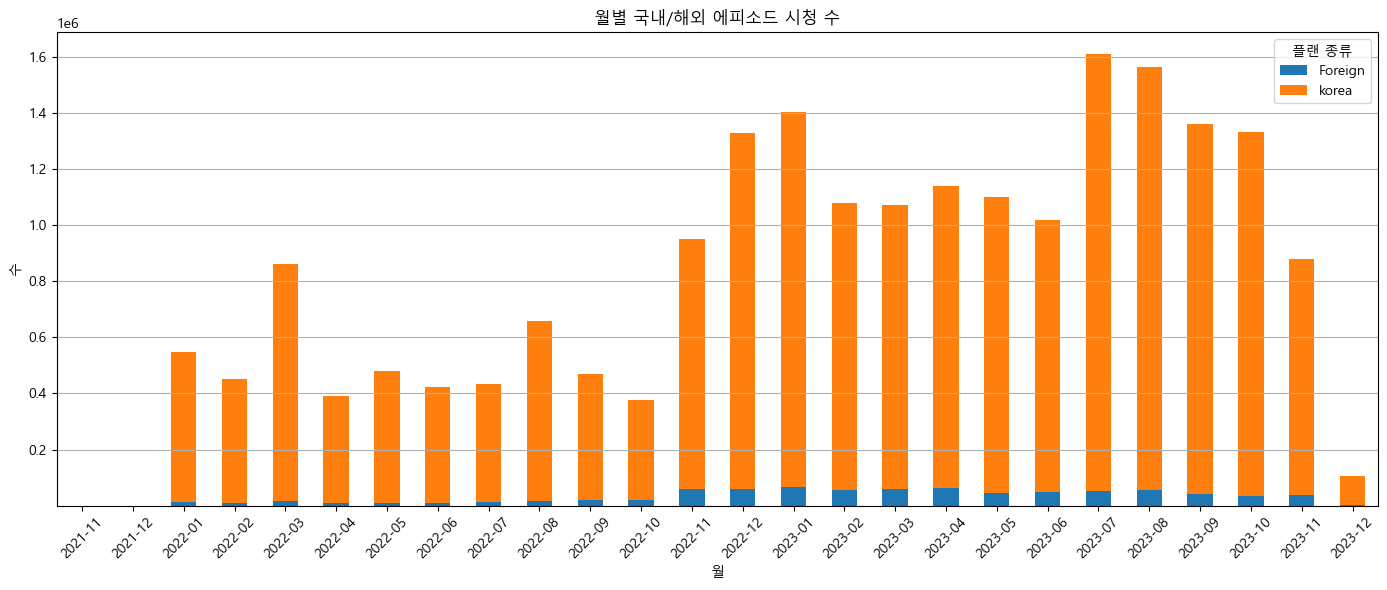

In [ ]:
monthly_counts = enter_episode.groupby([enter_episode['month'], 'korea']).size().unstack(fill_value=0)

# 그래프 시각화 (figsize를 plot() 내에서 직접 지정)
ax = monthly_counts.plot(kind='bar', stacked=True, figsize=(14, 6))
ax.set_title('월별 국내/해외 에피소드 시청 수')
ax.set_xlabel('월')
ax.set_ylabel('수')
plt.xticks(rotation=45)
plt.legend(title='플랜 종류')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

해외에서 에피소드 시청 횟수가 너무 적어 OTT 플랫폼의 강점과 K-드라마, 문화 유행의 기회를 살려 글로벌 진출도 생각해볼 수 있을듯하다.

## 유저id x 메인페이지 빈도 수

In [ ]:
enter_main

,client_event_time,device_family,event_type,user_id
919735,2023-01-01 00:00:16.804,Mac,enter.main_page,NaN
919637,2023-01-01 00:00:35.458,Samsung Galaxy Note,enter.main_page,c2e3c4b1ea293ebecefa351cebc51c03
919691,2023-01-01 00:00:42.071,Samsung Phone,enter.main_page,NaN
919776,2023-01-01 00:01:08.505,Windows,enter.main_page,fbb09a38147adac880ceac847f4d5ee6
919737,2023-01-01 00:01:09.860,Samsung Phone,enter.main_page,NaN
...,...,...,...,...
1696078,2023-12-10 23:59:12.499,Windows,enter.main_page,NaN
1696039,2023-12-10 23:59:31.231,Windows,enter.main_page,NaN
1807790,2023-12-11 00:00:01.926,Windows,enter.main_page,ff91369a6a376f3bccce0fd77bd85787
1807789,2023-12-11 00:00:11.026,Samsung Phone,enter.main_page,NaN


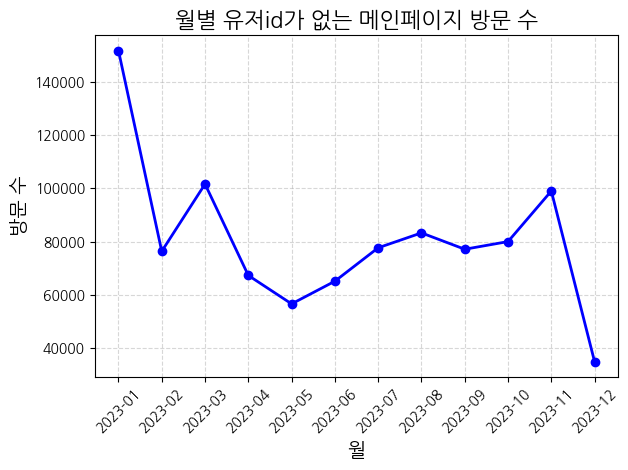

In [ ]:
# client_event_time 열에서 월 추출
enter_main['month'] = enter_main['client_event_time'].dt.to_period('M').astype(str)

# user_id가 NaN인 경우만 추출
non_id_enter_main = enter_main[enter_main['user_id'].isna()]

# 월별 방문 빈도수 계산
non_id_monthly_visits = non_id_enter_main.groupby('month').size().reset_index(name='visit_count')

# 선 그래프 그리기
plt.plot(non_id_monthly_visits['month'], non_id_monthly_visits['visit_count'], marker='o', color='b', linestyle='-', linewidth=2, markersize=6)

# 제목과 축 레이블 추가
plt.title('월별 유저id가 없는 메인페이지 방문 수', fontsize=16)
plt.xlabel('월', fontsize=14)
plt.ylabel('방문 수', fontsize=14)

# 그리드 추가
plt.grid(visible=True, linestyle='--', alpha=0.5)

# X축 레이블 회전 및 그래프 정렬
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 출력
plt.show()

## 유저id o 메인페이지 빈도 수

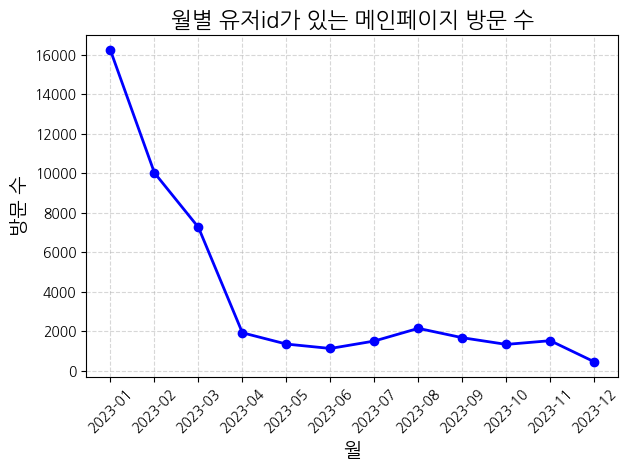

In [ ]:
# client_event_time 열에서 월 추출
enter_main['month'] = enter_main['client_event_time'].dt.to_period('M').astype(str)

# user_id가 NaN인 경우만 추출
id_enter_main = enter_main[enter_main['user_id'].isin(users)]

# 월별 방문 빈도수 계산
id_monthly_visits = id_enter_main.groupby('month').size().reset_index(name='visit_count')

# 선 그래프 그리기
plt.plot(id_monthly_visits['month'], id_monthly_visits['visit_count'], marker='o', color='b', linestyle='-', linewidth=2, markersize=6)

# 제목과 축 레이블 추가
plt.title('월별 유저id가 있는 메인페이지 방문 수', fontsize=16)
plt.xlabel('월', fontsize=14)
plt.ylabel('방문 수', fontsize=14)

# 그리드 추가
plt.grid(visible=True, linestyle='--', alpha=0.5)

# X축 레이블 회전 및 그래프 정렬
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 출력
plt.show()

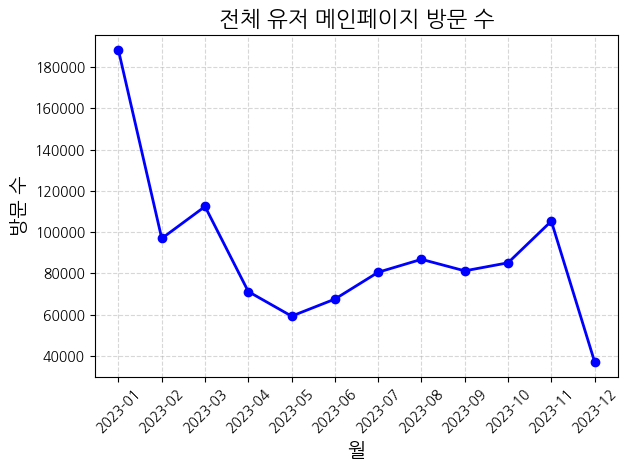

In [ ]:
# client_event_time 열에서 월 추출
enter_main['month'] = enter_main['client_event_time'].dt.to_period('M').astype(str)

# 월별 방문 빈도수 계산
monthly_visits = enter_main.groupby('month').size().reset_index(name='visit_count')

# 선 그래프 그리기
plt.plot(monthly_visits['month'], monthly_visits['visit_count'], marker='o', color='b', linestyle='-', linewidth=2, markersize=6)

# 제목과 축 레이블 추가
plt.title('전체 유저 메인페이지 방문 수', fontsize=16)
plt.xlabel('월', fontsize=14)
plt.ylabel('방문 수', fontsize=14)

# 그리드 추가
plt.grid(visible=True, linestyle='--', alpha=0.5)

# X축 레이블 회전 및 그래프 정렬
plt.xticks(rotation=45)
plt.tight_layout()

# 그래프 출력
plt.show()

## 메인페이지 유입 채널 수

In [ ]:
enter_main = pd.read_csv('Data_newsletter/enter.main_page.csv')

In [ ]:
# 2023년 12월 1일부터 12월 31일까지의 데이터를 필터링 - 중간에 끊김 11월달로?
start_date = '2023-12-01'
end_date = '2023-12-31'
enter_main_month12 = enter_main[(enter_main['client_event_time'] >= start_date) & (enter_main['client_event_time'] <= end_date)]

In [ ]:
enter_main_month12[enter_main_month12['os_name'] == 'Chrome']['device_family'].unique()

array(['Mac', 'Windows', 'Apple iPhone', 'Apple iPad', 'K',
       'Samsung Galaxy Phone', 'Motorola Phone', 'Linux',
       'Google Nexus Phone', nan, 'Samsung Phone', 'Samsung Tablet',
       'Chromium OS', 'CentOS', 'Samsung SM-P585N', 'LG H870DS',
       'TECNO KG5h', 'Samsung Galaxy Note', 'Huawei RMO-NX1', 'M2002J9S',
       'LG X760', 'Realme Phone', 'LGE Phone'], dtype=object)

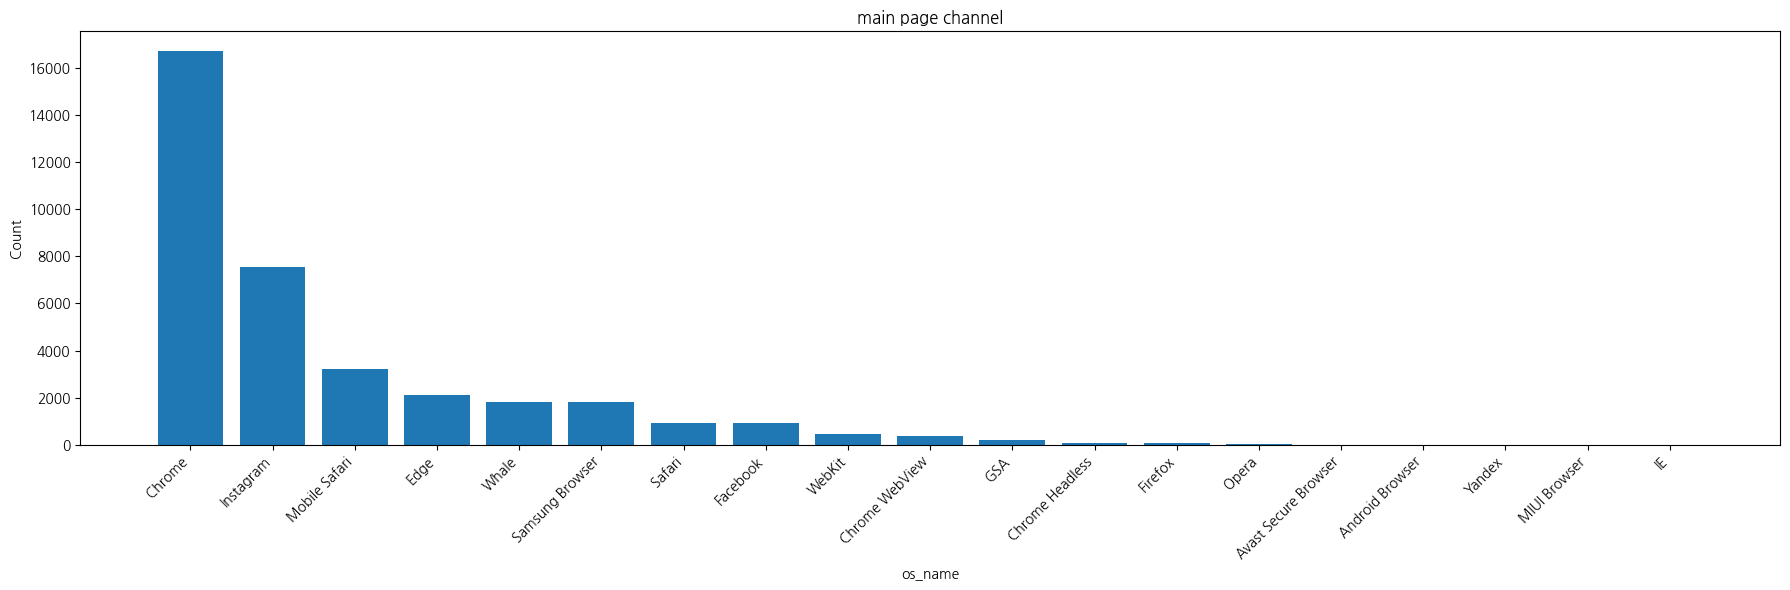

In [ ]:
# 메인페이지 유입 채널 수
os_name_counts = enter_main_month12['os_name'].value_counts().reset_index()

plt.figure(figsize=(18, 6))
plt.bar(os_name_counts['os_name'], os_name_counts['count'])
plt.xlabel('os_name')
plt.ylabel('Count')
plt.title('main page channel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# 2023년 11월 1일부터 11월 31일까지의 데이터를 필터링
start_date = '2023-11-01'
end_date = '2023-11-31'
enter_main_month11 = enter_main[(enter_main['client_event_time'] >= start_date) & (enter_main['client_event_time'] <= end_date)]

In [ ]:
non_enter_main_month11 = enter_main_month11[enter_main_month11['user_id'].isna()]

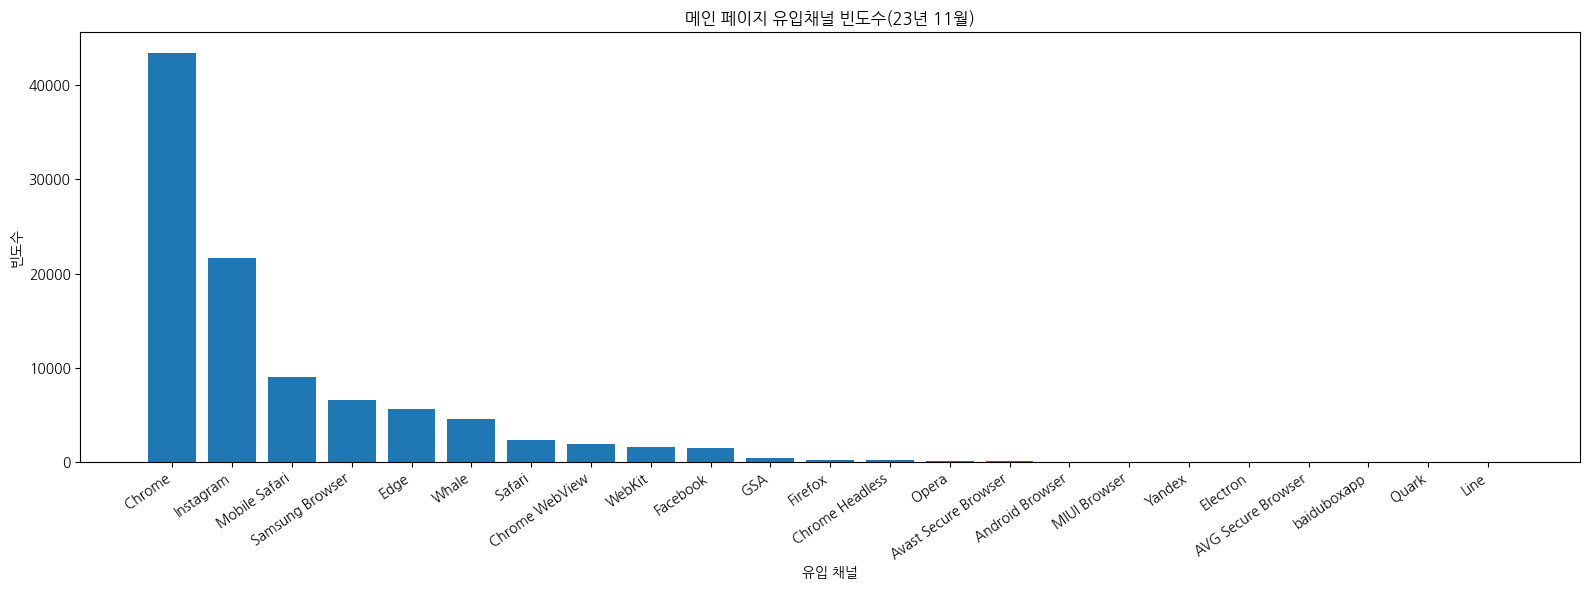

In [ ]:
# 메인페이지 유입 채널 수
os_name_counts = non_enter_main_month11['os_name'].value_counts().reset_index()

plt.figure(figsize=(16, 6))
plt.bar(os_name_counts['os_name'], os_name_counts['count'])
plt.xlabel('유입 채널')
plt.ylabel('빈도수')
plt.title('메인 페이지 유입채널 빈도수(23년 11월)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 회원가입 시 연동 채널 수

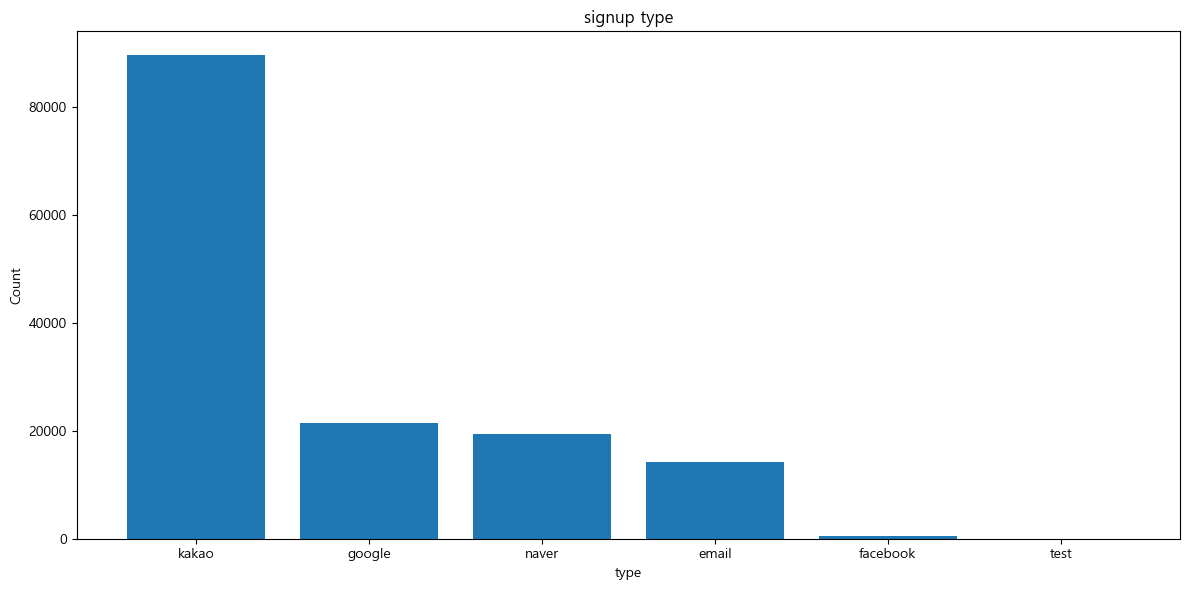

In [ ]:
# 메인페이지 유입 채널 수
type_counts = complete_signup['type'].value_counts().reset_index()

plt.figure(figsize=(12, 6))
plt.bar(type_counts['type'], type_counts['count'])
plt.xlabel('type')
plt.ylabel('Count')
plt.title('signup type')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

User_id: 047bd50251c4f27c3b5b00f94154e5ac의 여정

In [ ]:
click_cancel[click_cancel['user_id'] == '047bd50251c4f27c3b5b00f94154e5ac']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
3790,Jungnang-gu,2023-06-27 12:32:44.196,South Korea,NaN,Windows,Windows,click.cancel_plan_button,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac
13003,Seoul,2023-07-12 04:50:49.073,South Korea,NaN,Apple iPhone,Apple iPhone,click.cancel_plan_button,Korean,Mobile Safari,15.6.6,Web,047bd50251c4f27c3b5b00f94154e5ac
13670,Pohang,2023-07-16 10:22:50.759,South Korea,NaN,Windows,Windows,click.cancel_plan_button,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac
17415,Jungnang-gu,2023-07-30 07:42:38.812,South Korea,NaN,Windows,Windows,click.cancel_plan_button,Korean,Chrome,115.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac


In [ ]:
complete_sub[complete_sub['user_id'] == '047bd50251c4f27c3b5b00f94154e5ac']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,plan.type,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,month
2063,Jungnang-gu,2023-05-18 13:04:41.382,South Korea,NaN,Windows,Windows,complete.subscription,Korean,Chrome,113.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,15920,15920,1개월 플랜,NaN,NaN,0,NaN,2023-05


In [ ]:
renew_sub[renew_sub['user_id'] == '047bd50251c4f27c3b5b00f94154e5ac']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,membership.price,plan.type,paid_amount,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,month
8623,Pohang,2023-06-18 13:05:01.607,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2023-06
9731,Jungnang-gu,2023-07-29 00:38:51.872,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,115.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2023-07


In [ ]:
resubscribe[resubscribe['user_id'] == '047bd50251c4f27c3b5b00f94154e5ac']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,plan.type,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,month


In [ ]:
start_free[start_free['user_id'] == '047bd50251c4f27c3b5b00f94154e5ac']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,plan.type,trial.type


In [ ]:
click_content_start[click_content_start['user_id'] == '047bd50251c4f27c3b5b00f94154e5ac']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,button.name,genre.id,genre.name,button_name
3240,Pohang,2023-06-10 22:31:35.500000,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,ff7998135d650dbefb3f479c900cbcc7,콘텐츠 구독하기,NaN,NaN,NaN
6918,Jungnang-gu,2023-06-27 11:22:48.209000,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,6384828b0188f36e5915ed72fdeb7157,콘텐츠 이어보기,NaN,NaN,NaN
14283,Jungnang-gu,2023-06-04 09:52:53.571000,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,113.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,445fac33232adcb3d1cdab7d8a579430,콘텐츠 구독하기,NaN,NaN,NaN
14284,Jungnang-gu,2023-06-04 09:52:53.697000,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,113.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,445fac33232adcb3d1cdab7d8a579430,콘텐츠 구독하기,NaN,NaN,NaN
33527,Jungnang-gu,2023-06-19 11:57:40.160000,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,ca35d0138a7550f002f975310604a9b7,콘텐츠 구독하기,NaN,NaN,NaN
45165,Pohang,2023-05-16 23:21:56.654000,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,113.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,f4be1a0fe0e301b03115591777fddf29,콘텐츠 이어보기,NaN,NaN,NaN
49477,Pohang,2023-06-10 12:06:21.671000,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,ff7998135d650dbefb3f479c900cbcc7,콘텐츠 구독하기,NaN,NaN,NaN
53438,Jungnang-gu,2023-05-23 13:11:33.667000,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,113.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,f491517f4737a60d661cd1fcacc702c0,콘텐츠 이어보기,NaN,NaN,NaN
148554,Seoul,2023-07-01 03:02:36.623000,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,220ce7873b8895d0c81c37600b5bd1e7,콘텐츠 구독하기,NaN,NaN,NaN
155227,Jungnang-gu,2023-08-01 02:26:58.694000,South Korea,NaN,Windows,Windows,click.content_page_start_content_button,Korean,Chrome,115.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,6c114626032aa4a43c62fd7fcdb19543,콘텐츠 이어보기,NaN,NaN,NaN


In [ ]:
enter_episode[enter_episode['user_id'] == '047bd50251c4f27c3b5b00f94154e5ac']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,content.id,is_trial,episode.id,is_free_trial,month,korea
132319,Jungnang-gu,2023-06-12 12:01:40.314,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,6ed981e96eb69b7169b85ed3994a4980,False,d3555791c9077fb472acb7ee5bd88244,NaN,2023-06,korea
132320,Jungnang-gu,2023-06-12 12:14:22.589,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,6ed981e96eb69b7169b85ed3994a4980,False,d3555791c9077fb472acb7ee5bd88244,NaN,2023-06,korea
132321,Jungnang-gu,2023-06-12 12:14:25.562,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,6ed981e96eb69b7169b85ed3994a4980,False,c0ef0f527fac223719e8157bf0488f78,NaN,2023-06,korea
132322,Jungnang-gu,2023-06-12 12:14:48.987,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,6ed981e96eb69b7169b85ed3994a4980,False,d3555791c9077fb472acb7ee5bd88244,NaN,2023-06,korea
132323,Jungnang-gu,2023-06-12 12:14:58.097,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,6ed981e96eb69b7169b85ed3994a4980,False,c0ef0f527fac223719e8157bf0488f78,NaN,2023-06,korea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21014701,Jungnang-gu,2023-07-01 00:24:32.705,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,512a6f0abaef16c51950d52ce2d66fda,False,ca8755457bb9b9cc07df6195fbd77fee,NaN,2023-07,korea
21014702,Jungnang-gu,2023-07-01 00:24:34.770,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,512a6f0abaef16c51950d52ce2d66fda,False,fa3a4c8a0b354f347d7c3ca46ddf125f,NaN,2023-07,korea
21014703,Jungnang-gu,2023-07-01 00:51:11.200,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,512a6f0abaef16c51950d52ce2d66fda,False,fa3a4c8a0b354f347d7c3ca46ddf125f,NaN,2023-07,korea
21014704,Jungnang-gu,2023-07-01 00:51:13.540,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,114.0.0.0,Web,047bd50251c4f27c3b5b00f94154e5ac,512a6f0abaef16c51950d52ce2d66fda,False,28350e4b60d63eb8691507db73e85f39,NaN,2023-07,korea


## 첫 결제고객 구매여정 퍼널분석

enter_main

enter_signup

complete_signup

enter_payment

complete_sub

In [ ]:
enter_main['client_event_time'] = pd.to_datetime(enter_main['client_event_time'])
enter_signup['client_event_time'] = pd.to_datetime(enter_signup['client_event_time'])
complete_signup['client_event_time'] = pd.to_datetime(complete_signup['client_event_time'])
enter_payment['client_event_time'] = pd.to_datetime(enter_payment['client_event_time'])
complete_sub['client_event_time'] = pd.to_datetime(complete_sub['client_event_time'])
start_free['client_event_time'] = pd.to_datetime(start_free['client_event_time'])

In [ ]:
print(enter_main[enter_main['client_event_time'] > pd.to_datetime('2021-01-01')]['client_event_time'].min())
print(enter_signup['client_event_time'].min())
print(complete_signup['client_event_time'].min())
print(enter_payment['client_event_time'].min())
print(complete_sub['client_event_time'].min())

2021-05-10 06:16:35.916000
2021-11-25 00:08:17.825000
2022-01-01 00:06:31.232000
2022-11-03 02:39:46.400000
2022-01-01 06:17:24.513000


In [ ]:
print(enter_main[enter_main['client_event_time'] > pd.to_datetime('2021-01-01')]['client_event_time'].max())
print(enter_signup['client_event_time'].max())
print(complete_signup['client_event_time'].max())
print(enter_payment['client_event_time'].max())
print(complete_sub['client_event_time'].max())

2023-12-15 02:46:11.182000
2023-12-31 23:59:22.267000
2023-12-31 23:51:53.728000
2023-12-10 14:56:01.475000
2023-12-31 16:27:37.370000


In [ ]:
# 2022-12-01부터 2023-11-30까지 1년 기간 동안의 전환율
# 날짜 범위를 설정 (2022-12-01부터 2023-11-30까지)
start_date = pd.to_datetime('2022-12-01')
end_date = pd.to_datetime('2023-11-30')

enter_main_1year = enter_main[enter_main['client_event_time'].between(start_date, end_date)]
enter_signup_1year = enter_signup[enter_signup['client_event_time'].between(start_date, end_date)]
complete_signup_1year = complete_signup[complete_signup['client_event_time'].between(start_date, end_date)]
payment_1year = enter_payment[enter_payment['client_event_time'].between(start_date, end_date)]
sub_1year = complete_sub[complete_sub['client_event_time'].between(start_date, end_date)]
free_1year = start_free[start_free['client_event_time'].between(start_date, end_date)]

In [ ]:
# 첫 결제까지의 전환율
main_count = enter_main_1year[enter_main_1year['user_id'].isna()].shape[0] # user_id가 없는 경우만
signup_count = enter_signup_1year.shape[0] # 모든 행이 user_id가 없음
complete_signup_count = complete_signup_1year.shape[0]

# 회원가입 한 사람만 추적해서 결제 페이지 진입한 수 계산
filter_payment_1year = payment_1year[payment_1year['user_id'].isin(complete_signup['user_id'].unique())]['user_id'].unique()
payment_count = filter_payment_1year.shape[0]

# 회원가입 한 사람 중 결제 페이지 진입한 사람만 추적해서 첫 결제한 수 계산  
sub_count = sub_1year[sub_1year['user_id'].isin(filter_payment_1year)]['user_id'].unique().shape[0]


#전환율
print(f'메인 페이지 -> 회원가입 페이지 {(signup_count/main_count * 100):.2f}%')
print(f'회원가입 페이지 -> 회원가입 완료 {(complete_signup_count/signup_count * 100):.2f}%')
print(f'회원가입 완료 -> 결제 페이지 {(payment_count/complete_signup_count * 100):.2f}%')
print(f'결제 페이지 -> 첫 결제 {(sub_count/payment_count * 100):.2f}%')

메인 페이지 -> 회원가입 페이지 35.29%
회원가입 페이지 -> 회원가입 완료 22.78%
회원가입 완료 -> 결제 페이지 62.13%
결제 페이지 -> 첫 결제 12.10%


In [ ]:
# 단계와 사용자 수 정의
stages = ['메인 페이지', '회원가입 페이지', '회원가입 완료', '결제 페이지', '첫 결제']
values = [main_count, signup_count, complete_signup_count, payment_count, sub_count] 

# 이탈율 계산
dropoff_rates = [(values[i] - values[i+1]) / values[i] * 100 if values[i] != 0 else 0 for i in range(len(values)-1)]
dropoff_rates = [0] + dropoff_rates  # 첫 단계에 0% 추가

# 사용자 수와 이탈율을 결합하여 표시할 텍스트 생성
text_info = [f"{values[i]} ({dropoff_rates[i]:.1f}%)" for i in range(len(values))]

# 퍼널 차트 생성
fig = go.Figure(go.Funnel(
    y=stages,
    x=values,
    textinfo="value+percent initial",
    textposition="inside",
    text=text_info,
    marker={"color": ["blue", "green", "orange", "red", "purple"]}
))

# 이탈율 주석 추가
for i in range(len(dropoff_rates)-1):
    fig.add_annotation(
        x=100000,  # y 값 사이의 중간 위치
        y=stages[i],  # 첫 번째 단계에 위치
        text=f"<b>이탈율: {dropoff_rates[i+1]:.1f}%<b>",  # 이탈율 텍스트
        showarrow=False,
        font=dict(size=12, color="black"),
        bgcolor="white",
        yref="y",  # y 레퍼런스를 y축으로 설정
        yanchor="bottom",  # y축의 아래쪽에 고정
        yshift=-70  # y 값을 아래로 이동 (조정 가능)
    )

# 레이아웃 업데이트
fig.update_layout(
    title="퍼널 분석: 사용자 전환율과 이탈율",
    yaxis_title="단계",
    xaxis_title="사용자 수",
    width=1400,   # 너비 설정
    height=800   # 높이 설정
)

# 차트 표시
fig.show()

회원 가입 완료 -> 결제 페이지의 경우를 제외하고 모두 이탈율이 높다. 결제 페이지에서 첫 결제로 가는 이탈율이 높은 이유는 무료체험 때문일 가능성이 있다.

In [ ]:
# 첫 결제까지의 전환율
main_count = enter_main_1year[enter_main_1year['user_id'].isna()].shape[0] # user_id가 없는 경우만
signup_count = enter_signup_1year.shape[0] # 모든 행이 user_id가 없음
complete_signup_count = complete_signup_1year.shape[0]

# 회원가입 한 사람만 추적해서 결제 페이지 진입한 수 계산
filter_payment_1year = payment_1year[payment_1year['user_id'].isin(complete_signup['user_id'].unique())]['user_id'].unique()
payment_count = filter_payment_1year.shape[0]


filter_free = start_free[start_free['user_id'].isin(filter_payment_1year)]['user_id'].unique()
free_count = filter_free.shape[0]

free_to_sub_count = sub_1year[sub_1year['user_id'].isin(filter_free)]['user_id'].unique().shape[0]


#전환율
print(f'메인 페이지 -> 회원가입 페이지 {(signup_count/main_count * 100):.2f}%')
print(f'회원가입 페이지 -> 회원가입 완료 {(complete_signup_count/signup_count * 100):.2f}%')
print(f'회원가입 완료 -> 무료체험 {(free_count/complete_signup_count * 100):.2f}%')
print(f'무료체험-> 첫 결제 {(free_to_sub_count/free_count * 100):.2f}%')

메인 페이지 -> 회원가입 페이지 35.29%
회원가입 페이지 -> 회원가입 완료 22.78%
회원가입 완료 -> 무료체험 4.19%
무료체험-> 첫 결제 29.45%


In [ ]:
# 단계와 사용자 수 정의
stages = ['메인 페이지', '회원가입 페이지', '회원가입 완료', '무료체험', '첫 결제']
values = [main_count, signup_count, complete_signup_count, free_count, free_to_sub_count] 

# 이탈율 계산
dropoff_rates = [(values[i] - values[i+1]) / values[i] * 100 if values[i] != 0 else 0 for i in range(len(values)-1)]
dropoff_rates = [0] + dropoff_rates  # 첫 단계에 0% 추가

# 사용자 수와 이탈율을 결합하여 표시할 텍스트 생성
text_info = [f"{values[i]} ({dropoff_rates[i]:.1f}%)" for i in range(len(values))]

# 퍼널 차트 생성
fig = go.Figure(go.Funnel(
    y=stages,
    x=values,
    textinfo="value+percent initial",
    textposition="inside",
    text=text_info,
    marker={"color": ["blue", "green", "orange", "red", "purple"]}
))

# 이탈율 주석 추가
for i in range(len(dropoff_rates)-1):
    fig.add_annotation(
        x=100000,  # y 값 사이의 중간 위치
        y=stages[i],  # 첫 번째 단계에 위치
        text=f"<b>이탈율: {dropoff_rates[i+1]:.1f}%<b>",  # 이탈율 텍스트
        showarrow=False,
        font=dict(size=12, color="black"),
        bgcolor="white",
        yref="y",  # y 레퍼런스를 y축으로 설정
        yanchor="bottom",  # y축의 아래쪽에 고정
        yshift=-70  # y 값을 아래로 이동 (조정 가능)
    )

# 레이아웃 업데이트
fig.update_layout(
    title="퍼널 분석: 사용자 전환율과 이탈율",
    yaxis_title="단계",
    xaxis_title="사용자 수",
    width=1400,   # 너비 설정
    height=800   # 높이 설정
)

# 차트 표시
fig.show()

In [ ]:
print(start_free[start_free['trial.type'] == 'B']['client_event_time'].min())
print(start_free[start_free['trial.type'] == 'B']['client_event_time'].max())


2023-01-31 15:03:03.291000
2023-04-30 14:59:47.032000


In [ ]:
# 2022-12-01부터 2023-11-30까지 1년 기간 동안의 전환율
# 날짜 범위를 설정 (2023-02-01부터 2023-04-30까지)
start_date = pd.to_datetime('2023-02-01')
end_date = pd.to_datetime('2023-04-30')

enter_main_3month = enter_main[enter_main['client_event_time'].between(start_date, end_date)]
enter_signup_3month = enter_signup[enter_signup['client_event_time'].between(start_date, end_date)]
complete_signup_3month = complete_signup[complete_signup['client_event_time'].between(start_date, end_date)]
payment_3month = enter_payment[enter_payment['client_event_time'].between(start_date, end_date)]
sub_3month = complete_sub[complete_sub['client_event_time'].between(start_date, end_date)]
free_3month = start_free[start_free['client_event_time'].between(start_date, end_date)]

In [ ]:
# 첫 결제까지의 전환율
main_count = enter_main_3month[enter_main_3month['user_id'].isna()].shape[0] # user_id가 없는 경우만
signup_count = enter_signup_3month.shape[0] # 모든 행이 user_id가 없음
complete_signup_count = complete_signup_3month.shape[0]

# 회원가입 한 사람만 추적해서 결제 페이지 진입한 수 계산
filter_payment_3month = payment_3month[payment_3month['user_id'].isin(complete_signup['user_id'].unique())]['user_id'].unique()
payment_count = filter_payment_3month.shape[0]


filter_free = start_free[start_free['user_id'].isin(filter_payment_3month)]['user_id'].unique()
free_count = filter_free.shape[0]

free_to_sub_count = sub_3month[sub_3month['user_id'].isin(filter_free)]['user_id'].unique().shape[0]


#전환율
print(f'메인 페이지 -> 회원가입 페이지 {(signup_count/main_count * 100):.2f}%')
print(f'회원가입 페이지 -> 회원가입 완료 {(complete_signup_count/signup_count * 100):.2f}%')
print(f'회원가입 완료 -> 무료체험 {(free_count/complete_signup_count * 100):.2f}%')
print(f'무료체험-> 첫 결제 {(free_to_sub_count/free_count * 100):.2f}%')

메인 페이지 -> 회원가입 페이지 35.22%
회원가입 페이지 -> 회원가입 완료 22.99%
회원가입 완료 -> 무료체험 13.35%
무료체험-> 첫 결제 31.89%


In [ ]:
# 단계와 사용자 수 정의
stages = ['메인 페이지', '회원가입 페이지', '회원가입 완료', '무료체험', '첫 결제']
values = [main_count, signup_count, complete_signup_count, free_count, free_to_sub_count] 

# 이탈율 계산
dropoff_rates = [(values[i] - values[i+1]) / values[i] * 100 if values[i] != 0 else 0 for i in range(len(values)-1)]
dropoff_rates = [0] + dropoff_rates  # 첫 단계에 0% 추가

# 사용자 수와 이탈율을 결합하여 표시할 텍스트 생성
text_info = [f"{values[i]} ({dropoff_rates[i]:.1f}%)" for i in range(len(values))]

# 퍼널 차트 생성
fig = go.Figure(go.Funnel(
    y=stages,
    x=values,
    textinfo="value+percent initial",
    textposition="inside",
    text=text_info,
    marker={"color": ["blue", "green", "orange", "red", "purple"]}
))

# 이탈율 주석 추가
for i in range(len(dropoff_rates)-1):
    fig.add_annotation(
        x=10000,  # y 값 사이의 중간 위치
        y=stages[i],  # 첫 번째 단계에 위치
        text=f"<b>이탈율: {dropoff_rates[i+1]:.1f}%<b>",  # 이탈율 텍스트
        showarrow=False,
        font=dict(size=12, color="black"),
        bgcolor="white",
        yref="y",  # y 레퍼런스를 y축으로 설정
        yanchor="bottom",  # y축의 아래쪽에 고정
        yshift=-70  # y 값을 아래로 이동 (조정 가능)
    )

# 레이아웃 업데이트
fig.update_layout(
    title="퍼널 분석: 사용자 전환율과 이탈율",
    yaxis_title="단계",
    xaxis_title="사용자 수",
    width=1400,   # 너비 설정
    height=800   # 높이 설정
)

# 차트 표시
fig.show()

In [ ]:
# 23년도 11월의 1개월 기간 전환율
# 날짜 범위를 설정 (2023-11-01부터 2023-11-30까지)
start_date = pd.to_datetime('2023-11-01')
end_date = pd.to_datetime('2023-11-30')

enter_main_1month = enter_main[enter_main['client_event_time'].between(start_date, end_date)]
enter_signup_1month = enter_signup[enter_signup['client_event_time'].between(start_date, end_date)]
complete_signup_1month = complete_signup[complete_signup['client_event_time'].between(start_date, end_date)]
payment_1month = enter_payment[enter_payment['client_event_time'].between(start_date, end_date)]
sub_1month = complete_sub[complete_sub['client_event_time'].between(start_date, end_date)]
free_1month = start_free[start_free['client_event_time'].between(start_date, end_date)]

In [ ]:
# 첫 결제까지의 전환율
main_count = enter_main_1month[enter_main_1month['user_id'].isna()].shape[0] # user_id가 없는 경우만
signup_count = enter_signup_1month.shape[0] # 모든 행이 user_id가 없음
complete_signup_count = complete_signup_1month.shape[0]

# 회원가입 한 사람만 추적해서 결제 페이지 진입한 수 계산
filter_payment_1month = payment_1month[payment_1month['user_id'].isin(complete_signup['user_id'].unique())]['user_id'].unique()
payment_count = filter_payment_1month.shape[0]

# 회원가입 한 사람 중 결제 페이지 진입한 사람만 추적해서 첫 결제한 수 계산  
sub_count = sub_1month[sub_1month['user_id'].isin(filter_payment_1month)]['user_id'].unique().shape[0]


#전환율
print(f'메인 페이지 -> 회원가입 페이지 {(signup_count/main_count * 100):.2f}%')
print(f'회원가입 페이지 -> 회원가입 완료 {(complete_signup_count/signup_count * 100):.2f}%')
print(f'회원가입 완료 -> 결제 페이지 {(payment_count/complete_signup_count * 100):.2f}%')
print(f'결제 페이지 -> 첫 결제 {(sub_count/payment_count * 100):.2f}%')

메인 페이지 -> 회원가입 페이지 39.18%
회원가입 페이지 -> 회원가입 완료 20.06%
회원가입 완료 -> 결제 페이지 65.28%
결제 페이지 -> 첫 결제 9.57%


In [ ]:
# 단계와 사용자 수 정의
stages = ['메인 페이지', '회원가입 페이지', '회원가입 완료', '결제 페이지', '첫 결제']
values = [main_count, signup_count, complete_signup_count, payment_count, sub_count] 

# 이탈율 계산
dropoff_rates = [(values[i] - values[i+1]) / values[i] * 100 if values[i] != 0 else 0 for i in range(len(values)-1)]
dropoff_rates = [0] + dropoff_rates  # 첫 단계에 0% 추가

# 사용자 수와 이탈율을 결합하여 표시할 텍스트 생성
text_info = [f"{values[i]} ({dropoff_rates[i]:.1f}%)" for i in range(len(values))]

# 퍼널 차트 생성
fig = go.Figure(go.Funnel(
    y=stages,
    x=values,
    textinfo="value+percent initial",
    textposition="inside",
    text=text_info,
    marker={"color": ["blue", "green", "orange", "red", "purple"]}
))

# 이탈율 주석 추가
for i in range(len(dropoff_rates)-1):
    fig.add_annotation(
        x=100000,  # y 값 사이의 중간 위치
        y=stages[i],  # 첫 번째 단계에 위치
        text=f"<b>이탈율: {dropoff_rates[i+1]:.1f}%<b>",  # 이탈율 텍스트
        showarrow=False,
        font=dict(size=12, color="black"),
        bgcolor="white",
        yref="y",  # y 레퍼런스를 y축으로 설정
        yanchor="bottom",  # y축의 아래쪽에 고정
        yshift=-70  # y 값을 아래로 이동 (조정 가능)
    )

# 레이아웃 업데이트
fig.update_layout(
    title="퍼널 분석: 사용자 전환율과 이탈율",
    yaxis_title="단계",
    xaxis_title="사용자 수",
    width=1400,   # 너비 설정
    height=800   # 높이 설정
)

# 차트 표시
fig.show()

In [ ]:
free_count = free_1year[free_1year['user_id'].isin(complete_signup['user_id'].unique())]['user_id'].unique().shape[0]
free_count

2313

In [ ]:
enter_main['client_event_time'] = pd.to_datetime(enter_main['client_event_time'])

In [ ]:
enter_content.isna().sum()

city                   30757
client_event_time          0
country                 7570
device_carrier       1914257
device_family            639
device_type            23651
event_type                 0
language                   0
os_name                  149
os_version              2549
platform                   0
user_id               465168
content.id                 0
dtype: int64

In [ ]:
click_content_start.isna().sum()

city                   3474
client_event_time         0
country                1416
device_carrier       172911
device_family             0
device_type            1330
event_type                0
language                  0
os_name                   0
os_version              318
platform                  0
user_id               44550
content.id              212
button.name           86669
genre.id             133960
genre.name           133960
button_name          133960
dtype: int64

In [ ]:
click_content_more.isna().sum()

city                   170
client_event_time        0
country                 18
device_carrier       93962
device_family            0
device_type             53
event_type               0
language                 0
os_name                  0
os_version               3
platform                 0
user_id              83260
content.id              24
dtype: int64

In [ ]:
click_content_start['button.name'].unique()

array(['콘텐츠 구독하기', '콘텐츠 이어보기', '최저가 혜택 받기 (54% 할인)', '무료로 시청하기',
       '무료로 시작하기', '구독 시작하기', '최저가로 시작하기', '최저가 혜택 받기 (52% 할인)',
       '최저가 혜택 받기 (50% 할인)', '최저가 혜택 받기 (56% 할인)', '최저가 혜택 받기 (59% 할인)',
       '할인받고 구독 시작', '최저가 혜택 받기 (31% 할인)', nan], dtype=object)

In [ ]:
click_content_start['button_name'].unique()

array([nan, '이어보기', '무료로 시청하기', '구독하기', '바로보기'], dtype=object)

In [ ]:
renew_sub

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,membership.price,plan.type,paid_amount,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,month
0,Nam-gu,2022-09-08 03:05:02.068,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Edge,104,Web,6ddea3af2eaae869861c1190dcc9d4a3,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2022-09
1,Nam-gu,2022-09-08 03:40:02.050,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,c2d47034960fdff5df495822ff66fbc1,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2022-09
2,Dongjak-gu,2022-09-08 03:49:00.829,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,de91f1226dd938990fefc79545daf468,42960,3개월 플랜,40812,REWARD,DISCOUNT,2148,NaN,2022-09
3,Yongin-si,2022-09-08 04:10:06.406,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,bf14840a8cb4643e6d557da96e35a3af,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2022-09
4,Dongjak-gu,2022-09-08 04:40:01.895,South Korea,NaN,Android,Android,renew.subscription,Korean,Chrome Mobile,103,Web,7ddc1c2990d0645d82885394e3c518b5,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2022-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15940,Seoul,2023-12-31 14:45:02.023,South Korea,NaN,Mac,Mac,renew.subscription,Korean,Safari,16.3,Web,65b0ef224104a149832d010417e5d698,95520,12개월 플랜(2024 프로모션),95520,NaN,NaN,0,A,2023-12
15941,Cheonan,2023-12-31 14:45:02.716,South Korea,NaN,Samsung Galaxy Note,Samsung Galaxy Note9,renew.subscription,Korean,Chrome,108.0.0.0,Web,abf7852a86c5efeac694c93a144c7021,95520,12개월 플랜(2024 프로모션),95520,NaN,NaN,0,A,2023-12
15942,Gwanak-gu,2023-12-31 14:50:01.514,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,116.0.0.0,Web,f5da5f17623107c7be18277488e4ba07,95520,12개월 플랜(2024 프로모션),95520,NaN,NaN,0,A,2023-12
15943,Seoul,2023-12-31 14:50:02.215,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,114.0.0.0,Web,44b77c4b10b428a1ad5c89011d0fe27e,95520,12개월 플랜(2024 프로모션),95520,NaN,NaN,0,A,2023-12


In [ ]:
renew_sub[renew_sub['plan.type'] == '12개월 플랜']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,membership.price,plan.type,paid_amount,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,month
18,Jeju City,2022-09-08 11:00:01.634,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,782d8bafdd276b9149b47c68873a61d9,131600,12개월 플랜,131600,NaN,NaN,0,NaN,2022-09
76,Seoul,2022-09-10 05:00:02.353,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,105,Web,c8f6102f933aad78c5afda5e4fbf7dc4,131600,12개월 플랜,131600,NaN,NaN,0,NaN,2022-09
77,Seoul,2022-09-10 05:00:02.551,South Korea,NaN,Apple iPhone,Apple iPhone,renew.subscription,Korean,Mobile Safari,15,Web,f0f299123017deaab370fb0657d7ec99,131600,12개월 플랜,131600,NaN,NaN,0,NaN,2022-09
82,Namdong-gu,2022-09-10 06:35:01.865,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,fa1f4d2ea602692a76c23b44255c8a52,131600,12개월 플랜,131600,NaN,NaN,0,NaN,2022-09
117,Cheonan,2022-09-11 04:50:09.718,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,103,Web,c5615b10ed83f6022948de41ba281ad6,131600,12개월 플랜,131600,NaN,NaN,0,NaN,2022-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15375,Yeonsu-gu,2023-12-23 00:25:02.787,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,117.0.0.0,Web,e16d33a7795ab1c3584894510e7d8754,131600,12개월 플랜,92119,OPERATION,DISCOUNT,39481,A,2023-12
15492,Dongjak-gu,2023-12-25 23:00:01.592,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,116.0.0.0,Web,69ac6e7df0cf09077ff51cf673607904,131600,12개월 플랜,92119,OPERATION,DISCOUNT,39481,A,2023-12
15566,Yuseong-gu,2023-12-27 05:40:03.029,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,120.0.0.0,Web,9be9b0d00511514ed1a24d18b112bb01,131600,12개월 플랜,92119,OPERATION,DISCOUNT,39481,A,2023-12
15772,Dobong-gu,2023-12-30 07:10:02.685,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,119.0.0.0,Web,4a21d9405c56bee616adda27bfe4a847,131600,12개월 플랜,92119,OPERATION,DISCOUNT,39481,A,2023-12


In [ ]:
renew_sub[renew_sub['user_id'] == '9be9b0d00511514ed1a24d18b112bb01']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,membership.price,plan.type,paid_amount,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,month
3869,Daejeon,2022-12-22 05:02:30.789,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,108.0.0.0,Web,9be9b0d00511514ed1a24d18b112bb01,79200,12개월 플랜,79200,NaN,NaN,0,NaN,2022-12
15566,Yuseong-gu,2023-12-27 05:40:03.029,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,120.0.0.0,Web,9be9b0d00511514ed1a24d18b112bb01,131600,12개월 플랜,92119,OPERATION,DISCOUNT,39481,A,2023-12


In [ ]:
complete_sub[complete_sub['user_id'] == '9be9b0d00511514ed1a24d18b112bb01']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,plan.type,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,month
9316,Daejeon,2022-11-27 05:36:45.632,South Korea,NaN,Windows,Windows,complete.subscription,Korean,Chrome,107.0.0.0,Web,9be9b0d00511514ed1a24d18b112bb01,15920,3960,1개월 플랜,NaN,NaN,11960,NaN,2022-11


In [ ]:
click_cancel[click_cancel['user_id'] == '9be9b0d00511514ed1a24d18b112bb01']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
2561,Daejeon,2023-01-10 03:52:55.559,South Korea,NaN,Windows,Windows,click.cancel_plan_button,Korean,Chrome,108.0.0.0,Web,9be9b0d00511514ed1a24d18b112bb01
16134,Seoul,2023-09-05 08:52:42.077,South Korea,NaN,Mac,Mac,click.cancel_plan_button,Korean,Safari,16.5.2,Web,9be9b0d00511514ed1a24d18b112bb01


In [ ]:
renew_sub[renew_sub['user_id'] == 'c2d47034960fdff5df495822ff66fbc1']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,membership.price,plan.type,paid_amount,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,month
1,Nam-gu,2022-09-08 03:40:02.050,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,104,Web,c2d47034960fdff5df495822ff66fbc1,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2022-09
1135,Gijang-gun,2022-10-08 03:45:01.734,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Chrome,105,Web,c2d47034960fdff5df495822ff66fbc1,15920,1개월 플랜,7960,OPERATION,DISCOUNT,7960,NaN,2022-10
10455,Seoul,2023-08-17 08:30:01.293,South Korea,NaN,Mac,Mac,renew.subscription,Korean,Safari,16.5.2,Web,c2d47034960fdff5df495822ff66fbc1,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2023-08
11673,Geumjeong-gu,2023-09-17 08:35:02.707,South Korea,NaN,Windows,Windows,renew.subscription,Korean,Whale,3.21.192.18,Web,c2d47034960fdff5df495822ff66fbc1,15920,1개월 플랜,15920,NaN,NaN,0,NaN,2023-09


In [ ]:
resubscribe[resubscribe['user_id'] == 'c2d47034960fdff5df495822ff66fbc1']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,plan.type,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,month
519,Seoul,2023-07-17 08:25:12.461,South Korea,NaN,Apple iPhone,Apple iPhone,resubscribe.subscription,Korean,Mobile Safari,16.5.2,Web,c2d47034960fdff5df495822ff66fbc1,15920,15920,1개월 플랜,NaN,NaN,0,NaN,2023-07


In [ ]:
complete_sub[complete_sub['user_id'] == 'c2d47034960fdff5df495822ff66fbc1']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id,plan.price,paid_amount,plan.type,coupon.type,coupon.benefit_type,coupon.discount_amount,pg.type,month
3575,Nam-gu,2022-07-08 03:34:27.439,South Korea,NaN,Windows,Windows,complete.subscription,Korean,Chrome,103,Web,c2d47034960fdff5df495822ff66fbc1,15920,15920,1개월 플랜,NaN,NaN,0,NaN,2022-07


In [ ]:
click_cancel[click_cancel['user_id'] == 'c2d47034960fdff5df495822ff66fbc1']

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,platform,user_id
11075,Geoje-si,2022-10-31 14:35:22.210,South Korea,NaN,Windows,Windows,click.cancel_plan_button,Korean,Chrome,107,Web,c2d47034960fdff5df495822ff66fbc1
15775,Seoul,2023-10-01 16:36:04.017,South Korea,NaN,Mac,Mac,click.cancel_plan_button,Korean,Safari,16.6,Web,c2d47034960fdff5df495822ff66fbc1


## 평일, 주말 시간대별 에피소드 열람 횟수

In [ ]:
# 2023년도에 가입한 고객 기준
f_enter_episode = enter_episode[enter_episode['user_id'].isin(users)]
f_enter_episode

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date,month
1258957,2023-03-18 19:34:28.892,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,2ed4b83e65edc2b1efb193aaa3c60cf9,True,NaN,2023-03-18,2023-03
1258983,2023-03-18 19:37:05.778,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,db421b66bfd27eccd0e862e30b4de1be,True,NaN,2023-03-18,2023-03
1259038,2023-03-18 19:42:48.654,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,09c8a2d29087cb3d47823acb5f2705e3,True,NaN,2023-03-18,2023-03
1259071,2023-03-18 19:46:07.383,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,b734f43b5123f8bdbf7d8f865bd3eacf,True,NaN,2023-03-18,2023-03
1259120,2023-03-18 19:51:40.154,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,6e3afbeb4942c6c29038321e5995f4f1,True,NaN,2023-03-18,2023-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3900877,2023-11-15 14:03:20.206,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,a6a8c4b3f5b40b8a96c8f6db10e43bf8,False,NaN,2023-11-15,2023-11
3900910,2023-11-15 14:06:00.833,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,False,NaN,2023-11-15,2023-11
3982822,2023-11-30 12:25:33.257,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-30,2023-11
3982827,2023-11-30 12:27:05.918,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN,2023-11-30,2023-11


In [ ]:
# 시간 추출
enter_episode['hour'] = enter_episode['client_event_time'].dt.hour

# 요일 추출 (0=월요일, 6=일요일)
enter_episode['day_of_week'] = enter_episode['client_event_time'].dt.dayofweek

# 평일과 주말 구분 (주말은 토요일(5)과 일요일(6))
enter_episode['weekday_or_weekend'] = enter_episode['day_of_week'].apply(lambda x: '주말' if x >= 5 else '평일')

In [ ]:
print(enter_episode['client_event_time'].min())
print(enter_episode['client_event_time'].max())

2023-01-01 00:22:20.400000
2023-12-30 23:58:55.925000


In [ ]:
# 2022년도 12월 1일 ~ 2023년 11월 30일까지 에피소드 열람 기록
start_date = pd.to_datetime('2022-12-01')
end_date = pd.to_datetime('2023-11-30')

enter_episode_1year = enter_episode[enter_episode['client_event_time'].between(start_date, end_date)]
enter_episode_1year

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date,month,hour,day_of_week,weekday_or_weekend
1258957,2023-03-18 19:34:28.892,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,2ed4b83e65edc2b1efb193aaa3c60cf9,True,NaN,2023-03-18,2023-03,19,5,주말
1258983,2023-03-18 19:37:05.778,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,db421b66bfd27eccd0e862e30b4de1be,True,NaN,2023-03-18,2023-03,19,5,주말
1259038,2023-03-18 19:42:48.654,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,09c8a2d29087cb3d47823acb5f2705e3,True,NaN,2023-03-18,2023-03,19,5,주말
1259071,2023-03-18 19:46:07.383,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,b734f43b5123f8bdbf7d8f865bd3eacf,True,NaN,2023-03-18,2023-03,19,5,주말
1259120,2023-03-18 19:51:40.154,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,6e3afbeb4942c6c29038321e5995f4f1,True,NaN,2023-03-18,2023-03,19,5,주말
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3544538,2023-10-15 03:42:25.138,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-10-15,2023-10,3,6,주말
3900648,2023-11-15 13:45:35.421,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-15,2023-11,13,2,평일
3900877,2023-11-15 14:03:20.206,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,a6a8c4b3f5b40b8a96c8f6db10e43bf8,False,NaN,2023-11-15,2023-11,14,2,평일
3900910,2023-11-15 14:06:00.833,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,False,NaN,2023-11-15,2023-11,14,2,평일


In [ ]:
# 평일 데이터 필터링
episode_weekday_df = enter_episode_1year[enter_episode_1year['weekday_or_weekend'] == '평일']

# 주말 데이터 필터링
episode_weekend_df = enter_episode_1year[enter_episode_1year['weekday_or_weekend'] == '주말']

# 평일 시간대별 발생 횟수 집계
weekday_counts = episode_weekday_df.groupby('hour').size().reset_index(name='count')

# 주말 시간대별 발생 횟수 집계
weekend_counts = episode_weekend_df.groupby('hour').size().reset_index(name='count')

# 평일 시간대별 발생 횟수 시각화
fig_weekday = px.bar(weekday_counts, x='hour', y='count', 
                     title='평일 시간대별 이벤트 발생 횟수', labels={'hour': '시간대', 'count': '발생 횟수'})
fig_weekday.show()

# 주말 시간대별 발생 횟수 시각화
fig_weekend = px.bar(weekend_counts, x='hour', y='count', 
                     title='주말 시간대별 이벤트 발생 횟수', labels={'hour': '시간대', 'count': '발생 횟수'})
fig_weekend.show()

# AARRR 탐색

## Acqusition: 회원가입

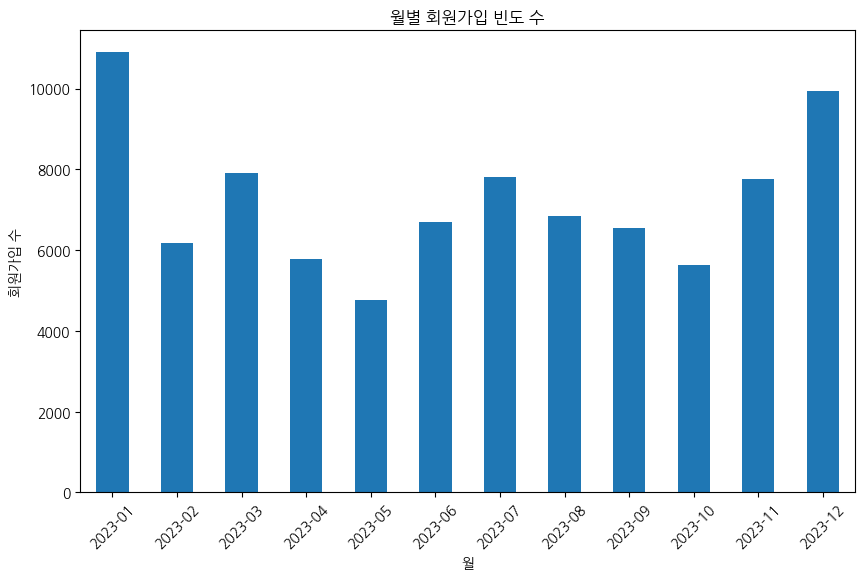

In [ ]:
complete_signup['client_event_time'] = pd.to_datetime(complete_signup['client_event_time'])

complete_signup = complete_signup[(complete_signup['client_event_time'] >= '2023-01-01') & (complete_signup['client_event_time'] < '2024-01-01')]

complete_signup['date'] = complete_signup['client_event_time'].dt.to_period('M')

monthly_signup_counts = complete_signup.groupby(complete_signup['date']).size()

plt.figure(figsize=(10, 6))
monthly_signup_counts.plot(kind='bar')
plt.title('월별 회원가입 빈도 수')
plt.xlabel('월')
plt.ylabel('회원가입 수')
plt.xticks(rotation=45)
plt.show()

In [ ]:
complete_signup_2023 = user_total[user_total['event_type'] == 'complete.signup']

# 시간 형식 변환 및 날짜만 추출
complete_signup_2023['date'] = complete_signup_2023['client_event_time'].dt.date

# DAU 계산: 날짜별 고유 사용자 수 세기
complete_signup_dau = complete_signup_2023.groupby('date')['user_id'].nunique().reset_index()
complete_signup_dau.columns = ['date', 'DAU']

complete_signup_dau

,date,DAU
0,2023-01-01,329
1,2023-01-02,389
2,2023-01-03,393
3,2023-01-04,347
4,2023-01-05,315
...,...,...
361,2023-12-28,355
362,2023-12-29,338
363,2023-12-30,382
364,2023-12-31,466


In [ ]:
# 2023년 데이터만 필터링
complete_signup_dau['date'] = pd.to_datetime(complete_signup_dau['date'])
complete_signup_dau_1year = complete_signup_dau[(complete_signup_dau['date'] >= '2023-01-01') & (complete_signup_dau['date'] <= '2023-12-31')]

# DAU 시각화
fig = px.line(complete_signup_dau_1year, x='date', y='DAU', title='Daily Active Users (DAU) for 2023',
              labels={'date': 'Date', 'DAU': 'Daily Active Users'},
              markers=True)

fig.show()

In [ ]:
# 시간 형식 변환 및 월만 추출
complete_signup_2023['month'] = complete_signup_2023['client_event_time'].dt.to_period('M')

# MAU 계산: 월별 고유 사용자 수 세기
complete_signup_mau = complete_signup_2023.groupby('month')['user_id'].nunique().reset_index()
complete_signup_mau.columns = ['month', 'MAU']

complete_signup_mau

,month,MAU
0,2023-01,10893
1,2023-02,6172
2,2023-03,7921
3,2023-04,5779
4,2023-05,4767
5,2023-06,6706
6,2023-07,7812
7,2023-08,6834
8,2023-09,6539
9,2023-10,5630


In [ ]:
# 2023년 데이터만 필터링
complete_signup_mau_1year = complete_signup_mau[(complete_signup_mau['month'] >= '2023-01') & (complete_signup_mau['month'] <= '2023-12')]
complete_signup_mau_1year['month'] = complete_signup_mau_1year['month'].astype(str)

# mau 시각화
fig = px.line(complete_signup_mau_1year, x='month', y='MAU', title='Daily Active Users (MAU) for 2023',
              labels={'month': 'Date', 'MAU': 'Month Active Users'},
              markers=True)

fig.show()

In [ ]:
# 날짜 형식 변환 및 월 컬럼 생성
complete_signup_dau['month'] = complete_signup_dau['date'].dt.to_period('M')

# month 열을 문자열 형식으로 변환
complete_signup_dau['month'] = complete_signup_dau['month'].astype(str)
complete_signup_mau['month'] = complete_signup_mau['month'].astype(str)

# 1일의 DAU 데이터만 필터링
first_day_dau = complete_signup_dau[complete_signup_dau['date'].dt.day == 1]

# 월별 DAU와 MAU 병합
merged_data = first_day_dau.merge(complete_signup_mau, on='month', suffixes=('_dau', '_mau'))

# 고착도 계산
merged_data['stickiness'] = (merged_data['DAU'] / merged_data['MAU']) * 100

# 결과 DataFrame 생성
complete_signup_stickiness = merged_data[['month', 'DAU', 'MAU', 'stickiness']]
complete_signup_stickiness

,month,DAU,MAU,stickiness
0,2023-01,329,10893,3.020288
1,2023-02,195,6172,3.159430
2,2023-03,296,7921,3.736902
3,2023-04,206,5779,3.564631
4,2023-05,159,4767,3.335431
5,2023-06,208,6706,3.101700
6,2023-07,209,7812,2.675371
7,2023-08,247,6834,3.614282
8,2023-09,266,6539,4.067900
9,2023-10,142,5630,2.522202


In [ ]:
# 2023년 데이터만 필터링
complete_signup_stickiness_1year = complete_signup_stickiness[(complete_signup_stickiness['month'] >= '2023-01') & (complete_signup_stickiness['month'] <= '2023-12')]
complete_signup_stickiness_1year['month'] = complete_signup_stickiness_1year['month'].astype(str)

# 고착도 시각화
fig = px.line(complete_signup_stickiness_1year, x='month', y='stickiness', title='complete_signup_stickiness_2023(day 1)',
            markers=True)
fig.show()

In [ ]:
# 월별 DAU 평균 계산
monthly_dau = complete_signup_dau.groupby('month')['DAU'].mean().reset_index()

# 고착도 계산
results = []
for index, row in monthly_dau.iterrows():
    month = row['month']
    dau_avg = row['DAU']
    
    # 해당 월의 MAU 찾기
    mau_value = complete_signup_mau[complete_signup_mau['month'] == str(month)]['MAU'].values[0]
    
    # 고착도 계산
    stickiness = (dau_avg / mau_value) * 100
    results.append({'month': str(month), 'DAU_Avg': dau_avg, 'MAU': mau_value, 'stickiness': stickiness})

# 결과 데이터프레임 생성
complete_signup_stickiness = pd.DataFrame(results)
complete_signup_stickiness

,month,DAU_Avg,MAU,stickiness
0,2023-01,351.387097,10893,3.225806
1,2023-02,220.428571,6172,3.571429
2,2023-03,255.516129,7921,3.225806
3,2023-04,192.633333,5779,3.333333
4,2023-05,153.774194,4767,3.225806
5,2023-06,223.533333,6706,3.333333
6,2023-07,252.000000,7812,3.225806
7,2023-08,220.451613,6834,3.225806
8,2023-09,217.966667,6539,3.333333
9,2023-10,181.612903,5630,3.225806


In [ ]:
# 2023년 데이터만 필터링
complete_signup_stickiness_1year = complete_signup_stickiness[(complete_signup_stickiness['month'] >= '2023-01') & (complete_signup_stickiness['month'] <= '2023-12')]
complete_signup_stickiness_1year['month'] = complete_signup_stickiness_1year['month'].astype(str)

# 고착도 시각화
fig = px.line(complete_signup_stickiness_1year, x='month', y='stickiness', title='complete_signup_stickiness_2023(avg)',
            markers=True)
fig.show()

## Acquisition: 메인페이지

In [ ]:
# 2023년도에 회원가입한 유저만
enter_main_2023 = enter_main[enter_main['user_id'].isin(users)]

enter_main_2023['date'] = enter_main_2023['client_event_time'].dt.date

# DAU 계산: 날짜별 고유 사용자 수 세기
enter_main_dau = enter_main_2023.groupby('date')['user_id'].nunique().reset_index()
enter_main_dau.columns = ['date', 'DAU']

enter_main_dau

,date,DAU
0,2023-01-01,134
1,2023-01-02,197
2,2023-01-03,217
3,2023-01-04,206
4,2023-01-05,199
...,...,...
339,2023-12-06,32
340,2023-12-07,35
341,2023-12-08,22
342,2023-12-09,21


In [ ]:
# 2023년 데이터만 필터링
enter_main_dau['date'] = pd.to_datetime(enter_main_dau['date'])
enter_main_dau_1year = enter_main_dau[(enter_main_dau['date'] >= '2023-01-01') & (enter_main_dau['date'] <= '2023-12-31')]


# DAU 시각화
fig = px.line(enter_main_dau_1year, x='date', y='DAU', title='메인페이지 방문 DAU',
              labels={'date': '월', 'DAU': 'DAU'},
              markers=True)


fig.show()

In [ ]:
# 시간 형식 변환 및 월만 추출
enter_main_2023['month'] = enter_main_2023['client_event_time'].dt.to_period('M')

# MAU 계산: 월별 고유 사용자 수 세기
enter_main_mau = enter_main_2023.groupby('month')['user_id'].nunique().reset_index()
enter_main_mau.columns = ['month', 'MAU']

enter_main_mau

,month,MAU
0,2023-01,5536
1,2023-02,3829
2,2023-03,2955
3,2023-04,799
4,2023-05,631
5,2023-06,590
6,2023-07,688
7,2023-08,827
8,2023-09,803
9,2023-10,654


In [ ]:
# 2023년 데이터만 필터링
enter_main_mau_1year = enter_main_mau[(enter_main_mau['month'] >= '2023-01') & (enter_main_mau['month'] <= '2023-12')]
enter_main_mau_1year['month'] = enter_main_mau_1year['month'].astype(str)

# mau 시각화
fig = px.line(enter_main_mau_1year, x='month', y='MAU', title='메인페이지 방문 MAU',
              labels={'month': '월', 'MAU': 'MAU'},
              markers=True)

fig.show()

In [ ]:
# 날짜 형식 변환 및 월 컬럼 생성
enter_main_dau['month'] = enter_main_dau['date'].dt.to_period('M')

# month 열을 문자열 형식으로 변환
enter_main_dau['month'] = enter_main_dau['month'].astype(str)
enter_main_mau['month'] = enter_main_mau['month'].astype(str)

# 1일의 DAU 데이터만 필터링
first_day_dau = enter_main_dau[enter_main_dau['date'].dt.day == 1]

# 월별 DAU와 MAU 병합
merged_data = first_day_dau.merge(enter_main_mau, on='month', suffixes=('_dau', '_mau'))

# 고착도 계산
merged_data['stickiness'] = (merged_data['DAU'] / merged_data['MAU']) * 100

# 결과 DataFrame 생성
enter_main_stickiness = merged_data[['month', 'DAU', 'MAU', 'stickiness']]
enter_main_stickiness

,month,DAU,MAU,stickiness
0,2023-01,134,5536,2.420520
1,2023-02,274,3829,7.155915
2,2023-03,177,2955,5.989848
3,2023-04,20,799,2.503129
4,2023-05,25,631,3.961965
5,2023-06,33,590,5.593220
6,2023-07,29,688,4.215116
7,2023-08,63,827,7.617896
8,2023-09,38,803,4.732254
9,2023-10,25,654,3.822630


In [ ]:
# 2023년 데이터만 필터링
enter_main_stickiness_1year = enter_main_stickiness[(enter_main_stickiness['month'] >= '2023-01') & (enter_main_stickiness['month'] <= '2023-12')]
enter_main_stickiness_1year['month'] = enter_main_stickiness_1year['month'].astype(str)

# mau 시각화
fig = px.line(enter_main_mau_1year, x='month', y='MAU', title='메인페이지 방문 고착도(월초 DAU 기준)',
              labels={'month': '월', 'stickiness': '고착도'},
              markers=True)
fig.show()

In [ ]:
# 월별 DAU 평균 계산
monthly_dau = enter_main_dau.groupby('month')['DAU'].mean().reset_index()

# 고착도 계산
results = []
for index, row in monthly_dau.iterrows():
    month = row['month']
    dau_avg = row['DAU']
    
    # 해당 월의 MAU 찾기
    mau_value = enter_main_mau[enter_main_mau['month'] == str(month)]['MAU'].values[0]
    
    # 고착도 계산
    stickiness = (dau_avg / mau_value) * 100
    results.append({'month': str(month), 'DAU_Avg': dau_avg, 'MAU': mau_value, 'stickiness': stickiness})

# 결과 데이터프레임 생성
enter_main_stickiness = pd.DataFrame(results)
enter_main_stickiness

,month,DAU_Avg,MAU,stickiness
0,2023-01,257.903226,5536,4.658657
1,2023-02,194.000000,3829,5.066597
2,2023-03,116.483871,2955,3.941925
3,2023-04,34.766667,799,4.351272
4,2023-05,28.451613,631,4.508972
5,2023-06,25.833333,590,4.378531
6,2023-07,32.129032,688,4.669917
7,2023-08,44.870968,827,5.425752
8,2023-09,38.666667,803,4.815276
9,2023-10,28.612903,654,4.375062


In [ ]:
# 2023년 데이터만 필터링
enter_main_stickiness_1year = enter_main_stickiness[(enter_main_stickiness['month'] >= '2023-01') & (enter_main_stickiness['month'] <= '2023-12')]
enter_main_stickiness_1year['month'] = enter_main_stickiness_1year['month'].astype(str)

# 고착도 시각화
fig = px.line(enter_main_stickiness_1year, x='month', y='stickiness', title='메인페이지 방문 고착도(월평균 DAU 기준)',
              labels={'month': '월', 'stickiness': '고착도'},
              markers=True)

# x축 레이블을 지정된 연-월만 표시하도록 설정
fig.update_layout(xaxis_title="월", xaxis=dict(tickmode='array', tickvals=enter_main_stickiness_1year['month'], ticktext=enter_main_stickiness_1year['month']))

fig.show()

## Activation: 에피소드 시청

In [ ]:
playtime = user_total[user_total['event_type'] == 'enter.episode_page']
playtime

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date
1258957,2023-03-18 19:34:28.892,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,2ed4b83e65edc2b1efb193aaa3c60cf9,True,NaN,2023-03-18
1258983,2023-03-18 19:37:05.778,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,db421b66bfd27eccd0e862e30b4de1be,True,NaN,2023-03-18
1259038,2023-03-18 19:42:48.654,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,09c8a2d29087cb3d47823acb5f2705e3,True,NaN,2023-03-18
1259071,2023-03-18 19:46:07.383,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,b734f43b5123f8bdbf7d8f865bd3eacf,True,NaN,2023-03-18
1259120,2023-03-18 19:51:40.154,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,6e3afbeb4942c6c29038321e5995f4f1,True,NaN,2023-03-18
...,...,...,...,...,...,...,...,...,...,...,...,...
3900877,2023-11-15 14:03:20.206,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,a6a8c4b3f5b40b8a96c8f6db10e43bf8,False,NaN,2023-11-15
3900910,2023-11-15 14:06:00.833,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,False,NaN,2023-11-15
3982822,2023-11-30 12:25:33.257,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-30
3982827,2023-11-30 12:27:05.918,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN,2023-11-30


In [ ]:
playtime = playtime.sort_values(by=['user_id', 'date', 'client_event_time'])
playtime['event_interval'] = playtime.groupby(['user_id', 'date'])['client_event_time'].diff()
playtime

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date,event_interval
1258957,2023-03-18 19:34:28.892,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,2ed4b83e65edc2b1efb193aaa3c60cf9,True,NaN,2023-03-18,NaT
1258983,2023-03-18 19:37:05.778,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,db421b66bfd27eccd0e862e30b4de1be,True,NaN,2023-03-18,0 days 00:02:36.886000
1259038,2023-03-18 19:42:48.654,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,09c8a2d29087cb3d47823acb5f2705e3,True,NaN,2023-03-18,0 days 00:05:42.876000
1259071,2023-03-18 19:46:07.383,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,b734f43b5123f8bdbf7d8f865bd3eacf,True,NaN,2023-03-18,0 days 00:03:18.729000
1259120,2023-03-18 19:51:40.154,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,6e3afbeb4942c6c29038321e5995f4f1,True,NaN,2023-03-18,0 days 00:05:32.771000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3900877,2023-11-15 14:03:20.206,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,a6a8c4b3f5b40b8a96c8f6db10e43bf8,False,NaN,2023-11-15,0 days 00:17:44.785000
3900910,2023-11-15 14:06:00.833,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,False,NaN,2023-11-15,0 days 00:02:40.627000
3982822,2023-11-30 12:25:33.257,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-30,NaT
3982827,2023-11-30 12:27:05.918,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN,2023-11-30,0 days 00:01:32.661000


In [ ]:
playtime.describe(include='all')

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date,event_interval
count,1434330,1434330,1434330,0,0,0,0,1434329,1434330,1434253,0,1434330,1252595
unique,NaN,1,55536,0,0,NaN,0,128,4443,2,0,366,NaN
top,NaN,enter.episode_page,5a0099deffc1e2def829590197c6f2c3,NaN,NaN,NaN,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-07-03,NaN
freq,NaN,1434330,4873,NaN,NaN,NaN,NaN,166385,37555,1379946,NaN,8470,NaN
mean,2023-06-24 04:57:45.840485120,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:21:21.061918848
min,2023-01-01 00:22:20.400000,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
25%,2023-04-07 06:40:12.926500096,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:01:00.573000
50%,2023-07-01 21:02:51.533000192,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:03:17.851000
75%,2023-09-06 09:51:48.102749952,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:07:56.635000
max,2024-01-01 08:58:48.291000,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0 days 23:58:40.250000


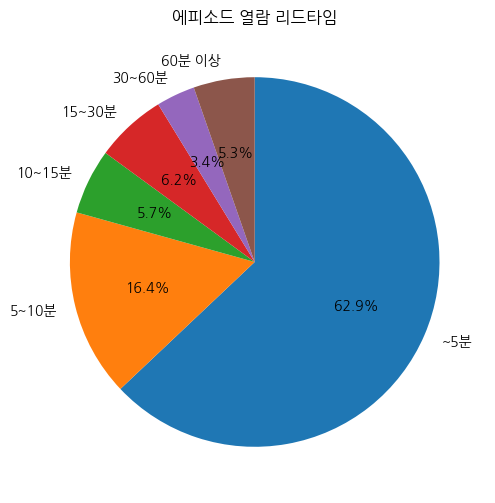

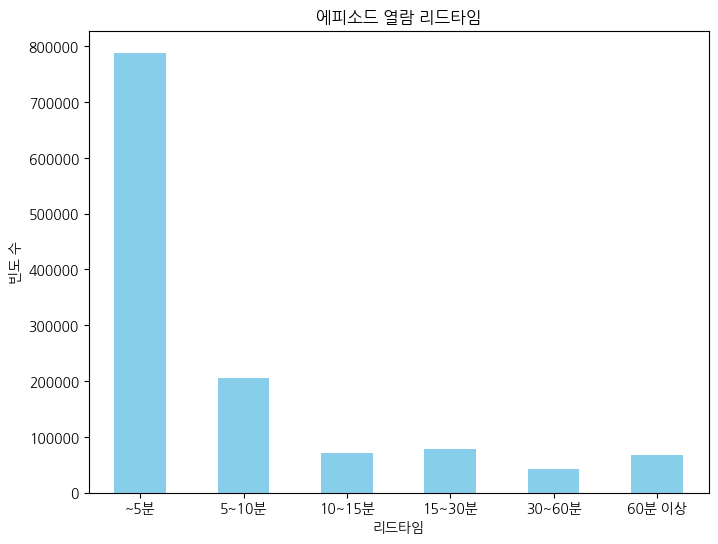

In [ ]:
# event_interval 범위에 따라 새로운 열 생성
bins = [pd.Timedelta(minutes=0), pd.Timedelta(minutes=5), pd.Timedelta(minutes=10), 
        pd.Timedelta(minutes=15), pd.Timedelta(minutes=30), pd.Timedelta(hours=1), pd.Timedelta(days=1)]

labels = ['~5분', '5~10분', '10~15분', '15~30분', '30~60분', '60분 이상']
playtime['interval_category'] = pd.cut(playtime['event_interval'], bins=bins, labels=labels, right=False)

# 각 범위별 이벤트 수 카운트
interval_counts = playtime['interval_category'].value_counts().sort_index()

# 파이 차트 그리기
plt.figure(figsize=(8, 6))
interval_counts.plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False)
plt.ylabel('')  # y축 라벨 제거
plt.title('에피소드 열람 리드타임')
plt.show()

# 막대 차트 그리기
plt.figure(figsize=(8, 6))
interval_counts.plot(kind='bar', color='skyblue')
plt.xlabel('리드타임')
plt.ylabel('빈도 수')
plt.title('에피소드 열람 리드타임')
plt.xticks(rotation=0)
plt.show()

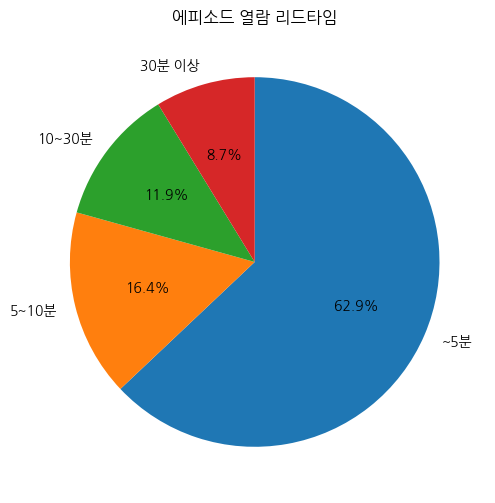

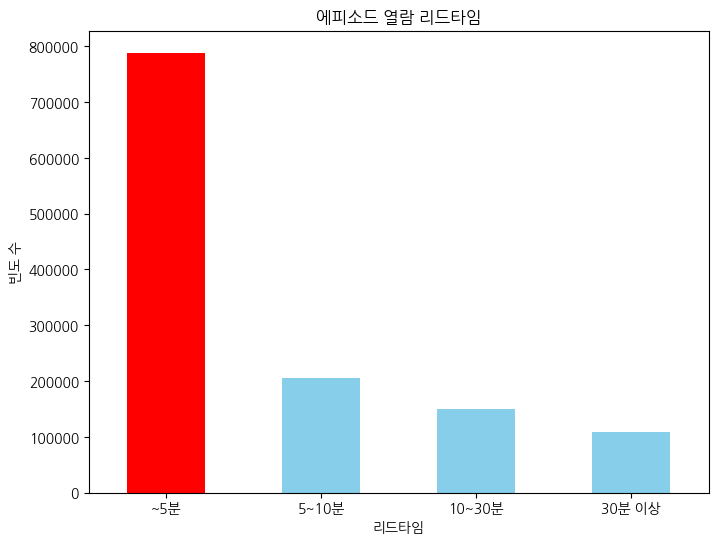

In [ ]:
# event_interval 범위에 따라 새로운 열 생성
bins = [pd.Timedelta(minutes=0), pd.Timedelta(minutes=5), pd.Timedelta(minutes=10), 
        pd.Timedelta(minutes=30), pd.Timedelta(days=1)]

labels = ['~5분', '5~10분', '10~30분', '30분 이상']
playtime['interval_category'] = pd.cut(playtime['event_interval'], bins=bins, labels=labels, right=False)

# 각 범위별 이벤트 수 카운트
interval_counts = playtime['interval_category'].value_counts().sort_index()

# 파이 차트 그리기
plt.figure(figsize=(8, 6))
interval_counts.plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False)
plt.ylabel('')  # y축 라벨 제거
plt.title('에피소드 열람 리드타임')
plt.show()

# 색상을 지정한 리스트 생성: 첫 번째 막대는 다른 색, 나머지는 같은 색
colors = ['red' if label == '~5분' else 'skyblue' for label in interval_counts.index]

# 막대 차트 그리기
plt.figure(figsize=(8, 6))
interval_counts.plot(kind='bar', color=colors)
plt.xlabel('리드타임')
plt.ylabel('빈도 수')
plt.title('에피소드 열람 리드타임')
plt.xticks(rotation=0)
plt.show()

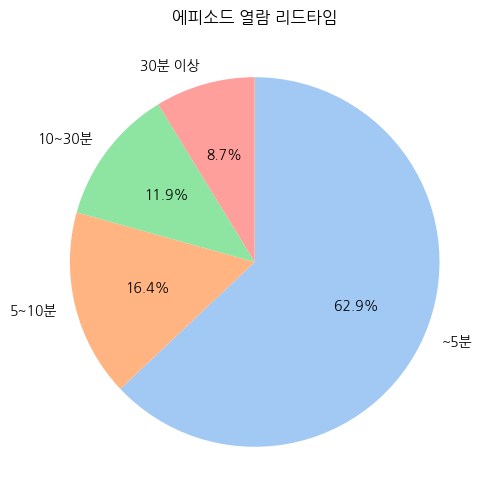

In [ ]:
# event_interval 범위에 따라 새로운 열 생성
bins = [pd.Timedelta(minutes=0), pd.Timedelta(minutes=5), pd.Timedelta(minutes=10), 
        pd.Timedelta(minutes=30), pd.Timedelta(days=1)]

labels = ['~5분', '5~10분', '10~30분', '30분 이상']
playtime['interval_category'] = pd.cut(playtime['event_interval'], bins=bins, labels=labels, right=False)

# Seaborn 색상 팔레트 지정 (여기서는 'pastel' 팔레트 예시)
colors = sns.color_palette('pastel', len(interval_counts))

# 파이 차트 그리기
plt.figure(figsize=(8, 6))
interval_counts.plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False, colors=colors)
plt.ylabel('')  # y축 라벨 제거
plt.title('에피소드 열람 리드타임')
plt.show()

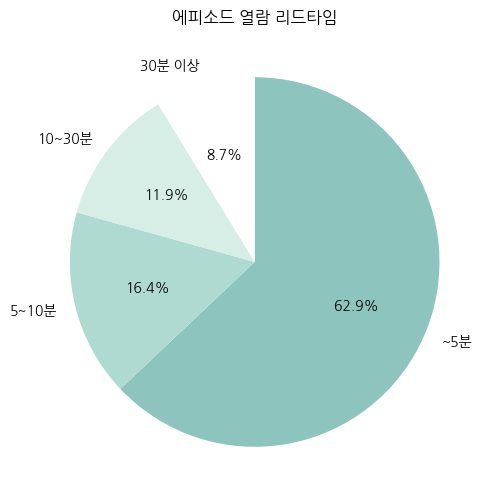

In [ ]:
# Cubehelix 팔레트를 사용하여 비율이 클수록 진한 파란색이 적용되도록 설정
cubehelix_colors = sns.cubehelix_palette(start=2.8, rot=-0.2, dark=1, light=0.7, hue=0.8, gamma=1, n_colors=len(interval_counts))

# 파이 차트 그리기 (Cubehelix 팔레트, 비율에 따라 진한 파란색으로)
plt.figure(figsize=(8, 6))
interval_counts.plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False, colors=cubehelix_colors)
plt.ylabel('')
plt.title('에피소드 열람 리드타임')
plt.show()

### 월별 에피소드 열람 빈도

C:\Users\csh94\AppData\Local\Temp\ipykernel_36472\656514602.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enter_episode['client_event_time'] = pd.to_datetime(enter_episode['client_event_time'])


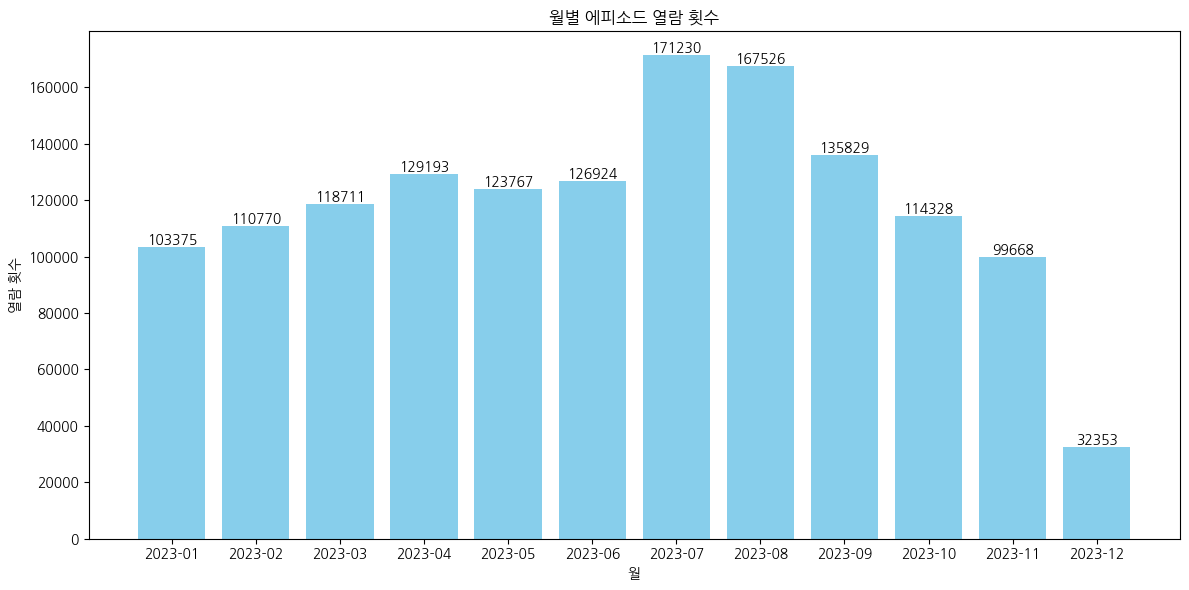

In [ ]:
# 월별 에피소드 열람 횟수

# client_event_time을 datetime 형식으로 변환
enter_episode['client_event_time'] = pd.to_datetime(enter_episode['client_event_time'])
enter_episode = enter_episode[enter_episode['client_event_time'] <= '2023-12-31']

# 월별 데이터 수 집계
enter_episode['month'] = enter_episode['client_event_time'].dt.to_period('M')
monthly_counts = enter_episode['month'].value_counts().sort_index()

# 막대 그래프 그리기
plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_counts.index.astype(str), monthly_counts.values, color='skyblue')

# 그래프에 제목과 라벨 추가
plt.xlabel('월')
plt.ylabel('열람 횟수')
plt.title('월별 에피소드 열람 횟수')

# 막대 위에 데이터 레이블 추가
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha='center', va='bottom', fontsize=10, color='black')

# x축 레이블 회전 및 레이아웃 조정
plt.tight_layout()

# 그래프 출력
plt.show()

### 평일, 주말 시간대별 에피소드 시청 횟수

In [ ]:
# 2023년도에 가입한 고객 기준
f_enter_episode = user_total[user_total['event_type'] == 'enter.episode_page']
f_enter_episode

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date
1258957,2023-03-18 19:34:28.892,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,2ed4b83e65edc2b1efb193aaa3c60cf9,True,NaN,2023-03-18
1258983,2023-03-18 19:37:05.778,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,db421b66bfd27eccd0e862e30b4de1be,True,NaN,2023-03-18
1259038,2023-03-18 19:42:48.654,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,09c8a2d29087cb3d47823acb5f2705e3,True,NaN,2023-03-18
1259071,2023-03-18 19:46:07.383,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,b734f43b5123f8bdbf7d8f865bd3eacf,True,NaN,2023-03-18
1259120,2023-03-18 19:51:40.154,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,6e3afbeb4942c6c29038321e5995f4f1,True,NaN,2023-03-18
...,...,...,...,...,...,...,...,...,...,...,...,...
3900877,2023-11-15 14:03:20.206,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,a6a8c4b3f5b40b8a96c8f6db10e43bf8,False,NaN,2023-11-15
3900910,2023-11-15 14:06:00.833,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,False,NaN,2023-11-15
3982822,2023-11-30 12:25:33.257,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-30
3982827,2023-11-30 12:27:05.918,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN,2023-11-30


In [ ]:
# 시간 추출
f_enter_episode['hour'] = f_enter_episode['client_event_time'].dt.hour

# 요일 추출 (0=월요일, 6=일요일)
f_enter_episode['day_of_week'] = f_enter_episode['client_event_time'].dt.dayofweek

# 평일과 주말 구분 (주말은 토요일(5)과 일요일(6))
f_enter_episode['weekday_or_weekend'] = f_enter_episode['day_of_week'].apply(lambda x: '주말' if x >= 5 else '평일')

C:\Users\mjmj7\AppData\Local\Temp\ipykernel_9772\2673440431.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_enter_episode['hour'] = f_enter_episode['client_event_time'].dt.hour
C:\Users\mjmj7\AppData\Local\Temp\ipykernel_9772\2673440431.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_enter_episode['day_of_week'] = f_enter_episode['client_event_time'].dt.dayofweek
C:\Users\mjmj7\AppData\Local\Temp\ipykernel_9772\2673440431.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a 

In [ ]:
print(f_enter_episode['client_event_time'].min())
print(f_enter_episode['client_event_time'].max())

2023-01-01 00:22:20.400000
2024-01-01 08:58:48.291000


In [ ]:
# 2022년도 12월 1일 ~ 2023년 11월 30일까지 메인페이지 진입 기록
start_date = pd.to_datetime('2022-12-01')
end_date = pd.to_datetime('2023-11-30')

enter_episode_1year = f_enter_episode[f_enter_episode['client_event_time'].between(start_date, end_date)]
enter_episode_1year

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date,hour,day_of_week,weekday_or_weekend
1258957,2023-03-18 19:34:28.892,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,2ed4b83e65edc2b1efb193aaa3c60cf9,True,NaN,2023-03-18,19,5,주말
1258983,2023-03-18 19:37:05.778,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,db421b66bfd27eccd0e862e30b4de1be,True,NaN,2023-03-18,19,5,주말
1259038,2023-03-18 19:42:48.654,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,09c8a2d29087cb3d47823acb5f2705e3,True,NaN,2023-03-18,19,5,주말
1259071,2023-03-18 19:46:07.383,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,b734f43b5123f8bdbf7d8f865bd3eacf,True,NaN,2023-03-18,19,5,주말
1259120,2023-03-18 19:51:40.154,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,6e3afbeb4942c6c29038321e5995f4f1,True,NaN,2023-03-18,19,5,주말
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3544538,2023-10-15 03:42:25.138,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-10-15,3,6,주말
3900648,2023-11-15 13:45:35.421,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-15,13,2,평일
3900877,2023-11-15 14:03:20.206,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,a6a8c4b3f5b40b8a96c8f6db10e43bf8,False,NaN,2023-11-15,14,2,평일
3900910,2023-11-15 14:06:00.833,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,False,NaN,2023-11-15,14,2,평일


In [ ]:
# 평일 데이터 필터링
episode_weekday_df = enter_episode_1year[enter_episode_1year['weekday_or_weekend'] == '평일']

# 주말 데이터 필터링
episode_weekend_df = enter_episode_1year[enter_episode_1year['weekday_or_weekend'] == '주말']

# 평일 시간대별 발생 횟수 집계
weekday_counts = episode_weekday_df.groupby('hour').size().reset_index(name='count')

# 주말 시간대별 발생 횟수 집계
weekend_counts = episode_weekend_df.groupby('hour').size().reset_index(name='count')

# 평일 시간대별 발생 횟수 시각화
fig_weekday = px.bar(weekday_counts, x='hour', y='count', 
                     title='평일 시간대별 에피소드 열람 횟수', labels={'hour': '시간대', 'count': '열람 횟수'})
fig_weekday.update_xaxes(tickvals=list(range(24)))
fig_weekday.show()

# 주말 시간대별 발생 횟수 시각화
fig_weekend = px.bar(weekend_counts, x='hour', y='count', 
                     title='주말 시간대별 에피소드 열람 횟수', labels={'hour': '시간대', 'count': '열람 횟수'})
fig_weekend.update_xaxes(tickvals=list(range(24)))
fig_weekend.show()

In [ ]:
# 2023년도 11월 메인페이지 진입 기록
start_date = pd.to_datetime('2023-11-01')
end_date = pd.to_datetime('2023-11-30')

enter_episode_1month = enter_episode[enter_episode['client_event_time'].between(start_date, end_date)]
enter_episode_1month

,client_event_time,device_family,event_type,user_id,content.id,is_trial,episode.id,is_free_trial
15304996,2023-11-01 00:00:00.419,Windows,enter.episode_page,NaN,b314d5aba64a0aab40602cb72a4a1504,False,1079e6a3293cd7742c4db8419cab8c7f,NaN
17156857,2023-11-01 00:00:00.621,Windows,enter.episode_page,f2663b7aa807031c37eedebb2c4c846a,61b6463287573f00de13a930805a52d6,False,70cb48c6327ced134821d9494f53cc60,NaN
17156154,2023-11-01 00:00:01.696,Linux,enter.episode_page,8844a46c4bc14a2947c97c46982051cb,3ca120746c79812b35a345a8a509b5ba,False,0189307e9b562671d7ca52e3293f0db0,NaN
17156155,2023-11-01 00:00:02.024,Linux,enter.episode_page,8844a46c4bc14a2947c97c46982051cb,3ca120746c79812b35a345a8a509b5ba,False,0189307e9b562671d7ca52e3293f0db0,NaN
17156777,2023-11-01 00:00:02.053,Windows,enter.episode_page,9c2c41363814ca9268f73f9603a9d9f3,db1819d3a7a4c4d85dccb3b9e982fbcd,False,265b4c02b13b0f051ffb34ee73b83cc8,NaN
...,...,...,...,...,...,...,...,...
15784620,2023-11-29 23:58:23.507,Samsung Phone,enter.episode_page,b31b0ffd8aa35cc26300d5b810085ce4,db43a841c994231e2795d4df8931af50,False,5d0b5236e225b4e1723ea07b2b332065,NaN
15784678,2023-11-29 23:59:27.021,Windows,enter.episode_page,NaN,445fac33232adcb3d1cdab7d8a579430,False,a1184e7bef6a94a8ddec70d152217b74,NaN
15784590,2023-11-29 23:59:32.689,Windows,enter.episode_page,NaN,7de35a9d8f14c68e5f2a8788dda5f72e,False,6502cade2086089f04f5990ac835082b,NaN
15784581,2023-11-29 23:59:37.363,Windows,enter.episode_page,c92d479010a428cd77f528fd1bea56e2,6384828b0188f36e5915ed72fdeb7157,False,a6beb68df799c3ff9021936b93b98a3d,NaN


In [ ]:
# 2023년도 10월 에피소드 열람 기록
start_date = pd.to_datetime('2023-10-01')
end_date = pd.to_datetime('2023-10-31')

enter_episode_1month = enter_episode[enter_episode['client_event_time'].between(start_date, end_date)]
enter_episode_1month

,city,client_event_time,country,device_carrier,device_family,device_type,event_type,language,os_name,os_version,...,user_id,content.id,is_trial,episode.id,is_free_trial,month,korea,hour,day_of_week,weekday_or_weekend
14185250,Seoul,2023-10-26 22:28:11.049,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,118.0.0.0,...,d8ab18b0eeb2e31de03511b2d3542ee1,53e2151d8fb35176e29823e1c7d7bc42,False,0f63604cc94d2f64f00b2137b5b875dd,NaN,2023-10,korea,22,3,평일
14185251,Seoul,2023-10-26 22:29:43.361,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,118.0.0.0,...,d8ab18b0eeb2e31de03511b2d3542ee1,53e2151d8fb35176e29823e1c7d7bc42,False,58ed955101f6f03b418b21337c920df1,NaN,2023-10,korea,22,3,평일
14185252,Seoul,2023-10-26 22:31:04.809,South Korea,NaN,Windows,Windows,enter.episode_page,Korean,Chrome,118.0.0.0,...,d8ab18b0eeb2e31de03511b2d3542ee1,53e2151d8fb35176e29823e1c7d7bc42,False,fbc605683a223532b495b9f62204353e,NaN,2023-10,korea,22,3,평일
14185253,Guri-si,2023-10-26 22:57:41.972,South Korea,NaN,Mac,Mac,enter.episode_page,Korean,Chrome,118.0.0.0,...,NaN,db1819d3a7a4c4d85dccb3b9e982fbcd,False,3b115f54c53c175c639815aec6f49484,NaN,2023-10,korea,22,3,평일
14185254,Namdong-gu,2023-10-26 22:03:25.434,South Korea,NaN,Apple iPhone,Apple iPhone,enter.episode_page,Korean,Chrome,118.0.5993.92,...,NaN,45d3eda4b13093cee31036a32bc4a9b5,False,ad2c71b9a0faea88734da4c01a47b763,NaN,2023-10,korea,22,3,평일
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21029702,Seoul,2023-10-10 05:18:14.053,South Korea,NaN,Apple iPad,Apple iPad,enter.episode_page,Korean,Mobile Safari,16.6,...,NaN,c269eb6df3a374b464f7c18f12fa398f,False,582f0dd769db16a3d920fd7916090efb,NaN,2023-10,korea,5,1,평일
21029703,Seoul,2023-10-10 05:18:58.648,South Korea,NaN,Apple iPad,Apple iPad,enter.episode_page,Korean,Mobile Safari,16.6,...,NaN,c269eb6df3a374b464f7c18f12fa398f,False,83c74d5802b04a1a50aa28b7bf8a5354,NaN,2023-10,korea,5,1,평일
21029704,Anyang-si,2023-10-10 05:17:45.578,South Korea,NaN,Samsung Phone,Samsung Galaxy S23 Ultra,enter.episode_page,Korean,Samsung Browser,22.0,...,bc1a28ff902daba9399e7f602cc86285,f4be1a0fe0e301b03115591777fddf29,False,633d1b30ed699e261ea338ad28952338,NaN,2023-10,korea,5,1,평일
21029705,Anyang-si,2023-10-10 05:18:05.629,South Korea,NaN,Samsung Phone,Samsung Galaxy S23 Ultra,enter.episode_page,Korean,Samsung Browser,22.0,...,bc1a28ff902daba9399e7f602cc86285,f4be1a0fe0e301b03115591777fddf29,False,b05e0fb8ab15def4b33878b9a759b4f2,NaN,2023-10,korea,5,1,평일


In [ ]:
# 평일 데이터 필터링
episode_weekday_df = enter_episode_1month[enter_episode_1month['weekday_or_weekend'] == '평일']

# 주말 데이터 필터링
episode_weekend_df = enter_episode_1month[enter_episode_1month['weekday_or_weekend'] == '주말']

# 평일 시간대별 발생 횟수 집계
weekday_counts = episode_weekday_df.groupby('hour').size().reset_index(name='count')

# 주말 시간대별 발생 횟수 집계
weekend_counts = episode_weekend_df.groupby('hour').size().reset_index(name='count')

# 평일 시간대별 발생 횟수 시각화
fig_weekday = px.bar(weekday_counts, x='hour', y='count', 
                     title='평일 시간대별 이벤트 발생 횟수', labels={'hour': '시간대', 'count': '발생 횟수'})
fig_weekday.show()

# 주말 시간대별 발생 횟수 시각화
fig_weekend = px.bar(weekend_counts, x='hour', y='count', 
                     title='주말 시간대별 이벤트 발생 횟수', labels={'hour': '시간대', 'count': '발생 횟수'})
fig_weekend.show()

In [ ]:
enter_episode_2023 = user_total[user_total['event_type'] == 'enter.episode_page']

enter_episode_2023['date'] = enter_episode_2023['client_event_time'].dt.date

# DAU 계산: 날짜별 고유 사용자 수 세기
enter_episode_dau = enter_episode_2023.groupby('date')['user_id'].nunique().reset_index()
enter_episode_dau.columns = ['date', 'DAU']

enter_episode_dau

,date,DAU
0,2023-01-01,212
1,2023-01-02,262
2,2023-01-03,327
3,2023-01-04,320
4,2023-01-05,307
...,...,...
361,2023-12-28,485
362,2023-12-29,345
363,2023-12-30,297
364,2023-12-31,275


In [ ]:
# 2023년 데이터만 필터링
enter_episode_dau['date'] = pd.to_datetime(enter_episode_dau['date'])
enter_episode_dau_1year = enter_episode_dau[(enter_episode_dau['date'] >= '2023-01-01') & (enter_episode_dau['date'] <= '2023-12-31')]

# 시간 형식 변환 및 월만 추출
enter_episode_dau_1year['month'] = enter_episode_dau_1year['date'].dt.to_period('M')
enter_episode_dau_1year['month'] = enter_episode_dau_1year['month'].astype(str)


# DAU 시각화
fig = px.line(enter_episode_dau_1year, x='date', y='DAU', title='에피소드 열람 DAU',
              labels={'date': '월', 'DAU': 'DAU'},
              markers=True)

# x축 레이블을 지정된 연-월만 표시하도록 설정
fig.update_layout(xaxis_title="월", xaxis=dict(tickmode='array', tickvals=enter_episode_dau_1year['month'], ticktext=enter_episode_dau_1year['month']))

fig.show()

In [ ]:
# 주중/주말 구분 열 추가 (주말: 토, 일)
enter_episode_dau_1year['day_type'] = enter_episode_dau_1year['date'].dt.dayofweek.apply(lambda x: '주말' if x >= 5 else '주중')

# DAU 시각화: 주말을 빨간색 마커로
fig = px.line(
    enter_episode_dau_1year,
    x='date',
    y='DAU',
    title='에피소드 열람 DAU',
    labels={'date': '월', 'DAU': 'DAU'},
)

# 마커 스타일 적용
fig.update_traces(
    mode='lines+markers',
    marker=dict(
        size=8, 
        color=enter_episode_dau_1year['day_type'].apply(lambda x: 'red' if x == '주말' else 'blue')
    )
)

# x축 레이블 설정 (연-월 표시)
fig.update_layout(
    xaxis_title="월",
    xaxis=dict(
        tickmode='array',
        tickvals=enter_episode_dau_1year['month'],
        ticktext=enter_episode_dau_1year['month']
    )
)

fig.show()

In [ ]:
# 시간 형식 변환 및 월만 추출
enter_episode_2023['month'] = enter_episode_2023['client_event_time'].dt.to_period('M')

# MAU 계산: 월별 고유 사용자 수 세기
enter_episode_mau = enter_episode_2023.groupby('month')['user_id'].nunique().reset_index()
enter_episode_mau.columns = ['month', 'MAU']

enter_episode_mau

,month,MAU
0,2023-01,7194
1,2023-02,3215
2,2023-03,2783
3,2023-04,3216
4,2023-05,4897
5,2023-06,6726
6,2023-07,8670
7,2023-08,7980
8,2023-09,6151
9,2023-10,5979


In [ ]:
# 2023년 데이터만 필터링
mau_data_1year = enter_episode_mau[(enter_episode_mau['month'] >= '2023-01') & (enter_episode_mau['month'] <= '2023-12')]
mau_data_1year['month'] = mau_data_1year['month'].astype(str)

# mau 시각화
fig = px.line(mau_data_1year, x='month', y='MAU', title='에피소드 열람 MAU',
              labels={'month': '월', 'MAU': 'MAU'},
              markers=True)

# x축 레이블을 지정된 연-월만 표시하도록 설정
fig.update_layout(xaxis_title="월", xaxis=dict(tickmode='array', tickvals=mau_data_1year['month'], ticktext=mau_data_1year['month']))

fig.show()

In [ ]:
# 날짜 형식 변환 및 월 컬럼 생성
enter_episode_dau['month'] = enter_episode_dau['date'].dt.to_period('M')

# month 열을 문자열 형식으로 변환
enter_episode_dau['month'] = enter_episode_dau['month'].astype(str)
enter_episode_mau['month'] = enter_episode_mau['month'].astype(str)

# 1일의 DAU 데이터만 필터링
first_day_dau = enter_episode_dau[enter_episode_dau['date'].dt.day == 1]

# 월별 DAU와 MAU 병합
merged_data = first_day_dau.merge(enter_episode_mau, on='month', suffixes=('_dau', '_mau'))

# 고착도 계산
merged_data['stickiness'] = (merged_data['DAU'] / merged_data['MAU']) * 100

# 결과 DataFrame 생성
enter_episode_stickiness = merged_data[['month', 'DAU', 'MAU', 'stickiness']]
enter_episode_stickiness


,month,DAU,MAU,stickiness
0,2023-01,212,7194,2.946900
1,2023-02,508,3215,15.800933
2,2023-03,362,2783,13.007546
3,2023-04,253,3216,7.866915
4,2023-05,438,4897,8.944252
5,2023-06,424,6726,6.303895
6,2023-07,669,8670,7.716263
7,2023-08,775,7980,9.711779
8,2023-09,525,6151,8.535198
9,2023-10,403,5979,6.740258


In [ ]:
# 2023년 데이터만 필터링
enter_episode_stickiness_1year = enter_episode_stickiness[(enter_episode_stickiness['month'] >= '2023-01') & (enter_episode_stickiness['month'] <= '2023-12')]
enter_episode_stickiness_1year['month'] = enter_episode_stickiness_1year['month'].astype(str)

# 고착도 시각화
fig = px.line(enter_episode_stickiness_1year, x='month', y='stickiness', title='에피소드 열람 고착도(월초 DAU 기준)',
            markers=True)
fig.show()

In [ ]:
# 월별 DAU 평균 계산
monthly_dau = enter_episode_dau.groupby('month')['DAU'].mean().reset_index()

# 고착도 계산
results = []
for index, row in monthly_dau.iterrows():
    month = row['month']
    dau_avg = row['DAU']
    
    # 해당 월의 MAU 찾기
    mau_value = enter_episode_mau[enter_episode_mau['month'] == str(month)]['MAU'].values[0]
    
    # 고착도 계산
    stickiness = (dau_avg / mau_value) * 100
    results.append({'month': str(month), 'DAU_Avg': dau_avg, 'MAU': mau_value, 'stickiness': stickiness})

# 결과 데이터프레임 생성
enter_episode_stickiness = pd.DataFrame(results)
enter_episode_stickiness

,month,DAU_Avg,MAU,stickiness
0,2023-01,432.935484,7194,6.018008
1,2023-02,392.642857,3215,12.212842
2,2023-03,357.161290,2783,12.833679
3,2023-04,392.033333,3216,12.190091
4,2023-05,420.419355,4897,8.585243
5,2023-06,520.866667,6726,7.744078
6,2023-07,670.387097,8670,7.732262
7,2023-08,651.580645,7980,8.165171
8,2023-09,541.900000,6151,8.809950
9,2023-10,442.064516,5979,7.393620


In [ ]:
# 2023년 데이터만 필터링
enter_episode_stickiness_1year = enter_episode_stickiness[(enter_episode_stickiness['month'] >= '2023-01') & (enter_episode_stickiness['month'] <= '2023-12')]
enter_episode_stickiness_1year['month'] = enter_episode_stickiness_1year['month'].astype(str)

# 고착도 시각화
fig = px.line(enter_episode_stickiness_1year, x='month', y='stickiness', title='에피소드 열람 고착도(월평균 DAU 기준)',
              labels={'month': '월', 'stickiness': '고착도'},
              markers=True)

# x축 레이블을 지정된 연-월만 표시하도록 설정
fig.update_layout(xaxis_title="월", xaxis=dict(tickmode='array', tickvals=enter_episode_stickiness_1year['month'], ticktext=enter_episode_stickiness_1year['month']))

fig.show()

## Activation: 결제 페이지

In [ ]:
enter_payment_2023 = user_total[user_total['event_type'] == 'enter.payment_page']

enter_payment_2023['date'] = enter_payment_2023['client_event_time'].dt.date

# DAU 계산: 날짜별 고유 사용자 수 세기
enter_payment_dau = enter_payment_2023.groupby('date')['user_id'].nunique().reset_index()
enter_payment_dau.columns = ['date', 'DAU']

enter_payment_dau

,date,DAU
0,2023-01-01,147
1,2023-01-02,198
2,2023-01-03,186
3,2023-01-04,171
4,2023-01-05,150
...,...,...
339,2023-12-06,183
340,2023-12-07,191
341,2023-12-08,173
342,2023-12-09,158


In [ ]:
# 2023년 데이터만 필터링
enter_payment_dau['date'] = pd.to_datetime(enter_payment_dau['date'])
enter_payment_dau_1year = enter_payment_dau[(enter_payment_dau['date'] >= '2023-01-01') & (enter_payment_dau['date'] <= '2023-12-31')]


# DAU 시각화
fig = px.line(enter_payment_dau_1year, x='date', y='DAU', title='Daily Active Users (DAU) for 2023',
              labels={'date': 'Date', 'DAU': 'Daily Active Users'},
              markers=True)

fig.show()

In [ ]:
# 시간 형식 변환 및 월만 추출
enter_payment_2023['month'] = enter_payment_2023['client_event_time'].dt.to_period('M')

# MAU 계산: 월별 고유 사용자 수 세기
enter_payment_mau = enter_payment_2023.groupby('month')['user_id'].nunique().reset_index()
enter_payment_mau.columns = ['month', 'MAU']

enter_payment_mau

,month,MAU
0,2023-01,5502
1,2023-02,5164
2,2023-03,6148
3,2023-04,4158
4,2023-05,3007
5,2023-06,3411
6,2023-07,3878
7,2023-08,3990
8,2023-09,4965
9,2023-10,4459


In [ ]:
# 2023년 데이터만 필터링
enter_payment_mau_1year = enter_payment_mau[(enter_payment_mau['month'] >= '2023-01') & (enter_payment_mau['month'] <= '2023-12')]
enter_payment_mau_1year['month'] = enter_payment_mau_1year['month'].astype(str)

# mau 시각화
fig = px.line(enter_payment_mau_1year, x='month', y='MAU', title='Daily Active Users (MAU) for 2023',
              labels={'month': 'Date', 'MAU': 'Month Active Users'},
              markers=True)

fig.show()

In [ ]:
# 날짜 형식 변환 및 월 컬럼 생성
enter_payment_dau['month'] = enter_payment_dau['date'].dt.to_period('M')

# month 열을 문자열 형식으로 변환
enter_payment_dau['month'] = enter_payment_dau['month'].astype(str)
enter_payment_mau['month'] = enter_payment_mau['month'].astype(str)

# 1일의 DAU 데이터만 필터링
first_day_dau = enter_payment_dau[enter_payment_dau['date'].dt.day == 1]

# 월별 DAU와 MAU 병합
merged_data = first_day_dau.merge(enter_payment_mau, on='month', suffixes=('_dau', '_mau'))

# 고착도 계산
merged_data['stickiness'] = (merged_data['DAU'] / merged_data['MAU']) * 100

# 결과 DataFrame 생성
enter_payment_stickiness = merged_data[['month', 'DAU', 'MAU', 'stickiness']]
enter_payment_stickiness


,month,DAU,MAU,stickiness
0,2023-01,147,5502,2.671756
1,2023-02,213,5164,4.124710
2,2023-03,264,6148,4.294079
3,2023-04,154,4158,3.703704
4,2023-05,130,3007,4.323246
5,2023-06,144,3411,4.221636
6,2023-07,161,3878,4.151625
7,2023-08,161,3990,4.035088
8,2023-09,197,4965,3.967774
9,2023-10,132,4459,2.960305


In [ ]:
# 2023년 데이터만 필터링
enter_payment_stickiness_1year = enter_payment_stickiness[(enter_payment_stickiness['month'] >= '2023-01') & (enter_payment_stickiness['month'] <= '2023-12')]
enter_payment_stickiness_1year['month'] = enter_payment_stickiness_1year['month'].astype(str)

# 고착도 시각화
fig = px.line(enter_payment_stickiness_1year, x='month', y='stickiness', title='enter_payment_stickiness_2023(day 1)',
            markers=True)
fig.show()

In [ ]:
# 월별 DAU 평균 계산
monthly_dau = enter_payment_dau.groupby('month')['DAU'].mean().reset_index()

# 고착도 계산
results = []
for index, row in monthly_dau.iterrows():
    month = row['month']
    dau_avg = row['DAU']
    
    # 해당 월의 MAU 찾기
    mau_value = enter_payment_mau[enter_payment_mau['month'] == str(month)]['MAU'].values[0]
    
    # 고착도 계산
    stickiness = (dau_avg / mau_value) * 100
    results.append({'month': str(month), 'DAU_Avg': dau_avg, 'MAU': mau_value, 'stickiness': stickiness})

# 결과 데이터프레임 생성
enter_payment_stickiness = pd.DataFrame(results)
enter_payment_stickiness

,month,DAU_Avg,MAU,stickiness
0,2023-01,211.387097,5502,3.842005
1,2023-02,206.500000,5164,3.998838
2,2023-03,222.000000,6148,3.610930
3,2023-04,156.333333,4158,3.759820
4,2023-05,114.806452,3007,3.817973
5,2023-06,137.866667,3411,4.041825
6,2023-07,144.161290,3878,3.717413
7,2023-08,146.000000,3990,3.659148
8,2023-09,187.133333,4965,3.769050
9,2023-10,162.580645,4459,3.646123


In [ ]:
# 2023년 데이터만 필터링
enter_payment_stickiness_1year = enter_payment_stickiness[(enter_payment_stickiness['month'] >= '2023-01') & (enter_payment_stickiness['month'] <= '2023-12')]
enter_payment_stickiness_1year['month'] = enter_payment_stickiness_1year['month'].astype(str)

# 고착도 시각화
fig = px.line(enter_payment_stickiness_1year, x='month', y='stickiness', title='enter_payment_stickiness_2023(avg)',
            markers=True)
fig.show()

## Activation: 콘텐츠 개별 페이지

In [ ]:
# 2023년도에 회원가입한 유저만
enter_content_2023 = enter_content[enter_content['user_id'].isin(users)]

enter_content_2023['date'] = enter_content_2023['client_event_time'].dt.date

# DAU 계산: 날짜별 고유 사용자 수 세기
enter_content_dau = enter_content_2023.groupby('date')['user_id'].nunique().reset_index()
enter_content_dau.columns = ['date', 'DAU']

enter_content_dau

,date,DAU
0,2023-01-01,91
1,2023-01-02,122
2,2023-01-03,143
3,2023-01-04,134
4,2023-01-05,162
...,...,...
361,2023-12-28,247
362,2023-12-29,173
363,2023-12-30,154
364,2023-12-31,148


In [ ]:
# 2023년 데이터만 필터링
enter_content_dau['date'] = pd.to_datetime(enter_content_dau['date'])
enter_content_dau_1year = enter_content_dau[(enter_content_dau['date'] >= '2023-01-01') & (enter_content_dau['date'] <= '2023-12-31')]


# DAU 시각화
fig = px.line(enter_content_dau_1year, x='date', y='DAU', title='Daily Active Users (DAU) for 2023',
              labels={'date': 'Date', 'DAU': 'Daily Active Users'},
              markers=True)

fig.show()

In [ ]:
# 시간 형식 변환 및 월만 추출
enter_content_2023['month'] = enter_content_2023['client_event_time'].dt.to_period('M')

# MAU 계산: 월별 고유 사용자 수 세기
enter_content_mau = enter_content_2023.groupby('month')['user_id'].nunique().reset_index()
enter_content_mau.columns = ['month', 'MAU']

enter_content_mau

,month,MAU
0,2023-01,3441
1,2023-02,2408
2,2023-03,2873
3,2023-04,2983
4,2023-05,4348
5,2023-06,3503
6,2023-07,3815
7,2023-08,3900
8,2023-09,3787
9,2023-10,3257


In [ ]:
# 2023년 데이터만 필터링
mau_data_1year = enter_content_mau[(enter_content_mau['month'] >= '2023-01') & (enter_content_mau['month'] <= '2023-12')]
mau_data_1year['month'] = mau_data_1year['month'].astype(str)

# mau 시각화
fig = px.line(mau_data_1year, x='month', y='MAU', title='Daily Active Users (MAU) for 2023',
              labels={'month': 'Date', 'MAU': 'Month Active Users'},
              markers=True)

fig.show()

In [ ]:
# 날짜 형식 변환 및 월 컬럼 생성
enter_content_dau['month'] = enter_content_dau['date'].dt.to_period('M')

# month 열을 문자열 형식으로 변환
enter_content_dau['month'] = enter_content_dau['month'].astype(str)
enter_content_mau['month'] = enter_content_mau['month'].astype(str)

# 1일의 DAU 데이터만 필터링
first_day_dau = enter_content_dau[enter_content_dau['date'].dt.day == 1]

# 월별 DAU와 MAU 병합
merged_data = first_day_dau.merge(enter_content_mau, on='month', suffixes=('_dau', '_mau'))

# 고착도 계산
merged_data['stickiness'] = (merged_data['DAU'] / merged_data['MAU']) * 100

# 결과 DataFrame 생성
enter_content_stickiness = merged_data[['month', 'DAU', 'MAU', 'stickiness']]
enter_content_stickiness


,month,DAU,MAU,stickiness
0,2023-01,91,3441,2.644580
1,2023-02,274,2408,11.378738
2,2023-03,236,2873,8.214410
3,2023-04,174,2983,5.833054
4,2023-05,294,4348,6.761730
5,2023-06,319,3503,9.106480
6,2023-07,255,3815,6.684142
7,2023-08,340,3900,8.717949
8,2023-09,284,3787,7.499340
9,2023-10,166,3257,5.096715


In [ ]:
# 2023년 데이터만 필터링
enter_content_stickiness_1year = enter_content_stickiness[(enter_content_stickiness['month'] >= '2023-01') & (enter_content_stickiness['month'] <= '2023-12')]
enter_content_stickiness_1year['month'] = enter_content_stickiness_1year['month'].astype(str)

# 고착도 시각화
fig = px.line(enter_content_stickiness_1year, x='month', y='stickiness', title='enter_content_stickiness_2023(day 1)',
            markers=True)
fig.show()

In [ ]:
# 월별 DAU 평균 계산
monthly_dau = enter_content_dau.groupby('month')['DAU'].mean().reset_index()

# 고착도 계산
results = []
for index, row in monthly_dau.iterrows():
    month = row['month']
    dau_avg = row['DAU']
    
    # 해당 월의 MAU 찾기
    mau_value = enter_content_mau[enter_content_mau['month'] == str(month)]['MAU'].values[0]
    
    # 고착도 계산
    stickiness = (dau_avg / mau_value) * 100
    results.append({'month': str(month), 'DAU_Avg': dau_avg, 'MAU': mau_value, 'stickiness': stickiness})

# 결과 데이터프레임 생성
enter_content_stickiness = pd.DataFrame(results)
enter_content_stickiness

,month,DAU_Avg,MAU,stickiness
0,2023-01,203.161290,3441,5.904135
1,2023-02,207.428571,2408,8.614143
2,2023-03,227.451613,2873,7.916868
3,2023-04,226.233333,2983,7.584088
4,2023-05,270.741935,4348,6.226815
5,2023-06,239.200000,3503,6.828433
6,2023-07,269.548387,3815,7.065489
7,2023-08,270.612903,3900,6.938792
8,2023-09,258.933333,3787,6.837426
9,2023-10,205.096774,3257,6.297107


In [ ]:
# 2023년 데이터만 필터링
enter_content_stickiness_1year = enter_content_stickiness[(enter_content_stickiness['month'] >= '2023-01') & (enter_content_stickiness['month'] <= '2023-12')]
enter_content_stickiness_1year['month'] = enter_content_stickiness_1year['month'].astype(str)

# 고착도 시각화
fig = px.line(enter_content_stickiness_1year, x='month', y='stickiness', title='enter_content_stickiness_2023(avg)',
            markers=True)
fig.show()

In [ ]:
# enter.episode_page인 행만 필터링
fillter_enter_episode = user_total[user_total['event_type'] == 'enter.episode_page']

# 결과 확인
fillter_enter_episode

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date
1258957,2023-03-18 19:34:28.892,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,2ed4b83e65edc2b1efb193aaa3c60cf9,True,NaN,2023-03-18
1258983,2023-03-18 19:37:05.778,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,db421b66bfd27eccd0e862e30b4de1be,True,NaN,2023-03-18
1259038,2023-03-18 19:42:48.654,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,09c8a2d29087cb3d47823acb5f2705e3,True,NaN,2023-03-18
1259071,2023-03-18 19:46:07.383,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,b734f43b5123f8bdbf7d8f865bd3eacf,True,NaN,2023-03-18
1259120,2023-03-18 19:51:40.154,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,6e3afbeb4942c6c29038321e5995f4f1,True,NaN,2023-03-18
...,...,...,...,...,...,...,...,...,...,...,...,...
3900877,2023-11-15 14:03:20.206,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,a6a8c4b3f5b40b8a96c8f6db10e43bf8,False,NaN,2023-11-15
3900910,2023-11-15 14:06:00.833,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,False,NaN,2023-11-15
3982822,2023-11-30 12:25:33.257,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-30
3982827,2023-11-30 12:27:05.918,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN,2023-11-30


In [ ]:
start_date = pd.to_datetime('2023-01-01')
end_date = pd.to_datetime('2023-12-31')

fillter_enter_episode = fillter_enter_episode[fillter_enter_episode['client_event_time'].between(start_date, end_date)]

In [ ]:
fillter_enter_episode = fillter_enter_episode.dropna(subset=['user_id'])

In [ ]:
# user_id로 그룹화하고 client_event_time 기준으로 가장 빠른 날짜의 데이터만 남김
first_enter_episode = fillter_enter_episode.sort_values('client_event_time').drop_duplicates('user_id', keep='first')

In [ ]:
first_enter_episode['is_free_trial'].fillna(False, inplace=True)

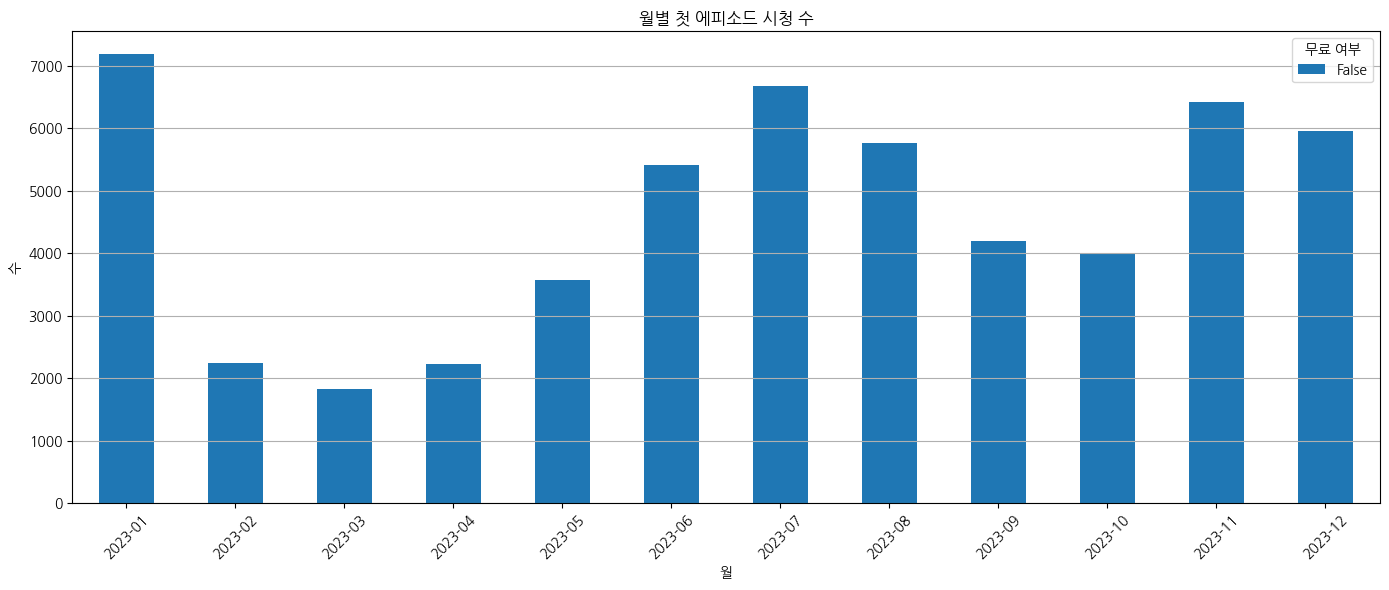

In [ ]:
first_enter_episode['month'] = first_enter_episode['client_event_time'].dt.to_period('M')

monthly_counts = first_enter_episode['month'].value_counts().sort_index().reset_index()

monthly_counts = first_enter_episode.groupby([first_enter_episode['month'], 'is_free_trial']).size().unstack(fill_value=0)

# 그래프 시각화 (figsize를 plot() 내에서 직접 지정)
ax = monthly_counts.plot(kind='bar', stacked=True, figsize=(14, 6))
ax.set_title('월별 첫 에피소드 시청 수')
ax.set_xlabel('월')
ax.set_ylabel('수')
plt.xticks(rotation=45)
plt.legend(title='무료 여부')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
first_enter_episode['is_trial'].fillna(False, inplace=True)

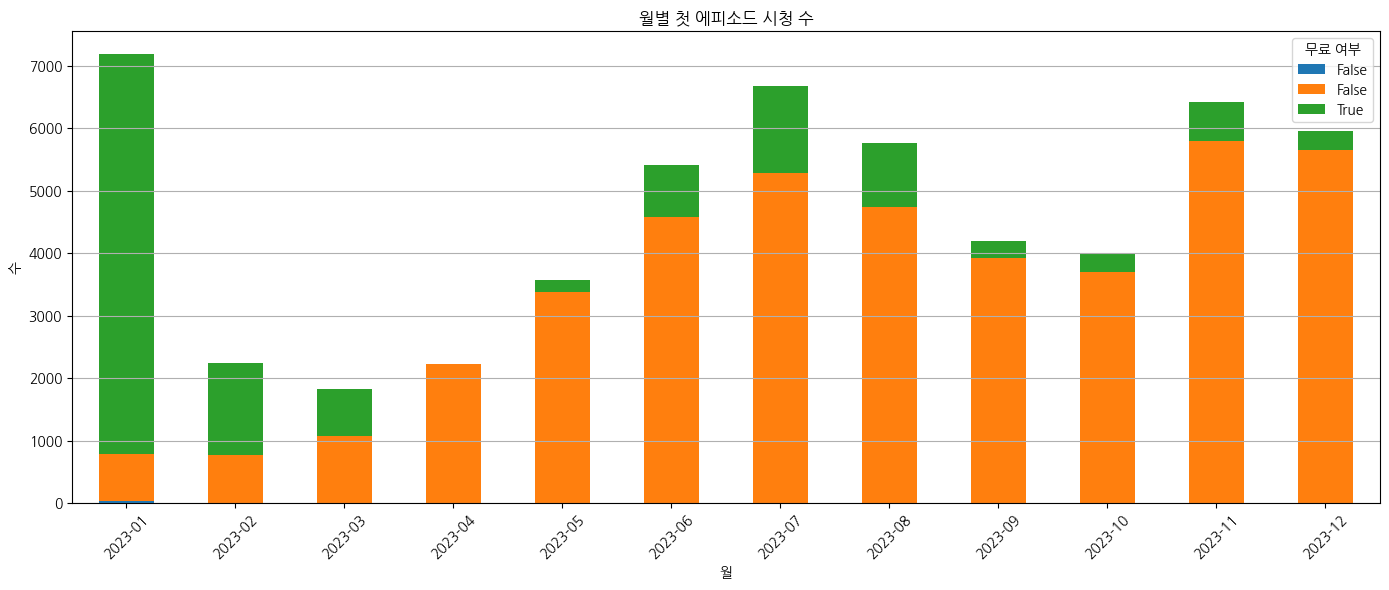

In [ ]:
first_enter_episode['month'] = first_enter_episode['client_event_time'].dt.to_period('M')

monthly_counts = first_enter_episode['month'].value_counts().sort_index().reset_index()

monthly_counts = first_enter_episode.groupby([first_enter_episode['month'], 'is_trial']).size().unstack(fill_value=0)

# 그래프 시각화 (figsize를 plot() 내에서 직접 지정)
ax = monthly_counts.plot(kind='bar', stacked=True, figsize=(14, 6))
ax.set_title('월별 첫 에피소드 시청 수')
ax.set_xlabel('월')
ax.set_ylabel('수')
plt.xticks(rotation=45)
plt.legend(title='무료 여부')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# 기준일 범위 설정 (시작일과 종료일)
reference_start_date = pd.to_datetime('2023-10-01')
reference_end_date = pd.to_datetime('2023-10-31')

# 결과를 저장할 리스트
results = []

# 전체 사용자
total_users = fillter_enter_episode['user_id'].unique()  # 전체 사용자
total_users_count = len(total_users)  # 전체 사용자 수

# 기준일 범위 내의 날짜들에 대해 리텐션 조사
for single_date in pd.date_range(reference_start_date, reference_end_date):
    retained_users = set()  # 재방문한 사용자 집합

    # 7일 간격으로 체크
    for week in range(1, 5):  # 1주, 2주, 3주, 4주
        check_start_date = single_date + timedelta(weeks=week - 1)
        check_end_date = single_date + timedelta(weeks=week)

        # 기간 내에 재방문한 사용자 수
        users_in_period = fillter_enter_episode[
            (fillter_enter_episode['client_event_time'] >= check_start_date) & 
            (fillter_enter_episode['client_event_time'] < check_end_date)
        ]['user_id'].unique()
        
        # 재방문한 사용자 집합에 추가
        retained_users.update(users_in_period)

    # Bracket 리텐션율 계산
    bracket_retention_rate = (len(retained_users) / total_users_count) * 100 if total_users_count > 0 else 0

    # 결과 저장
    results.append({
        'reference_date': single_date.date(),
        'bracket_retention_rate': bracket_retention_rate
    })

# 결과 출력
for result in results:
    print(f"Bracket retention rate from {result['reference_date']} over 4 weeks: {result['bracket_retention_rate']:.2f}%")

Bracket retention rate from 2023-10-01 over 4 weeks: 9.55%
Bracket retention rate from 2023-10-02 over 4 weeks: 9.68%
Bracket retention rate from 2023-10-03 over 4 weeks: 9.90%
Bracket retention rate from 2023-10-04 over 4 weeks: 10.05%
Bracket retention rate from 2023-10-05 over 4 weeks: 10.21%
Bracket retention rate from 2023-10-06 over 4 weeks: 10.40%
Bracket retention rate from 2023-10-07 over 4 weeks: 10.47%
Bracket retention rate from 2023-10-08 over 4 weeks: 10.59%
Bracket retention rate from 2023-10-09 over 4 weeks: 10.72%
Bracket retention rate from 2023-10-10 over 4 weeks: 10.91%
Bracket retention rate from 2023-10-11 over 4 weeks: 10.97%
Bracket retention rate from 2023-10-12 over 4 weeks: 11.08%
Bracket retention rate from 2023-10-13 over 4 weeks: 11.17%
Bracket retention rate from 2023-10-14 over 4 weeks: 11.24%
Bracket retention rate from 2023-10-15 over 4 weeks: 11.35%
Bracket retention rate from 2023-10-16 over 4 weeks: 11.42%
Bracket retention rate from 2023-10-17 over

In [ ]:
# 기준일 범위 설정 (시작일과 종료일)
reference_start_date = pd.to_datetime('2023-09-01')
reference_end_date = pd.to_datetime('2023-09-30')

# 결과를 저장할 리스트
results = []

# 전체 사용자
total_users = fillter_enter_episode['user_id'].unique()  # 전체 사용자
total_users_count = len(total_users)  # 전체 사용자 수

# 기준일 범위 내의 날짜들에 대해 리텐션 조사
for single_date in pd.date_range(reference_start_date, reference_end_date):
    retained_users = set()  # 재방문한 사용자 집합

    # 7일 간격으로 체크
    for week in range(1, 5):  # 1주, 2주, 3주, 4주
        check_start_date = single_date + timedelta(weeks=week - 1)
        check_end_date = single_date + timedelta(weeks=week)

        # 기간 내에 재방문한 사용자 수
        users_in_period = fillter_enter_episode[
            (fillter_enter_episode['client_event_time'] >= check_start_date) & 
            (fillter_enter_episode['client_event_time'] < check_end_date)
        ]['user_id'].unique()
        
        # 재방문한 사용자 집합에 추가
        retained_users.update(users_in_period)

    # Bracket 리텐션율 계산
    bracket_retention_rate = (len(retained_users) / total_users_count) * 100 if total_users_count > 0 else 0

    # 결과 저장
    results.append({
        'reference_date': single_date.date(),
        'bracket_retention_rate': bracket_retention_rate
    })

# 결과 출력
for result in results:
    print(f"Bracket retention rate from {result['reference_date']} over 4 weeks: {result['bracket_retention_rate']:.2f}%")

Bracket retention rate from 2023-09-01 over 4 weeks: 10.71%
Bracket retention rate from 2023-09-02 over 4 weeks: 10.53%
Bracket retention rate from 2023-09-03 over 4 weeks: 10.48%
Bracket retention rate from 2023-09-04 over 4 weeks: 10.40%
Bracket retention rate from 2023-09-05 over 4 weeks: 10.23%
Bracket retention rate from 2023-09-06 over 4 weeks: 10.09%
Bracket retention rate from 2023-09-07 over 4 weeks: 10.05%
Bracket retention rate from 2023-09-08 over 4 weeks: 10.00%
Bracket retention rate from 2023-09-09 over 4 weeks: 9.88%
Bracket retention rate from 2023-09-10 over 4 weeks: 9.86%
Bracket retention rate from 2023-09-11 over 4 weeks: 9.83%
Bracket retention rate from 2023-09-12 over 4 weeks: 9.74%
Bracket retention rate from 2023-09-13 over 4 weeks: 9.66%
Bracket retention rate from 2023-09-14 over 4 weeks: 9.56%
Bracket retention rate from 2023-09-15 over 4 weeks: 9.55%
Bracket retention rate from 2023-09-16 over 4 weeks: 9.55%
Bracket retention rate from 2023-09-17 over 4 we

In [ ]:
# 기준일 범위 설정 (시작일과 종료일)
reference_start_date = pd.to_datetime('2023-08-01')
reference_end_date = pd.to_datetime('2023-08-31')

# 결과를 저장할 리스트
results = []

# 전체 사용자
total_users = fillter_enter_episode['user_id'].unique()  # 전체 사용자
total_users_count = len(total_users)  # 전체 사용자 수

# 기준일 범위 내의 날짜들에 대해 리텐션 조사
for single_date in pd.date_range(reference_start_date, reference_end_date):
    retained_users = set()  # 재방문한 사용자 집합

    # 7일 간격으로 체크
    for week in range(1, 5):  # 1주, 2주, 3주, 4주
        check_start_date = single_date + timedelta(weeks=week - 1)
        check_end_date = single_date + timedelta(weeks=week)

        # 기간 내에 재방문한 사용자 수
        users_in_period = fillter_enter_episode[
            (fillter_enter_episode['client_event_time'] >= check_start_date) & 
            (fillter_enter_episode['client_event_time'] < check_end_date)
        ]['user_id'].unique()
        
        # 재방문한 사용자 집합에 추가
        retained_users.update(users_in_period)

    # Bracket 리텐션율 계산
    bracket_retention_rate = (len(retained_users) / total_users_count) * 100 if total_users_count > 0 else 0

    # 결과 저장
    results.append({
        'reference_date': single_date.date(),
        'bracket_retention_rate': bracket_retention_rate
    })

# 결과 출력
for result in results:
    print(f"Bracket retention rate from {result['reference_date']} over 4 weeks: {result['bracket_retention_rate']:.2f}%")

Bracket retention rate from 2023-08-01 over 4 weeks: 13.49%
Bracket retention rate from 2023-08-02 over 4 weeks: 13.35%
Bracket retention rate from 2023-08-03 over 4 weeks: 13.13%
Bracket retention rate from 2023-08-04 over 4 weeks: 12.97%
Bracket retention rate from 2023-08-05 over 4 weeks: 12.91%
Bracket retention rate from 2023-08-06 over 4 weeks: 12.68%
Bracket retention rate from 2023-08-07 over 4 weeks: 12.56%
Bracket retention rate from 2023-08-08 over 4 weeks: 12.52%
Bracket retention rate from 2023-08-09 over 4 weeks: 12.51%
Bracket retention rate from 2023-08-10 over 4 weeks: 12.44%
Bracket retention rate from 2023-08-11 over 4 weeks: 12.38%
Bracket retention rate from 2023-08-12 over 4 weeks: 12.34%
Bracket retention rate from 2023-08-13 over 4 weeks: 12.30%
Bracket retention rate from 2023-08-14 over 4 weeks: 12.27%
Bracket retention rate from 2023-08-15 over 4 weeks: 12.30%
Bracket retention rate from 2023-08-16 over 4 weeks: 12.30%
Bracket retention rate from 2023-08-17 o

## Retention: 월별 재구독 코호트 분석

C:\Users\mjmj7\AppData\Local\Temp\ipykernel_30620\4199660627.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_plan_data['가입년월'] = monthly_plan_data['결제날짜'].dt.to_period('M')
C:\Users\mjmj7\AppData\Local\Temp\ipykernel_30620\4199660627.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_plan_data['코호트'] = monthly_plan_data.groupby('user_id')['결제날짜'].transform('min').dt.to_period('M')
C:\Users\mjmj7\AppData\Local\Temp\ipykernel_30620\4199660627.py:7: SettingWithCopyWarning: 
A value is tryi

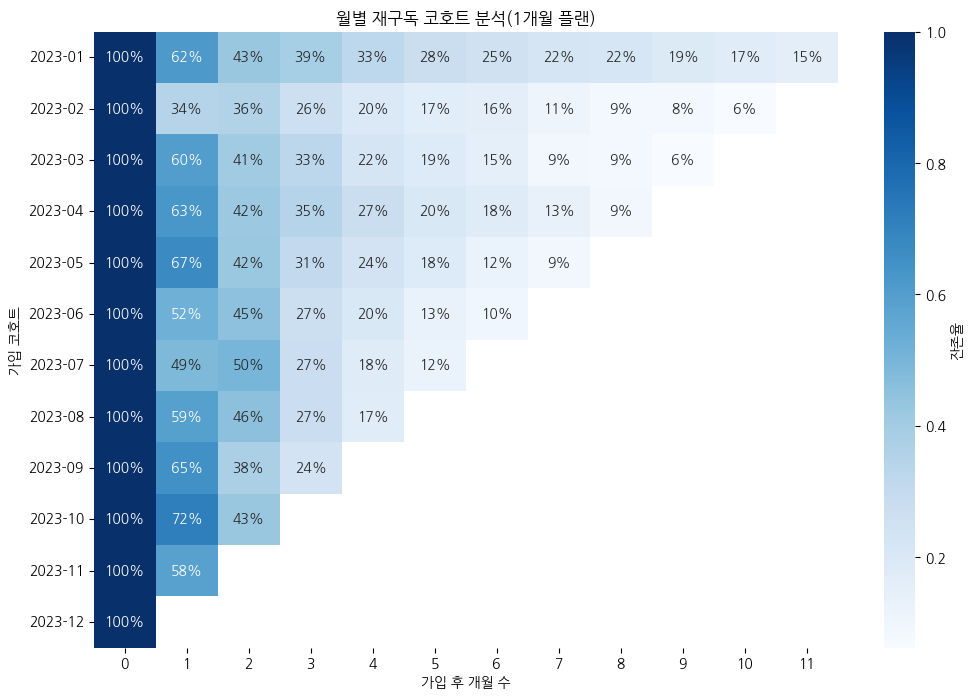

In [ ]:
# 1개월 플랜인 사람들 대상으로 월별 재구독 코호트 분석
monthly_plan_data = user_sub_status[user_sub_status['plan.type'] == '1개월 플랜']

# 코호트 정의 및 잔존율 계산
monthly_plan_data['가입년월'] = monthly_plan_data['결제날짜'].dt.to_period('M')
monthly_plan_data['코호트'] = monthly_plan_data.groupby('user_id')['결제날짜'].transform('min').dt.to_period('M')
monthly_plan_data['코호트_개월'] = (monthly_plan_data['결제날짜'].dt.to_period('M') - monthly_plan_data['코호트']).apply(lambda x: x.n)

# 코호트별 사용자 수와 잔존율 계산
cohort_counts = monthly_plan_data.groupby(['코호트', '코호트_개월'])['user_id'].nunique().unstack()
cohort_size = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_size, axis=0)



# 히트맵으로 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues", cbar_kws={'label': '잔존율'})
plt.title("월별 재구독 코호트 분석(1개월 플랜)")
plt.xlabel("가입 후 개월 수")
plt.ylabel("가입 코호트")
plt.show()

## Retention: 전체 범위 리텐션

In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-11-30')

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = fillter_enter_episode[
    fillter_enter_episode['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 5):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = fillter_enter_episode[
        (fillter_enter_episode['client_event_time'] >= range_start_date) &
        (fillter_enter_episode['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 36.65%
Range 2 Retention Rate: 32.03%
Range 3 Retention Rate: 24.24%


In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-11-01')

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = fillter_enter_episode[
    fillter_enter_episode['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 5): 
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = fillter_enter_episode[
        (fillter_enter_episode['client_event_time'] >= range_start_date) &
        (fillter_enter_episode['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 40.65%
Range 2 Retention Rate: 34.53%
Range 3 Retention Rate: 28.78%


In [ ]:
from datetime import timedelta

# 기준일 설정
reference_date = pd.to_datetime('2023-11-15')

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = fillter_enter_episode[
    fillter_enter_episode['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 5):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = fillter_enter_episode[
        (fillter_enter_episode['client_event_time'] >= range_start_date) &
        (fillter_enter_episode['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 40.93%
Range 2 Retention Rate: 33.07%
Range 3 Retention Rate: 26.97%


In [ ]:
# 기준일 설정
reference_start_date = pd.to_datetime('2023-11-01')
reference_end_date = pd.to_datetime('2023-11-30')

# 전체 리텐션율을 저장할 리스트
retention_rates = []

# 기준일의 각 날짜에 대해 반복
for single_date in pd.date_range(reference_start_date, reference_end_date):
    
    # 기준일에 서비스를 이용한 사용자 추출
    users_on_reference_date = fillter_enter_episode[fillter_enter_episode['client_event_time'].dt.date == single_date.date()]['user_id'].unique()
    
    total_users_count = len(users_on_reference_date)

    # 7일 단위로 4개의 Range를 설정
    for range_num in range(1, 5):
        range_start_date = single_date + timedelta(days=7 * (range_num - 1))
        range_end_date = single_date + timedelta(days=7 * range_num)

        # 각 Range 내에 재방문한 사용자 수 확인
        users_in_range = fillter_enter_episode[
            (fillter_enter_episode['client_event_time'] >= range_start_date) & 
            (fillter_enter_episode['client_event_time'] < range_end_date)
        ]['user_id'].unique()

        # 기준일 사용자 중 재방문 사용자 수 계산
        retained_users = len(set(users_on_reference_date) & set(users_in_range))
        
        # 리텐션율 계산
        retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
        retention_rates.append((single_date.date(), f"Range {range_num-1}", retention_rate))

# Range별 평균 리텐션율 계산
average_retention = {f"Range {i}": [] for i in range(4)}

for date, range_name, rate in retention_rates:
    average_retention[range_name].append(rate)

# 평균 리텐션율 출력
for range_name, rates in average_retention.items():
    average_rate = sum(rates) / len(rates) if rates else 0
    print(f"{range_name} Average Retention Rate: {average_rate:.2f}%")

Range 0 Average Retention Rate: 100.00%
Range 1 Average Retention Rate: 39.74%
Range 2 Average Retention Rate: 32.08%
Range 3 Average Retention Rate: 26.69%


In [ ]:
# 기준일 설정
reference_start_date = pd.to_datetime('2023-10-01')
reference_end_date = pd.to_datetime('2023-10-31')

# 전체 리텐션율을 저장할 리스트
retention_rates = []

# 기준일의 각 날짜에 대해 반복
for single_date in pd.date_range(reference_start_date, reference_end_date):
    
    # 기준일에 서비스를 이용한 사용자 추출
    users_on_reference_date = fillter_enter_episode[fillter_enter_episode['client_event_time'].dt.date == single_date.date()]['user_id'].unique()
    
    total_users_count = len(users_on_reference_date)

    # 7일 단위로 4개의 Range를 설정
    for range_num in range(1, 5):
        range_start_date = single_date + timedelta(days=7 * (range_num - 1))
        range_end_date = single_date + timedelta(days=7 * range_num)

        # 각 Range 내에 재방문한 사용자 수 확인
        users_in_range = fillter_enter_episode[
            (fillter_enter_episode['client_event_time'] >= range_start_date) & 
            (fillter_enter_episode['client_event_time'] < range_end_date)
        ]['user_id'].unique()

        # 기준일 사용자 중 재방문 사용자 수 계산
        retained_users = len(set(users_on_reference_date) & set(users_in_range))
        
        # 리텐션율 계산
        retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
        retention_rates.append((single_date.date(), f"Range {range_num-1}", retention_rate))

# Range별 평균 리텐션율 계산
average_retention = {f"Range {i}": [] for i in range(4)}

for date, range_name, rate in retention_rates:
    average_retention[range_name].append(rate)

# 평균 리텐션율 출력
for range_name, rates in average_retention.items():
    average_rate = sum(rates) / len(rates) if rates else 0
    print(f"{range_name} Average Retention Rate: {average_rate:.2f}%")

Range 0 Average Retention Rate: 100.00%
Range 1 Average Retention Rate: 41.56%
Range 2 Average Retention Rate: 33.72%
Range 3 Average Retention Rate: 30.15%


In [ ]:
start_free[start_free['trial.type'] == 'A']['client_event_time'].min()

NaT

In [ ]:
start_free[start_free['trial.type'] == 'A']['client_event_time'].max()

NaT

## Retention: 세분화 범위 리텐션

In [ ]:
print(enter_episode['client_event_time'].min())
print(complete_sub['client_event_time'].min())
print(renew_sub['client_event_time'].min())
print(resubscribe['client_event_time'].min())
print(click_cancel['client_event_time'].min())
print(start_free['client_event_time'].min())

2023-01-01 00:00:04.606000
2023-01-01 00:18:32.786000
2023-01-01 00:46:07.738000
2023-03-23 14:44:55.822000
2023-01-01 00:01:16.756000
2023-02-01 00:03:03.291000


In [ ]:
print(enter_episode['client_event_time'].max())
print(complete_sub['client_event_time'].max())
print(renew_sub['client_event_time'].max())
print(resubscribe['client_event_time'].max())
print(click_cancel['client_event_time'].max())
print(start_free['client_event_time'].max())

2024-01-01 08:58:48.291000
2024-01-01 01:27:37.370000
2024-01-01 01:10:03.242000
2024-01-01 02:21:26.599000
2024-01-01 07:11:43.740000
2023-04-30 23:59:47.032000


In [ ]:
start_free

,client_event_time,device_family,event_type,user_id,plan.price,plan.type,trial.type
701,2023-02-01 00:03:03.291,Mac,start.free_trial,a426cf7c903f67359c9c9bc3961f0b2d,131600.0,12개월 플랜,B
702,2023-02-01 00:09:45.808,Apple iPhone,start.free_trial,3e0f99f28e28196e4a267d19c335f444,131600.0,12개월 플랜,B
699,2023-02-01 00:31:05.381,Windows,start.free_trial,5a03862592d91c897422a66ad2248cac,15920.0,1개월 플랜,B
700,2023-02-01 00:38:22.195,Windows,start.free_trial,4dbe649f2b407d7eb83e30673bbc8e98,15920.0,1개월 플랜,B
1503,2023-02-01 09:27:06.018,Samsung Phone,start.free_trial,09ba54db421962e4d3813a59a7e97cd6,131600.0,12개월 플랜,B
...,...,...,...,...,...,...,...
2385,2023-04-30 21:53:53.374,Windows,start.free_trial,48b01c56224c89cf3d5f247140c4e352,15920.0,1개월 플랜,B
1714,2023-04-30 22:13:44.708,Samsung SM-S918N,start.free_trial,7079785832f489a60be4583d4858a88d,15920.0,1개월 플랜,B
1713,2023-04-30 22:56:07.995,Windows,start.free_trial,15db6de4ab4dd0c20f1c4dd377e6aaa3,131600.0,12개월 플랜,B
2126,2023-04-30 23:56:40.414,Windows,start.free_trial,cea0d65cbcd9005a6a4e66b5f39aa5e7,15920.0,1개월 플랜,B


In [ ]:
enter_episode

,client_event_time,device_family,event_type,user_id,content.id,is_trial,episode.id,is_free_trial
9062273,2023-01-01 00:00:04.606,Mac,enter.episode_page,d21dc741fde11ffb6768d8bdb3547398,c269eb6df3a374b464f7c18f12fa398f,NaN,c2b88e494ee633b334aa081cac7b1f02,NaN
9062139,2023-01-01 00:00:06.998,Samsung Phone,enter.episode_page,35b5430e0ed0261bfeb063ba6640ed7e,c269eb6df3a374b464f7c18f12fa398f,NaN,25ddafaeab67f4c22eb03219ac82be2f,NaN
9061934,2023-01-01 00:00:07.430,Windows,enter.episode_page,34db86e5555ffbac5a03bc8d9f030e82,afe201c04b426366e0f8e9e2207c78c2,NaN,e600af4dc248233d2e6a9b7f060d47ed,NaN
9062140,2023-01-01 00:00:10.123,Samsung Phone,enter.episode_page,35b5430e0ed0261bfeb063ba6640ed7e,c269eb6df3a374b464f7c18f12fa398f,NaN,25ddafaeab67f4c22eb03219ac82be2f,NaN
9061935,2023-01-01 00:00:10.561,Windows,enter.episode_page,34db86e5555ffbac5a03bc8d9f030e82,afe201c04b426366e0f8e9e2207c78c2,NaN,14ca2317fcaf67ff8e41acf5d08c9c69,NaN
...,...,...,...,...,...,...,...,...
16823863,2024-01-01 08:55:55.453,Mac,enter.episode_page,c6def24e210515ce2f59fae968a39d2e,c8e53577758bf66711094352a5abd8c3,False,081bb0b94ee0d817fd28d67b43c6487f,NaN
16823895,2024-01-01 08:56:42.004,Windows,enter.episode_page,NaN,e88906bb19b773dcbf2adb5d34c49d9c,False,afb90642bd3c4a90583b5a22f08c27cb,NaN
16823904,2024-01-01 08:57:15.239,Samsung Phone,enter.episode_page,NaN,f4be1a0fe0e301b03115591777fddf29,False,17e921513ea63e9dafa11cd84eed32b9,NaN
16823878,2024-01-01 08:57:46.757,Windows,enter.episode_page,4e75fa4d89e22efaaeb19d7796a1af2b,595cb4bbfc83e683b0314ca1312cfbde,False,8806cdf918568960061f8de337dbbeb5,NaN


In [ ]:
f_enter_episode = enter_episode[['client_event_time', 'event_type', 'user_id', 'content.id', 'episode.id', 'is_trial', 'is_free_trial']]
f_complete_sub = complete_sub[['client_event_time', 'event_type', 'user_id', 'plan.type']]
f_renew_sub = renew_sub[['client_event_time', 'event_type', 'user_id', 'plan.type']]
f_resubscribe = resubscribe[['client_event_time', 'event_type', 'user_id', 'plan.type']]
f_click_cancel = click_cancel[['client_event_time', 'event_type', 'user_id']]
f_start_free = start_free[['client_event_time', 'event_type', 'user_id', 'plan.type', 'trial.type']]

In [ ]:
# start_date = pd.to_datetime('2022-11-01')
# end_date = pd.to_datetime('2023-12-31')

# f_enter_episode = f_enter_episode[f_enter_episode['client_event_time'].between(start_date, end_date)]
# f_complete_sub = f_complete_sub[f_complete_sub['client_event_time'].between(start_date, end_date)]
# f_renew_sub = f_renew_sub[f_renew_sub['client_event_time'].between(start_date, end_date)]
# f_resubscribe = f_resubscribe[f_resubscribe['client_event_time'].between(start_date, end_date)]
# f_click_cancel = f_click_cancel[f_click_cancel['client_event_time'].between(start_date, end_date)]

In [ ]:
f_enter_episode

,client_event_time,event_type,user_id,content.id,episode.id,is_trial,is_free_trial
9062273,2023-01-01 00:00:04.606,enter.episode_page,d21dc741fde11ffb6768d8bdb3547398,c269eb6df3a374b464f7c18f12fa398f,c2b88e494ee633b334aa081cac7b1f02,NaN,NaN
9062139,2023-01-01 00:00:06.998,enter.episode_page,35b5430e0ed0261bfeb063ba6640ed7e,c269eb6df3a374b464f7c18f12fa398f,25ddafaeab67f4c22eb03219ac82be2f,NaN,NaN
9061934,2023-01-01 00:00:07.430,enter.episode_page,34db86e5555ffbac5a03bc8d9f030e82,afe201c04b426366e0f8e9e2207c78c2,e600af4dc248233d2e6a9b7f060d47ed,NaN,NaN
9062140,2023-01-01 00:00:10.123,enter.episode_page,35b5430e0ed0261bfeb063ba6640ed7e,c269eb6df3a374b464f7c18f12fa398f,25ddafaeab67f4c22eb03219ac82be2f,NaN,NaN
9061935,2023-01-01 00:00:10.561,enter.episode_page,34db86e5555ffbac5a03bc8d9f030e82,afe201c04b426366e0f8e9e2207c78c2,14ca2317fcaf67ff8e41acf5d08c9c69,NaN,NaN
...,...,...,...,...,...,...,...
16823863,2024-01-01 08:55:55.453,enter.episode_page,c6def24e210515ce2f59fae968a39d2e,c8e53577758bf66711094352a5abd8c3,081bb0b94ee0d817fd28d67b43c6487f,False,NaN
16823895,2024-01-01 08:56:42.004,enter.episode_page,NaN,e88906bb19b773dcbf2adb5d34c49d9c,afb90642bd3c4a90583b5a22f08c27cb,False,NaN
16823904,2024-01-01 08:57:15.239,enter.episode_page,NaN,f4be1a0fe0e301b03115591777fddf29,17e921513ea63e9dafa11cd84eed32b9,False,NaN
16823878,2024-01-01 08:57:46.757,enter.episode_page,4e75fa4d89e22efaaeb19d7796a1af2b,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN


In [ ]:
# 날짜와 시간(시)만 추출하여 새로운 열 생성
f_enter_episode['date_hour'] = pd.to_datetime(f_enter_episode['client_event_time']).dt.strftime('%Y-%m-%d %H')

# 중복 제거: 'user_id'와 'date_hour'가 같은 경우 첫 번째 행만 남기기
f_enter_episode_unique = f_enter_episode.drop_duplicates(subset=['user_id', 'date_hour'], keep='last')

f_enter_episode_unique

,client_event_time,event_type,user_id,content.id,episode.id,is_trial,is_free_trial,date_hour
9062123,2023-01-01 00:00:45.516,enter.episode_page,7f7711efa33b4c7f934e589055c65203,b314d5aba64a0aab40602cb72a4a1504,978ad32f8256b792e7a05d7bd5db8923,NaN,NaN,2023-01-01 00
9062791,2023-01-01 00:02:05.302,enter.episode_page,ed304a503eb872c4951cd9a52c08d7f3,f64c475280676531a31f2f8e0648599c,06f3efc915796c2011ec438acb57ebe1,NaN,NaN,2023-01-01 00
9062145,2023-01-01 00:02:06.313,enter.episode_page,35b5430e0ed0261bfeb063ba6640ed7e,1ccd38c0253604fb48f78970736f915c,01826ed9a19967fa32a7bcfcd4af9b2a,NaN,NaN,2023-01-01 00
9061911,2023-01-01 00:02:53.142,enter.episode_page,fb1133cff45fcc013c718cfd5b82d396,7cebec6e79cc981dbf421c5ec2aedd9d,fda7d494423782085b0675580939e3b8,NaN,NaN,2023-01-01 00
9062242,2023-01-01 00:03:58.855,enter.episode_page,1823d75e4bd71364d5c7519dbadc8087,18992b667be06d6f29ba0008f99d9745,57bdb5bf63971461457d28258b164e90,NaN,NaN,2023-01-01 00
...,...,...,...,...,...,...,...,...
16823866,2024-01-01 08:50:23.321,enter.episode_page,2ca32996600cb18f9016fb007f068178,4641438a6c81ef572d997dbdc9100f8b,5c6494703483d3375174bf8ef9ac1f45,False,NaN,2024-01-01 08
16823863,2024-01-01 08:55:55.453,enter.episode_page,c6def24e210515ce2f59fae968a39d2e,c8e53577758bf66711094352a5abd8c3,081bb0b94ee0d817fd28d67b43c6487f,False,NaN,2024-01-01 08
16823904,2024-01-01 08:57:15.239,enter.episode_page,NaN,f4be1a0fe0e301b03115591777fddf29,17e921513ea63e9dafa11cd84eed32b9,False,NaN,2024-01-01 08
16823878,2024-01-01 08:57:46.757,enter.episode_page,4e75fa4d89e22efaaeb19d7796a1af2b,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN,2024-01-01 08


In [ ]:
# 두 데이터프레임 세로 병합 (열 이름 맞추기)
merged_df = pd.concat([f_enter_episode_unique, f_complete_sub, f_renew_sub, f_resubscribe, f_click_cancel, f_start_free], ignore_index=True, sort=False)

# client_event_time을 기준으로 정렬
merged_df = merged_df.sort_values(by=['user_id', 'client_event_time']).reset_index(drop=True)
merged_df

,client_event_time,event_type,user_id,content.id,episode.id,is_trial,is_free_trial,date_hour,plan.type,trial.type
0,2023-03-18 19:53:41.558,enter.episode_page,0000572f2ba8079bcefd2760b632e820,61b6463287573f00de13a930805a52d6,70cb48c6327ced134821d9494f53cc60,True,NaN,2023-03-18 19,NaN,NaN
1,2023-03-18 23:33:22.636,enter.episode_page,0000572f2ba8079bcefd2760b632e820,61b6463287573f00de13a930805a52d6,58a55a039ef52567cfe0821f92b3c9e6,False,NaN,2023-03-18 23,NaN,NaN
2,2023-03-18 23:39:22.844,start.free_trial,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaN,NaN,NaN,1개월 플랜,B
3,2023-03-19 00:54:11.764,enter.episode_page,0000572f2ba8079bcefd2760b632e820,61b6463287573f00de13a930805a52d6,ce99776e0779bc82754a1fc8bfb719d1,False,NaN,2023-03-19 00,NaN,NaN
4,2023-03-19 01:57:13.387,enter.episode_page,0000572f2ba8079bcefd2760b632e820,f4be1a0fe0e301b03115591777fddf29,3022970a4832e8c927847f63c3fad410,False,NaN,2023-03-19 01,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
916878,2024-01-01 05:52:18.697,enter.episode_page,NaN,e88906bb19b773dcbf2adb5d34c49d9c,fdf14e22bf37431a7ee46a4ef6c2118f,False,NaN,2024-01-01 05,NaN,NaN
916879,2024-01-01 06:49:50.675,enter.episode_page,NaN,445fac33232adcb3d1cdab7d8a579430,ce0bfeb7fb1259c588f437d48ab2690c,False,NaN,2024-01-01 06,NaN,NaN
916880,2024-01-01 07:11:43.740,click.cancel_plan_button,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
916881,2024-01-01 07:58:07.060,enter.episode_page,NaN,61b6463287573f00de13a930805a52d6,2ed4b83e65edc2b1efb193aaa3c60cf9,False,NaN,2024-01-01 07,NaN,NaN


In [ ]:
# 'user_id' 열에서 NaN 값이 있는 행 삭제
merged_df = merged_df.dropna(subset=['user_id'])
merged_df

,client_event_time,event_type,user_id,content.id,episode.id,is_trial,is_free_trial,date_hour,plan.type,trial.type
0,2023-03-18 19:53:41.558,enter.episode_page,0000572f2ba8079bcefd2760b632e820,61b6463287573f00de13a930805a52d6,70cb48c6327ced134821d9494f53cc60,True,NaN,2023-03-18 19,NaN,NaN
1,2023-03-18 23:33:22.636,enter.episode_page,0000572f2ba8079bcefd2760b632e820,61b6463287573f00de13a930805a52d6,58a55a039ef52567cfe0821f92b3c9e6,False,NaN,2023-03-18 23,NaN,NaN
2,2023-03-18 23:39:22.844,start.free_trial,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaN,NaN,NaN,1개월 플랜,B
3,2023-03-19 00:54:11.764,enter.episode_page,0000572f2ba8079bcefd2760b632e820,61b6463287573f00de13a930805a52d6,ce99776e0779bc82754a1fc8bfb719d1,False,NaN,2023-03-19 00,NaN,NaN
4,2023-03-19 01:57:13.387,enter.episode_page,0000572f2ba8079bcefd2760b632e820,f4be1a0fe0e301b03115591777fddf29,3022970a4832e8c927847f63c3fad410,False,NaN,2023-03-19 01,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
907231,2023-10-15 03:42:25.138,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-10-15 03,NaN,NaN
907232,2023-11-15 13:45:35.421,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-15 13,NaN,NaN
907233,2023-11-15 14:06:00.833,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,False,NaN,2023-11-15 14,NaN,NaN
907234,2023-11-30 12:27:05.918,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN,2023-11-30 12,NaN,NaN


In [ ]:
# client_event_time 기준으로 정렬
merged_df = merged_df.sort_values(by=['user_id', 'client_event_time']).reset_index(drop=True)
merged_df

,client_event_time,event_type,user_id,content.id,episode.id,is_trial,is_free_trial,date_hour,plan.type,trial.type
0,2023-03-18 19:53:41.558,enter.episode_page,0000572f2ba8079bcefd2760b632e820,61b6463287573f00de13a930805a52d6,70cb48c6327ced134821d9494f53cc60,True,NaN,2023-03-18 19,NaN,NaN
1,2023-03-18 23:33:22.636,enter.episode_page,0000572f2ba8079bcefd2760b632e820,61b6463287573f00de13a930805a52d6,58a55a039ef52567cfe0821f92b3c9e6,False,NaN,2023-03-18 23,NaN,NaN
2,2023-03-18 23:39:22.844,start.free_trial,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaN,NaN,NaN,1개월 플랜,B
3,2023-03-19 00:54:11.764,enter.episode_page,0000572f2ba8079bcefd2760b632e820,61b6463287573f00de13a930805a52d6,ce99776e0779bc82754a1fc8bfb719d1,False,NaN,2023-03-19 00,NaN,NaN
4,2023-03-19 01:57:13.387,enter.episode_page,0000572f2ba8079bcefd2760b632e820,f4be1a0fe0e301b03115591777fddf29,3022970a4832e8c927847f63c3fad410,False,NaN,2023-03-19 01,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
907231,2023-10-15 03:42:25.138,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-10-15 03,NaN,NaN
907232,2023-11-15 13:45:35.421,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-15 13,NaN,NaN
907233,2023-11-15 14:06:00.833,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,False,NaN,2023-11-15 14,NaN,NaN
907234,2023-11-30 12:27:05.918,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN,2023-11-30 12,NaN,NaN


In [ ]:
merged_df['event_type'].unique()

array(['enter.episode_page', 'start.free_trial', 'complete.subscription',
       'renew.subscription', 'click.cancel_plan_button',
       'resubscribe.subscription'], dtype=object)

In [ ]:
# 구독 상태를 추적하기 위한 변수
is_subscribed = False

user_id = ''
plan_type = ''
trial_type = ''

# 각 행을 순회하며 구독 상태에 따라 plan.type과 trial.type 값 설정
for index, row in user_total.iterrows():
    if row['event_type'] in ['complete.subscription', 'renew.subscription', 'resubscribe.subscription']:
        user_id = row['user_id']
        plan_type = row['plan.type']
        
        is_subscribed = True

    else :
        if (is_subscribed) and (user_id == row['user_id']) and (row['is_trial'] != 'True'):
            user_total.at[index, 'plan.type'] = plan_type

        elif (user_id != row['user_id']):
            is_subscribed = False


user_total

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date
21762,2023-03-18 19:33:16.237,complete.signup,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
124072,2023-03-18 19:34:12.788,enter.payment_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1258957,2023-03-18 19:34:28.892,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,2ed4b83e65edc2b1efb193aaa3c60cf9,True,NaN,2023-03-18
1258983,2023-03-18 19:37:05.778,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,db421b66bfd27eccd0e862e30b4de1be,True,NaN,2023-03-18
1259038,2023-03-18 19:42:48.654,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,09c8a2d29087cb3d47823acb5f2705e3,True,NaN,2023-03-18
...,...,...,...,...,...,...,...,...,...,...,...,...
218696,2023-11-15 14:17:47.168,enter.payment_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3982822,2023-11-30 12:25:33.257,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-30
3982827,2023-11-30 12:27:05.918,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN,2023-11-30
76352,2023-11-29 14:23:47.312,complete.signup,ffffddaaae9808ecc37c5238ada79ce1,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
user_total[(user_total['event_type'] == 'enter.episode_page') & ~(user_total['plan.type'].isna()) & (user_total['is_trial'] == 'True')]

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date


In [ ]:
user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'].isna())]

,client_event_time,event_type,user_id,plan.type,pg.type,expire_day,trial.type,content.id,episode.id,is_trial,is_free_trial,date
1258957,2023-03-18 19:34:28.892,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,2ed4b83e65edc2b1efb193aaa3c60cf9,True,NaN,2023-03-18
1258983,2023-03-18 19:37:05.778,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,db421b66bfd27eccd0e862e30b4de1be,True,NaN,2023-03-18
1259038,2023-03-18 19:42:48.654,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,09c8a2d29087cb3d47823acb5f2705e3,True,NaN,2023-03-18
1259071,2023-03-18 19:46:07.383,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,b734f43b5123f8bdbf7d8f865bd3eacf,True,NaN,2023-03-18
1259120,2023-03-18 19:51:40.154,enter.episode_page,0000572f2ba8079bcefd2760b632e820,NaN,NaN,NaT,NaN,61b6463287573f00de13a930805a52d6,6e3afbeb4942c6c29038321e5995f4f1,True,NaN,2023-03-18
...,...,...,...,...,...,...,...,...,...,...,...,...
3900877,2023-11-15 14:03:20.206,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,a6a8c4b3f5b40b8a96c8f6db10e43bf8,False,NaN,2023-11-15
3900910,2023-11-15 14:06:00.833,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b05e0fb8ab15def4b33878b9a759b4f2,False,NaN,2023-11-15
3982822,2023-11-30 12:25:33.257,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,f4be1a0fe0e301b03115591777fddf29,b42c9bb32f5024900cbed7623eecd272,False,NaN,2023-11-30
3982827,2023-11-30 12:27:05.918,enter.episode_page,ffffd8d78865a66cb3706977f29d1dec,NaN,NaN,NaT,NaN,595cb4bbfc83e683b0314ca1312cfbde,8806cdf918568960061f8de337dbbeb5,False,NaN,2023-11-30


In [ ]:
# 1개월 플랜 사용자 주별 에피소드 시청 횟수 계산
episode_1monthplan = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '1개월 플랜')]

# 각 유저의 첫 번째 에피소드 시청 날짜 가져오기
first_watch = episode_1monthplan.groupby("user_id")["client_event_time"].min().reset_index()
first_watch.columns = ["user_id", "first_watch_date"]
  
# 원본 데이터프레임에 첫 시청 날짜를 병합
episode_1monthplan_first = pd.merge(episode_1monthplan[['client_event_time', 'event_type', 'user_id', 'plan.type']], first_watch, on="user_id", how="left")

# 첫 시청 날짜로부터 경과한 주차 계산
episode_1monthplan_first["week_since_first_watch"] = ((episode_1monthplan_first["client_event_time"] - episode_1monthplan_first["first_watch_date"]).dt.days // 7) + 1

# 주차별 시청 횟수 집계
weekly_episode_1monthplan = episode_1monthplan_first.groupby(["user_id", "week_since_first_watch"]).size().reset_index(name="view_count")

weekly_episode_1monthplan

,user_id,week_since_first_watch,view_count
0,0000572f2ba8079bcefd2760b632e820,1,26
1,0000572f2ba8079bcefd2760b632e820,2,3
2,0001f15911b404f3bf5b8571afafa4e4,1,10
3,0001f15911b404f3bf5b8571afafa4e4,2,5
4,0001f15911b404f3bf5b8571afafa4e4,3,5
...,...,...,...
16772,fffe529de03d6187ef7ed765650c8d2b,22,45
16773,fffe529de03d6187ef7ed765650c8d2b,25,25
16774,fffe529de03d6187ef7ed765650c8d2b,27,24
16775,fffe529de03d6187ef7ed765650c8d2b,28,5


In [ ]:
weekly_episode_1monthplan[weekly_episode_1monthplan['user_id'] == 'fffe529de03d6187ef7ed765650c8d2b']

,user_id,week_since_first_watch,view_count
16761,fffe529de03d6187ef7ed765650c8d2b,1,90
16762,fffe529de03d6187ef7ed765650c8d2b,2,69
16763,fffe529de03d6187ef7ed765650c8d2b,3,5
16764,fffe529de03d6187ef7ed765650c8d2b,4,29
16765,fffe529de03d6187ef7ed765650c8d2b,8,17
16766,fffe529de03d6187ef7ed765650c8d2b,9,61
16767,fffe529de03d6187ef7ed765650c8d2b,11,19
16768,fffe529de03d6187ef7ed765650c8d2b,12,8
16769,fffe529de03d6187ef7ed765650c8d2b,17,7
16770,fffe529de03d6187ef7ed765650c8d2b,18,31


In [ ]:
from datetime import timedelta

# 기준일 설정
reference_date = pd.to_datetime('2023-11-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '1개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 5):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 71.24%
Range 2 Retention Rate: 58.82%
Range 3 Retention Rate: 50.98%


In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-11-15')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '1개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 5):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 72.99%
Range 2 Retention Rate: 59.20%
Range 3 Retention Rate: 50.00%


In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-11-30')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '1개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 5):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 72.83%
Range 2 Retention Rate: 63.58%
Range 3 Retention Rate: 42.20%


In [ ]:
def range_retention_average(reference_start_date, reference_end_date, df):
    # 전체 리텐션율을 저장할 리스트
    retention_rates = []

    # 기준일의 각 날짜에 대해 반복
    for single_date in pd.date_range(reference_start_date, reference_end_date):
        
        # 기준일에 서비스를 이용한 사용자 추출
        users_on_reference_date = df[df['client_event_time'].dt.date == single_date.date()]['user_id'].unique()
        
        total_users_count = len(users_on_reference_date)

        # 7일 단위로 4개의 Range를 설정
        for range_num in range(1, 5):
            range_start_date = single_date + timedelta(days=7 * (range_num - 1))
            range_end_date = single_date + timedelta(days=7 * range_num)

            # 각 Range 내에 재방문한 사용자 수 확인
            users_in_range = df[
                (df['client_event_time'] >= range_start_date) & 
                (df['client_event_time'] < range_end_date)
            ]['user_id'].unique()

            # 기준일 사용자 중 재방문 사용자 수 계산
            retained_users = len(set(users_on_reference_date) & set(users_in_range))
            
            # 리텐션율 계산
            retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
            retention_rates.append((single_date.date(), f"Range {range_num-1}", retention_rate))

    # Range별 평균 리텐션율 계산
    average_retention = {f"Range {i}": [] for i in range(4)}

    for date, range_name, rate in retention_rates:
        average_retention[range_name].append(rate)

    # 평균 리텐션율 출력
    for range_name, rates in average_retention.items():
        average_rate = sum(rates) / len(rates) if rates else 0
        print(f"{range_name} Average Retention Rate: {average_rate:.2f}%")

In [ ]:
# 기준일 설정
reference_start_date = pd.to_datetime('2023-10-01')
reference_end_date = pd.to_datetime('2023-10-31')

# 1개월 플랜을 이용한 사용자 추출
reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '1개월 플랜')]

range_retention_average(reference_start_date, reference_end_date, reference_df)

Range 0 Average Retention Rate: 100.00%
Range 1 Average Retention Rate: 62.67%
Range 2 Average Retention Rate: 51.07%
Range 3 Average Retention Rate: 44.23%


In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-12-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '1개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 5):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 67.91%
Range 2 Retention Rate: 56.72%
Range 3 Retention Rate: 36.57%


In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-12-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '12개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 5):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 67.02%
Range 2 Retention Rate: 55.32%
Range 3 Retention Rate: 43.62%


In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-12-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '3개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 5):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 0.00%
Range 1 Retention Rate: 0.00%
Range 2 Retention Rate: 0.00%
Range 3 Retention Rate: 0.00%


In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-12-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (~(user_total['trial.type'].isna()) | ~(user_total['is_trial'].isna()) | ~(user_total['is_free_trial'].isna()))]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 5):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 37.86%
Range 2 Retention Rate: 30.74%
Range 3 Retention Rate: 21.36%


In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-11-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '12개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 9):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 55.17%
Range 2 Retention Rate: 56.32%
Range 3 Retention Rate: 45.98%
Range 4 Retention Rate: 40.23%
Range 5 Retention Rate: 37.93%
Range 6 Retention Rate: 32.18%
Range 7 Retention Rate: 35.63%


In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-11-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '1개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 9):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 71.24%
Range 2 Retention Rate: 58.82%
Range 3 Retention Rate: 50.98%
Range 4 Retention Rate: 46.41%
Range 5 Retention Rate: 38.56%
Range 6 Retention Rate: 30.72%
Range 7 Retention Rate: 32.03%


In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-11-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (~(user_total['trial.type'].isna()) | ~(user_total['is_trial'].isna()) | ~(user_total['is_free_trial'].isna()))]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 9):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 40.65%
Range 2 Retention Rate: 34.53%
Range 3 Retention Rate: 28.78%
Range 4 Retention Rate: 24.82%
Range 5 Retention Rate: 21.40%
Range 6 Retention Rate: 18.35%
Range 7 Retention Rate: 18.88%


1 Retention Rate: 100.00%
2 Retention Rate: 85.53%
3 Retention Rate: 76.97%
4 Retention Rate: 58.55%
5 Retention Rate: 39.47%
6 Retention Rate: 33.55%
7 Retention Rate: 30.26%
8 Retention Rate: 24.67%
9 Retention Rate: 22.04%
10 Retention Rate: 16.45%
11 Retention Rate: 18.09%
12 Retention Rate: 14.80%
13 Retention Rate: 10.53%
14 Retention Rate: 9.21%
15 Retention Rate: 9.54%
16 Retention Rate: 6.25%
17 Retention Rate: 6.58%
18 Retention Rate: 6.58%
19 Retention Rate: 7.57%
20 Retention Rate: 6.91%
21 Retention Rate: 5.92%
22 Retention Rate: 5.26%
23 Retention Rate: 5.26%
24 Retention Rate: 3.95%
25 Retention Rate: 4.61%
26 Retention Rate: 5.59%


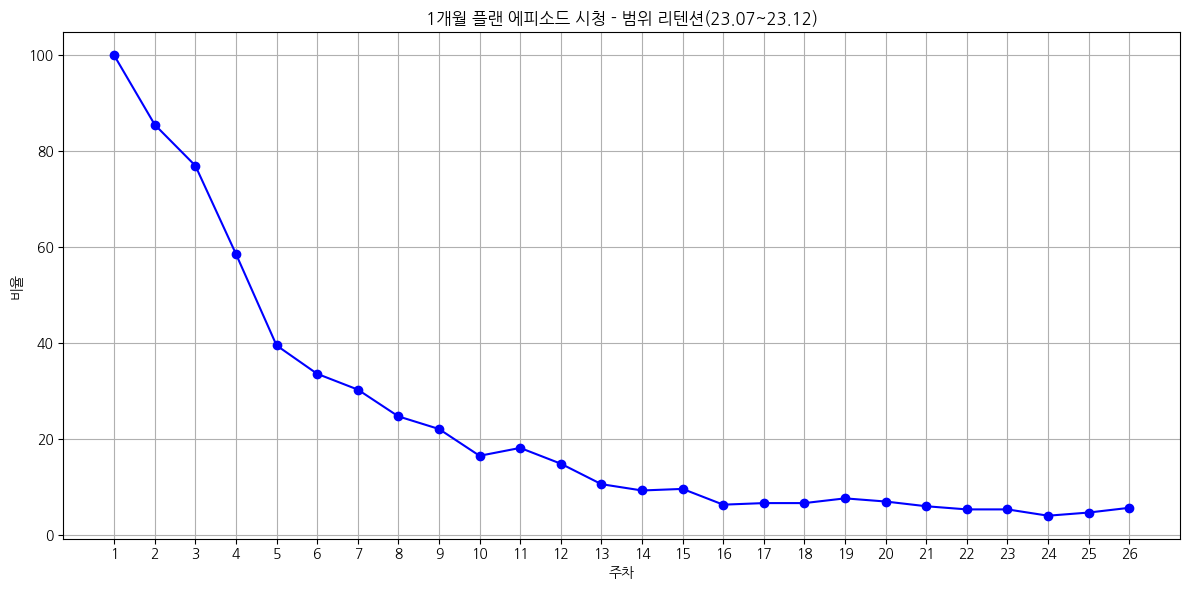

In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-07-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '1개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 Range를 설정
# 7월부터 12월까지 약 22주
for range_num in range(1, 27):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((range_num, retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

# 범위와 값 분리
ranges, values = zip(*retention_rates)

# 그래프 생성
plt.figure(figsize=(12, 6))
plt.plot(ranges, values, marker='o', color='blue', linestyle='-')
plt.title("1개월 플랜 에피소드 시청 - 범위 리텐션(23.07~23.12)")
plt.xlabel("주차")
plt.ylabel("비율")
plt.xticks(rotation=0, ticks=range(1, 27), labels=range(1, 27))  # x축 0~26까지 표시
plt.grid(True)

# 그래프 표시
plt.tight_layout()
plt.show()

In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-07-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '1개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 Range를 설정
# 7월부터 12월까지 약 22주
for range_num in range(1, 27):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((range_num, retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

# 범위와 값 분리
ranges, values = zip(*retention_rates)

data = pd.DataFrame({'Week': ranges, 'Retention Rate': values})

# PX를 사용한 시각화
fig = px.line(data, x='Week', y='Retention Rate', 
              title="1개월 플랜 에피소드 열람 - 범위 리텐션(23.07~23.12)",
              labels={'Week': '주차', 'Retention Rate': '비율'},
              markers=True)


# X축의 값 연속적으로 표시되도록 설정
fig.update_layout(
    xaxis=dict(
        tickmode='linear',  # 연속적인 tick 설정
        dtick=1,  # 1씩 증가하도록 설정
        range=[0.5, 26.5]  # X축 범위를 1에서 26으로 설정
    )
)

fig.show()

1 Retention Rate: 100.00%
2 Retention Rate: 85.53%
3 Retention Rate: 76.97%
4 Retention Rate: 58.55%
5 Retention Rate: 39.47%
6 Retention Rate: 33.55%
7 Retention Rate: 30.26%
8 Retention Rate: 24.67%
9 Retention Rate: 22.04%
10 Retention Rate: 16.45%
11 Retention Rate: 18.09%
12 Retention Rate: 14.80%
13 Retention Rate: 10.53%
14 Retention Rate: 9.21%
15 Retention Rate: 9.54%
16 Retention Rate: 6.25%
17 Retention Rate: 6.58%
18 Retention Rate: 6.58%
19 Retention Rate: 7.57%
20 Retention Rate: 6.91%
21 Retention Rate: 5.92%
22 Retention Rate: 5.26%
23 Retention Rate: 5.26%
24 Retention Rate: 3.95%
25 Retention Rate: 4.61%
26 Retention Rate: 5.59%


Range 0 Retention Rate: 100.00%
Range 1 Retention Rate: 80.00%
Range 2 Retention Rate: 60.00%
Range 3 Retention Rate: 46.67%
Range 4 Retention Rate: 46.67%
Range 5 Retention Rate: 60.00%
Range 6 Retention Rate: 53.33%
Range 7 Retention Rate: 53.33%
Range 8 Retention Rate: 33.33%
Range 9 Retention Rate: 46.67%
Range 10 Retention Rate: 46.67%
Range 11 Retention Rate: 46.67%
Range 12 Retention Rate: 33.33%
Range 13 Retention Rate: 33.33%
Range 14 Retention Rate: 20.00%
Range 15 Retention Rate: 33.33%
Range 16 Retention Rate: 26.67%
Range 17 Retention Rate: 20.00%
Range 18 Retention Rate: 20.00%
Range 19 Retention Rate: 13.33%
Range 20 Retention Rate: 26.67%
Range 21 Retention Rate: 26.67%
Range 22 Retention Rate: 13.33%
Range 23 Retention Rate: 13.33%
Range 24 Retention Rate: 13.33%
Range 25 Retention Rate: 20.00%
Range 26 Retention Rate: 20.00%
Range 27 Retention Rate: 13.33%
Range 28 Retention Rate: 20.00%
Range 29 Retention Rate: 6.67%
Range 30 Retention Rate: 6.67%
Range 31 Retention 

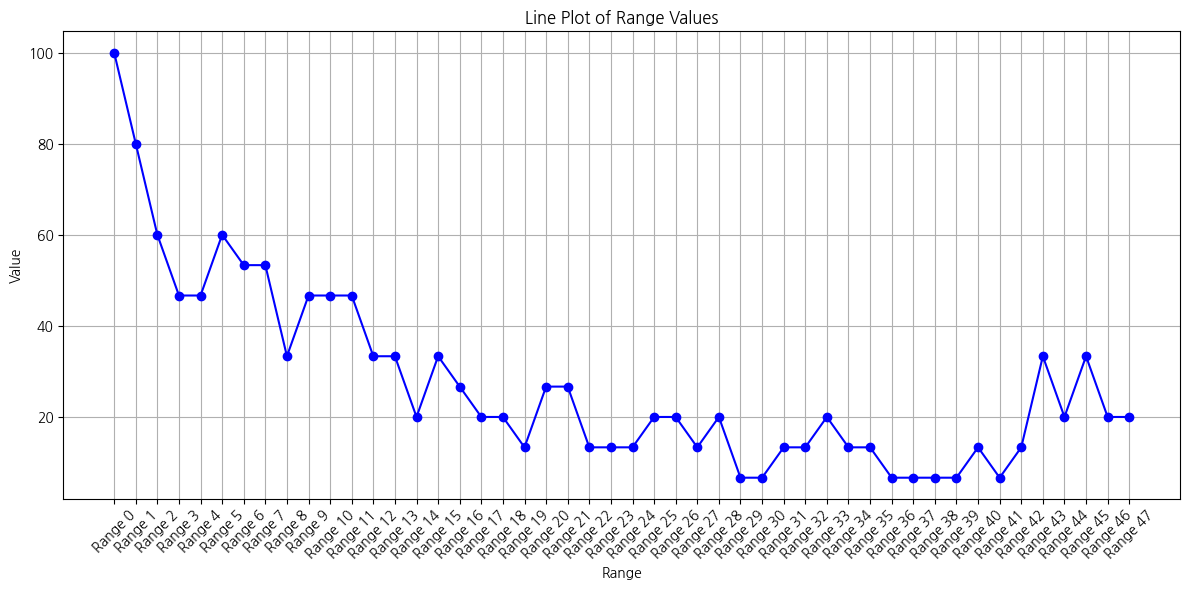

In [ ]:
# 기준일 설정
reference_date = pd.to_datetime('2023-01-01')

reference_df = user_total[(user_total['event_type'] == 'enter.episode_page') & (user_total['plan.type'] == '12개월 플랜')]

# 기준일에 서비스를 이용한 사용자 추출
users_on_reference_date = reference_df[
    reference_df['client_event_time'].dt.date == reference_date.date()
]['user_id'].unique()

# 전체 사용자 수
total_users_count = len(users_on_reference_date)

# 결과 저장 리스트
retention_rates = []

# 7일 단위로 4개의 Range를 설정
for range_num in range(1, 49):
    range_start_date = reference_date + timedelta(days=7 * (range_num - 1))
    range_end_date = reference_date + timedelta(days=7 * range_num)

    # 각 Range 내에 재방문한 사용자 수 확인
    users_in_range = reference_df[
        (reference_df['client_event_time'] >= range_start_date) &
        (reference_df['client_event_time'] < range_end_date)
    ]['user_id'].unique()

    # 기준일 사용자 중 재방문 사용자 수 계산
    retained_users = len(set(users_on_reference_date) & set(users_in_range))
    
    # 리텐션율 계산
    retention_rate = (retained_users / total_users_count) * 100 if total_users_count > 0 else 0
    retention_rates.append((f"Range {range_num-1}", retention_rate))

# 결과 출력
for range_name, rate in retention_rates:
    print(f"{range_name} Retention Rate: {rate:.2f}%")

# 범위와 값 분리
ranges, values = zip(*retention_rates)

# 그래프 생성
plt.figure(figsize=(12, 6))
plt.plot(ranges, values, marker='o', color='blue', linestyle='-')
plt.title("Line Plot of Range Values")
plt.xlabel("Range")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(True)

# 그래프 표시
plt.tight_layout()
plt.show()

# 문제 정의

## 페르소나: 트렌드를 제공하는 뉴스레터 플랫폼 '데스레터' (Data + Newsletter)

데스레터는 2022년부터 시작된 트렌드 인사이트 구독 플랫폼이다. 다양한 주제의 트렌드를 뉴스레터 형식으로 전달하며, 주요 고객층은 트렌드에 민감한 20~30대 마케터이다. 이러한 서비스 페르소나를 설정한 이유는 다음과 같다.

첫째, 짧은 에피소드 소비 시간. 하나의 에피소드를 읽는 데 걸리는 시간이 짧아, 드라마나 영화와 같은 긴 영상을 제공하는 OTT 구독 플랫폼보다 빠르게 소비할 수 있는 콘텐츠가 적합하다고 판단했다. 따라서 데스레터는 간단히 읽을 수 있는 글과 이미지 기반의 카드 뉴스 형식으로 구성되어, 바쁜 업무 중에도 쉽게 정보를 얻을 수 있는 뉴스 구독 플랫폼으로 설정하였다.

둘째, 서비스 사용 시간대의 적합성. 주중·주말 모두 오전 10시부터 오후 12시까지 다양한 시간대에 걸쳐 사용되지만, 특히 오후 1시부터 5시에 사용이 집중된다. 이는 처음 생각했던 넷플릭스와 같은 OTT 구독 플랫폼의 사용 패턴과는 다르며, 뉴스 구독 플랫폼이 더 적합하다고 판단했다. 또한, 이 시간대가 마케터들의 주요 업무 시간과 겹치기 때문에 데스레터의 주요 고객층을 20~30대 마케터로 설정하였다.

유사한 서비스를 조사하는 과정에서 가장 비슷한 플랫폼으로 '캐릿'을 발견했다. 캐릿 역시 다양한 콘텐츠와 트렌드 인사이트를 제공하며, 시리즈별 콘텐츠와 주제별 큐레이션을 통해 Z세대와 마케터들에게 인기를 얻고 있다. 또한, 캐릿은 대부분의 뉴스레터 구독 플랫폼이 무료인 것과 달리, 데스레터처럼 1, 3, 12개월 플랜을 가진 유료 구독 모델을 채택하고 있어 유사성을 보인다.

## 문제 발견

최근 다른 플랫폼의 월 평균 구독 이탈률이 3.6%에서 7.6% 사이를 유지하는 것과 비교할 때, 데스레터의 구독 취소율이 30%를 초과한다는 점은 서비스에 중요한 문제로 작용한다. 뿐만 아니라, 이 문제는 최근들어 더 심각해질 것으로 보인다.

1개월 플랜 가입유저들을 대상으로 코호트 분석 결과를 살펴보면 2023년 8월부터 10월 사이에 가입한 유저들 중 다음 달에도 플랜을 이어나가는 비율이  각각 59%, 65%, 72%를 기록해 리텐션이 증가하는 좋은 모습을 보였으나 11월에 갑자기 58%로 떨어졌다.

물론 23년 2월에는 34%, 7월에는 49%를 기록하는 등 프로모션 직후 리텐션이 떨어졌다가 다음 달에 다시 회복하는 모습을 보이는 것과 같은 패턴일 수 있다.

하지만, 23년 10월에는 프로모션이 없었다는 점과 23년 12월에서만 크게 감소한 에피소드 열람 빈도를 종합하면 앞으로 activation이나 retention 지표가 크게 떨어질 수 있는 상황이 다가올 수 있다.

본사의 높은 이탈률, 낮아진 리텐션,  급격히 감소한 에피소드 열람 등 문제점을 해결하기 위한 방안을 모색하기 위해 업계 동향과 최신 연구 결과를 검토했다.

이 과정에서 구독형 플랫폼에만 존재하는 이탈 분류법을 확인할 수 있었다. 첫 번째 유형은 '강한 이탈'로, 구독 취소와 같은 직접적인 이탈을 의미한다.

두 번째 유형은 '약한 이탈'로, 구독을 유지하더라도 이용률이 감소하는 경우를 지칭한다.  단계적으로 약한 이탈이 강한 이탈로 이어질 가능성이 크기 때문에 구독자의 약한 이탈을 사전에 감지하고 방지하는 것이 중요하다.

뉴스 플랫폼에서 ‘좀비’라고도 불리는 약한 이탈 구독자들은 구독료를 지불하고 언론사 웹페이지를 거의 방문하지 않아 정기성이 결여된 구독자들이다.

약한 이탈의 규모가 커지고 그 기간이 길어질수록 기업은 제대로 된 뉴스 선호도 등을 확인할 수 없어 구독 모델의 진로가 불명확해진다.

이에 데스레터의 신입 데이터분석가들은 구독형 플랫폼에 존재하는 약한 이탈이 데스레터에도 적용되는지 알아보기 위해 다음과 같이 문제를 정의했다.

"약한 이탈은 강한 이탈이 일어나기 전에 나타나는 현상인가?"

## 개념 정의

위 문제에 대해 설명하기 위해 데이터 분석가들은 데스레터의 핵심 기능인 '에피소드 열람'에 중점을 두어 강한 이탈과 약한 이탈에 대한 개념적 정의를 내렸다.
- 강한 이탈: 구독을 취소하거나, 구독 만료 후 재구독을 하지 않은 상태
- 약한 이탈: 구독을 했는데 에피소드를 열람하지 않고 정기성이 결여된 상태

그리고 기준에 따라 다양하게 정의를 내릴 수 있는 약한 이탈에 대한 조작적 정의를 내리기 위해 일별 에피소드 열람 빈도를 확인했다.

화요일에 빈도 수가 높고 토요일이 가장 낮은 패턴이 반복되는 점을 보아, 신간 발행 기간이 일주일인 것으로 판단했다.

그리고 그 중 가장 보수적인 기준을 적용해 약한 이탈을 '7일 간 에피소드를 열람하지 않은 상태'로 정의했다.

## 분석 전 데이터셋 공통 적용 사항

1. 시간을 한국 시간으로 맞춘다(UTC+9)
2. 일부 데이터셋에서 2022년 데이터가 없거나 부정확한 경우가 있으므로 로그가 2023년으로 기록된 데이터만 추출한다.
3. 빈도 수가 적은 단체 플랜 가입자(1명)는 제외한다.
4. 특정 행동이 짧은 시간간에 반복되는 경우는 제거한다. (에피소드 열람 기록은 뒷부분을 제거하고, 첫 결제 기록은 앞부분을 제거한다.)

# 분석 1. 약한 이탈 빈도 기반 로지스틱 회귀분석 및 ANOVA 분석

## 가설 설정: 약한 이탈 발생 후 2주 안에 강한 이탈이 발생한다.

가설 설정을 하기 전, 위에서 정의한 약한 이탈이 실제로 존재하는 지 확인하고 구독 취소를 하는 사람들은 구독을 유지하는 사람들보다 에피소드 시청 횟수가 적은지 알아보기 위해 구독 정보를 기반으로 1개월만에 구독을 취소한 집단과 1개월이 지나도 구독을 유지하는 집단을 나눠서 매주 발생하는 에피소드 열람 빈도의 증감폭을 측정한 후, 단측 t검정을 실시했다.

### 파일럿 테스트: 데이터셋 구성

In [ ]:
from datetime import timedelta

# Step 1: 종료날짜가 NaN일 경우 만료날짜로 채우기
user_sub_status['종료날짜'].fillna(user_sub_status['만료날짜'], inplace=True)

# 새로운 열 생성
user_sub_status['취소_후_재구독_횟수'] = 0

# 재구독 횟수 계산
for user_id in user_sub_status['user_id'].unique():
    user_data = user_sub_status[user_sub_status['user_id'] == user_id]
    count = 0

    for i in range(1, len(user_data)):
        prev_end = user_data.iloc[i - 1]['종료날짜']
        curr_start = user_data.iloc[i]['결제날짜']

        # 하루 이상의 차이가 있는 경우 count 증가
        if (curr_start - prev_end) > timedelta(days=1):
            count += 1

        user_sub_status.loc[user_data.index[i], '취소_후_재구독_횟수'] = count

user_sub_status

,user_id,결제날짜,만료날짜,plan.type,종료날짜,취소_후_재구독_횟수
0,0000572f2ba8079bcefd2760b632e820,2023-03-25 23:40:01.647,2023-04-25 23:40:01.647,1개월 플랜,2023-04-25 23:40:01.647,0
1,0000572f2ba8079bcefd2760b632e820,2023-04-25 23:45:01.747,2023-05-25 23:45:01.747,1개월 플랜,2023-05-25 23:45:01.747,0
2,0000572f2ba8079bcefd2760b632e820,2023-05-25 23:50:01.753,2023-06-25 23:50:01.753,1개월 플랜,2023-06-25 23:50:01.753,0
3,000087537cbfd934375364218ff10f91,2023-04-08 20:45:01.586,2024-04-08 20:45:01.586,12개월 플랜,2024-04-08 20:45:01.586,0
4,0001f15911b404f3bf5b8571afafa4e4,2023-11-29 10:13:51.820,2023-12-29 10:13:51.820,1개월 플랜,2023-12-29 10:13:51.820,0
...,...,...,...,...,...,...
19290,fffe529de03d6187ef7ed765650c8d2b,2023-05-08 21:50:01.902,2023-06-08 21:50:01.902,1개월 플랜,2023-06-08 21:50:01.902,0
19291,fffe529de03d6187ef7ed765650c8d2b,2023-06-08 21:55:02.138,2023-07-08 21:55:02.138,1개월 플랜,2023-07-05 19:45:19.763,0
19292,fffe529de03d6187ef7ed765650c8d2b,2023-08-07 13:08:47.246,2023-09-07 13:08:47.246,1개월 플랜,2023-08-21 19:08:15.930,1
19293,fffe529de03d6187ef7ed765650c8d2b,2023-09-27 13:07:34.773,2023-10-27 13:07:34.773,1개월 플랜,2023-10-27 13:07:34.773,2


In [ ]:
# 그룹화하여 시작날짜와 마지막날짜 계산
user_sub_status_group = user_sub_status.groupby(['user_id', '취소_후_재구독_횟수']).agg(
    시작날짜=('결제날짜', 'min'),
    마지막날짜=('종료날짜', 'max')
).reset_index()

user_sub_status_group

,user_id,취소_후_재구독_횟수,시작날짜,마지막날짜
0,0000572f2ba8079bcefd2760b632e820,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753
1,000087537cbfd934375364218ff10f91,0,2023-04-08 20:45:01.586,2024-04-08 20:45:01.586
2,0001f15911b404f3bf5b8571afafa4e4,0,2023-11-29 10:13:51.820,2023-12-29 10:13:51.820
3,000be07bc09ceff42c11978f4a9f1c1a,0,2023-01-25 15:16:22.464,2024-01-25 15:16:22.464
4,001ddbe4885db89888b34bf0eb14f6e1,0,2023-01-21 18:00:05.092,2023-08-30 17:10:02.230
...,...,...,...,...
12234,fffcae39952c396123f9a3c0808a2183,0,2023-01-18 11:50:02.681,2023-05-18 12:43:59.588
12235,fffe529de03d6187ef7ed765650c8d2b,0,2023-04-08 21:45:01.546,2023-07-05 19:45:19.763
12236,fffe529de03d6187ef7ed765650c8d2b,1,2023-08-07 13:08:47.246,2023-08-21 19:08:15.930
12237,fffe529de03d6187ef7ed765650c8d2b,2,2023-09-27 13:07:34.773,2023-10-27 13:07:34.773


In [ ]:
# 필요한 데이터 필터링
episode_1monthplan = user_total[
    (user_total['event_type'] == 'enter.episode_page') & 
    (user_total['plan.type'] == '1개월 플랜')
][['user_id', 'client_event_time', 'event_type', 'plan.type']]

# '취소_후_재구독_횟수' 열을 NaN으로 초기화
episode_1monthplan['취소_후_재구독_횟수'] = None

# Step 3: user_sub_status_group과 merge하여 값을 할당
user_sub_status_group = user_sub_status_group[['user_id', '시작날짜', '마지막날짜', '취소_후_재구독_횟수']]
m_episode_1monthplan = episode_1monthplan.merge(user_sub_status_group, on='user_id', how='left', suffixes=('', '_구독'))

# 조건에 맞는 행에 값 할당
mask = (m_episode_1monthplan['client_event_time'] >= m_episode_1monthplan['시작날짜']) & (m_episode_1monthplan['client_event_time'] <= m_episode_1monthplan['마지막날짜'])
m_episode_1monthplan.loc[mask, '취소_후_재구독_횟수'] = m_episode_1monthplan.loc[mask, '취소_후_재구독_횟수_구독']

# 불필요한 열 제거
m_episode_1monthplan.drop(columns=['취소_후_재구독_횟수_구독'], inplace=True)

# 조건에 맞지 않는 행 제거
m_episode_1monthplan.dropna(subset=['취소_후_재구독_횟수'], inplace=True)
m_episode_1monthplan

,user_id,client_event_time,event_type,plan.type,취소_후_재구독_횟수,시작날짜,마지막날짜
0,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:03:34.588,enter.episode_page,1개월 플랜,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753
1,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:05:50.283,enter.episode_page,1개월 플랜,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753
2,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:08:07.778,enter.episode_page,1개월 플랜,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753
3,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:16:48.073,enter.episode_page,1개월 플랜,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753
4,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:19:34.777,enter.episode_page,1개월 플랜,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753
...,...,...,...,...,...,...,...
754666,fffe529de03d6187ef7ed765650c8d2b,2023-10-17 15:04:56.991,enter.episode_page,1개월 플랜,2,2023-09-27 13:07:34.773,2023-10-27 13:07:34.773
754670,fffe529de03d6187ef7ed765650c8d2b,2023-10-17 15:05:01.506,enter.episode_page,1개월 플랜,2,2023-09-27 13:07:34.773,2023-10-27 13:07:34.773
754674,fffe529de03d6187ef7ed765650c8d2b,2023-10-17 15:05:22.585,enter.episode_page,1개월 플랜,2,2023-09-27 13:07:34.773,2023-10-27 13:07:34.773
754678,fffe529de03d6187ef7ed765650c8d2b,2023-10-18 13:21:11.643,enter.episode_page,1개월 플랜,2,2023-09-27 13:07:34.773,2023-10-27 13:07:34.773


In [ ]:
# user_id와 취소 후 재구독 횟수로 그룹화하여 최소 client_event_time 찾기
first_watch = m_episode_1monthplan.groupby(['user_id', '취소_후_재구독_횟수']).agg(
    최초_시청_시간=('client_event_time', 'min')
).reset_index()

# 원본 데이터프레임에 첫 시청 날짜를 병합
episode_1monthplan_first = pd.merge(m_episode_1monthplan, first_watch, on=['user_id', '취소_후_재구독_횟수'], how="left")

# 첫 시청 날짜로부터 경과한 주차 계산
episode_1monthplan_first["week_since_first_watch"] = ((episode_1monthplan_first["client_event_time"] - episode_1monthplan_first["시작날짜"]).dt.days // 7) + 1

# 주차별 시청 횟수 집계
weekly_episode_1monthplan = episode_1monthplan_first.groupby(["user_id", "취소_후_재구독_횟수", "week_since_first_watch"]).size().reset_index(name="view_count")
weekly_episode_1monthplan

,user_id,취소_후_재구독_횟수,week_since_first_watch,view_count
0,0000572f2ba8079bcefd2760b632e820,0,2,6
1,0000572f2ba8079bcefd2760b632e820,0,3,20
2,0000572f2ba8079bcefd2760b632e820,0,4,3
3,0001f15911b404f3bf5b8571afafa4e4,0,1,10
4,0001f15911b404f3bf5b8571afafa4e4,0,2,5
...,...,...,...,...
14825,fffe529de03d6187ef7ed765650c8d2b,1,2,29
14826,fffe529de03d6187ef7ed765650c8d2b,2,1,25
14827,fffe529de03d6187ef7ed765650c8d2b,2,2,19
14828,fffe529de03d6187ef7ed765650c8d2b,2,3,8


In [ ]:
# 구독 취소한 경우만 추출하기
f_episode_1monthplan_first = episode_1monthplan_first[episode_1monthplan_first['마지막날짜'] < '2024-01-01']

In [ ]:
# 중복된 행 제거 (user_id와 취소_후_재구독_횟수 기준)
episode_1monthplan_first_unique = f_episode_1monthplan_first.drop_duplicates(subset=['user_id', '취소_후_재구독_횟수'], keep='first')

# 주차 수를 데이터프레임에 추가
episode_1monthplan_first_unique['week_count'] = ((episode_1monthplan_first_unique["마지막날짜"] - episode_1monthplan_first_unique["시작날짜"]).dt.days // 7) + 1

# 결과를 저장할 빈 리스트
result_rows = []

# 주차 수에 따라 행 추가
for _, row in episode_1monthplan_first_unique.iterrows():
    user_id = row['user_id']
    취소_후_재구독_횟수 = row['취소_후_재구독_횟수']
    weeks = row['week_count']
    
    for week in range(1, weeks + 1):
        result_rows.append({
            'user_id': user_id,
            '취소_후_재구독_횟수': 취소_후_재구독_횟수,
            'week_since_first_watch': week,
            '마지막날짜': pd.to_datetime('2023-01-01')
        })

# 결과 데이터프레임 생성
result_df = pd.DataFrame(result_rows)

# 두 데이터프레임을 세로로 합치기
m_episode_1monthplan_first = pd.concat([f_episode_1monthplan_first, result_df], axis=0, ignore_index=True)
m_episode_1monthplan_first

C:\Users\mjmj7\AppData\Local\Temp\ipykernel_29892\3910893853.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  episode_1monthplan_first_unique['week_count'] = ((episode_1monthplan_first_unique["마지막날짜"] - episode_1monthplan_first_unique["시작날짜"]).dt.days // 7) + 1


,user_id,client_event_time,event_type,plan.type,취소_후_재구독_횟수,시작날짜,마지막날짜,최초_시청_시간,week_since_first_watch
0,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:03:34.588,enter.episode_page,1개월 플랜,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753,2023-04-08 14:03:34.588,2
1,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:05:50.283,enter.episode_page,1개월 플랜,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753,2023-04-08 14:03:34.588,2
2,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:08:07.778,enter.episode_page,1개월 플랜,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753,2023-04-08 14:03:34.588,2
3,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:16:48.073,enter.episode_page,1개월 플랜,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753,2023-04-08 14:03:34.588,2
4,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:19:34.777,enter.episode_page,1개월 플랜,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753,2023-04-08 14:03:34.588,2
...,...,...,...,...,...,...,...,...,...
405509,fffe529de03d6187ef7ed765650c8d2b,NaT,NaN,NaN,2,NaT,2023-01-01 00:00:00.000,NaT,1
405510,fffe529de03d6187ef7ed765650c8d2b,NaT,NaN,NaN,2,NaT,2023-01-01 00:00:00.000,NaT,2
405511,fffe529de03d6187ef7ed765650c8d2b,NaT,NaN,NaN,2,NaT,2023-01-01 00:00:00.000,NaT,3
405512,fffe529de03d6187ef7ed765650c8d2b,NaT,NaN,NaN,2,NaT,2023-01-01 00:00:00.000,NaT,4


In [ ]:
# 주차별 시청 횟수 집계
weekly_episode_1monthplan = m_episode_1monthplan_first.groupby(["user_id", "취소_후_재구독_횟수", "week_since_first_watch"]).size().reset_index(name="view_count")

# 주차수 표기를 위해 넣은 값을 없애기
weekly_episode_1monthplan['view_count'] -= 1
weekly_episode_1monthplan

,user_id,취소_후_재구독_횟수,week_since_first_watch,view_count
0,0000572f2ba8079bcefd2760b632e820,0,1,0
1,0000572f2ba8079bcefd2760b632e820,0,2,6
2,0000572f2ba8079bcefd2760b632e820,0,3,20
3,0000572f2ba8079bcefd2760b632e820,0,4,3
4,0000572f2ba8079bcefd2760b632e820,0,5,0
...,...,...,...,...
22956,fffe529de03d6187ef7ed765650c8d2b,2,1,25
22957,fffe529de03d6187ef7ed765650c8d2b,2,2,19
22958,fffe529de03d6187ef7ed765650c8d2b,2,3,8
22959,fffe529de03d6187ef7ed765650c8d2b,2,4,2


In [ ]:
# 최대 표시 열 수를 None으로 설정해 모든 열을 표시
pd.options.display.max_columns = None

In [ ]:
# 피벗 테이블 생성
pivot_weekly_episode_1monthplan = weekly_episode_1monthplan.pivot_table(
    index=['user_id', '취소_후_재구독_횟수'],  # 행 인덱스
    columns='week_since_first_watch',         # 열로 펼칠 값
    values='view_count'                       # 채울 값
).reset_index()

pivot_weekly_episode_1monthplan

week_since_first_watch,user_id,취소_후_재구독_횟수,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44
0,0000572f2ba8079bcefd2760b632e820,0,0.0,6.0,20.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0001f15911b404f3bf5b8571afafa4e4,0,10.0,5.0,5.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0032f459acd07365803996f97f98d224,0,38.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,003dc1089ee8075dfe8aab161efc6188,0,78.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,004cf75983af1fead9ecf6815b5da6ce,0,35.0,13.0,34.0,37.0,4.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3273,ffe8f08cd65e082952aca5a3110f5601,0,14.0,5.0,3.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3274,fffadab35ddc8234e1c5139815bfc017,0,8.0,41.0,16.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3275,fffe529de03d6187ef7ed765650c8d2b,0,53.0,91.0,20.0,29.0,0.0,0.0,0.0,17.0,29.0,32.0,0.0,27.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3276,fffe529de03d6187ef7ed765650c8d2b,1,22.0,29.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
weekly_episode_1monthplan

,user_id,취소_후_재구독_횟수,week_since_first_watch,view_count
0,0000572f2ba8079bcefd2760b632e820,0,1,0
1,0000572f2ba8079bcefd2760b632e820,0,2,6
2,0000572f2ba8079bcefd2760b632e820,0,3,20
3,0000572f2ba8079bcefd2760b632e820,0,4,3
4,0000572f2ba8079bcefd2760b632e820,0,5,0
...,...,...,...,...
22956,fffe529de03d6187ef7ed765650c8d2b,2,1,25
22957,fffe529de03d6187ef7ed765650c8d2b,2,2,19
22958,fffe529de03d6187ef7ed765650c8d2b,2,3,8
22959,fffe529de03d6187ef7ed765650c8d2b,2,4,2


In [ ]:
weekly_churn = weekly_episode_1monthplan.copy()
# Group by 'user_id' and count occurrences of 'view_count' == 0 for each user
weekly_churn['weak_churn'] = weekly_churn['view_count'] == 0

# Identify if the row is the second-to-last occurrence for each user
weekly_churn['churn in 2weeks'] = weekly_churn.groupby(['user_id','취소_후_재구독_횟수'])['user_id'].cumcount(ascending=False) <= 1

weekly_churn.head(20)

,user_id,취소_후_재구독_횟수,week_since_first_watch,view_count,weak_churn,churn in 2weeks
0,0000572f2ba8079bcefd2760b632e820,0,1,0,True,False
1,0000572f2ba8079bcefd2760b632e820,0,2,6,False,False
2,0000572f2ba8079bcefd2760b632e820,0,3,20,False,False
3,0000572f2ba8079bcefd2760b632e820,0,4,3,False,False
4,0000572f2ba8079bcefd2760b632e820,0,5,0,True,False
5,0000572f2ba8079bcefd2760b632e820,0,6,0,True,False
6,0000572f2ba8079bcefd2760b632e820,0,7,0,True,False
7,0000572f2ba8079bcefd2760b632e820,0,8,0,True,False
8,0000572f2ba8079bcefd2760b632e820,0,9,0,True,False
9,0000572f2ba8079bcefd2760b632e820,0,10,0,True,False


In [ ]:
# user_id와 취소_후_재구독_횟수별 그룹화 후 마지막 두 개의 행 중 weak_churn 열의 값 확인
grouped = weekly_churn.groupby(['user_id', '취소_후_재구독_횟수']).apply(lambda x: x['weak_churn'].iloc[-2:].all())

# 에피소드 0회가 취소 2주차 전에 발생한 경우 (마지막 두 행의 weak_churn이 True인 그룹)
week_churn_group = grouped[grouped == True].count()

# 에피소드 0회가 취소 2주차 전에 미발생한 경우 (마지막 두 행의 weak_churn이 True가 아닌 그룹)
not_week_churn_group = grouped[grouped == False].count()

# user_id와 취소_후_재구독_횟수의 고유한 조합의 수
total = weekly_churn[['user_id', '취소_후_재구독_횟수']].drop_duplicates().shape[0]

print("에피소드 0회가 취소 2주차 전에 발생한 경우:", (week_churn_group/total) * 100)
print("에피소드 0회가 취소 2주차 전에 미발생한 경우:", (not_week_churn_group/total) * 100)
print("고유한 user_id와 취소_후_재구독_횟수 조합의 수 (total):", total)

에피소드 0회가 취소 2주차 전에 발생한 경우: 46.15619280048811
에피소드 0회가 취소 2주차 전에 미발생한 경우: 53.84380719951189
고유한 user_id와 취소_후_재구독_횟수 조합의 수 (total): 3278


In [ ]:
# user_id와 취소_후_재구독_횟수별 그룹화 후 마지막 두 개의 행 중 weak_churn 열의 값 확인
grouped = weekly_churn.groupby(['user_id', '취소_후_재구독_횟수']).apply(lambda x: x['weak_churn'].iloc[-2:].any())

# 에피소드 0회가 취소 2주차 전에 발생한 경우 (마지막 두 행의 weak_churn 중 하나라도 True인 그룹)
week_churn_group = grouped[grouped == True].count()

# 에피소드 0회가 취소 2주차 전에 미발생한 경우 (마지막 두 행의 weak_churn이 모두 False인 그룹)
not_week_churn_group = grouped[grouped == False].count()

# user_id와 취소_후_재구독_횟수의 고유한 조합의 수
total = weekly_churn[['user_id', '취소_후_재구독_횟수']].drop_duplicates().shape[0]

print("에피소드 0회가 취소 2주차 전에 발생한 경우:", (week_churn_group / total) * 100)
print("에피소드 0회가 취소 2주차 전에 미발생한 경우:", (not_week_churn_group / total) * 100)
print("고유한 user_id와 취소_후_재구독_횟수 조합의 수 (total):", total)

에피소드 0회가 취소 2주차 전에 발생한 경우: 74.80170835875533
에피소드 0회가 취소 2주차 전에 미발생한 경우: 25.198291641244662
고유한 user_id와 취소_후_재구독_횟수 조합의 수 (total): 3278


### 파일럿 테스트: 취소한 집단과 미취소 집단의 주별 에피소드 열람 횟수의 감소율 비교

In [ ]:
from scipy.stats import ttest_1samp

# user_id와 취소_후_재구독_횟수별 그룹화하여 view_count 변화율 계산
weekly_episode_1monthplan['view_diff'] = weekly_episode_1monthplan.groupby(['user_id', '취소_후_재구독_횟수'])['view_count'].diff().fillna(0)

# view_diff의 평균이 음수 방향인지 확인
# 귀무 가설: view_diff는 평균적으로 감소하지 않는다.
# 대립 가설: view_diff는 평균적으로 감소한다.
t_stat, p_value = ttest_1samp(weekly_episode_1monthplan['view_diff'].dropna(), 0, alternative='less')

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -26.624955417640887
p-value: 3.775813132019098e-154


T검정을 통해 구독을 취소한 사람들과 그렇지 않은 사람들 사이에 주별 에피소드 열람 감소율이 유의미한 차이가 있음을 확인했다.

위 결과를 바탕으로, 약한 이탈이 강한 이탈을 예측하는 강력한 변인이 될 수 있다는 가정 하에 연구 가설은 ‘약한 이탈 발생 후 2주 안에 강한 이탈이 발생한다’로 설정했다.

## 로지스틱 회귀분석: 약한 이탈 여부와 강한 이탈의 관계 탐색

독립변수를 약한 이탈 발생 여부(weak_churn)로, 종속변수를 2주 내 강한 이탈 발생 여부(churn in 2weeks)로 설정한 후, 로지스틱 회귀분석을 실시했다.

다양한 로지스틱 회귀분석 모형을 학습하기 위해 scikit-learn의 LogisticRegression 라이브러리와 statsmodels의 Logit 함수를 사용했다.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
X = weekly_churn[['weak_churn']].astype(int)
y = weekly_churn['churn in 2weeks'].astype(int)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initializing and training the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Making predictions on the test set
y_pred = model.predict(X_test)

# Generating evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

c:\Users\csh94\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\csh94\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\csh94\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
accuracy

0.7103775026746141

In [ ]:
print('학습 데이터 정확도', model.score(X_train, y_train))
print('테스트 데이터 정확도',model.score(X_test, y_test))


학습 데이터 정확도 0.7073506289308176
테스트 데이터 정확도 0.7103775026746141


In [ ]:
print(model.coef_)

[[0.83294604]]


In [ ]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

Confusion Matrix:
[[4648    0]
 [1895    0]]


In [ ]:
# Generating the classification report as a dictionary
classification_rep_dict = classification_report(y_test, y_pred, output_dict=True)

# Converting the dictionary to a DataFrame for better readability
classification_rep_df = pd.DataFrame(classification_rep_dict).transpose()
classification_rep_df

c:\Users\csh94\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\csh94\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\csh94\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
0,0.710378,1.000000,0.830668,4648.000000
1,0.000000,0.000000,0.000000,1895.000000
accuracy,0.710378,0.710378,0.710378,0.710378
macro avg,0.355189,0.500000,0.415334,6543.000000
weighted avg,0.504636,0.710378,0.590088,6543.000000


In [ ]:
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred})

In [ ]:
comparison_df.head(20)

,Actual,Predicted
3468,0,0
2641,0,0
17542,0,0
2884,1,0
10202,0,0
1412,1,0
2458,1,0
5502,0,0
13649,0,0
3125,0,0


In [ ]:
from scipy import stats

# 회귀 계수와 오즈 비율 계산
coef = model.coef_[0]
intercept = model.intercept_[0]
odds_ratios = np.exp(coef)

# 신뢰 구간 계산 (95% 신뢰 구간)
alpha = 0.05
z = stats.norm.ppf(1 - alpha / 2)
conf_intervals = [
    (np.exp(c - z * se), np.exp(c + z * se))
    for c, se in zip(coef, np.sqrt(np.diag(np.linalg.inv(np.dot(X.T, X))) * model.coef_**2))
]

# 결과 요약 DataFrame 생성
summary_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coef,
    'Odds Ratio': odds_ratios,
    '95% CI Lower': [ci[0] for ci in conf_intervals],
    '95% CI Upper': [ci[1] for ci in conf_intervals]
})

# 절편 추가
intercept_row = pd.DataFrame({
    'Feature': ['Intercept'],
    'Coefficient': [intercept],
    'Odds Ratio': [np.exp(intercept)],
    '95% CI Lower': [np.nan],
    '95% CI Upper': [np.nan]
})
summary_df = pd.concat([intercept_row, summary_df], ignore_index=True)

summary_df

,Feature,Coefficient,Odds Ratio,95% CI Lower,95% CI Upper
0,Intercept,-1.304269,0.271371,NaN,NaN
1,weak_churn,0.832946,2.300085,[2.2629940538658646],[2.3377837104237162]


In [ ]:
import statsmodels.api as sm

X = weekly_churn[['weak_churn']].astype(int)  # X를 정수로 변환
X = sm.add_constant(X)  # 절편 추가
y = weekly_churn['churn in 2weeks'].astype(int)

# 모델 초기화 및 학습
model = sm.Logit(y, X)
result = model.fit()

# 결과 출력
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.585802
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        churn in 2weeks   No. Observations:                21807
Model:                          Logit   Df Residuals:                    21805
Method:                           MLE   Df Model:                            1
Date:                Wed, 06 Nov 2024   Pseudo R-squ.:                 0.02965
Time:                        09:18:30   Log-Likelihood:                -12775.
converged:                       True   LL-Null:                       -13165.
Covariance Type:            nonrobust   LLR p-value:                8.245e-172
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3125      0.023    -58.091      0.000      -1.357      -1.268
weak_churn     0.8415      0.

In [ ]:
# 회귀 계수에 exp() 적용
odds_ratios = np.exp(result.params)

# 오즈 비율 출력
print(odds_ratios)

const         0.269135
weak_churn    2.319861
dtype: float64


로지스틱 회귀분석 결과는 다음과 같다.
1. 정확도는 71%였으며, 모형의 LLR p-value도 .05 미만으로 유의했다.
2. 약한이탈의 승산비는 2.32로 약한이탈이 발생하면 그렇지 않을 때보다 강한이탈이 발생할 확률이 2.32배 높았다.
3. 하지만, 모델은 모든 항목에서 강한 이탈이 발생하지 않았다고 예측했다.

위와 같은 결과가 나타난 이유는 크게 세 가지가 있다.
1. 먼저, 데이터 불균형이 있다. 이 데이터셋의 종속 변수는 전체 구독 기간 중 짧으면 1주(1주일만 사용하고 구독 취소), 혹은 2주만 True 값을 갖는다. 즉, 모든 사람들이 1개월만 구독하고 나간다고 하면 최대 50%이며 구독 기간이 길어질수록 True값의 비율이 감소한다. 그렇기 때문에 모델이 아무 판단을 하지 않고 구독 유지라는 예측을 하는 것이다.
2. 다음으로, 결국 모두 이탈한 사람들을 대상으로 이탈하는 마지막 개월차에 예/아니오 여부를 확인하는 것은 실질적인 의미가 없다. 그 사람이 이탈하기 전에 나타나는 약한 이탈 패턴을 찾아야 한다. 
3. 마지막으로, 약한 이탈이 실제로 일어난 경우가 많지 않았다. 일주일 중 하루 1회만 열람해도 약한 이탈은 발생하지 않은 것이기 때문에 일주일 중 5일을 접속해 에피소드를 열람하는 사람과 같은 것으로 처리되기 때문이다.

해당 문제를 해결하기 위해 신입 분석가들은 약한 이탈에 대한 조작적 정의를 변경했다.

## 약한 이탈의 조작적 정의 재구성: 데스레터 사용 주기 파악

Amplitude사에서 공개한 프로덕트 사용주기 프레임워크를 적용해 데스레터의 사용주기를 알아보기로 했다.
Amplitude 사의 프로덕트 사용주기 프레임워크는 다음과 같다.
1. 60일 내 적어도 두 번 이상 핵심 이벤트를 반복적으로 수행한 유저 파악
2. 1단계에서 파악된 유저들이 첫 핵심 이벤트 수행 후 얼마만큼 지난 후에 두번째로 핵심 이벤트를 수행하는지 분석
3. 각 주기 별로 핵심 이벤트를 재수행한 유저 비율을 누적 분포 함수로 표현
4. 60일 내 핵심 이벤트를 재수행한 유저들의 80%가 해당 이벤트를 수행하는 주기를 제품의 사용 주기로 정의

In [ ]:
# 2023년도에 가입한 고객 기준
f_enter_episode = enter_episode[enter_episode['user_id'].isin(users)]
f_enter_episode

,client_event_time,device_family,event_type,user_id,content.id,is_trial,episode.id,is_free_trial
9062934,2023-01-01 00:22:20.400,Samsung Phone,enter.episode_page,e05d5143afea7f63299ac530485677ee,61b6463287573f00de13a930805a52d6,NaN,2ed4b83e65edc2b1efb193aaa3c60cf9,NaN
9062807,2023-01-01 00:23:06.224,Samsung Tablet,enter.episode_page,3bad1f2c0000c697951d0791fc239307,61b6463287573f00de13a930805a52d6,NaN,6e3afbeb4942c6c29038321e5995f4f1,NaN
10605222,2023-01-01 01:20:06.739,Windows,enter.episode_page,015e5524f5f6c19776161b6f40730307,61b6463287573f00de13a930805a52d6,NaN,2ed4b83e65edc2b1efb193aaa3c60cf9,NaN
10605190,2023-01-01 01:20:29.102,Samsung Phone,enter.episode_page,f03d1a33fb9dc88220572b571607bb87,61b6463287573f00de13a930805a52d6,NaN,2ed4b83e65edc2b1efb193aaa3c60cf9,NaN
10605191,2023-01-01 01:20:55.578,Samsung Phone,enter.episode_page,f03d1a33fb9dc88220572b571607bb87,61b6463287573f00de13a930805a52d6,NaN,2ed4b83e65edc2b1efb193aaa3c60cf9,NaN
...,...,...,...,...,...,...,...,...
16823894,2024-01-01 08:23:28.524,Windows,enter.episode_page,d70a66cbeec17ecd1b322aa423084905,c8e53577758bf66711094352a5abd8c3,False,b7d5d38f49d78cdbcfe01c9c96051159,NaN
16823876,2024-01-01 08:29:34.771,Linux,enter.episode_page,a75786e07b5914abc745d984aa739108,ff7998135d650dbefb3f479c900cbcc7,False,5e2497f1f17b87ff1bde20dcef9a9d80,NaN
16823866,2024-01-01 08:50:23.321,Samsung Phone,enter.episode_page,2ca32996600cb18f9016fb007f068178,4641438a6c81ef572d997dbdc9100f8b,False,5c6494703483d3375174bf8ef9ac1f45,NaN
16823878,2024-01-01 08:57:46.757,Windows,enter.episode_page,4e75fa4d89e22efaaeb19d7796a1af2b,595cb4bbfc83e683b0314ca1312cfbde,False,8806cdf918568960061f8de337dbbeb5,NaN


In [ ]:
# 사용자별 시청 이벤트를 시간순으로 정렬
episode_view_data = f_enter_episode.sort_values(['user_id', 'client_event_time'])

# 시청 다음 에피소드까지 걸린시간
episode_view_data['next_event_time'] = episode_view_data.groupby('user_id')['client_event_time'].shift(-1)
episode_view_data['days_to_next'] = (episode_view_data['next_event_time'] - episode_view_data['client_event_time']).dt.days

episode_view_data_unique = episode_view_data.drop_duplicates(subset=['user_id'], keep='first')

# 60일 이내에 두 번째 시청이 발생한 사용자 필터링
users_within_60_days = episode_view_data_unique[(episode_view_data_unique['days_to_next'] <= 60) & (episode_view_data_unique['days_to_next'] > 0)]
unique_users_within_60_days = users_within_60_days['user_id'].nunique()
total_users = users_within_60_days['user_id'].nunique() # 기준

# n일 이내에 두 번째 시청이 발생한 사용자 필터링
days = {1, 7, 15, 16, 17, 18, 19, 20, 25, 30, 45, 60}

for n in sorted(days):
    variable_name = f'users_within_{n}_days'
    globals()[variable_name] = episode_view_data_unique[(episode_view_data_unique['days_to_next'] <= n) & (episode_view_data_unique['days_to_next'] > 0)]
    unique_users_within_n_days = globals()[variable_name]['user_id'].nunique()

    # n일 내 최소 2회 시청한 사용자 비율 (유지율) 계산
    retention_rate = (unique_users_within_n_days / total_users) * 100

    print(f"{n}일 내 최소 2회 시청한 사용자 비율 (유지율): {retention_rate:.2f}%")

1일 내 최소 2회 시청한 사용자 비율 (유지율): 22.16%
7일 내 최소 2회 시청한 사용자 비율 (유지율): 61.21%
15일 내 최소 2회 시청한 사용자 비율 (유지율): 77.54%
16일 내 최소 2회 시청한 사용자 비율 (유지율): 78.78%
17일 내 최소 2회 시청한 사용자 비율 (유지율): 79.94%
18일 내 최소 2회 시청한 사용자 비율 (유지율): 81.43%
19일 내 최소 2회 시청한 사용자 비율 (유지율): 82.34%
20일 내 최소 2회 시청한 사용자 비율 (유지율): 83.47%
25일 내 최소 2회 시청한 사용자 비율 (유지율): 87.39%
30일 내 최소 2회 시청한 사용자 비율 (유지율): 90.21%
45일 내 최소 2회 시청한 사용자 비율 (유지율): 95.82%
60일 내 최소 2회 시청한 사용자 비율 (유지율): 100.00%


In [ ]:
# 날짜와 시간(시)만 추출하여 새로운 열 생성
f_enter_episode['date_hour'] = pd.to_datetime(f_enter_episode['client_event_time']).dt.strftime('%Y-%m-%d %H')

# 중복 제거: 'user_id'와 'date_hour'가 같은 경우 첫 번째 행만 남기기
f_enter_episode_unique = f_enter_episode.drop_duplicates(subset=['user_id', 'date_hour'], keep='first')

f_enter_episode_unique

C:\Users\mjmj7\AppData\Local\Temp\ipykernel_10116\3636184093.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_enter_episode['date_hour'] = pd.to_datetime(f_enter_episode['client_event_time']).dt.strftime('%Y-%m-%d %H')


,client_event_time,device_family,event_type,user_id,content.id,is_trial,episode.id,is_free_trial,date_hour
9062934,2023-01-01 00:22:20.400,Samsung Phone,enter.episode_page,e05d5143afea7f63299ac530485677ee,61b6463287573f00de13a930805a52d6,NaN,2ed4b83e65edc2b1efb193aaa3c60cf9,NaN,2023-01-01 00
9062807,2023-01-01 00:23:06.224,Samsung Tablet,enter.episode_page,3bad1f2c0000c697951d0791fc239307,61b6463287573f00de13a930805a52d6,NaN,6e3afbeb4942c6c29038321e5995f4f1,NaN,2023-01-01 00
10605222,2023-01-01 01:20:06.739,Windows,enter.episode_page,015e5524f5f6c19776161b6f40730307,61b6463287573f00de13a930805a52d6,NaN,2ed4b83e65edc2b1efb193aaa3c60cf9,NaN,2023-01-01 01
10605190,2023-01-01 01:20:29.102,Samsung Phone,enter.episode_page,f03d1a33fb9dc88220572b571607bb87,61b6463287573f00de13a930805a52d6,NaN,2ed4b83e65edc2b1efb193aaa3c60cf9,NaN,2023-01-01 01
10605200,2023-01-01 01:25:15.203,Windows,enter.episode_page,05367c2e71b3dda3c9ea4330228f8134,61b6463287573f00de13a930805a52d6,NaN,2ed4b83e65edc2b1efb193aaa3c60cf9,NaN,2023-01-01 01
...,...,...,...,...,...,...,...,...,...
16823864,2024-01-01 08:10:17.531,Samsung Phone,enter.episode_page,2ca32996600cb18f9016fb007f068178,4641438a6c81ef572d997dbdc9100f8b,False,8c0a19943a26449185706d3896ea5c58,NaN,2024-01-01 08
16823879,2024-01-01 08:22:30.153,Windows,enter.episode_page,07929e3a314f93f36c993ddbc3908f4a,1ef5b2110beb650ffa214ace6168ebd7,False,31ea7664c723ef4746bf5f8763cffe83,NaN,2024-01-01 08
16823876,2024-01-01 08:29:34.771,Linux,enter.episode_page,a75786e07b5914abc745d984aa739108,ff7998135d650dbefb3f479c900cbcc7,False,5e2497f1f17b87ff1bde20dcef9a9d80,NaN,2024-01-01 08
16823878,2024-01-01 08:57:46.757,Windows,enter.episode_page,4e75fa4d89e22efaaeb19d7796a1af2b,595cb4bbfc83e683b0314ca1312cfbde,False,8806cdf918568960061f8de337dbbeb5,NaN,2024-01-01 08


In [ ]:
# 사용자별 시청 이벤트를 시간순으로 정렬
episode_view_data = f_enter_episode_unique.sort_values(['user_id', 'client_event_time'])
episode_view_data['date_hour'] = pd.to_datetime(episode_view_data['date_hour'])

# 각 유저의 가장 오래된 date_hour 값을 새로운 열로 추가
episode_view_data['first_date_hour'] = episode_view_data.groupby('user_id')['date_hour'].transform('min')

# 다음 에피소드까지 걸린시간
episode_view_data['day_to_next'] = episode_view_data['date_hour'] - episode_view_data['first_date_hour']

# 'day_to_next' 열에서 NaN 값이 있는 행 제거
episode_view_data = episode_view_data.dropna(subset=['day_to_next'])

episode_view_data['days_difference'] = (episode_view_data['day_to_next'] / pd.Timedelta(days=1)).astype(float)

# 'days_difference' 값이 1/24 초과하는 행만 남기기
# 1시간 차이가 나면 첫 활성화 시점에 같이 본 것으로 함.
episode_view_data = episode_view_data[episode_view_data['days_difference'] > 0]

episode_view_data_unique = episode_view_data.drop_duplicates(subset=['user_id'], keep='first')

# 60일 이내에 두 번째 시청이 발생한 사용자 필터링
users_within_60_days = episode_view_data_unique[(episode_view_data_unique['days_difference'] <= 60) & (episode_view_data_unique['days_difference'] > 0)]
unique_users_within_60_days = users_within_60_days['user_id'].nunique()
total_users = users_within_60_days['user_id'].nunique() # 기준

In [ ]:
# n일 이내에 두 번째 시청이 발생한 사용자 필터링
days = {1,2,3,4,5,6, 7, 15, 30, 45, 60}

for n in sorted(days):
    variable_name = f'users_within_{n}_days'
    globals()[variable_name] = episode_view_data_unique[(episode_view_data_unique['days_difference'] <= n) & (episode_view_data_unique['days_difference'] > 0)]
    unique_users_within_n_days = globals()[variable_name]['user_id'].nunique()

    # n일 내 최소 2회 시청한 사용자 비율 (유지율) 계산
    retention_rate = (unique_users_within_n_days / total_users) * 100

    print(f"{n}일 내 최소 2회 시청한 사용자 비율 (유지율): {retention_rate:.2f}%")

1일 내 최소 2회 시청한 사용자 비율 (유지율): 71.08%
2일 내 최소 2회 시청한 사용자 비율 (유지율): 77.66%
3일 내 최소 2회 시청한 사용자 비율 (유지율): 80.98%
4일 내 최소 2회 시청한 사용자 비율 (유지율): 83.21%
5일 내 최소 2회 시청한 사용자 비율 (유지율): 84.93%
6일 내 최소 2회 시청한 사용자 비율 (유지율): 86.32%
7일 내 최소 2회 시청한 사용자 비율 (유지율): 87.84%
15일 내 최소 2회 시청한 사용자 비율 (유지율): 93.20%
30일 내 최소 2회 시청한 사용자 비율 (유지율): 97.00%
45일 내 최소 2회 시청한 사용자 비율 (유지율): 98.82%
60일 내 최소 2회 시청한 사용자 비율 (유지율): 100.00%


In [ ]:
# 사용자별 시청 이벤트를 시간순으로 정렬
episode_view_data = f_enter_episode_unique.sort_values(['user_id', 'client_event_time'])
episode_view_data['date_hour'] = pd.to_datetime(episode_view_data['date_hour'])

# 각 유저의 가장 오래된 date_hour 값을 새로운 열로 추가
episode_view_data['first_date_hour'] = episode_view_data.groupby('user_id')['date_hour'].transform('min')

# 다음 에피소드까지 걸린시간
episode_view_data['day_to_next'] = episode_view_data['date_hour'] - episode_view_data['first_date_hour']

# 'day_to_next' 열에서 NaN 값이 있는 행 제거
episode_view_data = episode_view_data.dropna(subset=['day_to_next'])

episode_view_data['days_difference'] = (episode_view_data['day_to_next'] / pd.Timedelta(days=1)).astype(float)

# 'days_difference' 값이 1/24 초과하는 행만 남기기
# 1시간 차이가 나면 첫 활성화 시점에 같이 본 것으로 함.
episode_view_data = episode_view_data[episode_view_data['days_difference'] > (1/24)]

episode_view_data_unique = episode_view_data.drop_duplicates(subset=['user_id'], keep='first')

# 60일 이내에 두 번째 시청이 발생한 사용자 필터링
users_within_60_days = episode_view_data_unique[(episode_view_data_unique['days_difference'] <= 60) & (episode_view_data_unique['days_difference'] > 0)]
unique_users_within_60_days = users_within_60_days['user_id'].nunique()
total_users = users_within_60_days['user_id'].nunique() # 기준

In [ ]:
# n일 이내에 두 번째 시청이 발생한 사용자 필터링
days = {1,2,3,4,5,6, 7, 15, 30, 45, 60}

for n in sorted(days):
    variable_name = f'users_within_{n}_days'
    globals()[variable_name] = episode_view_data_unique[(episode_view_data_unique['days_difference'] <= n) & (episode_view_data_unique['days_difference'] > 0)]
    unique_users_within_n_days = globals()[variable_name]['user_id'].nunique()

    # n일 내 최소 2회 시청한 사용자 비율 (유지율) 계산
    retention_rate = (unique_users_within_n_days / total_users) * 100

    print(f"{n}일 내 최소 2회 시청한 사용자 비율 (유지율): {retention_rate:.2f}%")

1일 내 최소 2회 시청한 사용자 비율 (유지율): 56.47%
2일 내 최소 2회 시청한 사용자 비율 (유지율): 67.12%
3일 내 최소 2회 시청한 사용자 비율 (유지율): 72.36%
4일 내 최소 2회 시청한 사용자 비율 (유지율): 75.80%
5일 내 최소 2회 시청한 사용자 비율 (유지율): 78.38%
6일 내 최소 2회 시청한 사용자 비율 (유지율): 80.55%
7일 내 최소 2회 시청한 사용자 비율 (유지율): 82.79%
15일 내 최소 2회 시청한 사용자 비율 (유지율): 90.60%
30일 내 최소 2회 시청한 사용자 비율 (유지율): 95.89%
45일 내 최소 2회 시청한 사용자 비율 (유지율): 98.36%
60일 내 최소 2회 시청한 사용자 비율 (유지율): 100.00%


핵심 기능인 '에피소드 열람'이 발생하는 기준을 두가지로 설정하고 사용주기 프레임워크를 적용했다.
1) 하루에 1회 열람했으면 같은 날에 얼마나 열람을 하던 1회로 취급
2) 1시간을 기준으로 n회 나눔(예. 3시에 2번 본다 = 1회, 3시에 1번, 4시에 1번 본다 = 2회)

분석 결과 1번 기준에서는 18일이 80% 비율을, 2번 기준에서는 3일이 80% 누적 비율을 차지했다.

1번의 경우 뉴스레터라는 플랫폼 특징과 맞지 않았으며, 하루에 여러 개의 에피소드를 여러 번 볼 수 있는 데스레터의 특징도 잘 반영하지 못했다. 그렇기 때문에 데스레터의 사용주기를 3일에 80% 누적 비율을 채울 수 있는 기간인 1일로 설정했다.

그리고 사용주기에 맞춰 약한 이탈의 조작정 정의를 '1일 동안 에피소드를 열람하지 않은 상태'로 새롭게 정의했다.

## Welch's ANOVA 분석

새롭게 정의 내린 약한 이탈과 기존 로지스틱 회귀분석 방법의 오류를 고려해 새로운 가설을 세웠다.

구독 마지막 달과 그 이전 기간의 약한 이탈 패턴을 파악하기 위해 ‘구독 마지막 달의 약한 이탈 횟수가 다른 기간의 약한 이탈 횟수보다 많을 것이다.’라는 가설이며, ANOVA 분석을 통해 가설을 검정했다.

### 데이터셋 구성

로지스틱 회귀분석을 했던 데이터셋을 구성하는 방식은 비슷하나 주차단위로 만든 행을 일 단위로 만들었다.

In [ ]:
# 일별로 보기

# user_id와 취소 후 재구독 횟수로 그룹화하여 최소 client_event_time 찾기
first_watch = m_episode_1monthplan.groupby(['user_id', '취소_후_재구독_횟수']).agg(
    최초_시청_시간=('client_event_time', 'min')
).reset_index()

# 원본 데이터프레임에 첫 시청 날짜를 병합
episode_1monthplan_first = pd.merge(m_episode_1monthplan, first_watch, on=['user_id', '취소_후_재구독_횟수'], how="left")

# 첫 시청 날짜로부터 경과한 주차 계산
episode_1monthplan_first["day_since_first_watch"] = (episode_1monthplan_first["client_event_time"] - episode_1monthplan_first["시작날짜"]).dt.days + 1

# 주차별 시청 횟수 집계
weekly_episode_1monthplan = episode_1monthplan_first.groupby(["user_id", "취소_후_재구독_횟수", "day_since_first_watch"]).size().reset_index(name="view_count")
weekly_episode_1monthplan

,user_id,취소_후_재구독_횟수,day_since_first_watch,view_count
0,0000572f2ba8079bcefd2760b632e820,0.0,14,6
1,0000572f2ba8079bcefd2760b632e820,0.0,16,9
2,0000572f2ba8079bcefd2760b632e820,0.0,17,7
3,0000572f2ba8079bcefd2760b632e820,0.0,19,4
4,0000572f2ba8079bcefd2760b632e820,0.0,23,3
...,...,...,...,...
70048,fffe529de03d6187ef7ed765650c8d2b,2.0,14,14
70049,fffe529de03d6187ef7ed765650c8d2b,2.0,19,3
70050,fffe529de03d6187ef7ed765650c8d2b,2.0,20,2
70051,fffe529de03d6187ef7ed765650c8d2b,2.0,21,3


In [ ]:
# 구독 취소한 경우만 추출하기
# f_episode_1monthplan_first = episode_1monthplan_first[episode_1monthplan_first['마지막날짜'] < '2024-01-01']

# 중복된 행 제거 (user_id와 취소_후_재구독_횟수 기준)
episode_1monthplan_first_unique = episode_1monthplan_first.drop_duplicates(subset=['user_id', '취소_후_재구독_횟수'], keep='first')

# 주차 수를 데이터프레임에 추가
episode_1monthplan_first_unique['day_count'] = (episode_1monthplan_first_unique["마지막날짜"] - episode_1monthplan_first_unique["시작날짜"]).dt.days + 1

# 결과를 저장할 빈 리스트
result_rows = []

# 주차 수에 따라 행 추가
for _, row in episode_1monthplan_first_unique.iterrows():
    user_id = row['user_id']
    취소_후_재구독_횟수 = row['취소_후_재구독_횟수']
    days = row['day_count']
    
    for day in range(1, days + 1):
        result_rows.append({
            'user_id': user_id,
            '취소_후_재구독_횟수': 취소_후_재구독_횟수,
            'day_since_first_watch': day,
            '마지막날짜': pd.to_datetime('2023-01-01')
        })

# 결과 데이터프레임 생성
result_df = pd.DataFrame(result_rows)

# 두 데이터프레임을 세로로 합치기
m_episode_1monthplan_first = pd.concat([episode_1monthplan_first, result_df], axis=0, ignore_index=True)
m_episode_1monthplan_first

C:\Users\csh94\AppData\Local\Temp\ipykernel_16684\458555874.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  episode_1monthplan_first_unique['day_count'] = (episode_1monthplan_first_unique["마지막날짜"] - episode_1monthplan_first_unique["시작날짜"]).dt.days + 1


,user_id,client_event_time,event_type,plan.type,취소_후_재구독_횟수,시작날짜,마지막날짜,총구독일,예정만료일,구독기간,생존여부,예정만료기간,최초_시청_시간,day_since_first_watch
0,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:03:34.588,enter.episode_page,1개월 플랜,0.0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753,92.0,2023-04-25 23:40:01.647,-62 days +23:49:59.894000,1.0,31.0,2023-04-08 14:03:34.588,14
1,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:05:50.283,enter.episode_page,1개월 플랜,0.0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753,92.0,2023-04-25 23:40:01.647,-62 days +23:49:59.894000,1.0,31.0,2023-04-08 14:03:34.588,14
2,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:08:07.778,enter.episode_page,1개월 플랜,0.0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753,92.0,2023-04-25 23:40:01.647,-62 days +23:49:59.894000,1.0,31.0,2023-04-08 14:03:34.588,14
3,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:16:48.073,enter.episode_page,1개월 플랜,0.0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753,92.0,2023-04-25 23:40:01.647,-62 days +23:49:59.894000,1.0,31.0,2023-04-08 14:03:34.588,14
4,0000572f2ba8079bcefd2760b632e820,2023-04-08 14:19:34.777,enter.episode_page,1개월 플랜,0.0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753,92.0,2023-04-25 23:40:01.647,-62 days +23:49:59.894000,1.0,31.0,2023-04-08 14:03:34.588,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444904,fffe529de03d6187ef7ed765650c8d2b,NaT,NaN,NaN,2.0,NaT,2023-01-01 00:00:00.000,NaN,NaT,NaT,NaN,NaN,NaT,27
1444905,fffe529de03d6187ef7ed765650c8d2b,NaT,NaN,NaN,2.0,NaT,2023-01-01 00:00:00.000,NaN,NaT,NaT,NaN,NaN,NaT,28
1444906,fffe529de03d6187ef7ed765650c8d2b,NaT,NaN,NaN,2.0,NaT,2023-01-01 00:00:00.000,NaN,NaT,NaT,NaN,NaN,NaT,29
1444907,fffe529de03d6187ef7ed765650c8d2b,NaT,NaN,NaN,2.0,NaT,2023-01-01 00:00:00.000,NaN,NaT,NaT,NaN,NaN,NaT,30


In [ ]:
# 일자별 시청 횟수 집계
daily_episode_1monthplan = m_episode_1monthplan_first.groupby(["user_id", "취소_후_재구독_횟수", "day_since_first_watch"]).size().reset_index(name="view_count")

# 일자수 표기를 위해 넣은 값을 없애기
daily_episode_1monthplan['view_count'] -= 1
daily_episode_1monthplan

,user_id,취소_후_재구독_횟수,day_since_first_watch,view_count
0,0000572f2ba8079bcefd2760b632e820,0.0,1,0
1,0000572f2ba8079bcefd2760b632e820,0.0,2,0
2,0000572f2ba8079bcefd2760b632e820,0.0,3,0
3,0000572f2ba8079bcefd2760b632e820,0.0,4,0
4,0000572f2ba8079bcefd2760b632e820,0.0,5,0
...,...,...,...,...
721055,fffe529de03d6187ef7ed765650c8d2b,2.0,27,0
721056,fffe529de03d6187ef7ed765650c8d2b,2.0,28,0
721057,fffe529de03d6187ef7ed765650c8d2b,2.0,29,0
721058,fffe529de03d6187ef7ed765650c8d2b,2.0,30,0


In [ ]:
daily_episode_1monthplan

,user_id,취소_후_재구독_횟수,day_since_first_watch,view_count
0,0000572f2ba8079bcefd2760b632e820,0.0,1,0
1,0000572f2ba8079bcefd2760b632e820,0.0,2,0
2,0000572f2ba8079bcefd2760b632e820,0.0,3,0
3,0000572f2ba8079bcefd2760b632e820,0.0,4,0
4,0000572f2ba8079bcefd2760b632e820,0.0,5,0
...,...,...,...,...
721055,fffe529de03d6187ef7ed765650c8d2b,2.0,27,0
721056,fffe529de03d6187ef7ed765650c8d2b,2.0,28,0
721057,fffe529de03d6187ef7ed765650c8d2b,2.0,29,0
721058,fffe529de03d6187ef7ed765650c8d2b,2.0,30,0


In [ ]:
daily_episode_1monthplan['last_day_since_first_watch'] = daily_episode_1monthplan.groupby('user_id')['day_since_first_watch'].transform('max')

In [ ]:
unit_plan_duration = daily_episode_1monthplan.groupby(['user_id','취소_후_재구독_횟수'])['day_since_first_watch'].last().reset_index(name='단일 구독 기간')
daily_episode_1monthplan = daily_episode_1monthplan.merge(unit_plan_duration, on=['user_id', '취소_후_재구독_횟수'], how='left')


In [ ]:
daily_episode_1monthplan

,user_id,취소_후_재구독_횟수,day_since_first_watch,view_count
0,0000572f2ba8079bcefd2760b632e820,0.0,1,0
1,0000572f2ba8079bcefd2760b632e820,0.0,2,0
2,0000572f2ba8079bcefd2760b632e820,0.0,3,0
3,0000572f2ba8079bcefd2760b632e820,0.0,4,0
4,0000572f2ba8079bcefd2760b632e820,0.0,5,0
...,...,...,...,...
721055,fffe529de03d6187ef7ed765650c8d2b,2.0,27,0
721056,fffe529de03d6187ef7ed765650c8d2b,2.0,28,0
721057,fffe529de03d6187ef7ed765650c8d2b,2.0,29,0
721058,fffe529de03d6187ef7ed765650c8d2b,2.0,30,0


### 단일 구독 기간 확인

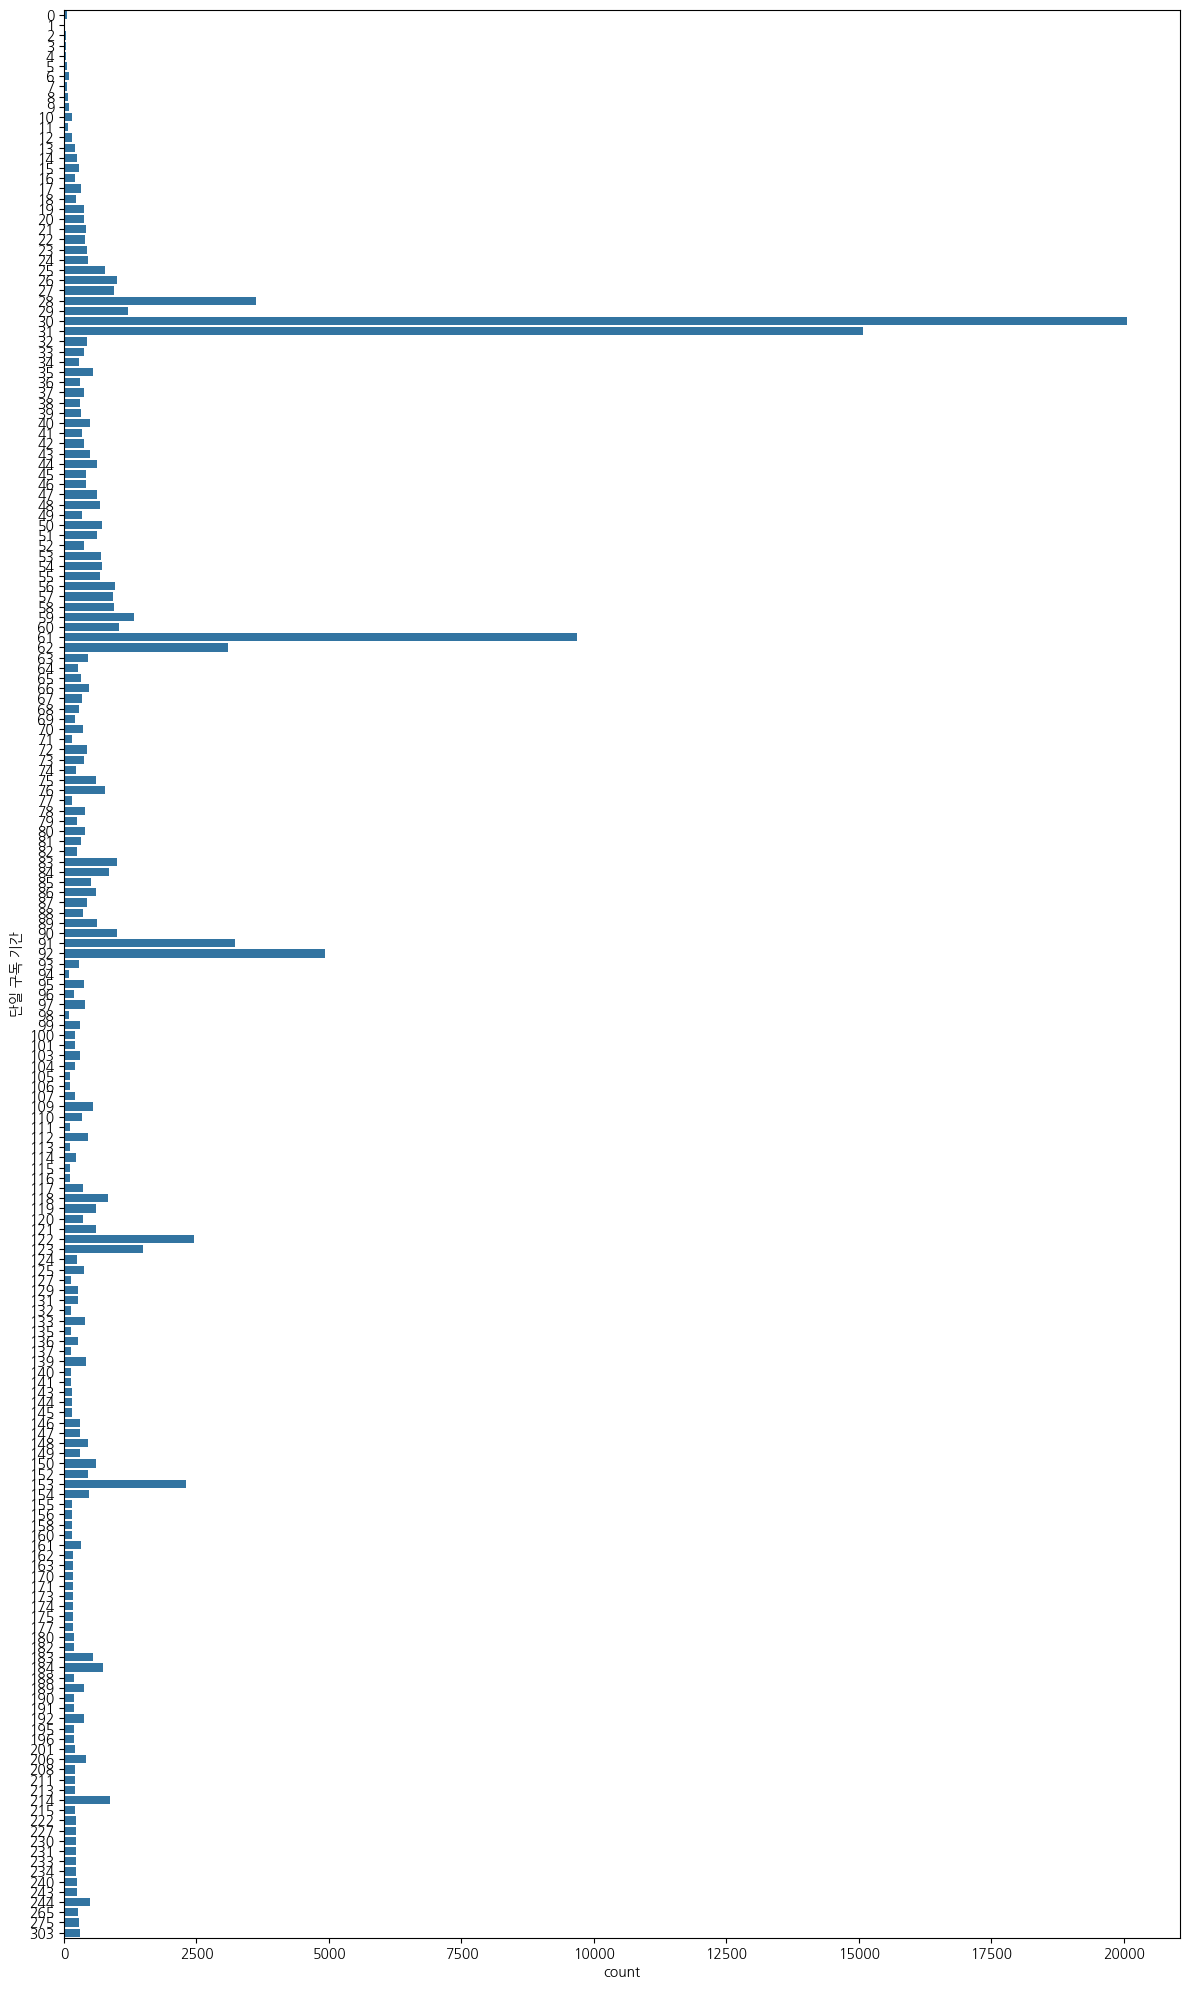

In [ ]:
fig, ax = plt.subplots(figsize=(12,20))
sns.countplot(data = daily_episode_1monthplan, y = '단일 구독 기간', orient="h")
plt.tight_layout()
plt.show()

구독 단위는 28~31일로 가는게 맞다.

In [ ]:
def categorize_day(day):
    if 0 <= day <= 31:
        return 1
    elif 32 <= day <= 62:
        return 2
    elif 63 <= day <= 92:
        return 3
    elif 93 <= day <= 123:
        return 4
    else:
        return None
    
# Apply the function to create a new column 'week_category'
daily_episode_1monthplan['category_total'] = daily_episode_1monthplan['last_day_since_first_watch'].apply(categorize_day)
daily_episode_1monthplan['개월기간'] = daily_episode_1monthplan['day_since_first_watch'].apply(categorize_day)

In [ ]:
daily_episode_1monthplan

,user_id,취소_후_재구독_횟수,day_since_first_watch,view_count,last_day_since_first_watch,단일 구독 기간,category_unit,category_total,개월기간
0,0000572f2ba8079bcefd2760b632e820,0,0,0,92,92,three,three,1.0
1,0000572f2ba8079bcefd2760b632e820,0,1,0,92,92,three,three,1.0
2,0000572f2ba8079bcefd2760b632e820,0,2,0,92,92,three,three,1.0
3,0000572f2ba8079bcefd2760b632e820,0,3,0,92,92,three,three,1.0
4,0000572f2ba8079bcefd2760b632e820,0,4,0,92,92,three,three,1.0
...,...,...,...,...,...,...,...,...,...
129422,fffe529de03d6187ef7ed765650c8d2b,0,83,0,87,87,None,None,3.0
129423,fffe529de03d6187ef7ed765650c8d2b,0,84,0,87,87,None,None,3.0
129424,fffe529de03d6187ef7ed765650c8d2b,0,85,0,87,87,None,None,3.0
129425,fffe529de03d6187ef7ed765650c8d2b,0,86,0,87,87,None,None,3.0


In [ ]:
# 첫 1개월 데이터 추출
daily_episode_1monthplan_31 = daily_episode_1monthplan[daily_episode_1monthplan['day_since_first_watch'] <= 31]

In [ ]:
# 열람 횟수가 0인 데이터 추출
view_count_zero_counts_31 = daily_episode_1monthplan_31[daily_episode_1monthplan_31['view_count'] == 0].groupby(['user_id','취소_후_재구독_횟수']).size().reset_index(name='view_count_zero_times')
# 구독 기간에 따른 집단 정보 추출
user_category = daily_episode_1monthplan_31[['user_id', 'category_unit']].drop_duplicates().set_index('user_id')

# 열람 횟수가 0인 데이터에 집단 정보 투입
view_count_zero_counts_31 = view_count_zero_counts_31.merge(user_category, on='user_id', how='left')

In [ ]:
daily_episode_1monthplan_62 = daily_episode_1monthplan[(daily_episode_1monthplan['day_since_first_watch'] <= 62) & (daily_episode_1monthplan['day_since_first_watch'] >= 32)]

In [ ]:
view_count_zero_counts_62 = daily_episode_1monthplan_62[daily_episode_1monthplan_62['view_count'] == 0].groupby(['user_id','취소_후_재구독_횟수']).size().reset_index(name='view_count_zero_times')
# 구독 기간에 따른 집단 정보 투입
user_category = daily_episode_1monthplan_62[['user_id', 'category_unit']].drop_duplicates().set_index('user_id')

# 열람 횟수가 0인 데이터에 집단 정보 투입
view_count_zero_counts_62 = view_count_zero_counts_62.merge(user_category, on='user_id', how='left')

In [ ]:
view_count_zero_counts_62

,user_id,취소_후_재구독_횟수,view_count_zero_times,category_unit
0,0000572f2ba8079bcefd2760b632e820,0,31,three
1,003dc1089ee8075dfe8aab161efc6188,0,31,two
2,004cf75983af1fead9ecf6815b5da6ce,0,5,two
3,004cf75983af1fead9ecf6815b5da6ce,2,24,two
4,0052fcc7e62a04f47a1b23c3488d31a0,0,28,three
...,...,...,...,...
1810,ff808a62645495d61a53ebecef59c834,0,15,two
1811,ff91a7edbe5caa0cf8045e182a28c65b,1,31,four
1812,ff981a0f1f704b60de77fadb1fec86a9,0,24,three
1813,ff9bb243eff83d84e2cb289ff629aba8,1,12,two


In [ ]:
daily_episode_1monthplan_93 = daily_episode_1monthplan[(daily_episode_1monthplan['day_since_first_watch'] <= 93) & (daily_episode_1monthplan['day_since_first_watch'] >= 63)]

view_count_zero_counts_93 = daily_episode_1monthplan_93[daily_episode_1monthplan_93['view_count'] == 0].groupby(['user_id','취소_후_재구독_횟수']).size().reset_index(name='view_count_zero_times')
# 구독 기간에 따른 집단 정보 투입
user_category = daily_episode_1monthplan_93[['user_id', 'category_unit']].drop_duplicates().set_index('user_id')

# 열람 횟수가 0인 데이터에 집단 정보 투입
view_count_zero_counts_93 = view_count_zero_counts_93.merge(user_category, on='user_id', how='left')

In [ ]:
view_count_zero_counts_93

,user_id,취소_후_재구독_횟수,view_count_zero_times,category_unit
0,0000572f2ba8079bcefd2760b632e820,0,31,three
1,0052fcc7e62a04f47a1b23c3488d31a0,0,25,three
2,0299fcf654e9d1229f3506b3c602c547,0,25,long
3,02bc3350b7574d047ef5e0ea57ddd88a,0,31,long
4,02e91332e38f0d9216355aad4203acc7,0,7,three
...,...,...,...,...
580,fe5783bba93504cb37c157fe8561f406,1,11,three
581,fea051ca4ae4c3dee4c4b13216ff9adc,0,31,long
582,ff91a7edbe5caa0cf8045e182a28c65b,1,31,four
583,ff981a0f1f704b60de77fadb1fec86a9,0,1,three


In [ ]:
daily_episode_1monthplan_124 = daily_episode_1monthplan[(daily_episode_1monthplan['day_since_first_watch'] > 93) & (daily_episode_1monthplan['day_since_first_watch'] <= 124)]

In [ ]:
view_count_zero_counts_124 = daily_episode_1monthplan_124[daily_episode_1monthplan_124['view_count'] == 0].groupby(['user_id','취소_후_재구독_횟수']).size().reset_index(name='view_count_zero_times')
# 구독 기간에 따른 집단 정보 투입
user_category = daily_episode_1monthplan_124[['user_id', 'category_unit']].drop_duplicates().set_index('user_id')

# 열람 횟수가 0인 데이터에 집단 정보 투입
view_count_zero_counts_124 = view_count_zero_counts_124.merge(user_category, on='user_id', how='left')

In [ ]:
view_count_zero_counts_124.groupby('category_unit')['view_count_zero_times'].mean()

category_unit
four    20.101695
long    28.823077
Name: view_count_zero_times, dtype: float64

In [ ]:
from scipy.stats import shapiro

In [ ]:
m1_group1 = view_count_zero_counts_31[view_count_zero_counts_31['category_unit'] == 'one']['view_count_zero_times']
m1_group2 = view_count_zero_counts_31[view_count_zero_counts_31['category_unit'] == 'two']['view_count_zero_times']
m1_group3 = view_count_zero_counts_31[view_count_zero_counts_31['category_unit'] == 'three']['view_count_zero_times']

<Axes: xlabel='view_count_zero_times', ylabel='Count'>

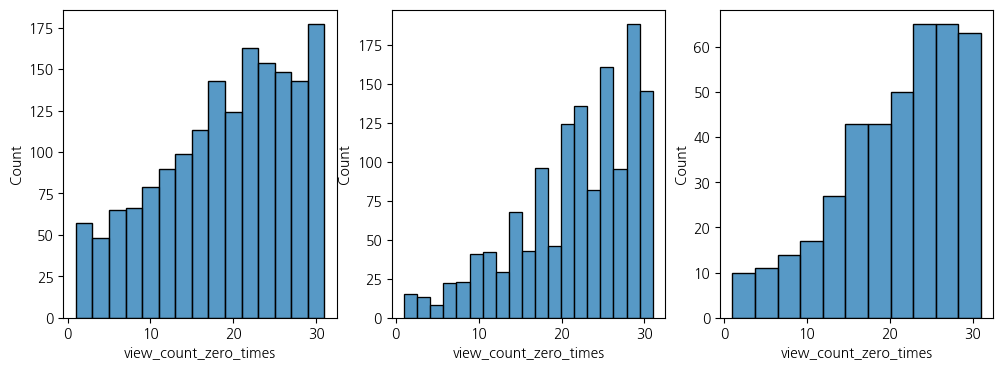

In [ ]:
group1_df = m1_group1.to_frame(name='view_count_zero_times')
group2_df = m1_group2.to_frame(name='view_count_zero_times')
group3_df = m1_group3.to_frame(name='view_count_zero_times')

fig, ax = plt.subplots(1,3, figsize = (12,4))
sns.histplot(data = group1_df, x = 'view_count_zero_times', ax = ax[0])
sns.histplot(data = group2_df, x = 'view_count_zero_times', ax = ax[1])
sns.histplot(data = group3_df, x = 'view_count_zero_times', ax = ax[2])

In [ ]:
# 로그 변환
tf_group1 = np.log(m1_group1 + 1)
tf_group2 = np.log(m1_group2 + 1)
tf_group3 = np.log(m1_group3 + 1)


<Axes: xlabel='view_count_zero_times', ylabel='Count'>

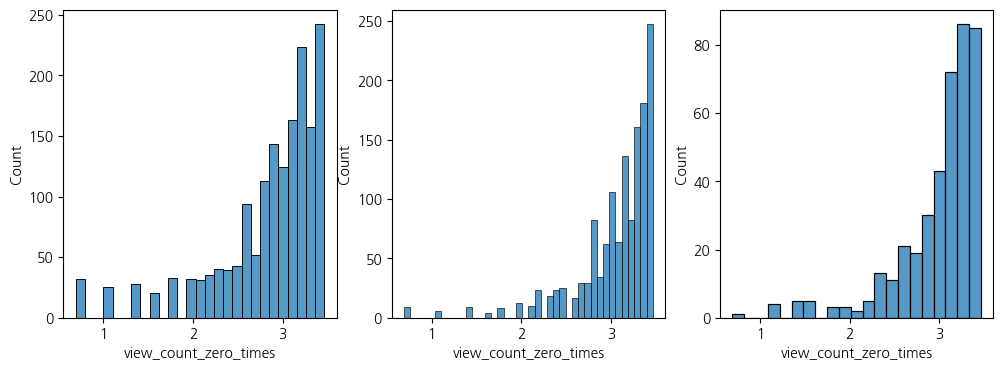

In [ ]:
group1_df = pd.DataFrame(tf_group1, columns=['view_count_zero_times'])
group2_df = pd.DataFrame(tf_group2, columns=['view_count_zero_times'])
group3_df = pd.DataFrame(tf_group3, columns=['view_count_zero_times'])


fig, ax = plt.subplots(1,3, figsize = (12,4))
sns.histplot(data = group1_df, x = 'view_count_zero_times', ax = ax[0])
sns.histplot(data = group2_df, x = 'view_count_zero_times', ax = ax[1])
sns.histplot(data = group3_df, x = 'view_count_zero_times', ax = ax[2])

In [ ]:
from scipy.stats import levene
stat, p_value = levene(tf_group1, tf_group2, tf_group3)
print("Levene's Test p-value:", p_value)

Levene's Test p-value: 1.8794332248283134e-17


ANOVA의 전제 조건을 충족하지 못한다. 그러므로 Welch's ANOVA를 실시한다.

### Welch's ANOVA

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Welch's ANOVA 수행
model = ols('view_count_zero_times ~ C(category_unit)', data=view_count_zero_counts_31).fit()
welch_anova = sm.stats.anova_lm(model, typ=2, robust='hc3')  # HC3 보정
print(welch_anova)

                         sum_sq      df          F        PR(>F)
C(category_unit)    8299.292369     4.0  36.720655  3.726646e-30
Residual          211038.289256  3735.0        NaN           NaN


### Games-Howell Test (사후검정)

In [ ]:
# !pip install pingouin

In [ ]:
import pingouin as pg
# Welch’s ANOVA를 수행한 후 사후 Games-Howell test
welch_anova = pg.welch_anova(dv='view_count_zero_times', between='category_unit', data=view_count_zero_counts_31)
games_howell = pg.pairwise_gameshowell(dv='view_count_zero_times', between='category_unit', data=view_count_zero_counts_31)

print("Welch's ANOVA 결과:\n", welch_anova)
print("\nGames-Howell Test 결과:\n", games_howell)

Welch's ANOVA 결과:
           Source  ddof1       ddof2          F         p-unc       np2
0  category_unit      4  519.028277  36.618647  5.590454e-27  0.038529

Games-Howell Test 결과:
        A      B    mean(A)    mean(B)      diff        se          T  \
0   four   long  21.604317  21.857143 -0.252826  0.876938  -0.288306   
1   four    one  21.604317  18.554823  3.049493  0.631600   4.828201   
2   four  three  21.604317  20.796569  0.807748  0.698908   1.155729   
3   four    two  21.604317  21.704430 -0.100113  0.628827  -0.159206   
4   long    one  21.857143  18.554823  3.302320  0.668837   4.937404   
5   long  three  21.857143  20.796569  1.060574  0.732732   1.447424   
6   long    two  21.857143  21.704430  0.152713  0.666219   0.229223   
7    one  three  18.554823  20.796569 -2.241745  0.408406  -5.489017   
8    one    two  18.554823  21.704430 -3.149607  0.271563 -11.598055   
9  three    two  20.796569  21.704430 -0.907861  0.404104  -2.246602   

            df        

### 31~60일

#### 전제 조건 확인

In [ ]:
m2_group2 = view_count_zero_counts_62[view_count_zero_counts_62['category_unit'] == 'two']['view_count_zero_times']
m2_group3 = view_count_zero_counts_62[view_count_zero_counts_62['category_unit'] == 'three']['view_count_zero_times']

<Axes: xlabel='view_count_zero_times', ylabel='Count'>

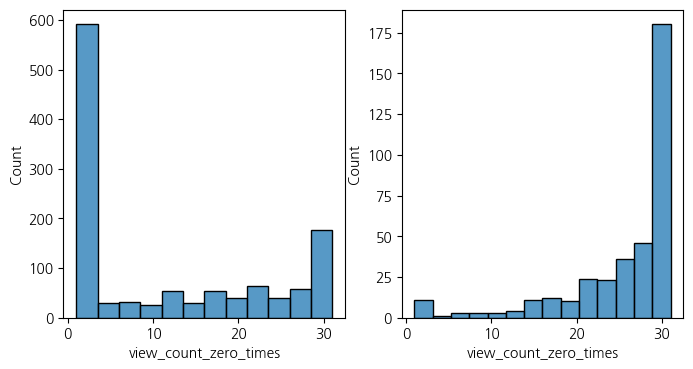

In [ ]:
group2_df = m2_group2.to_frame(name='view_count_zero_times')
group3_df = m2_group3.to_frame(name='view_count_zero_times')


fig, ax = plt.subplots(1,2, figsize = (8,4))
sns.histplot(data = group2_df, x = 'view_count_zero_times', ax = ax[0])
sns.histplot(data = group3_df, x = 'view_count_zero_times', ax = ax[1])

Welch's T-test 실시

### Welch's T-test

In [ ]:
from scipy.stats import ttest_ind
# Welch’s t-test 수행
stat, p_value = ttest_ind(m2_group2, m2_group3, equal_var=False)
print("Welch’s t-test p-value:", p_value)

Welch’s t-test p-value: 9.844315901943545e-137


결론: 모든 집단에서 구독 마지막 달일 때 에피소드 0회 시청일이 감소한다.

## 집단내 비교

In [ ]:
# 2개월 구독 집단
group2_m1 = view_count_zero_counts_31[view_count_zero_counts_31['category_unit'] == 'two']
group2_m2 = view_count_zero_counts_62[view_count_zero_counts_62['category_unit'] == 'two']
group2_m1['month'] = 1
group2_m2['month'] = 2

group2_m1m2 = pd.concat([group2_m1,group2_m2], axis = 0)
group2_m1m2

C:\Users\csh94\AppData\Local\Temp\ipykernel_15624\2108525057.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group2_m1['month'] = 1
C:\Users\csh94\AppData\Local\Temp\ipykernel_15624\2108525057.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group2_m2['month'] = 2


,user_id,취소_후_재구독_횟수,view_count_zero_times,category_unit,month
3,003dc1089ee8075dfe8aab161efc6188,0,29,two,1
4,004cf75983af1fead9ecf6815b5da6ce,0,10,two,1
6,004cf75983af1fead9ecf6815b5da6ce,1,24,two,1
8,004cf75983af1fead9ecf6815b5da6ce,2,24,two,1
11,00a7b3a5ea60548d46a659dd4ae4e364,0,20,two,1
...,...,...,...,...,...
1807,ff27c0ef4f7c2c87a09e295c496727f5,0,13,two,2
1808,ff3ca197929cc396e587a7eb4816e11e,0,1,two,2
1809,ff76cc0252c95909dfe7a96b1010693d,0,1,two,2
1810,ff808a62645495d61a53ebecef59c834,0,15,two,2


In [ ]:
group2_m1m2.groupby('month')['view_count_zero_times'].mean()

month
1    21.704430
2    11.148865
Name: view_count_zero_times, dtype: float64

In [ ]:
# Welch’s t-test 수행 - 2개월 집단
stat, p_value = ttest_ind(m1_group2, m2_group2, equal_var=False)
print("Welch’s t-test p-value:", p_value)

Welch’s t-test p-value: 9.844315901943545e-137


In [ ]:
# 3개월 집단
group3_m1 = view_count_zero_counts_31[view_count_zero_counts_31['category_unit'] == 'three']
group3_m2 = view_count_zero_counts_62[view_count_zero_counts_62['category_unit'] == 'three']
group3_m3 = view_count_zero_counts_93[view_count_zero_counts_93['category_unit'] == 'three']
group3_m1['month'] = 1
group3_m2['month'] = 2
group3_m3['month'] = 3

group3_m1m2m3 = pd.concat([group3_m1,group3_m2,group3_m3], axis = 0)
group3_m1m2m3

C:\Users\csh94\AppData\Local\Temp\ipykernel_15624\3613933196.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group3_m1['month'] = 1
C:\Users\csh94\AppData\Local\Temp\ipykernel_15624\3613933196.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group3_m2['month'] = 2
C:\Users\csh94\AppData\Local\Temp\ipykernel_15624\3613933196.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

,user_id,취소_후_재구독_횟수,view_count_zero_times,category_unit,month
0,0000572f2ba8079bcefd2760b632e820,0,26,three,1
10,0052fcc7e62a04f47a1b23c3488d31a0,0,22,three,1
32,02e91332e38f0d9216355aad4203acc7,0,29,three,1
46,03f47d2d11c9d1d865e7f4bfa516adea,0,28,three,1
49,0443b29c8c70fbf6bbf58f1a04f53335,0,24,three,1
...,...,...,...,...,...
578,fe005d6bb53bd18f7d9e5bcb3522211b,0,20,three,3
579,fe449a104db91a29a83689a7ed26f7d4,1,1,three,3
580,fe5783bba93504cb37c157fe8561f406,1,11,three,3
583,ff981a0f1f704b60de77fadb1fec86a9,0,1,three,3


In [ ]:
# Welch’s ANOVA를 수행한 후 사후 Games-Howell test
welch_anova = pg.welch_anova(dv='view_count_zero_times', between='month', data=group3_m1m2m3)
games_howell = pg.pairwise_gameshowell(dv='view_count_zero_times', between='month', data=group3_m1m2m3)

print("Welch's ANOVA 결과:\n", welch_anova)
print("\nGames-Howell Test 결과:\n", games_howell)

Welch's ANOVA 결과:
   Source  ddof1       ddof2           F         p-unc       np2
0  month      2  690.675018  100.134759  6.510906e-39  0.160645

Games-Howell Test 결과:
    A  B    mean(A)    mean(B)      diff        se          T          df  \
0  1  2  20.796569  25.670300 -4.873731  0.511855  -9.521706  768.710767   
1  1  3  20.796569  16.350148  4.446420  0.698323   6.367285  559.589761   
2  2  3  25.670300  16.350148  9.320151  0.702354  13.269874  561.312578   

           pval    hedges  
0  0.000000e+00 -0.683217  
1  1.203844e-09  0.486306  
2  0.000000e+00  1.018317  


3개월 집단에서는 모든 개월마다 유의미한 차이가 있었다.

In [ ]:
# 4개월 집단
group4_m1 = view_count_zero_counts_31[view_count_zero_counts_31['category_unit'] == 'four']
group4_m2 = view_count_zero_counts_62[view_count_zero_counts_62['category_unit'] == 'four']
group4_m3 = view_count_zero_counts_93[view_count_zero_counts_93['category_unit'] == 'four']
group4_m4 = view_count_zero_counts_124[view_count_zero_counts_124['category_unit'] == 'four']

group4_m1['month'] = 1
group4_m2['month'] = 2
group4_m3['month'] = 3
group4_m4['month'] = 4

C:\Users\csh94\AppData\Local\Temp\ipykernel_15624\1644445877.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group4_m1['month'] = 1
C:\Users\csh94\AppData\Local\Temp\ipykernel_15624\1644445877.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group4_m2['month'] = 2
C:\Users\csh94\AppData\Local\Temp\ipykernel_15624\1644445877.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

In [ ]:
group4_m1m2m3m4 = pd.concat([group4_m1,group4_m2,group4_m3,group4_m4], axis = 0)

In [ ]:
# Welch’s ANOVA를 수행한 후 사후 Games-Howell test
welch_anova = pg.welch_anova(dv='view_count_zero_times', between='month', data=group4_m1m2m3m4)
games_howell = pg.pairwise_gameshowell(dv='view_count_zero_times', between='month', data=group4_m1m2m3m4)

print("Welch's ANOVA 결과:\n", welch_anova)
print("\nGames-Howell Test 결과:\n", games_howell)

Welch's ANOVA 결과:
   Source  ddof1       ddof2          F         p-unc       np2
0  month      3  270.441448  30.791647  3.721316e-17  0.148151

Games-Howell Test 결과:
    A  B    mean(A)    mean(B)      diff        se         T          df  \
0  1  2  21.604317  25.790323 -4.186006  0.848543 -4.933171  260.161505   
1  1  3  21.604317  27.655462 -6.051146  0.785233 -7.706174  253.905299   
2  1  4  21.604317  20.101695  1.502622  1.045504  1.437222  216.055676   
3  2  3  25.790323  27.655462 -1.865140  0.784869 -2.376369  235.889482   
4  2  4  25.790323  20.101695  5.688628  1.045231  5.442460  211.568995   
5  3  4  27.655462  20.101695  7.553767  0.994522  7.595371  190.097703   

           pval    hedges  
0  8.581442e-06 -0.605616  
1  1.744493e-12 -0.941626  
2  4.775658e-01  0.183340  
3  8.447158e-02 -0.302825  
4  8.642162e-07  0.703305  
5  8.134826e-12  0.985597  


각 집단의 데이터가 정규성과 등분산성을 만족하지 않기에 비모수적 검정 방법 중 하나인 Welch’s ANOVA와 Welch’s Ttest를 실시했다.

먼저 동일 기간에 서로 다른 집단들을 분석한 결과, 집단 간 차이가 유의미한 것으로 밝혀졌으며 Games-Howell Test를 통해 모든 집단은 각 집단의 구독 마지막 달(1개월 집단 → 1개월차, 2개월 집단 → 2개월차, 3개월 집단 → 3개월차)에 약한 이탈 횟수가 다른 집단보다 유의미하게 감소했으며, 다른 집단들 사이에서는 유의미한 차이가 발견되지 않았다.

다음으로, 동일 집단 내 구독 기간별 약한 이탈 횟수를 비교했다. Welch’s ANOVA 분석 결과, 구독 기간별 비교를 할 수 있는 2~4개월 집단 전체에서 구독 기간이 늘어날수록 약한 이탈 횟수가 증가하다가 구독 마지막 달에 감소하는 패턴을 보였다.

위 결과는 총 구독 기간에 따라 월별 약한 이탈 횟수가 다를 것이라는 점에서 의미가 있지만 약한 이탈이 감소하는 방향으로 나타나 분석가들의 가설과 달랐다.

## 문제점
1. 유저들의 실제 구독 기간을 일단위로 하지 않고 개월 단위로 묶어버린 시점에서, 약한 이탈을 단순히 빈도값으로 계산하게 되면 구독 마지막 달의 중간에 구독을 해지한 사람은 마지막 날까지 약한 이탈이 계속 발생한 것으로 계산된다.
    
    예) 66일을 구독하고 취소한 사람은 3개월 집단에 소속되어 67일부터 93일까지 에피소드를 열람하지 않은 것으로 판단, 약한 이탈로 집계되었다.
2. 즉, 구독 마지막 달의 약한 이탈 빈도가 월말에 가까워지면서 더 커져 실제 결과를 왜곡한다는 것이다.


In [ ]:
view_count_zero_counts_31 = daily_episode_1monthplan[daily_episode_1monthplan['view_count'] == 0].groupby(['category','day_since_first_watch']).size().reset_index(name='view_count_zero_times')

In [ ]:
view_count_zero_counts_31

,category,day_since_first_watch,view_count_zero_times
0,1개월 구독,1,302
1,1개월 구독,2,533
2,1개월 구독,3,576
3,1개월 구독,4,599
4,1개월 구독,5,552
...,...,...,...
922,long,613,1
923,long,614,1
924,long,615,1
925,long,616,1


Text(0.5, 1.0, '일별 약한이탈 빈도')

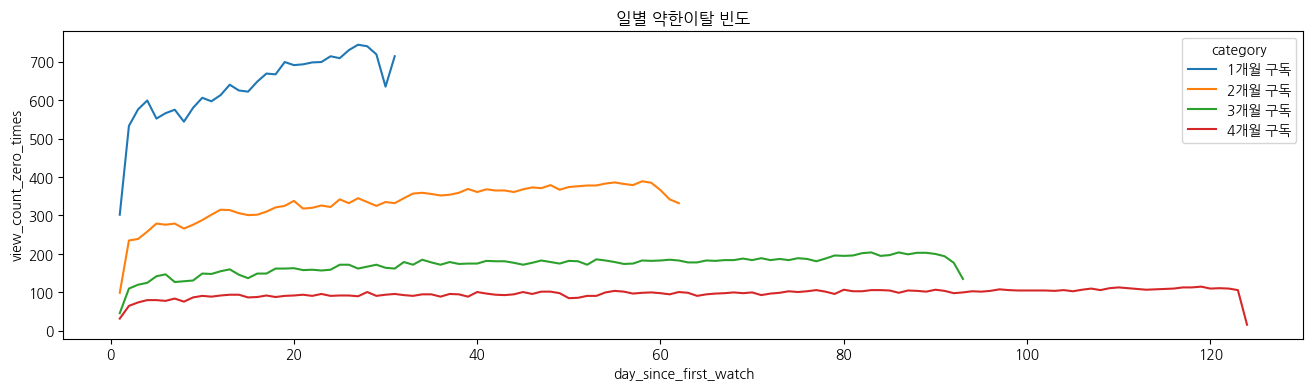

In [ ]:
fig, ax = plt.subplots(figsize=(16,4))
sns.lineplot(data = view_count_zero_counts_31[view_count_zero_counts_31['category'] != 'long'], x = 'day_since_first_watch', y = 'view_count_zero_times', hue = 'category')
plt.title('일별 약한이탈 빈도')

In [ ]:
# 1개월 구독 집단
group_1 = daily_episode_1monthplan[daily_episode_1monthplan['category_unit'] == 'one']
group_1['weak_churn'] = group_1['view_count'] == 0
group_1_weak_churn_rate =group_1.groupby('day_since_first_watch')['weak_churn'].mean().reset_index(name='weak_churn_rate')

# 2개월 구독 집단
group_2 = daily_episode_1monthplan[daily_episode_1monthplan['category_unit'] == 'two']
group_2['weak_churn'] = group_2['view_count'] == 0
group_2_weak_churn_rate =group_2.groupby('day_since_first_watch')['weak_churn'].mean().reset_index(name='weak_churn_rate')

# 3개월 구독 집단
group_3 = daily_episode_1monthplan[daily_episode_1monthplan['category_unit'] == 'three']
group_3['weak_churn'] = group_3['view_count'] == 0
group_3_weak_churn_rate =group_3.groupby('day_since_first_watch')['weak_churn'].mean().reset_index(name='weak_churn_rate')

# 4개월 구독 집단
group_4 = daily_episode_1monthplan[daily_episode_1monthplan['category_unit'] == 'four']
group_4['weak_churn'] = group_1['view_count'] == 0
group_4_weak_churn_rate =group_4.groupby('day_since_first_watch')['weak_churn'].mean().reset_index(name='weak_churn_rate')


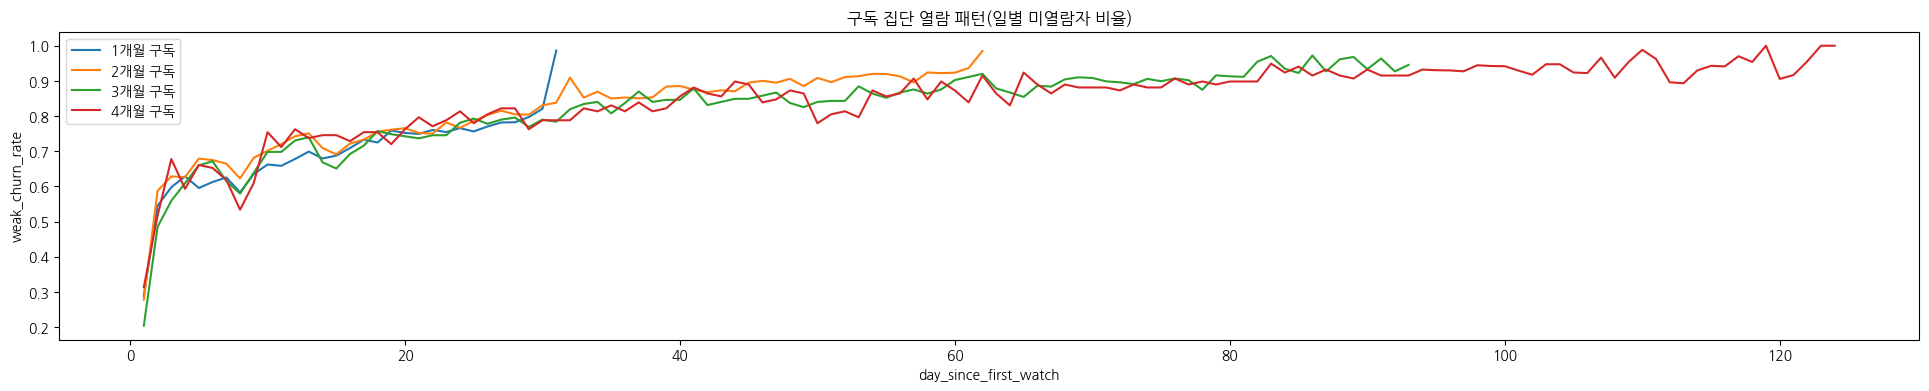

In [ ]:
fig, ax = plt.subplots(figsize=(24,4))
sns.lineplot(data = group_1_weak_churn_rate, x = 'day_since_first_watch', y = 'weak_churn_rate', label = '1개월 구독')
sns.lineplot(data = group_2_weak_churn_rate, x = 'day_since_first_watch', y = 'weak_churn_rate', label = '2개월 구독')
sns.lineplot(data = group_3_weak_churn_rate, x = 'day_since_first_watch', y = 'weak_churn_rate', label = '3개월 구독')
sns.lineplot(data = group_4_weak_churn_rate, x = 'day_since_first_watch', y = 'weak_churn_rate', label = '4개월 구독')

plt.title('구독 집단 열람 패턴(일별 미열람자 비율)')
plt.show()

이 문제점을 해결하기 위해 약한 이탈을 단순히 빈도로 계산하는 것이 아닌, 비율로 계산하고 분석을 진행하기로 했다.

# 분석2. 약한 이탈 비율 기반 ANOVA 분석

빈도의 문제점을 확인한 후, 약한 이탈률을 '에피소드 미열람일 / 구독기간'으로 정의했다.

구독 기간은 1개월 단위로도 볼 수 있고, 전체 구독 기간을 볼 수도 있어 구간에 맞는 약한 이탈률을 계산할 수 있다.

구독 마지막 달과 그 이전 기간의 약한 이탈 패턴을 파악하기 위해 ‘구독 마지막 달의 약한 이탈률이 다른 기간의 약한 이탈률보다 많을 것이다.’라는 가설을 세웠으며, ANOVA 분석을 통해 가설을 검정했다.

## 데이터셋 구성

In [ ]:
daily_episode_1monthplan['weak_churn_day'] = daily_episode_1monthplan['view_count'] == 0

In [ ]:
# 1. 집단별 특정 기간(개월) 이탈률 비교
weak_churn_rate_day = daily_episode_1monthplan.groupby(['day_since_first_watch','category_unit','개월기간'])['weak_churn_day'].mean().reset_index(name='weak_churn_day_rate')
weak_churn_rate_day

,day_since_first_watch,category_unit,개월기간,weak_churn_day_rate
0,0,four,1.0,0.275000
1,0,one,1.0,0.289166
2,0,three,1.0,0.132075
3,0,two,1.0,0.168033
4,1,four,1.0,0.500000
...,...,...,...,...
307,119,four,4.0,0.950000
308,120,four,4.0,0.925000
309,121,four,4.0,1.000000
310,122,four,4.0,1.000000


## Welch's ANOVA & Welch's Ttest

### 1. 집단별 특정 기간(개월) 이탈률 비교

In [ ]:
# 구간 나누기(~1개월, ~2개월, ~3개월)
sector1 = weak_churn_rate_day[weak_churn_rate_day['개월기간'] == 1]
sector2 = weak_churn_rate_day[weak_churn_rate_day['개월기간'] == 2]
sector3 = weak_churn_rate_day[weak_churn_rate_day['개월기간'] == 3]
sector4 = weak_churn_rate_day[weak_churn_rate_day['개월기간'] == 4]

In [ ]:
# 정규성 검정
stat, p_value = shapiro(sector1['weak_churn_day_rate'])
print(f"Shapiro-Wilk 검정 통계량: {stat}")
print(f"p-값: {p_value}")

# 결과 해석
if p_value < 0.05:
    print("데이터는 정규성을 따르지 않습니다.")
else:
    print("데이터는 정규성을 따릅니다.")

Shapiro-Wilk 검정 통계량: 0.851190580272833
p-값: 5.08799428964575e-10
데이터는 정규성을 따르지 않습니다.


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Welch's ANOVA 수행 -1개월차
model = ols('weak_churn_day_rate ~ C(category_unit)', data=sector1).fit()
welch_anova = sm.stats.anova_lm(model, typ=2, robust='hc3')  # HC3 보정
print(welch_anova)

                    sum_sq     df         F    PR(>F)
C(category_unit)  0.040218    3.0  0.873947  0.456628
Residual          1.902099  124.0       NaN       NaN


In [ ]:
import pingouin as pg 

# Welch’s ANOVA를 수행한 후 사후 Games-Howell test - 1개월차
welch_anova = pg.welch_anova(dv='weak_churn_day_rate', between='category_unit', data=sector1)
games_howell = pg.pairwise_gameshowell(dv='weak_churn_day_rate', between='category_unit', data=sector1)

print("Welch's ANOVA 결과:\n", welch_anova)
print("\nGames-Howell Test 결과:\n", games_howell)

Welch's ANOVA 결과:
           Source  ddof1      ddof2         F     p-unc       np2
0  category_unit      3  68.742837  0.884974  0.453348  0.023734

Games-Howell Test 결과:
        A      B   mean(A)   mean(B)      diff        se         T         df  \
0   four    one  0.703125  0.691208  0.011917  0.028889  0.412494  61.829085   
1   four  three  0.703125  0.669811  0.033314  0.030877  1.078914  60.245660   
2   four    two  0.703125  0.722208 -0.019083  0.030334 -0.629091  60.796478   
3    one  three  0.691208  0.669811  0.021397  0.031580  0.677561  61.132307   
4    one    two  0.691208  0.722208 -0.031000  0.031049 -0.998405  61.515167   
5  three    two  0.669811  0.722208 -0.052397  0.032907 -1.592275  61.941682   

       pval    hedges  
0  0.976124  0.101871  
1  0.703624  0.266452  
2  0.922298 -0.155363  
3  0.905211  0.167333  
4  0.750857 -0.246570  
5  0.390478 -0.393234  


In [ ]:
# Welch's ANOVA 수행 - 2개월차
model = ols('weak_churn_day_rate ~ C(category_unit)', data=sector2).fit()
welch_anova = sm.stats.anova_lm(model, typ=2, robust='hc3')  # HC3 보정
print(welch_anova)

                    sum_sq    df          F        PR(>F)
C(category_unit)  0.203807   2.0  53.247278  5.497172e-16
Residual          0.172240  90.0        NaN           NaN


In [ ]:
# Welch’s ANOVA를 수행한 후 사후 Games-Howell test - 2개월차
welch_anova = pg.welch_anova(dv='weak_churn_day_rate', between='category_unit', data=sector2)
games_howell = pg.pairwise_gameshowell(dv='weak_churn_day_rate', between='category_unit', data=sector2)

print("Welch's ANOVA 결과:\n", welch_anova)
print("\nGames-Howell Test 결과:\n", games_howell)

Welch's ANOVA 결과:
           Source  ddof1      ddof2          F         p-unc       np2
0  category_unit      2  56.678168  54.382523  6.542121e-14  0.504251

Games-Howell Test 결과:
        A      B   mean(A)   mean(B)      diff        se         T         df  \
0   four  three  0.794355  0.833536 -0.039181  0.012456 -3.145590  43.199303   
1   four    two  0.794355  0.899536 -0.105181  0.012490 -8.421049  43.545087   
2  three    two  0.833536  0.899536 -0.066000  0.007697 -8.574271  59.987486   

           pval    hedges  
0  8.262230e-03 -0.788952  
1  3.278079e-10 -2.112100  
2  1.553158e-11 -2.150530  


In [ ]:
# 3개월차 비교 - Welch's Ttest

from scipy.stats import ttest_ind

# Welch’s t-test 수행
stat, p_value = ttest_ind(sector3[sector3['category_unit'] == 'three']['weak_churn_day_rate'], sector3[sector3['category_unit'] == 'four']['weak_churn_day_rate'], equal_var=False)
print("Welch's t-test t-score:",stat)
print("Welch’s t-test p-value:", p_value)

Welch's t-test t-score: 3.287857994992332
Welch’s t-test p-value: 0.0017287412483947898


In [ ]:
# Welch's ANOVA 수행 - 3개월차
model = ols('weak_churn_day_rate ~ C(category_unit)', data=sector3).fit()
welch_anova = sm.stats.anova_lm(model, typ=2, robust='hc3')  # HC3 보정
print(welch_anova)


                    sum_sq    df          F    PR(>F)
C(category_unit)  0.024639   1.0  10.449677  0.002025
Residual          0.136756  58.0        NaN       NaN


In [ ]:
# Welch’s ANOVA를 수행한 후 사후 Games-Howell test - 3개월차
welch_anova = pg.welch_anova(dv='weak_churn_day_rate', between='category_unit', data=sector3)
games_howell = pg.pairwise_gameshowell(dv='weak_churn_day_rate', between='category_unit', data=sector3)

print("Welch's ANOVA 결과:\n", welch_anova)
print("\nGames-Howell Test 결과:\n", games_howell)


Welch's ANOVA 결과:
           Source  ddof1      ddof2         F     p-unc       np2
0  category_unit      1  57.257141  10.81001  0.001729  0.157099

Games-Howell Test 결과:
       A      B   mean(A)   mean(B)      diff        se         T         df  \
0  four  three  0.856667  0.897888 -0.041222  0.012538 -3.287858  57.257141   

       pval    hedges  
0  0.001729 -0.837896  


### 2. 집단 내 비교

In [ ]:
from scipy.stats import ttest_ind
# Welch’s t-test 수행
stat, p_value = ttest_ind(group2[group2['개월기간'] == 1]['weak_churn_day_rate'], group2[group2['개월기간'] == 2]['weak_churn_day_rate'], equal_var=False)
print("Welch's t-test t-score:",stat)
print("Welch’s t-test p-value:", p_value)

Welch's t-test t-score: -7.52804613725942
Welch’s t-test p-value: 8.773426227514342e-09


In [ ]:
# Performing Welch's ANOVA
welch_anova = pg.welch_anova(data=weak_churn_rate_day[weak_churn_rate_day['category_unit'] == 'three'], dv='weak_churn_day_rate', between='개월기간')

# Performing Games-Howell post-hoc test for pairwise comparison
games_howell = pg.pairwise_gameshowell(dv='weak_churn_day_rate', between='개월기간', data=weak_churn_rate_day[weak_churn_rate_day['category_unit'] == 'three'])

# Displaying the results
welch_anova, games_howell

(  Source  ddof1      ddof2          F         p-unc       np2
 0   개월기간      2  52.224564  49.176231  9.803521e-13  0.574053,
      A    B   mean(A)   mean(B)      diff        se         T         df  \
 0  1.0  2.0  0.669811  0.833536 -0.163725  0.024233 -6.756272  34.231930   
 1  1.0  3.0  0.669811  0.897888 -0.228077  0.025054 -9.103550  38.578086   
 2  2.0  3.0  0.833536  0.897888 -0.064352  0.009942 -6.472861  49.929829   
 
            pval    hedges  
 0  2.615302e-07 -1.657284  
 1  1.127458e-10 -2.226015  
 2  1.201575e-07 -1.647417  )

In [ ]:
# Performing Welch's ANOVA
welch_anova = pg.welch_anova(data=weak_churn_rate_day[weak_churn_rate_day['category_unit'] == 'four'], dv='weak_churn_day_rate', between='개월기간')

# Performing Games-Howell post-hoc test for pairwise comparison
games_howell = pg.pairwise_gameshowell(dv='weak_churn_day_rate', between='개월기간', data=weak_churn_rate_day[weak_churn_rate_day['category_unit'] == 'four'])

# Displaying the results
welch_anova, games_howell

(  Source  ddof1     ddof2          F         p-unc      np2
 0   개월기간      3  64.98101  53.490163  1.543589e-17  0.56492,
      A    B   mean(A)   mean(B)      diff        se          T         df  \
 0  1.0  2.0  0.703125  0.794355 -0.091230  0.022832  -3.995686  48.782516   
 1  1.0  3.0  0.703125  0.856667 -0.153542  0.021975  -6.987124  43.946057   
 2  1.0  4.0  0.703125  0.924194 -0.221069  0.021365 -10.346987  40.331964   
 3  2.0  3.0  0.794355  0.856667 -0.062312  0.014612  -4.264516  57.473725   
 4  2.0  4.0  0.794355  0.924194 -0.129839  0.013678  -9.492511  53.569584   
 5  3.0  4.0  0.856667  0.924194 -0.067527  0.012194  -5.537928  56.846625   
 
            pval    hedges  
 0  1.208935e-03 -0.986074  
 1  7.118033e-08 -1.716045  
 2  3.855471e-12 -2.544797  
 3  4.293649e-04 -1.074723  
 4  2.694511e-12 -2.380835  
 5  4.802343e-06 -1.403983  )

각 집단의 데이터가 정규성과 등분산성을 만족하지 않기에 비모수적 검정 방법 중 하나인 Welch’s ANOVA와 Games-Howell test를 진행했다.
동일 기간 집단 간 비교를 실시한 결과, 1~31일에서는 모든 집단에서 유의한 차이가 발견되지 않았다. 반면, 나머지 기간에서는 모든 집단의 약한 이탈률이 유의한 차이를 보였다.
    
위 결과를 통해 구독 첫 달, 구독 마지막 달, 구독 직전 달, 구독 중간 달로 패턴이 있을 수 있다고 판단해 동일 집단 내 구독 기간별 비교를 진행했다.

동일 집단 내 구독 기간별로 약한 이탈률을 비교한 결과, 모든 집단(2~4개월 집단)에서 구독 기간이 길어질수록 약한 이탈률이 유의한 수준으로  증가했다.

본 분석을 통해 알 수 있는 점은 모든 집단에서 구독 마지막 달이 되면 그렇지 않을 때보다 약한 이탈률이 높았다는 것이다.

구독 첫 달, 중간 달, 구독 종료 직전 달, 구독 종료 달의 패턴이 있을 것으로 보고 각 집단의 약한이탈 패턴을 살펴봤을 때 4개월 집단에서 모든 구간에 차이가 있어 가능성을 확인했다.

그러나, 1개월 집단에 비해 다른 집단의 표본 수가 적은 점, 5개월 가입자의 표본이 너무 적어 단순히 구독 기간이 증가하면서 약한 이탈률이 증가하는 것인지, 아니면 분석가들이 예상한 패턴이 나타나는지 비교할 수 없었다는 한계점이 있었다.

또한, 첫 1개월의 경우, 집단 간 차이가 발생하지 않았는데 이는 구독 첫 날에 많은 사람들이 에피소드를 열람한다는 특수성에 기인하는 것으로 판단되어 약한 이탈률이 첫 1개월 구독자들의 생존(다음 달에도 구독을 유지하는지 여부)에 영향을 미치는 지 알아보고자 한다.

# 분석 3. 첫 1개월 구독 단순 로지스틱 회귀분석(simple logistic regression)
1. 분석 목적
    1) 약한 이탈률이 유저들의 첫 1개월 이후 구독 지속 여부에 영향을 주는 지 탐색
2. 데이터셋 구성
    1) 모든 구독자들의 구독 정보와 에피소드 열람 데이터를 병합했다.
    2) 약한이탈률은 1 - (에피소드 열람일 / 첫 구독기간) 으로 계산했다.


## 데이터셋 구성

다른 변인들과 통합해서 분석할 가능성을 고려해 첫 구독 유지와 관련된 변인들을 선정하고 데이터셋을 구성했다.

1. 요금제: 본 데이터셋에서 요금제는 1개월 플랜, 3개월 플랜, 12개월 플랜 3가지가 존재한다. 3개월 이상의 장기 플랜은 1개월 플랜보다 구독 취소 등 이탈을 하는 데 있어 허들이 존재할 것으로 보고 투입했다. 실제로 각 요금제의 평균 생존 비율을 살펴보면 1개월(0.44)보다 장기 플랜(3개월: 0.87, 12개월: 0.88)이 높은 것으로 나타났다.
2. 취소 후 재구독 횟수: 취소 후 재구독 횟수는 유저가 이전에 구독을 했던 횟수를 카운트한 것이다. 같은 유저라도 제일 처음 구독을 했을 때와 취소 후 공백기를 거친 후 복귀를 했을 때 작용이 다르게 나타날 것으로 예상했다. 본 데이터셋에서 취소 후 재구독 횟수별 평균 생존 비율을 살펴보면 취소 후 재구독 횟수가 늘어날수록 1개월 이상 사용하는 비율이 낮아졌다.(0회:0.61 ~ 3회 0.33)
3. 무료체험 여부: 경험재를 판매하는 기업에서 무료 체험을 경험한 고객은 그렇지 않은 고객보다 유료 구독 전환율과 초기 구독 유지율이 높다(하버드 비즈니스 리뷰). 그러나 본 데이터셋에서는 무료 체험을 경험한 집단의 생존 비율이 미경험 집단보다 약 5%p 낮았다.
4. 에피소드 완료 횟수: 많은 기업에서 에피소드 완료 횟수는 사용자의 콘텐츠 만족도를 나타내는 지표로 사용한다. 에피소드를 많이 완료한 유저는 해당 콘텐츠에 높은 만족도를 보이며, 이를 통해 더 많은 에피소드를 소비할 가능성이 커지므로 생존 가능성도 높아질 수 있다. 이를 바탕으로, 에피소드 완료 횟수를 유저의 생존 여부에 영향을 미치는 변수로 선택하였다.
5. 콘텐츠 완료 횟수: 여러 에피소드로 이루어진 콘텐츠를 구독 기간 내 얼마나 열람했는지 확인함으로써 유저의 충성도를 알 수 있다. 유저의 충성도는 플랫폼에서 제공하는 콘텐츠에 얼마나 만족했는지 유추할 수 있기 때문에 첫 1개월 구독 유지를 예측할 수 있는 변수로 투입했다.
6. 약한 이탈률 : 본 연구의 핵심 변인으로 약한 이탈 비율을 단순 로지스틱 회귀분석에 투입했을 때 첫 1개월 구독 생존에 유의한 영향을 주었다.
7. 1일당 열람 횟수: 1일당 열람 횟수는 구독자의 몰입도를 알 수 있는 지표로, 몰입도 또한 플랫폼에서 제공하는 콘텐츠에 대한 유저의 만족도를 유추 할 수 있는 지표이기 때문에 변수로 판단 했다.
8. 열람 패턴: 열람 패턴은 구독형 플랫폼에 대한 다양한 연구에서 리텐션 및 이탈과 관련된 주요 변인으로 사용된다. 몰아보기 유형은 특정 콘텐츠에만 집중하고 짧은 시간 안에 모든 콘텐츠와 에피소드를 열람한 후, 서비스 이용을 멈추거나 구독을 취소할 가능성이 있다. 반면에 꾸준하게 열람하는 유형은 플랫폼을 지속적으로 활용하려는 경향이 있으므로 구독 유지에 긍정적인 영향을 줄 수 있다.

In [ ]:
# 결제 - (취소) - 결제 여정
# 공통컬럼 
columns = ['client_event_time', 'event_type', 'user_id', 'plan.type']

# 첫결제 중복인 경우 환불후 다시 결제한 케이스여서 마지막 날짜만 남기기
# user_id, 시간 중복 제외 후 user_id가 여러번 나온 케이스는 가장 마지막 날짜만
complete_sub_sort = complete_sub.sort_values(by = ['user_id','client_event_time'], ascending = True)
complete_sub_u = complete_sub_sort.drop_duplicates(subset = ['user_id'], keep = 'last')
df1 = complete_sub_u[['client_event_time', 'event_type', 'user_id', 'plan.type']]
# 단체플랜제외
df1 = df1[df1['plan.type'] != '단체 플랜(Monthly)']
df2 = renew_sub[['client_event_time', 'event_type', 'user_id', 'plan.type' , 'pg.type']] # pg.type 결제타입
df3 = resubscribe[['client_event_time', 'event_type', 'user_id', 'plan.type' , 'pg.type']]

# 데이터병합하기
sub = pd.concat([df1, df2, df3]).sort_values(by=['user_id', 'client_event_time'], ignore_index=True)

# 년-월-일 기준으로 중복 제거하고 가장 최근 시간만 남기기
sub['date'] = sub['client_event_time'].dt.date
sub = sub.drop_duplicates(subset=['user_id', 'date'], keep='last')

# 필요없는 임시 'date' 열 삭제
sub = sub.drop(columns=['date'])

df4 = click_cancel[['client_event_time', 'event_type', 'user_id']] # plan.type에 구독취소 라는 이름으로 넣을까 말까 고민중

# 데이터병합하기
complete_cancel = pd.concat([sub, df4]).sort_values(by=['user_id', 'client_event_time'], ignore_index=True)

# 사용자 별로 그룹화하여 필터링을 적용
def filter_user_data(user_data):
    filtered_data = []
    last_payment_time = None
    last_cancel = None  # 마지막 취소 이벤트를 추적
    has_subscription = False  # 첫 결제 이후의 이벤트만 처리하도록 추적
    
    for i, row in user_data.iterrows():
        event_type = row['event_type']
        
        # 결제 이벤트가 발생할 때
        if event_type in ['complete.subscription', 'renew.subscription', 'resubscribe.subscription']:
            # 첫 결제가 발생한 후에는 취소 이벤트를 추적하도록 설정
            has_subscription = True
            
            # 결제 이전에 추적된 마지막 취소 이벤트가 있으면 추가
            if last_cancel is not None:
                filtered_data.append(last_cancel)
                last_cancel = None  # 마지막 취소 초기화
            
            # 현재 결제 이벤트도 추가
            filtered_data.append(row.to_dict())
            last_payment_time = row['client_event_time']
        
        # 첫 결제 이후 발생한 취소 이벤트만 처리
        elif event_type == 'click.cancel_plan_button' and has_subscription:
            # 결제 이후 발생한 취소 이벤트 중 가장 마지막 취소 이벤트를 추적
            last_cancel = row.to_dict()
    
    # 반복이 끝난 후 마지막 결제 이후에 남아 있는 취소 이벤트가 있으면 추가
    if last_cancel is not None:
        filtered_data.append(last_cancel)
    
    return pd.DataFrame(filtered_data)

# 전체 사용자에 대해 필터링 적용
filtered_data = complete_cancel.groupby('user_id', group_keys=False).apply(filter_user_data)
filtered_data.reset_index(drop=True, inplace=True)
f_complete_signup = complete_signup[['client_event_time', 'event_type', 'user_id']]
f_enter_payment = enter_payment[['client_event_time', 'event_type', 'user_id']]
f_start_free = start_free[['client_event_time', 'event_type', 'user_id', 'plan.type' , 'trial.type']]
f_enter_episode = enter_episode[['client_event_time', 'event_type', 'user_id', 'content.id', 'episode.id', 'is_trial', 'is_free_trial']]
f_complete_episode = complete_episode[['client_event_time', 'event_type', 'user_id', 'content.id', 'episode.id']]

# 추가 24.11.05
# client_time에서 년월일 정보만 추출해 새로운 컬럼 'date' 생성
f_enter_episode['date'] = pd.to_datetime(f_enter_episode['client_event_time']).dt.date
# 에피소드 시청 중복 제거
f_enter_episode = f_enter_episode.drop_duplicates(subset=['user_id', 'content.id', 'episode.id', 'date'], keep='first')

# 요금제에 따른 개월 수 매핑
plan_months = {
    '1개월 플랜': 1,
    '3개월 플랜': 3,
    '12개월 플랜': 12,
    '12개월 플랜(2024 프로모션)': 12
}

# payment(complete_sub, renew_sub, resubscribe), click_cancel 대신 filtered_data 사용
# expire_day : 만료일추가
filtered_data['expire_day'] = filtered_data.apply(lambda x:
                                                  x['client_event_time']
                                                  + pd.DateOffset(months = plan_months[x['plan.type']]) if pd.notna(x['plan.type']) else pd.NaT,
                                                  axis=1)

user_merge = pd.concat([f_complete_signup,
                        f_enter_payment, filtered_data, f_start_free,
                        f_enter_episode, f_complete_episode], ignore_index=True, sort=False)

# 홈페이지에 가입한 사람만
users = complete_signup['user_id'].unique()
user_total = user_merge[user_merge['user_id'].isin(users)]

# 유저, 시간순 정렬
user_total = user_total.sort_values(by = ['user_id','client_event_time'], ascending = True)
# 유저 구독 현황 테이블
filtered_data = filtered_data.sort_values(['user_id', 'client_event_time']).reset_index(drop=True)

# 결과를 저장할 리스트 생성
output_list = []

# 구독-취소 짝짓기
for i, row in filtered_data.iterrows():
    if row['event_type'] in ['complete.subscription', 'renew.subscription', 'resubscribe.subscription']:
        # 구독 이벤트일 경우
        new_row = {
            'user_id': row['user_id'],
            '결제날짜': row['client_event_time'],
            '만료날짜': row['expire_day'],
            'plan.type': row['plan.type'],
            '종료날짜': np.nan  # 일단 취소날짜는 NaN으로 초기화
        }
        # 다음 행이 'click_cancel'이고 user_id가 동일하면 취소날짜를 채움
        if i + 1 < len(filtered_data) and filtered_data.at[i + 1, 'event_type'] == 'click.cancel_plan_button' and filtered_data.at[i + 1, 'user_id'] == row['user_id']:
            new_row['종료날짜'] = filtered_data.at[i + 1, 'client_event_time']
        
         # 리스트에 새로운 행 추가
        output_list.append(new_row)

# 리스트를 DataFrame으로 변환
user_sub_status = pd.DataFrame(output_list)

# 유저별로 종료날짜 설정
for i in range(len(user_sub_status) - 1):
    # 조건: 같은 유저, 종료날짜가 NaT, 만료날짜가 다음 결제날짜보다 크거나 같음
    if (
        user_sub_status.at[i, 'user_id'] == user_sub_status.at[i + 1, 'user_id'] and
        pd.isna(user_sub_status.at[i, '종료날짜']) and
        user_sub_status.at[i, '만료날짜'] >= user_sub_status.at[i + 1, '결제날짜']
    ):
        # 종료날짜를 다음 행의 결제날짜의 정각으로 설정
        user_sub_status.at[i, '종료날짜'] = user_sub_status.at[i + 1, '결제날짜'].replace(hour=0, minute=0, second=0, microsecond=0)

# 종료날짜가 만료날짜보다 최근일 경우 NaT로 변경
user_sub_status.loc[user_sub_status['종료날짜'] > user_sub_status['만료날짜'], '종료날짜'] = pd.NaT
user_sub_status
# 구독 상태를 추적하기 위한 변수
is_subscribed = False

user_id = ''
plan_type = ''
trial_type = ''

# 각 행을 순회하며 구독 상태에 따라 plan.type과 trial.type 값 설정
for index, row in user_total.iterrows():
    if row['event_type'] in ['complete.subscription', 'renew.subscription', 'resubscribe.subscription']:
        user_id = row['user_id']
        plan_type = row['plan.type']
        
        is_subscribed = True

    else :
        if (is_subscribed) and (user_id == row['user_id']) and (row['is_trial'] != 'True'):
            user_total.at[index, 'plan.type'] = plan_type

        elif (user_id != row['user_id']):
            is_subscribed = False

user_total
# 유저 구독 현황 테이블
filtered_data = filtered_data.sort_values(['user_id', 'client_event_time']).reset_index(drop=True)

# 결과를 저장할 리스트 생성
output_list = []

# 구독-취소 짝짓기
for i, row in filtered_data.iterrows():
    if row['event_type'] in ['complete.subscription', 'renew.subscription', 'resubscribe.subscription']:
        # 구독 이벤트일 경우
        new_row = {
            'user_id': row['user_id'],
            '결제날짜': row['client_event_time'],
            '만료날짜': row['expire_day'],
            'plan.type': row['plan.type'],
            '종료날짜': np.nan  # 일단 취소날짜는 NaN으로 초기화
        }
        # 다음 행이 'click_cancel'이고 user_id가 동일하면 취소날짜를 채움
        if i + 1 < len(filtered_data) and filtered_data.at[i + 1, 'event_type'] == 'click.cancel_plan_button' and filtered_data.at[i + 1, 'user_id'] == row['user_id']:
            new_row['종료날짜'] = filtered_data.at[i + 1, 'client_event_time']

            if (row['user_id'] == '5a03862592d91c897422a66ad2248cac'):
                print(new_row)

         # 리스트에 새로운 행 추가
        output_list.append(new_row)

# 리스트를 DataFrame으로 변환
user_sub_status = pd.DataFrame(output_list)

# 유저별로 종료날짜 설정
for i in range(len(user_sub_status) - 1):
    # 조건: 같은 유저, 종료날짜가 NaT, 만료날짜가 다음 결제날짜보다 크거나 같음
    if (
        user_sub_status.at[i, 'user_id'] == user_sub_status.at[i + 1, 'user_id'] and
        pd.isna(user_sub_status.at[i, '종료날짜']) and
        user_sub_status.at[i, '만료날짜'] >= user_sub_status.at[i + 1, '결제날짜']
    ):
        # 종료날짜를 다음 행의 결제날짜의 정각으로 설정
        user_sub_status.at[i, '종료날짜'] = user_sub_status.at[i + 1, '결제날짜'].replace(hour=0, minute=0, second=0, microsecond=0)

# 종료날짜가 만료날짜보다 최근일 경우 NaT로 변경
user_sub_status.loc[user_sub_status['종료날짜'] > user_sub_status['만료날짜'], '종료날짜'] = pd.NaT
user_sub_status
from datetime import timedelta

# Step 1: 종료날짜가 NaN일 경우 만료날짜로 채우기
user_sub_status['종료날짜'].fillna(user_sub_status['만료날짜'], inplace=True)

# 새로운 열 생성
user_sub_status['취소_후_재구독_횟수'] = 0

# 재구독 횟수 계산
for user_id in user_sub_status['user_id'].unique():
    user_data = user_sub_status[user_sub_status['user_id'] == user_id]
    count = 0

    for i in range(1, len(user_data)):
        prev_end = user_data.iloc[i - 1]['종료날짜']
        curr_start = user_data.iloc[i]['결제날짜']

        # 하루 이상의 차이가 있는 경우 count 증가
        if (curr_start - prev_end) > timedelta(days=1):
            count += 1

        user_sub_status.loc[user_data.index[i], '취소_후_재구독_횟수'] = count

user_sub_status
# 그룹화하여 시작날짜와 마지막날짜 계산
user_sub_status_group = user_sub_status.groupby(['user_id', '취소_후_재구독_횟수']).agg(
    시작날짜=('결제날짜', 'min'),
    마지막날짜=('종료날짜', 'max')
).reset_index()

user_sub_status_group

C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\3729751033.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_data = complete_cancel.groupby('user_id', group_keys=False).apply(filter_user_data)


{'user_id': '5a03862592d91c897422a66ad2248cac', '결제날짜': Timestamp('2023-02-18 00:20:23.116000'), '만료날짜': Timestamp('2023-03-18 00:20:23.116000'), 'plan.type': '1개월 플랜', '종료날짜': Timestamp('2023-03-18 22:08:14.466000')}


C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\3729751033.py:216: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  user_sub_status['종료날짜'].fillna(user_sub_status['만료날짜'], inplace=True)


,user_id,취소_후_재구독_횟수,시작날짜,마지막날짜
0,0000572f2ba8079bcefd2760b632e820,0,2023-03-25 23:40:01.647,2023-06-25 23:50:01.753
1,000087537cbfd934375364218ff10f91,0,2023-04-08 20:45:01.586,2024-04-08 20:45:01.586
2,0001f15911b404f3bf5b8571afafa4e4,0,2023-11-29 10:13:51.820,2023-12-29 10:13:51.820
3,000be07bc09ceff42c11978f4a9f1c1a,0,2023-01-25 15:16:22.464,2024-01-25 15:16:22.464
4,001ddbe4885db89888b34bf0eb14f6e1,0,2023-01-21 18:00:05.092,2023-08-30 17:10:02.230
...,...,...,...,...
12234,fffcae39952c396123f9a3c0808a2183,0,2023-01-18 11:50:02.681,2023-05-18 12:43:59.588
12235,fffe529de03d6187ef7ed765650c8d2b,0,2023-04-08 21:45:01.546,2023-07-05 19:45:19.763
12236,fffe529de03d6187ef7ed765650c8d2b,1,2023-08-07 13:08:47.246,2023-08-21 19:08:15.930
12237,fffe529de03d6187ef7ed765650c8d2b,2,2023-09-27 13:07:34.773,2023-10-27 13:07:34.773


In [ ]:
enter_episode_2023 = enter_episode[['user_id','client_event_time']]
enter_episode_2023 = enter_episode_2023[enter_episode_2023['client_event_time']<'2024-01-01']
enter_episode_2023['client_event_time'] = enter_episode_2023['client_event_time'].dt.date
enter_episode_2023.sort_values(by=['user_id'], ascending=True, inplace=True)
enter_episode_2023

,user_id,client_event_time
5675521,0000572f2ba8079bcefd2760b632e820,2023-04-10
284122,0000572f2ba8079bcefd2760b632e820,2023-04-10
284123,0000572f2ba8079bcefd2760b632e820,2023-04-10
284124,0000572f2ba8079bcefd2760b632e820,2023-04-10
284125,0000572f2ba8079bcefd2760b632e820,2023-04-10
...,...,...
20288462,NaN,2023-12-31
20288392,NaN,2023-12-31
20288500,NaN,2023-12-31
20288355,NaN,2023-12-31


In [ ]:
# 그룹화하여 시작날짜와 마지막날짜 계산
user_sub_status_group = user_sub_status.groupby(['user_id', 'plan.type', '취소_후_재구독_횟수']).agg(
    시작날짜=('결제날짜', 'min'),
    마지막날짜=('종료날짜', 'max')
).reset_index()

user_sub_status_group['시작날짜'] = pd.to_datetime(user_sub_status_group['시작날짜']).dt.normalize()
user_sub_status_group['마지막날짜'] = pd.to_datetime(user_sub_status_group['마지막날짜']).dt.normalize()

# 날짜 2023년 11월이후인 사람 제외
# enter_episode에서 12월의 경우 에피소드 보는사람들이 너무 줄어들어서 왜곡될 가능성있음.
user_sub_status_group = user_sub_status_group[user_sub_status_group['시작날짜'] < '20231101']

user_sub_status_group['총구독일'] = (user_sub_status_group['마지막날짜'] - user_sub_status_group['시작날짜'])
user_sub_status_group['예전만료일'] = user_sub_status_group['시작날짜'] + pd.DateOffset(months=1)

# 1개월뒤구독여부를 따지기위해 0보다 같거나크면 구독X 음수면 구독O
# -> 생존여부 1(구독) 0(구독X)
user_sub_status_group['구독기간'] = (user_sub_status_group['예전만료일'] - user_sub_status_group['마지막날짜']).dt.days
user_sub_status_group['생존여부'] = user_sub_status_group['구독기간'].apply(lambda x: 1 if x < 0 else 0)

# 무료체험여부
unique_user_id = user_sub_status_group['user_id'].unique()
free_user_id = start_free[start_free['user_id'].isin(unique_user_id)]['user_id'].unique()

user_sub_status_group['무료체험여부'] = np.where(user_sub_status_group['user_id'].isin(free_user_id), 1, 0)
# user_sub_status_group['무료체험여부'] = user_sub_status_group.apply(lambda x: 1 if x['user_id'].isin(free_user_id) < 0 else 0, axis=1)

In [ ]:
# 1. `enter_episode_page` 이벤트만 필터링하고 필요한 열만 유지 (에피소드완료)
enter_episode_events = user_total[user_total['event_type'] == 'complete.episode'][['user_id', 'client_event_time']]

# 2. `user_sub_status_group`와 `enter_episode_events`를 user_id를 기준으로 조인
merged_df = pd.merge(user_sub_status_group, enter_episode_events, on='user_id', how='left')

# 3. 시작날짜와 예전만료일 사이의 이벤트만 필터링
filtered_df = merged_df[
    (merged_df['client_event_time'] >= merged_df['시작날짜']) & 
    (merged_df['client_event_time'] <= merged_df['예전만료일'])
]

# 4. 각 구독 기간 동안 발생한 이벤트 수를 그룹화하여 계산
result = filtered_df.groupby(['user_id', '시작날짜', '예전만료일']).size().reset_index(name='에피소드완료횟수')

# 5. 결과를 `user_sub_status_group`와 병합하여 원본 테이블에 추가
user_sub_status_group = pd.merge(user_sub_status_group, result, on=['user_id', '시작날짜', '예전만료일'], how='left')

# `enter_episode_count`가 NaN인 경우 0으로 채우기
user_sub_status_group['에피소드완료횟수'] = user_sub_status_group['에피소드완료횟수'].fillna(0)

In [ ]:
# 1. `end_content` 이벤트만 필터링하고 필요한 열만 유지 (콘텐츠완료)
end_content_events = end_content[['user_id', 'client_event_time', 'content.id']]

# 2. `user_sub_status_group`와 `enter_episode_events`를 user_id를 기준으로 조인
merged_df = pd.merge(user_sub_status_group, end_content_events, on='user_id', how='left')

# 3. 시작날짜와 구독일 사이의 이벤트만 필터링
filtered_df = merged_df[
    (merged_df['client_event_time'] >= merged_df['시작날짜']) & 
    (merged_df['client_event_time'] <= merged_df['예전만료일'])
]

# 4. 각 구독 기간 동안 발생한 이벤트 수를 그룹화하여 계산
result = filtered_df.groupby(['user_id', '시작날짜', '예전만료일']).size().reset_index(name='컨텐츠완료횟수')

# 5. 결과를 `user_sub_status_group`와 병합하여 원본 테이블에 추가
user_sub_status_group = pd.merge(user_sub_status_group, result, on=['user_id', '시작날짜', '예전만료일'], how='left')

# `enter_episode_count`가 NaN인 경우 0으로 채우기
user_sub_status_group['컨텐츠완료횟수'] = user_sub_status_group['컨텐츠완료횟수'].fillna(0)

In [ ]:
user_sub_status_group['예정만료기간'] = (user_sub_status_group['예전만료일'] - user_sub_status_group['시작날짜'])
user_sub_status_group['예정만료기간'] = user_sub_status_group['예정만료기간'].apply(lambda x: x.days)

In [ ]:
from tqdm.notebook import tqdm

enter_episode_2023['client_event_time'] = pd.to_datetime(enter_episode_2023['client_event_time'])

# 사용자별 고유 날짜와 사용 횟수를 기록한 데이터 생성
filtered_data = (
    enter_episode_2023
    .groupby(['user_id', 'client_event_time'])
    .size()  # 각 날짜별 사용 횟수 계산
    .reset_index(name='count')  # 횟수 컬럼 추가
)

# 약한 이탈 비율을 계산하는 함수
def calculate_weak_churn_rate(row):
    # 사용자 ID에 해당하는 데이터 필터링
    user_data = filtered_data[filtered_data['user_id'] == row['user_id']]
    
    # 날짜 범위에 맞는 데이터만 필터링
    if row['마지막날짜'] > row['예전만료일']:
        date_range_data = user_data[(user_data['client_event_time'] >= row['시작날짜']) & (user_data['client_event_time'] <= row['예전만료일'])]
    else:
        date_range_data = user_data[(user_data['client_event_time'] >= row['시작날짜']) & (user_data['client_event_time'] <= row['마지막날짜'])]
    
    # 고유한 사용 일 수와 총 사용 횟수 계산
    used_days = date_range_data['client_event_time'].nunique()
    total_usage_count = date_range_data['count'].sum()
    
    # 약한 이탈 비율 계산
    weak_churn_rate = 1 - (used_days / (row['예정만료기간']+1))
    if weak_churn_rate < 0:
        print(user_data['user_id'].unique(), '예정만료기간:',row['예정만료기간'], '사용일 수',used_days)
    # 사용 일 수와 사용 횟수를 함께 반환하도록 함 (필요시 수정 가능)
    return weak_churn_rate, used_days, total_usage_count

# tqdm을 활용하여 .apply로 함수 적용
tqdm.pandas(desc="약한이탈비율 계산중")
user_sub_status_group[['약한이탈비율', '사용 일 수','총 사용 횟수']] = user_sub_status_group.progress_apply(
    lambda row: pd.Series(calculate_weak_churn_rate(row)),
    axis=1
)

약한이탈비율 계산중:   0%|          | 0/9626 [00:00<?, ?it/s]

In [ ]:
user_sub_status_group

,user_id,plan.type,취소_후_재구독_횟수,시작날짜,마지막날짜,총구독일,예전만료일,구독기간,생존여부,무료체험여부,에피소드완료횟수,컨텐츠완료횟수,예정만료기간,약한이탈비율,사용 일 수,총 사용 횟수
0,0000572f2ba8079bcefd2760b632e820,1개월 플랜,0,2023-03-25,2023-06-25,92 days,2023-04-25,-61,1,1,20.0,1.0,31,0.843750,5.0,118.0
1,000087537cbfd934375364218ff10f91,12개월 플랜,0,2023-04-08,2024-04-08,366 days,2023-05-08,-336,1,1,5.0,0.0,30,0.967742,1.0,24.0
2,000be07bc09ceff42c11978f4a9f1c1a,12개월 플랜,0,2023-01-25,2024-01-25,365 days,2023-02-25,-334,1,0,0.0,0.0,31,1.000000,0.0,0.0
3,001ddbe4885db89888b34bf0eb14f6e1,12개월 플랜,0,2023-01-21,2023-08-30,221 days,2023-02-21,-190,1,0,0.0,0.0,31,0.937500,2.0,55.0
4,002109ba574914ed127dcae867110f91,12개월 플랜,0,2023-02-17,2024-02-17,365 days,2023-03-17,-337,1,0,0.0,0.0,28,1.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9621,fffba676b17f9f0f228360930f238f07,12개월 플랜,0,2023-02-01,2023-02-01,0 days,2023-03-01,28,0,0,0.0,0.0,28,1.000000,0.0,0.0
9622,fffcae39952c396123f9a3c0808a2183,1개월 플랜,0,2023-01-18,2023-05-18,120 days,2023-02-18,-89,1,0,0.0,0.0,31,1.000000,0.0,0.0
9623,fffe529de03d6187ef7ed765650c8d2b,1개월 플랜,0,2023-04-08,2023-07-05,88 days,2023-05-08,-58,1,1,156.0,4.0,30,0.483871,16.0,574.0
9624,fffe529de03d6187ef7ed765650c8d2b,1개월 플랜,1,2023-08-07,2023-08-21,14 days,2023-09-07,17,0,1,105.0,0.0,31,0.812500,6.0,172.0


In [ ]:
zero_members = user_sub_status_group[user_sub_status_group['약한이탈비율'] == 0]  # 이 사람들은 정말 예정 만료기간 동안 하루도 빼먹지 않고 본걸까?
zero_members

,user_id,plan.type,취소_후_재구독_횟수,시작날짜,마지막날짜,총구독일,예전만료일,구독기간,생존여부,무료체험여부,에피소드완료횟수,컨텐츠완료횟수,예정만료기간,약한이탈비율,사용 일 수,총 사용 횟수
1161,1f4f01f30d67e53ee6af0c6baa0fbc95,12개월 플랜,0,2023-01-03,2024-01-03,365 days,2023-02-03,-334,1,0,263.0,7.0,31,0.0,32.0,1390.0
1856,30810c41faad5405d0bc062be14b0f9d,12개월 플랜,0,2023-01-23,2024-01-23,365 days,2023-02-23,-334,1,0,81.0,3.0,31,0.0,32.0,385.0
2072,368e1d2011eb0ed0dd55b1eae03362ae,1개월 플랜,0,2023-10-04,2024-01-04,92 days,2023-11-04,-61,1,0,737.0,20.0,31,0.0,32.0,3535.0
2092,36f77a210ddcc33b2e28188d24a6c319,12개월 플랜,0,2023-02-14,2024-02-14,365 days,2023-03-14,-337,1,1,297.0,5.0,28,0.0,29.0,2494.0
2435,3fdfbb1210dd1986e0423e91773aa37c,12개월 플랜,0,2023-01-04,2023-12-28,358 days,2023-02-04,-327,1,0,320.0,9.0,31,0.0,32.0,1496.0
3727,6112b261163fb451ddcaa9437c94c34c,1개월 플랜,0,2023-02-09,2023-03-09,28 days,2023-03-09,0,0,1,62.0,2.0,28,0.0,29.0,575.0
3832,6402ea307bf87a542018424a4d2fe1f5,1개월 플랜,0,2023-02-17,2023-03-17,28 days,2023-03-17,0,0,1,226.0,5.0,28,0.0,29.0,1447.0
4340,727a4f563bf5aaa6d7f8cdb967154de0,1개월 플랜,0,2023-06-14,2023-07-14,30 days,2023-07-14,0,0,0,467.0,11.0,30,0.0,31.0,2638.0
4430,74b66b738185ffdbec960db4a0da330a,12개월 플랜,0,2023-01-31,2024-01-31,365 days,2023-02-28,-337,1,0,181.0,6.0,28,0.0,29.0,725.0
4852,7f7c4a147712ba928f1e939d67604167,12개월 플랜,0,2023-01-10,2023-07-30,201 days,2023-02-10,-170,1,0,0.0,15.0,31,0.0,32.0,1867.0


In [ ]:
dataset = user_sub_status_group.rename(columns = {'예전만료일':'예정만료일'})

In [ ]:
dataset = dataset.drop(['예정만료기간','구독기간'], axis=1)

In [ ]:
# 구독 직후 취소한 사람들
dataset[(dataset['총구독일'].dt.days < 1) & (dataset['총 사용 횟수'] == 0) & (dataset['사용 일 수'] == 0) ]

,user_id,plan.type,취소_후_재구독_횟수,시작날짜,마지막날짜,총구독일,예정만료일,생존여부,무료체험여부,에피소드완료횟수,컨텐츠완료횟수,약한이탈비율,사용 일 수,총 사용 횟수
59,0190c6d938f9ccd25767b13440fc0f25,12개월 플랜,0,2023-01-16,2023-01-16,0 days,2023-02-16,0,0,0.0,0.0,1.0,0.0,0.0
73,01e559239918fcb72b29db753a0d4ebf,12개월 플랜,0,2023-01-24,2023-01-24,0 days,2023-02-24,0,0,0.0,0.0,1.0,0.0,0.0
110,02e5e3faf749d4f61f151bce20bab120,1개월 플랜,0,2023-04-16,2023-04-16,0 days,2023-05-16,0,1,0.0,0.0,1.0,0.0,0.0
123,031b768b4082450a3af37f25dfeba711,1개월 플랜,0,2023-04-10,2023-04-10,0 days,2023-05-10,0,1,0.0,0.0,1.0,0.0,0.0
132,034a15fa054239aec50b1aa81e622427,12개월 플랜,0,2023-01-03,2023-01-03,0 days,2023-02-03,0,0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9567,fe88bbaed2c1c9e0b3c858c2d6e16c43,3개월 플랜,0,2023-01-19,2023-01-19,0 days,2023-02-19,0,0,0.0,0.0,1.0,0.0,0.0
9578,ff14b395b666779e08c68d70edba45d8,12개월 플랜,0,2023-09-15,2023-09-15,0 days,2023-10-15,0,0,0.0,0.0,1.0,0.0,0.0
9579,ff14b395b666779e08c68d70edba45d8,12개월 플랜,1,2023-10-01,2023-10-01,0 days,2023-11-01,0,0,0.0,0.0,1.0,0.0,0.0
9584,ff28d4ce994ae263217d79d381abdc4f,12개월 플랜,0,2023-01-14,2023-01-14,0 days,2023-02-14,0,0,0.0,0.0,1.0,0.0,0.0


In [ ]:
cond = (dataset['총구독일'].dt.days < 1) & (dataset['총 사용 횟수'] == 0) & (dataset['사용 일 수'] == 0)
dataset_2 = dataset[~cond]
dataset_2

,user_id,plan.type,취소_후_재구독_횟수,시작날짜,마지막날짜,총구독일,예정만료일,생존여부,무료체험여부,에피소드완료횟수,컨텐츠완료횟수,약한이탈비율,사용 일 수,총 사용 횟수
0,0000572f2ba8079bcefd2760b632e820,1개월 플랜,0,2023-03-25,2023-06-25,92 days,2023-04-25,1,1,20.0,1.0,0.843750,5.0,118.0
1,000087537cbfd934375364218ff10f91,12개월 플랜,0,2023-04-08,2024-04-08,366 days,2023-05-08,1,1,5.0,0.0,0.967742,1.0,24.0
2,000be07bc09ceff42c11978f4a9f1c1a,12개월 플랜,0,2023-01-25,2024-01-25,365 days,2023-02-25,1,0,0.0,0.0,1.000000,0.0,0.0
3,001ddbe4885db89888b34bf0eb14f6e1,12개월 플랜,0,2023-01-21,2023-08-30,221 days,2023-02-21,1,0,0.0,0.0,0.937500,2.0,55.0
4,002109ba574914ed127dcae867110f91,12개월 플랜,0,2023-02-17,2024-02-17,365 days,2023-03-17,1,0,0.0,0.0,1.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9620,fffadab35ddc8234e1c5139815bfc017,1개월 플랜,1,2023-10-17,2023-11-17,31 days,2023-11-17,0,0,0.0,0.0,1.000000,0.0,0.0
9622,fffcae39952c396123f9a3c0808a2183,1개월 플랜,0,2023-01-18,2023-05-18,120 days,2023-02-18,1,0,0.0,0.0,1.000000,0.0,0.0
9623,fffe529de03d6187ef7ed765650c8d2b,1개월 플랜,0,2023-04-08,2023-07-05,88 days,2023-05-08,1,1,156.0,4.0,0.483871,16.0,574.0
9624,fffe529de03d6187ef7ed765650c8d2b,1개월 플랜,1,2023-08-07,2023-08-21,14 days,2023-09-07,0,1,105.0,0.0,0.812500,6.0,172.0


본 연구에서는 구독하자마자 에피소드 열람 없이 취소한 케이스(500건)를 제거한 데이터셋2를 사용했다.

In [ ]:
dataset_2.describe(include='all')

,user_id,plan.type,취소_후_재구독_횟수,시작날짜,마지막날짜,총구독일,예정만료일,생존여부,무료체험여부,에피소드완료횟수,컨텐츠완료횟수,약한이탈비율,사용 일 수,총 사용 횟수
count,9126,9126,9126.000000,9126,9126,9126,9126,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000,9126.000000
unique,7776,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,6811002666603f4502069fd1dd7dcb72,1개월 플랜,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5,5566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.169406,2023-05-13 22:14:54.674556160,2023-10-07 03:35:32.544378624,146 days 05:20:37.869822486,2023-06-13 08:31:05.088757248,0.610015,0.141354,50.159106,1.479947,0.795031,6.446965,294.638286
min,NaN,NaN,0.000000,2023-01-01 00:00:00,2023-01-02 00:00:00,0 days 00:00:00,2023-02-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,2023-01-30 00:00:00,2023-07-12 00:00:00,30 days 00:00:00,2023-02-28 00:00:00,0.000000,0.000000,0.000000,0.000000,0.677419,1.000000,1.000000
50%,NaN,NaN,0.000000,2023-05-18 00:00:00,2023-10-03 00:00:00,61 days 00:00:00,2023-06-18 00:00:00,1.000000,0.000000,3.000000,0.000000,0.875000,4.000000,99.000000
75%,NaN,NaN,0.000000,2023-08-04 00:00:00,2024-01-10 00:00:00,365 days 00:00:00,2023-09-04 00:00:00,1.000000,0.000000,64.000000,2.000000,0.968750,10.000000,375.000000
max,NaN,NaN,4.000000,2023-10-31 00:00:00,2024-11-18 00:00:00,644 days 00:00:00,2023-11-30 00:00:00,1.000000,1.000000,1385.000000,27.000000,1.000000,32.000000,8481.000000


요약
- 요금제 기간이 1개월을 넘으면 첫 1개월 생존률이 높다.
- 무료체험 경험 집단은 무료체험 미경험 집단보다 첫 1개월 생존률이 낮다(5%).
- 취소 후 재구독 횟수가 늘어날수록 구독 후 첫 1개월 생존률이 낮아진다.

### 요금제와 생존 관계 살펴보기

In [ ]:
dataset_2.groupby('plan.type')['생존여부'].mean()

plan.type
12개월 플랜    0.875856
1개월 플랜     0.440352
3개월 플랜     0.865672
Name: 생존여부, dtype: float64

### 무료체험과 생존 관계 살펴보기

In [ ]:
dataset_2.groupby('무료체험여부')['생존여부'].mean()

무료체험여부
0    0.617790
1    0.562791
Name: 생존여부, dtype: float64

### 취소 후 재구독 횟수와 생존 관계 살펴보기

In [ ]:
dataset_2.groupby('취소_후_재구독_횟수')['생존여부'].mean()

취소_후_재구독_횟수
0    0.642371
1    0.426330
2    0.397516
3    0.347826
4    0.000000
Name: 생존여부, dtype: float64

취소 후 재구독 횟수가 많아질수록 1개월 넘게 사용하는 비율이 낮아짐

In [ ]:
dataset_2[dataset_2['취소_후_재구독_횟수'] >= 3]

,user_id,plan.type,취소_후_재구독_횟수,시작날짜,마지막날짜,총구독일,예정만료일,생존여부,무료체험여부,에피소드완료횟수,컨텐츠완료횟수,약한이탈비율,사용 일 수,총 사용 횟수
645,10c2b266548df4418c202f676ee0d9e5,1개월 플랜,3,2023-08-03,2023-09-03,31 days,2023-09-03,0,1,0.0,1.0,0.218750,25.0,1481.0
646,10c2b266548df4418c202f676ee0d9e5,1개월 플랜,4,2023-09-05,2023-10-05,30 days,2023-10-05,0,1,0.0,0.0,0.967742,1.0,1.0
1253,21b71e5c6a18df394cfec4c5f3149ada,1개월 플랜,3,2023-09-09,2024-01-09,122 days,2023-10-09,1,1,0.0,0.0,1.000000,0.0,0.0
1335,23bb20c6f66f4848f97d9a163c1bd47c,1개월 플랜,3,2023-07-29,2023-08-02,4 days,2023-08-29,0,1,0.0,0.0,1.000000,0.0,0.0
1529,283ac3be2e9cf59284cf995e8d46e0df,1개월 플랜,3,2023-10-18,2024-01-18,92 days,2023-11-18,1,0,0.0,0.0,0.906250,3.0,21.0
1583,299b8483d07d61e2c9786d7f883d00a5,1개월 플랜,3,2023-09-27,2023-09-29,2 days,2023-10-27,0,1,0.0,0.0,1.000000,0.0,0.0
2394,3ebb00a18691d94271c6f8ac1e102606,1개월 플랜,3,2023-10-15,2023-10-15,0 days,2023-11-15,0,0,0.0,1.0,0.968750,1.0,22.0
2468,40d11514d6e37a82c7aec6ddec02a1b1,1개월 플랜,3,2023-08-30,2023-09-30,31 days,2023-09-30,0,1,0.0,0.0,0.937500,2.0,2.0
3062,4f86d7c026d8706ddc3195354c5e0e01,1개월 플랜,3,2023-09-30,2024-01-30,122 days,2023-10-30,1,1,65.0,2.0,0.580645,13.0,539.0
3967,6811002666603f4502069fd1dd7dcb72,1개월 플랜,3,2023-07-31,2023-08-31,31 days,2023-08-31,0,0,0.0,1.0,0.875000,4.0,116.0


취소 후 재구독 횟수가 3회 이상인 케이스는 많지 않다.

### 열람패턴 클러스터링(Kmeans)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

dataset_2['1일당 열람 횟수'] = dataset_2['총 사용 횟수'] / dataset_2['사용 일 수']
dataset_2['1일당 열람 횟수'].fillna(0, inplace=True)
# 데이터 표준화 (권장)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(dataset_2[['약한이탈비율','1일당 열람 횟수']])

C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\1368291408.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_2['1일당 열람 횟수'] = dataset_2['총 사용 횟수'] / dataset_2['사용 일 수']
C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\1368291408.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object

In [ ]:
data_scaled

array([[ 0.21736985, -0.19547181],
       [ 0.77058608, -0.18537847],
       [ 0.91451225, -0.79097884],
       ...,
       [-1.38830651,  0.11426754],
       [ 0.07794138, -0.06762285],
       [-0.09297096, -0.19979753]])

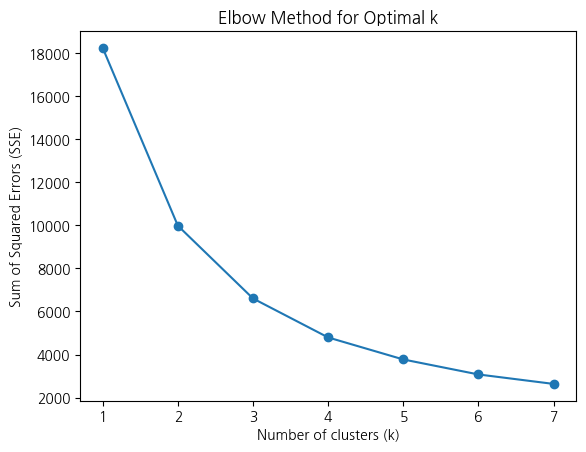

In [ ]:
sse = []
k_values = range(1, 8)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    sse.append(kmeans.inertia_)

# 엘보우 그래프 그리기
plt.plot(k_values, sse, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal k')
plt.show()

변곡이 발생하는 3개가 적당하다.

In [ ]:
# K-means 모델 생성 및 학습
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data_scaled)

# 클러스터 할당 (라벨)
dataset_2['cluster'] = kmeans.labels_

C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\508555822.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_2['cluster'] = kmeans.labels_


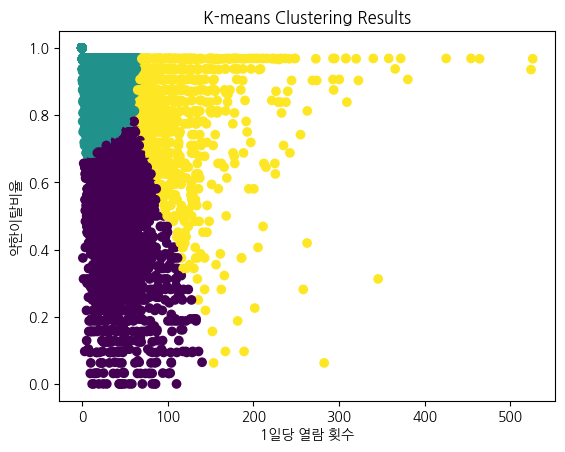

In [ ]:
plt.scatter(dataset_2['1일당 열람 횟수'], dataset_2['약한이탈비율'], c=dataset_2['cluster'], cmap='viridis')
plt.xlabel('1일당 열람 횟수')
plt.ylabel('약한이탈비율')
plt.title('K-means Clustering Results')
plt.show()

In [ ]:
dataset_2.groupby('cluster')[['1일당 열람 횟수', '약한이탈비율']].mean()

,1일당 열람 횟수,약한이탈비율
cluster,,
0,41.423974,0.500972
1,13.513679,0.925277
2,115.182493,0.796936


약한 이탈 비율과 1일당 열람 횟수를 통해 시청 패턴을 3가지로 나눌 수 있었다.
- 클러스터 0: 꾸준한 스타일 -> 약한 이탈 비율이 낮고 1일당 열람 횟수도 중간 수준임. 자주 방문해 적정량의 에피소드를 열람함
- 클러스터 1: 미열람자 -> 1일당 열람 횟수가 낮고 약한 이탈 비율도 높아 자주 방문하지 않음
- 클러스터 2: 몰아보기 -> 약한 이탈 비율이 높으면서 1일당 열람횟수도 높음. 자주 방문하지 않지만 방문할 때마다 많은 양의 에피소드를 열람함

### 더미변수화

In [ ]:
dataset_2['plan.type'].unique()
dataset_2['plan.type'].replace({'1개월 플랜':0 , '3개월 플랜':1, '12개월 플랜':2}, inplace=True)

C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\1784768434.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset_2['plan.type'].replace({'1개월 플랜':0 , '3개월 플랜':1, '12개월 플랜':2}, inplace=True)
C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\1784768434.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_2['plan.type'].replace({'1

In [ ]:
dataset_2

,user_id,plan.type,취소_후_재구독_횟수,시작날짜,마지막날짜,총구독일,예정만료일,생존여부,무료체험여부,에피소드완료횟수,컨텐츠완료횟수,약한이탈비율,사용 일 수,총 사용 횟수,1일당 열람 횟수,cluster,1일당 열람 횟수_scaled
0,0000572f2ba8079bcefd2760b632e820,0,0,2023-03-25,2023-06-25,92 days,2023-04-25,1,1,20.0,1.0,0.843750,5.0,118.0,23.600000,1,-0.195472
1,000087537cbfd934375364218ff10f91,2,0,2023-04-08,2024-04-08,366 days,2023-05-08,1,1,5.0,0.0,0.967742,1.0,24.0,24.000000,1,-0.185378
2,000be07bc09ceff42c11978f4a9f1c1a,2,0,2023-01-25,2024-01-25,365 days,2023-02-25,1,0,0.0,0.0,1.000000,0.0,0.0,0.000000,1,-0.790979
3,001ddbe4885db89888b34bf0eb14f6e1,2,0,2023-01-21,2023-08-30,221 days,2023-02-21,1,0,0.0,0.0,0.937500,2.0,55.0,27.500000,1,-0.097062
4,002109ba574914ed127dcae867110f91,2,0,2023-02-17,2024-02-17,365 days,2023-03-17,1,0,0.0,0.0,1.000000,0.0,0.0,0.000000,1,-0.790979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9620,fffadab35ddc8234e1c5139815bfc017,0,1,2023-10-17,2023-11-17,31 days,2023-11-17,0,0,0.0,0.0,1.000000,0.0,0.0,0.000000,1,-0.790979
9622,fffcae39952c396123f9a3c0808a2183,0,0,2023-01-18,2023-05-18,120 days,2023-02-18,1,0,0.0,0.0,1.000000,0.0,0.0,0.000000,1,-0.790979
9623,fffe529de03d6187ef7ed765650c8d2b,0,0,2023-04-08,2023-07-05,88 days,2023-05-08,1,1,156.0,4.0,0.483871,16.0,574.0,35.875000,0,0.114268
9624,fffe529de03d6187ef7ed765650c8d2b,0,1,2023-08-07,2023-08-21,14 days,2023-09-07,0,1,105.0,0.0,0.812500,6.0,172.0,28.666667,1,-0.067623


In [ ]:
dataset_2.groupby('cluster')[['약한이탈비율','1일당 열람 횟수']].mean()

C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\1567273583.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataset_2.groupby('cluster')[['약한이탈비율','1일당 열람 횟수']].mean()


,약한이탈비율,1일당 열람 횟수
cluster,,
0,0.500972,41.423974
1,0.925277,13.513679
2,0.796936,115.182493


In [ ]:
# dataset_2 object타입을 카테고리 타입으로 변경 및 원핫인코딩 적용
dataset_2['plan.type'] = dataset_2['plan.type'].astype('category')
dataset_2['무료체험여부'] = dataset_2['무료체험여부'].astype('category')
dataset_2['생존여부'] = dataset_2['생존여부'].astype('category')
dataset_2['cluster'] = dataset_2['cluster'].astype('category')

dummies_1 = pd.get_dummies(dataset_2['plan.type'], prefix='plan.type')
dummies_2 = pd.get_dummies(dataset_2['무료체험여부'], prefix='free_trial')
dummies_3 = pd.get_dummies(dataset_2['cluster'], prefix='watch_type')

# dummies_1 = pd.get_dummies(dataset_2['생존여부'], prefix='A')

dataset2_dummies = pd.concat([dataset_2, dummies_1], axis=1).drop(columns=['plan.type']) 
dataset2_dummies = pd.concat([dataset2_dummies, dummies_2], axis=1).drop(columns=['무료체험여부'])
dataset2_dummies = pd.concat([dataset2_dummies, dummies_3], axis=1).drop(columns=['cluster'])

C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\1505097176.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_2['plan.type'] = dataset_2['plan.type'].astype('category')
C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\1505097176.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_2['무료체험여부'] = dataset_2['무료체험여부'].astype('category')
C:\Users\csh94\AppData\Local\Temp\ipykernel_30536\1505097176.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

In [ ]:
dataset2_dummies

,user_id,취소_후_재구독_횟수,시작날짜,마지막날짜,총구독일,예정만료일,생존여부,에피소드완료횟수,컨텐츠완료횟수,약한이탈비율,...,1일당 열람 횟수,1일당 열람 횟수_scaled,plan.type_0,plan.type_1,plan.type_2,free_trial_0,free_trial_1,watch_type_0,watch_type_1,watch_type_2
0,0000572f2ba8079bcefd2760b632e820,0,2023-03-25,2023-06-25,92 days,2023-04-25,1,20.0,1.0,0.843750,...,23.600000,-0.195472,True,False,False,False,True,False,True,False
1,000087537cbfd934375364218ff10f91,0,2023-04-08,2024-04-08,366 days,2023-05-08,1,5.0,0.0,0.967742,...,24.000000,-0.185378,False,False,True,False,True,False,True,False
2,000be07bc09ceff42c11978f4a9f1c1a,0,2023-01-25,2024-01-25,365 days,2023-02-25,1,0.0,0.0,1.000000,...,0.000000,-0.790979,False,False,True,True,False,False,True,False
3,001ddbe4885db89888b34bf0eb14f6e1,0,2023-01-21,2023-08-30,221 days,2023-02-21,1,0.0,0.0,0.937500,...,27.500000,-0.097062,False,False,True,True,False,False,True,False
4,002109ba574914ed127dcae867110f91,0,2023-02-17,2024-02-17,365 days,2023-03-17,1,0.0,0.0,1.000000,...,0.000000,-0.790979,False,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9620,fffadab35ddc8234e1c5139815bfc017,1,2023-10-17,2023-11-17,31 days,2023-11-17,0,0.0,0.0,1.000000,...,0.000000,-0.790979,True,False,False,True,False,False,True,False
9622,fffcae39952c396123f9a3c0808a2183,0,2023-01-18,2023-05-18,120 days,2023-02-18,1,0.0,0.0,1.000000,...,0.000000,-0.790979,True,False,False,True,False,False,True,False
9623,fffe529de03d6187ef7ed765650c8d2b,0,2023-04-08,2023-07-05,88 days,2023-05-08,1,156.0,4.0,0.483871,...,35.875000,0.114268,True,False,False,False,True,True,False,False
9624,fffe529de03d6187ef7ed765650c8d2b,1,2023-08-07,2023-08-21,14 days,2023-09-07,0,105.0,0.0,0.812500,...,28.666667,-0.067623,True,False,False,False,True,False,True,False


## 로지스틱 회귀분석 실시

In [ ]:
# 약한이탈률만 넣어서 로지스틱 회귀분석 실시
import statsmodels.api as sm

X = dataset2_dummies['약한이탈비율']
y = dataset2_dummies['생존여부']

# 상수항 추가 (로지스틱 회귀에서는 필요)
X = sm.add_constant(X)

# 모델 생성
OnlyWC_model_LR_sm = sm.Logit(y, X)

# 모델 학습
result = OnlyWC_model_LR_sm.fit()

# 결과 요약 출력
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.667802
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                   생존여부   No. Observations:                 9126
Model:                          Logit   Df Residuals:                     9124
Method:                           MLE   Df Model:                            1
Date:                Fri, 08 Nov 2024   Pseudo R-squ.:                0.001405
Time:                        13:41:13   Log-Likelihood:                -6094.4
converged:                       True   LL-Null:                       -6102.9
Covariance Type:            nonrobust   LLR p-value:                 3.458e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7667      0.081      9.498      0.000       0.608       0.925
약한이탈비율        -0.4005      0.

In [ ]:
# 승산비 출력
odds_ratios = np.exp(result.params)
odds_ratios

const     2.152673
약한이탈비율    0.670004
dtype: float64

회귀모형은 로그우도로 계산한 p-value가 .05 미만으로 유의했으며,  약한이탈비율의 회귀계수가 -0.4로 약한 이탈 비율이 늘어날수록 생존 가능성이 감소하며, 통계적으로 유의했다.

약한 이탈 비율의 승산비는 0.67로 약한 이탈 비율이 1% 증가하면 생존 가능성이 이전보다 33% 감소한다.

그러나 해당 모형의 설명력은 0.001로 매우 낮았다. 이렇게 통계적으로 유의하나 설명력이 극단적으로 낮은 원인으로 구독 취소라는 강한 이탈은 단순히 하나의 행동이 아닌 여러 요인들이 복합적으로 작동한 결과이기 때문에 약한 이탈률만으로 설명하지 못하는 가능성이 있다.

이에 따라, 구독 이탈에 영향을 주는 다른 변인들을 함께 고려한 추가 분석을 통해 약한 이탈 비율이 1개월 후 구독 유지에 미치는 변인인지 평가했다.

# 분석 4. 첫 1개월 구독 다중 로지스틱 회귀분석(multiple logistic regression) 및 랜덤 포레스트 분석

1. 분석 목적
    1. 구독 이탈에 영향을 주는 여러 변인들 중 약한 이탈 비율이 유의미한 변인인지 확인하고자 한다.
2. 독립 변인: 요금제, 취소 후 재구독 횟수, 무료체험 여부, 에피소드 완료 횟수, 콘텐츠 완료 횟수, 약한 이탈률, 1일당 열람 횟수, 열람 패턴
3. 분석 모형: 첫 구독 유지에 영향을 주는 주요 변수를 선택하기 위해 다중 로지스틱 회귀분석과 랜덤 포레스트를 사용

## 다중 로지스틱 회귀분석(Scikit-learn)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
X = dataset2_dummies[['plan.type_2','plan.type_1','취소_후_재구독_횟수','free_trial_1','에피소드완료횟수','컨텐츠완료횟수','약한이탈비율','1일당 열람 횟수','watch_type_1','watch_type_2']]
y = dataset2_dummies['생존여부']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 생성
dataset2_model_LR = LogisticRegression(max_iter=200)

# 모델 훈련
dataset2_model_LR.fit(X_train, y_train)

# 예측
y_pred = dataset2_model_LR.predict(X_test)

# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 추가적인 평가 지표
print(classification_report(y_test, y_pred))

# 회귀 계수 출력
coefficients = dataset2_model_LR.coef_[0]  # 1차원 배열로 변환
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# 계수 크기 순서대로 정렬
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)
print(feature_importance)

Accuracy: 0.6883899233296824
              precision    recall  f1-score   support

           0       0.58      0.77      0.66       726
           1       0.81      0.63      0.71      1100

    accuracy                           0.69      1826
   macro avg       0.69      0.70      0.69      1826
weighted avg       0.72      0.69      0.69      1826

        Feature  Coefficient  Abs_Coefficient
1   plan.type_1     2.514201         2.514201
0   plan.type_2     2.205418         2.205418
6        약한이탈비율    -1.220538         1.220538
9  watch_type_2    -0.161087         0.161087
5       컨텐츠완료횟수    -0.113013         0.113013
2   취소_후_재구독_횟수    -0.106463         0.106463
3  free_trial_1     0.066616         0.066616
8  watch_type_1     0.039572         0.039572
7     1일당 열람 횟수     0.002341         0.002341
4      에피소드완료횟수     0.000486         0.000486


c:\Users\csh94\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# 일부 변수 제외 후 로지스틱 회귀분석
X = dataset2_dummies[['plan.type_2','plan.type_1','취소_후_재구독_횟수','컨텐츠완료횟수','약한이탈비율','watch_type_1','watch_type_2']]
y = dataset2_dummies['생존여부']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 생성
dataset2_model_LR = LogisticRegression()

# 모델 훈련
dataset2_model_LR.fit(X_train, y_train)

# 예측
y_pred = dataset2_model_LR.predict(X_test)

# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 추가적인 평가 지표
print(classification_report(y_test, y_pred))

# 회귀 계수 출력
coefficients = dataset2_model_LR.coef_[0]  # 1차원 배열로 변환
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# 계수 크기 순서대로 정렬
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)
print(feature_importance)

Accuracy: 0.6807228915662651
              precision    recall  f1-score   support

           0       0.58      0.75      0.65       726
           1       0.79      0.64      0.71      1100

    accuracy                           0.68      1826
   macro avg       0.68      0.69      0.68      1826
weighted avg       0.71      0.68      0.68      1826

        Feature  Coefficient  Abs_Coefficient
0   plan.type_2     2.200446         2.200446
1   plan.type_1     2.175989         2.175989
4        약한이탈비율    -1.749940         1.749940
5  watch_type_1     0.161865         0.161865
6  watch_type_2     0.149137         0.149137
3       컨텐츠완료횟수    -0.103849         0.103849
2   취소_후_재구독_횟수    -0.103296         0.103296


1. 정확도는 68%로 전체 샘플 중 68%를 정확하게 예측했다.
2. 정밀도는 이탈로 예측한 샘플 중 58%가 실제로 이탈했고, 생존으로 예측한 샘플 중 79%가 실제로 생존했다.
3. 재현율은 실제 이탈한 유저 중 75%를 정확하게 예측했으며, 실제 생존한 유저 중 64%를 정확하게 예측했다.
4. 정밀도와 재현율의 조화평균인 F1 점수는 이탈이 65%, 생존이 71%로 나와 생존에 대해 더 나은 성능을 보여주었다.
5. 데이터 불균형이 어느 정도 존재함에도 불구하고, 가중 평균(weighted avg)를 통해 전체적인 성능을 평가했을 때 0.68로 단순히 생존으로 예측했을 때(61%)보다 더 나은 성능을 보여주었다.

## 다중 로지스틱 회귀(Statsmodels)

In [ ]:
import statsmodels.api as sm

X = dataset2_dummies[['plan.type_2','plan.type_1','취소_후_재구독_횟수','free_trial_1','에피소드완료횟수','컨텐츠완료횟수','약한이탈비율','1일당 열람 횟수','watch_type_1','watch_type_2']]
y = dataset2_dummies['생존여부']

# True/False 값을 1과 0으로 변환
X = X.astype(float)  # 이미 float으로 변환
y = y.astype(float)  # 이미 float으로 변환

# 상수항 추가 (로지스틱 회귀에서는 필요)
X = sm.add_constant(X)

# 모델 생성
dataset2_model_LR_sm = sm.Logit(y, X)

# 모델 학습
result = dataset2_model_LR_sm.fit()

# 결과 요약 출력
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.556847
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   생존여부   No. Observations:                 9126
Model:                          Logit   Df Residuals:                     9115
Method:                           MLE   Df Model:                           10
Date:                Fri, 08 Nov 2024   Pseudo R-squ.:                  0.1673
Time:                        13:40:53   Log-Likelihood:                -5081.8
converged:                       True   LL-Null:                       -6102.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.1631      0.150      7.768      0.000       0.870       1.457
plan.type_2      2.2267

In [ ]:
# 승산비 출력
odds_ratios = np.exp(result.params)
odds_ratios

const           3.199770
plan.type_2     9.269287
plan.type_1     9.422000
취소_후_재구독_횟수     0.857771
free_trial_1    1.053833
에피소드완료횟수        1.000491
컨텐츠완료횟수         0.877802
약한이탈비율          0.173116
1일당 열람 횟수       1.002281
watch_type_1    1.181938
watch_type_2    0.954891
dtype: float64

In [ ]:
X2 = dataset2_dummies[['plan.type_2','plan.type_1','취소_후_재구독_횟수','컨텐츠완료횟수','약한이탈비율','1일당 열람 횟수']]
y = dataset2_dummies['생존여부']

# True/False 값을 1과 0으로 변환
X2 = X2.astype(float)  # 이미 float으로 변환
y = y.astype(float)  # 이미 float으로 변환

# 상수항 추가 (로지스틱 회귀에서는 필요)
X2 = sm.add_constant(X2)

# 모델 생성
dataset2_model_LR_sm = sm.Logit(y, X2)

# 모델 학습
result = dataset2_model_LR_sm.fit()

# 결과 요약 출력
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.557221
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   생존여부   No. Observations:                 9126
Model:                          Logit   Df Residuals:                     9119
Method:                           MLE   Df Model:                            6
Date:                Fri, 08 Nov 2024   Pseudo R-squ.:                  0.1668
Time:                        13:40:53   Log-Likelihood:                -5085.2
converged:                       True   LL-Null:                       -6102.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.1401      0.128      8.915      0.000       0.889       1.391
plan.type_2     2.2181    

In [ ]:
# 승산비 출력
odds_ratios = np.exp(result.params)
odds_ratios

const          3.127035
plan.type_2    9.189925
plan.type_1    9.231663
취소_후_재구독_횟수    0.859698
컨텐츠완료횟수        0.891785
약한이탈비율         0.212919
1일당 열람 횟수      1.001311
dtype: float64

1. 로지스틱 회귀모형은 LLR p-value는 .01 이하로 유의했고, 약 17%의 설명력을 가졌다. 정확도는 68%였다.
2. 해당 모형에서 유의한 변인은 요금제, 취소 후 재구독 횟수, 콘텐츠 완료 횟수, 약한 이탈 비율, 1일당 열람 횟수였다.

## 랜덤 포레스트

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV


In [ ]:
dataset2_dummies.columns

Index(['user_id', '취소_후_재구독_횟수', '시작날짜', '마지막날짜', '총구독일', '예정만료일', '생존여부',
       '에피소드완료횟수', '컨텐츠완료횟수', '약한이탈비율', '사용 일 수', '총 사용 횟수', '1일당 열람 횟수',
       '1일당 열람 횟수_scaled', 'plan.type_0', 'plan.type_1', 'plan.type_2',
       'free_trial_0', 'free_trial_1', 'watch_type_0', 'watch_type_1',
       'watch_type_2'],
      dtype='object')

In [ ]:
X = dataset2_dummies[['취소_후_재구독_횟수', '에피소드완료횟수', '컨텐츠완료횟수', '약한이탈비율','1일당 열람 횟수','plan.type_0', 'plan.type_1', 'plan.type_2', 'free_trial_0','free_trial_1', 'watch_type_0', 'watch_type_1', 'watch_type_2']]
y = dataset2_dummies['생존여부']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt']
}

In [ ]:
# 모델 생성
dataset2_model_RF = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=dataset2_model_RF, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# 최적 파라미터 탐색
grid_search.fit(X_train, y_train)

# 최적의 파라미터 및 정확도 출력
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.7135616330869156


In [ ]:
dataset2_model_RF = RandomForestClassifier(n_estimators= 100, max_depth= 10, max_features= 'sqrt', min_samples_leaf= 1, min_samples_split = 2, random_state=42)
dataset2_model_RF.fit(X_train, y_train)

# 예측
y_pred = dataset2_model_RF.predict(X_test)

# 정확도 평가
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 추가적인 평가 지표
print(classification_report(y_test, y_pred))

Accuracy: 0.7075575027382256
              precision    recall  f1-score   support

           0       0.64      0.61      0.62       726
           1       0.75      0.77      0.76      1100

    accuracy                           0.71      1826
   macro avg       0.69      0.69      0.69      1826
weighted avg       0.71      0.71      0.71      1826



In [ ]:
# 변수 중요도 확인
importances = dataset2_model_RF.feature_importances_
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importances)

# 중요도가 0.1 이상인 변수만 선택
important_features = feature_importances[feature_importances['Importance'] > 0.1]['Feature'].tolist()
print("\n중요한 변수:", important_features)

         Feature  Importance
5    plan.type_0    0.267793
7    plan.type_2    0.225849
4      1일당 열람 횟수    0.133949
3         약한이탈비율    0.125344
1       에피소드완료횟수    0.093504
2        컨텐츠완료횟수    0.066304
0    취소_후_재구독_횟수    0.034527
6    plan.type_1    0.011041
10  watch_type_0    0.010367
11  watch_type_1    0.008864
12  watch_type_2    0.007980
9   free_trial_1    0.007360
8   free_trial_0    0.007120

중요한 변수: ['plan.type_0', 'plan.type_2', '1일당 열람 횟수', '약한이탈비율']


1. 정확도는 71%로 전체 샘플 중 71%를 정확하게 예측했다.
2. 정밀도는 이탈로 예측한 샘플 중 64%가 실제로 이탈했고, 생존으로 예측한 샘플 중 75%가 실제로 생존했다.
3. 재현율은 실제 이탈한 유저 중 61%를 정확하게 예측했으며, 실제 생존한 유저 중 77%를 정확하게 예측했다.
4. 정밀도와 재현율의 조화평균인 F1 점수는 이탈이 62%, 생존이 76%로 나와 생존에 대해 더 나은 성능을 보여주었다.
5. 데이터 불균형이 어느 정도 존재함에도 불구하고, 가중 평균(weighted avg)를 통해 전체적인 성능을 평가했을 때도 0.71로 양호한 결과를 보였다

# 논의

1. 종합
    1) 로지스틱 회귀분석과 랜덤 포레스트에서 공통적으로 선별된 변수는 요금제, 1일당 열람 횟수, 약한 이탈 비율이었다.
        - 요금제는 장기 플랜을 가입한 사람이 그렇지 않을 사람보다 생존 확률이 더 높았다.
        - 1일당 열람 횟수가 많을수록 생존 확률이 높아졌으나 1회당 확률 차이는 크지 않았다. 하지만 데스레터는 카드뉴스 형식의 에피소드로 구성되어 있으므로 1일당 에피소드 열람 횟수가 늘어나는 양이 충분히 많을 것이다.
        - 약한 이탈 비율(미열람일 비율)이 높아질수록 생존 확률이 낮아지며 감소폭이 크다.
    2) 선행연구와 다르게 무료 체험 여부와 열람 패턴은 첫 1개월 구독 유지에 중요한 변인이 아니었다.
        - 몰아보기가 무조건 짧은 구독 기간을 이끌어내는 것이 아니다.
            - 넷플릭스는 오히려 몰아보기 패턴을 이용해 시청자들의 유입과 리텐션을 높이는 전략을 사용한다.
            - 무료 체험 후 자동으로 결제가 시작되는 경우, 유저에게 예상치 못한 비용을 부담하게 될 수 있다. 사용자에게 부정적인 경험은 장기 구독자로 전환되는 비율을 낮출 수 있다.
2. 결론
    - 약한 이탈은 초기 1개월 구독 유지에 영향을 준다.
    - 3개월 이상 장기 구독자들은 월별 이탈률이 0.9가 되었을 때 나간다.
    - 초반 리텐션을 높이기 위해서는 장기 요금제 가입 유도, 에피소드 열람하는 날을 늘리기, 한 번 사이트에 접속했을 때 에피소드를 열람하는 횟수를 늘리는 방안을 고심해야 한다.